<a href="https://colab.research.google.com/github/jaimeisaac2020/Python-analsisis-basicos/blob/mi-github/Modelos_GOOGL_Analisis_Completo_tesis_maestria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelos de Predicción de Precios y Retornos - GOOGL


Este notebook incluye el análisis detallado de modelos aplicados a los datos de GOOGL, incluyendo:

1. Regresión Lineal Múltiple  
2. Random Forest  
3. Gradient Boosting  
4. ARIMA  
5. Modelo Híbrido ARIMA + Gradient Boosting  

Se utilizan precios de cierre y retornos como variables dependientes, junto a variables macroeconómicas y técnicas.


## Regresión Lineal Múltiple

In [1]:
# --- Regresión Lineal Múltiple ---
# Cargar datos
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
df = pd.read_csv("dataset_completo_google_amazon.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Aquí insertarías el código específico del modelo Regresión Lineal Múltiple
# incluyendo:
# - División de datos
# - Entrenamiento
# - Predicción
# - Evaluación con MAE, MSE, R²
# - Interpretación


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Filtrar filas completas
df_model = df.dropna(subset=['GOOGL_Return_1d', 'Treasury_10Y', 'VIX', 'SP500', 'NASDAQ', 'Inflacion_T5YIE', 'GOOGL_Volatility_20'])

# Definir variables dependientes e independientes
X = df_model[['Treasury_10Y', 'VIX', 'SP500', 'NASDAQ', 'Inflacion_T5YIE', 'GOOGL_Volatility_20']]
y = df_model['GOOGL_Return_1d']

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Ajustar el modelo de regresión lineal
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predicciones
y_pred = lr_model.predict(X_test)

# Evaluación
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Coeficientes del modelo
coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': lr_model.coef_
})

# Resultados
resultados_lr = {
    'MAE': mae,
    'MSE': mse,
    'R2': r2,
    'Intercepto': lr_model.intercept_
}

coef_df, resultados_lr


(              Variable  Coeficiente
 0         Treasury_10Y        -0.00
 1                  VIX        -0.00
 2                SP500        -0.00
 3               NASDAQ        -0.00
 4      Inflacion_T5YIE         0.00
 5  GOOGL_Volatility_20         0.00,
 {'MAE': 0.013947489511727537,
  'MSE': 0.0003477314602823492,
  'R2': -0.10785425217721567,
  'Intercepto': np.float64(0.04619076076519335)})


--- Evaluación del Modelo en Conjunto de Prueba ---
MAE: 0.0139
MSE: 0.0003
R²: -0.1079

--- Coeficientes del Modelo (Entrenado en Test Set) ---


,Variable,Coeficiente
0,Treasury_10Y,-1.636320e-03
1,VIX,-8.372421e-04
2,SP500,-5.325037e-06
3,NASDAQ,-2.431538e-07
4,Inflacion_T5YIE,1.530888e-04
5,GOOGL_Volatility_20,4.995366e-04



Intercepto: 0.0462

--- Análisis de Supuestos de Residuos (del modelo entrenado en Test Set) ---

1. Linealidad y Homocedasticidad Visual (Residuos vs. Predicciones):


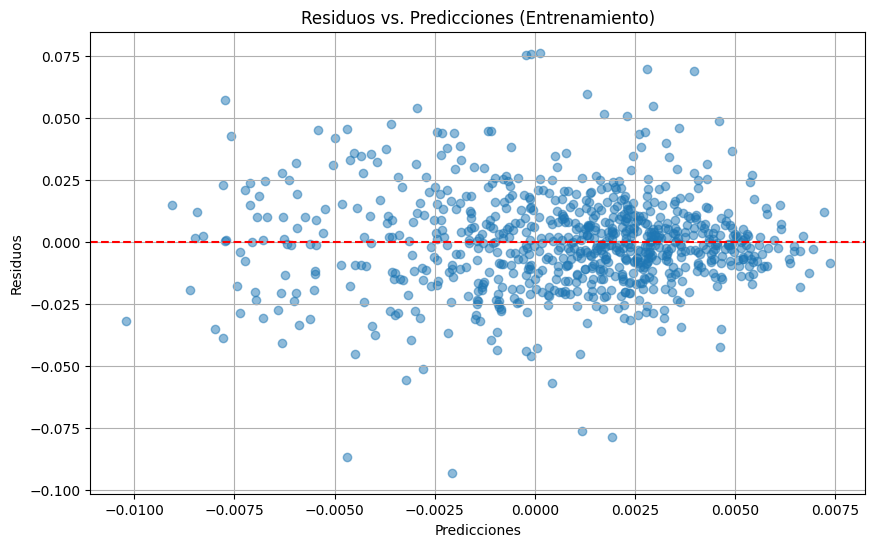


2. Independencia de Residuos (Autocorrelación):


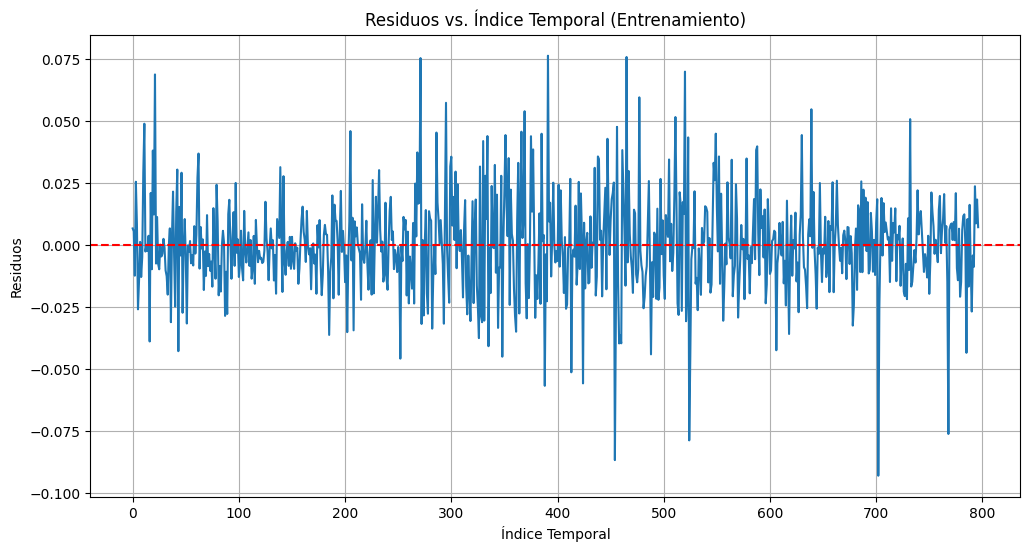

  Prueba de Durbin-Watson: 2.0226

3. Homocedasticidad (Varianza Constante):
  Prueba de Breusch-Pagan:
    Estadístico: 40.6307
    Valor p:     0.0000
    ¡Advertencia: Rechazamos la hipótesis de homocedasticidad (p < 0.05). Heterocedasticidad detectada!

4. Normalidad de Residuos:


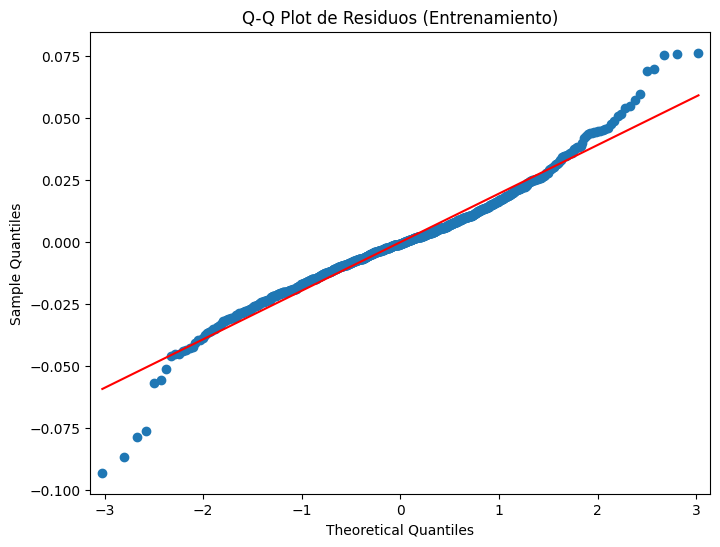

  Prueba de Jarque-Bera:
    Estadístico: 199.9625
    Valor p:     0.0000
    Asimetría:   0.1072
    Curtosis:    5.4445
    ¡Advertencia: Rechazamos la hipótesis de normalidad (p < 0.05).

5. Multicolinealidad:
  Factores de Inflación de Varianza (VIF):


,feature,VIF
2,SP500,1992.538176
3,NASDAQ,1166.518403
4,Inflacion_T5YIE,147.339035
0,Treasury_10Y,31.798666
1,VIX,25.909040
5,GOOGL_Volatility_20,9.254573



--- Pronóstico Regresión Lineal para los Primeros 40 Días de 2025 ---

Tabla de Pronósticos:


,Forecast_GOOGL_Return_1d_LR
Date,
2025-01-01,0.0004
2025-01-02,0.0004
2025-01-03,0.0004
2025-01-06,0.0004
2025-01-07,0.0004
2025-01-08,0.0004
2025-01-09,0.0004
2025-01-10,0.0004
2025-01-13,0.0004



Nota sobre el Pronóstico:
Este pronóstico asume que los valores de las variables independientes (Treasury_10Y, VIX, SP500, etc.)
durante los primeros 40 días de 2025 serán iguales a sus últimos valores conocidos en el dataset histórico.
Esta es una simplificación significativa y la precisión del pronóstico dependerá en gran medida de si esta asunción es válida.
En un escenario real, necesitarías modelos separados para pronosticar estas features o usar enfoques multivariados.


In [3]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import statsmodels.api as sm # Para análisis de residuos
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# Removed the incorrect import: from statsmodels.stats.diagnostic import linear_regression_ordinarity_test
from statsmodels.stats.stattools import durbin_watson # Prueba de Durbin-Watson para autocorrelación
from statsmodels.stats.outliers_influence import variance_inflation_factor # VIF para multicolinealidad
from IPython.display import display # Para mostrar DataFrames formateados

# Cargar datos (asegúrate de que esta ruta sea correcta)
try:
    df = pd.read_csv("dataset_completo_google_amazon.csv")
except FileNotFoundError:
    print("Error: 'dataset_completo_google_amazon.csv' no encontrado. Asegúrate de que el archivo está en la ruta correcta.")
    exit() # Salir si el archivo no se encuentra


df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Definir variables dependientes e independientes (usando las columnas que ya tenías)
# Asegúrate de que estas columnas existen en tu DataFrame
required_cols = ['GOOGL_Return_1d', 'Treasury_10Y', 'VIX', 'SP500', 'NASDAQ', 'Inflacion_T5YIE', 'GOOGL_Volatility_20']
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    print(f"Error: Faltan las siguientes columnas requeridas en el dataset: {missing_cols}")
    exit()

# Filtrar filas con valores nulos en las columnas relevantes
df_model = df.dropna(subset=required_cols).copy()

X = df_model[['Treasury_10Y', 'VIX', 'SP500', 'NASDAQ', 'Inflacion_T5YIE', 'GOOGL_Volatility_20']]
y = df_model['GOOGL_Return_1d']


# --- División de Datos (para evaluación inicial, ya lo tienes) ---
# Usamos shuffle=False para series de tiempo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Ajustar el modelo de regresión lineal en el conjunto de entrenamiento
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predicciones en el conjunto de prueba y evaluación (ya lo tienes)
y_pred_test = lr_model.predict(X_test)

mae_test = mean_absolute_error(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print("\n--- Evaluación del Modelo en Conjunto de Prueba ---")
print(f"MAE: {mae_test:.4f}")
print(f"MSE: {mse_test:.4f}")
print(f"R²: {r2_test:.4f}")

# Coeficientes del modelo (ya lo tienes)
coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': lr_model.coef_
})
print("\n--- Coeficientes del Modelo (Entrenado en Test Set) ---")
display(coef_df)
print(f"\nIntercepto: {lr_model.intercept_:.4f}")


# --- Análisis de Supuestos de Residuos ---
print("\n--- Análisis de Supuestos de Residuos (del modelo entrenado en Test Set) ---")

# Obtener los residuos en el conjunto de ENTRENAMIENTO para el análisis de supuestos
# Los supuestos se verifican sobre los errores del modelo en los datos que VIO.
residuals_train = y_train - lr_model.predict(X_train)

# 1. Linealidad: Gráfico de Residuos vs. Predicciones (o vs. cada feature)
print("\n1. Linealidad y Homocedasticidad Visual (Residuos vs. Predicciones):")
plt.figure(figsize=(10, 6))
plt.scatter(lr_model.predict(X_train), residuals_train, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuos vs. Predicciones (Entrenamiento)")
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.grid(True)
plt.show()
# Se espera una dispersión aleatoria de puntos alrededor de cero, sin patrones claros (curvas, embudos).
# La dispersión debe ser constante (homocedasticidad).

# También puedes graficar residuos vs. cada feature independiente
# for col in X_train.columns:
#     plt.figure(figsize=(8, 5))
#     plt.scatter(X_train[col], residuals_train, alpha=0.5)
#     plt.axhline(0, color='red', linestyle='--')
#     plt.title(f"Residuos vs. {col} (Entrenamiento)")
#     plt.xlabel(col)
#     plt.ylabel("Residuos")
#     plt.grid(True)
#     plt.show()


# 2. Independencia de Residuos (No Autocorrelación): Gráfico de Residuos vs. Tiempo y Prueba de Durbin-Watson
print("\n2. Independencia de Residuos (Autocorrelación):")
# Gráfico de Residuos vs. Tiempo
plt.figure(figsize=(12, 6))
# Usamos el índice de tiempo original del conjunto de entrenamiento
plt.plot(X_train.index, residuals_train)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuos vs. Índice Temporal (Entrenamiento)")
plt.xlabel("Índice Temporal") # Podrías usar la fecha si la mantuviste en X_train.index
plt.ylabel("Residuos")
plt.grid(True)
plt.show()
# Se espera que los residuos no muestren patrones de autocorrelación (rachas largas por encima o por debajo de cero).

# Prueba de Durbin-Watson: Verifica la autocorrelación de orden 1
# Estadístico de Durbin-Watson varía entre 0 y 4.
# ~2.0 sugiere no autocorrelación. <2 sugiere autocorrelación positiva. >2 sugiere autocorrelación negativa.
# Para series de tiempo financieras, es común encontrar autocorrelación.
dw_test = durbin_watson(residuals_train)
print(f"  Prueba de Durbin-Watson: {dw_test:.4f}")
# Un valor cercano a 2 (típicamente entre 1.5 y 2.5) es generalmente aceptable.
# Valores fuera de este rango pueden indicar problemas de autocorrelación.

# Prueba de Ljung-Box (ya vista en ARIMA, también aplicable aquí para autocorrelación en varios lags)
# from statsmodels.stats.diagnostic import acorr_ljungbox
# print("\n  Prueba de Ljung-Box sobre Residuos:")
# ljungbox_results = acorr_ljungbox(residuals_train, lags=[10, 20], return_df=True)
# display(ljungbox_results)
# Esperamos p-values > 0.05 para no rechazar la hipótesis de ruido blanco.

# 3. Homocedasticidad: Gráfico de Residuos vs. Predicciones (ya visto arriba) o Prueba de Breusch-Pagan
print("\n3. Homocedasticidad (Varianza Constante):")
# La prueba de Breusch-Pagan verifica formalmente si la varianza de los residuos es constante.
# Requiere ajustar un modelo con statsmodels.api.OLS para obtener el objeto de resultados.
# Vamos a ajustar OLS para obtener la prueba Breusch-Pagan
X_train_sm = sm.add_constant(X_train) # statsmodels requiere una constante por defecto
ols_model = sm.OLS(y_train, X_train_sm)
ols_results = ols_model.fit()

# Prueba de Breusch-Pagan
# bp_test[0]: Estadístico de prueba
# bp_test[1]: p-value
# La hipótesis nula es que la varianza es constante (hay homocedasticidad).
# Si el p-value es bajo (< 0.05), rechazamos la hipótesis nula, indicando heterocedasticidad.
try:
    from statsmodels.stats.diagnostic import het_breuschpagan
    bp_test = het_breuschpagan(ols_results.resid, ols_results.model.exog)
    print(f"  Prueba de Breusch-Pagan:")
    print(f"    Estadístico: {bp_test[0]:.4f}")
    print(f"    Valor p:     {bp_test[1]:.4f}")
    if bp_test[1] < 0.05:
        print("    ¡Advertencia: Rechazamos la hipótesis de homocedasticidad (p < 0.05). Heterocedasticidad detectada!")
    else:
        print("    No rechazamos la hipótesis de homocedasticidad (p >= 0.05).")
except ImportError:
     print("  No se pudo realizar la prueba de Breusch-Pagan. Asegúrate de tener una versión reciente de statsmodels.")


# 4. Normalidad de Residuos: Gráfico Q-Q y Prueba de Jarque-Bera
print("\n4. Normalidad de Residuos:")
# Gráfico Q-Q
plt.figure(figsize=(8, 6))
sm.qqplot(residuals_train, line='s', ax=plt.gca())
plt.title("Q-Q Plot de Residuos (Entrenamiento)")
plt.show()
# Se espera que los puntos sigan aproximadamente la línea diagonal.

# Prueba de Jarque-Bera
# La hipótesis nula es que los datos están normalmente distribuidos.
# Si el p-value es bajo (< 0.05), rechazamos la normalidad.
from statsmodels.stats.stattools import jarque_bera # Importar Jarque-Bera desde la ubicación correcta
jb_test = jarque_bera(residuals_train)
print(f"  Prueba de Jarque-Bera:")
print(f"    Estadístico: {jb_test[0]:.4f}")
print(f"    Valor p:     {jb_test[1]:.4f}")
print(f"    Asimetría:   {jb_test[2]:.4f}") # Sesgo (debería ser cercano a 0 para normalidad)
print(f"    Curtosis:    {jb_test[3]:.4f}") # Cola (debería ser cercano a 3 para normalidad)
if jb_test[1] < 0.05:
     print("    ¡Advertencia: Rechazamos la hipótesis de normalidad (p < 0.05).")
else:
     print("    No rechazamos la hipótesis de normalidad (p >= 0.05).")


# 5. Multicolinealidad: Factores de Inflación de Varianza (VIF)
print("\n5. Multicolinealidad:")
# VIF mide cuánta varianza de un coeficiente estimado se incrementa debido a la colinealidad con otras features.
# Reglas generales: VIF = 1 (no colinealidad), 1 < VIF < 5 (colinealidad moderada), VIF > 5 o 10 (colinealidad alta).
vif_data = pd.DataFrame()
vif_data["feature"] = X_train.columns
vif_data["VIF"] = [variance_inflation_factor(X_train.values, i)
                   for i in range(X_train.shape[1])]
print("  Factores de Inflación de Varianza (VIF):")
display(vif_data.sort_values('VIF', ascending=False))
# VIFs altos indican que la feature está altamente correlacionada con otras features,
# lo que puede dificultar la interpretación de los coeficientes individuales y afectar la estabilidad del modelo.


# --- Pronóstico para los primeros 40 días de 2025 ---

print("\n--- Pronóstico Regresión Lineal para los Primeros 40 Días de 2025 ---")

# Ajustar el modelo en TODOS los datos disponibles para el pronóstico futuro
lr_model_full_data = LinearRegression()
lr_model_full_data.fit(X, y) # Ajustar en X y y limpios (sin nulos en columnas relevantes)

# Determinar el rango de fechas para el pronóstico
start_date_2025 = pd.to_datetime('2025-01-01')
# Creamos una serie de fechas hábiles
future_dates = pd.date_range(start=start_date_2025, periods=40, freq='B')

# Crear un DataFrame para las features futuras (X_future)
# ESTA ES LA PARTE CRÍTICA Y SIMPLIFICADA:
# No conocemos los valores reales de las features (tasas, VIX, SP500, etc.) en el futuro.
# Estrategia simple: usar el ÚLTIMO valor conocido de cada feature del dataset histórico.
last_known_features = df_model[X.columns].iloc[-1].to_dict()

# Crear un DataFrame futuro con las fechas y poblar con los últimos valores conocidos
X_future = pd.DataFrame([last_known_features] * len(future_dates), index=future_dates)
X_future.index.name = 'Date' # Nombrar el índice

# Asegurarse de que el orden de las columnas sea el mismo que en el entrenamiento
X_future = X_future[X.columns]


# Realizar las predicciones futuras
forecast_2025 = lr_model_full_data.predict(X_future)

# Crear un DataFrame para mostrar el pronóstico
forecast_df_2025 = pd.DataFrame({'Date': future_dates, 'Forecast_GOOGL_Return_1d_LR': forecast_2025})
forecast_df_2025.set_index('Date', inplace=True)

print("\nTabla de Pronósticos:")
pd.options.display.float_format = '{:.4f}'.format # Formato para visualización
display(forecast_df_2025)

print("\nNota sobre el Pronóstico:")
print("Este pronóstico asume que los valores de las variables independientes (Treasury_10Y, VIX, SP500, etc.)")
print("durante los primeros 40 días de 2025 serán iguales a sus últimos valores conocidos en el dataset histórico.")
print("Esta es una simplificación significativa y la precisión del pronóstico dependerá en gran medida de si esta asunción es válida.")
print("En un escenario real, necesitarías modelos separados para pronosticar estas features o usar enfoques multivariados.")

# Restablecer la opción de formato de pandas si es necesario
# pd.reset_option('display.float_format')


--- Evaluación del Modelo en Conjunto de Prueba ---
MAE: 0.0139
MSE: 0.0003
R²: -0.1079

--- Coeficientes del Modelo (Entrenado en Test Set) ---


,Variable,Coeficiente
0,Treasury_10Y,-0.00
1,VIX,-0.00
2,SP500,-0.00
3,NASDAQ,-0.00
4,Inflacion_T5YIE,0.00
5,GOOGL_Volatility_20,0.00



Intercepto: 0.0462

--- Análisis de Supuestos de Residuos (del modelo entrenado en Test Set) ---

1. Linealidad y Homocedasticidad Visual (Residuos vs. Predicciones):


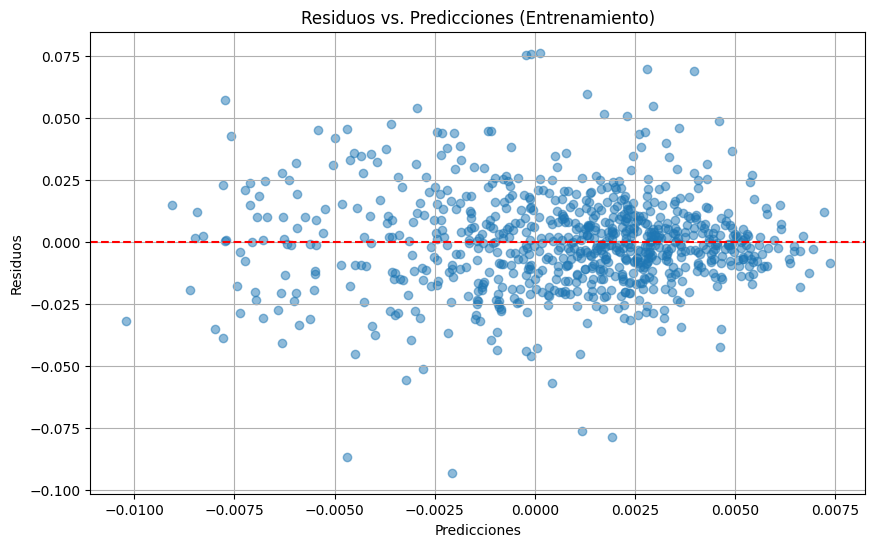


2. Independencia de Residuos (Autocorrelación):


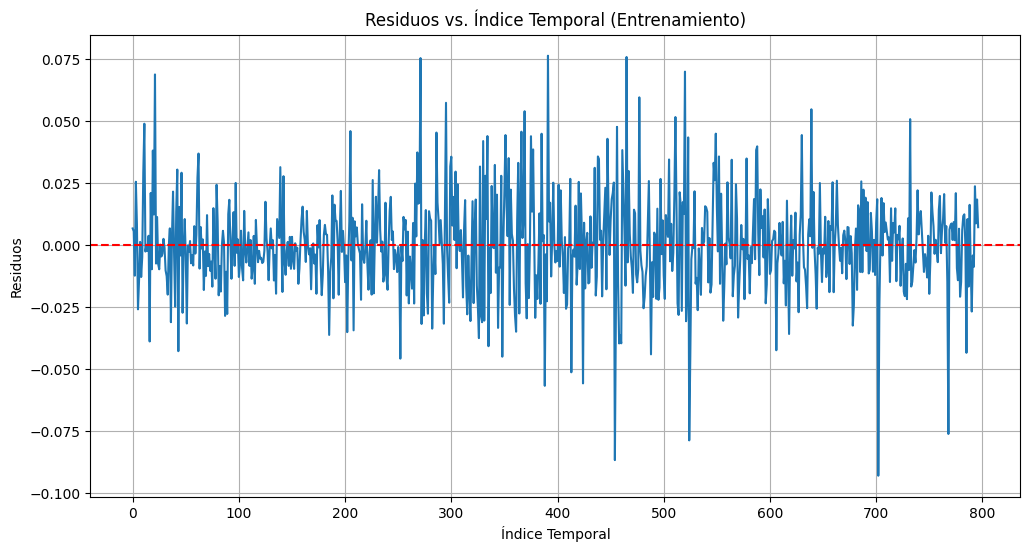

  Prueba de Durbin-Watson: 2.0226

3. Homocedasticidad (Varianza Constante):
  Prueba de Breusch-Pagan:
    Estadístico: 40.6307
    Valor p:     0.0000
    ¡Advertencia: Rechazamos la hipótesis de homocedasticidad (p < 0.05). Heterocedasticidad detectada!

4. Normalidad de Residuos:


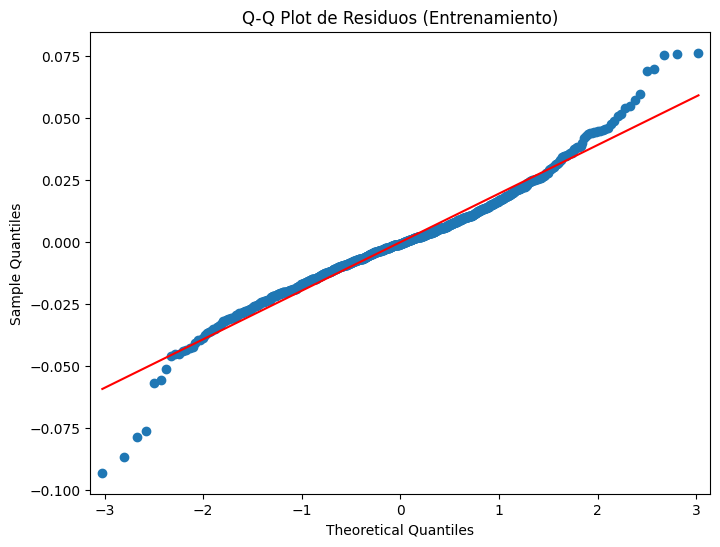

  Prueba de Jarque-Bera:
    Estadístico: 199.9625
    Valor p:     0.0000
    Asimetría:   0.1072
    Curtosis:    5.4445
    ¡Advertencia: Rechazamos la hipótesis de normalidad (p < 0.05).

5. Multicolinealidad:
  Factores de Inflación de Varianza (VIF):


,feature,VIF
2,SP500,1992.54
3,NASDAQ,1166.52
4,Inflacion_T5YIE,147.34
0,Treasury_10Y,31.80
1,VIX,25.91
5,GOOGL_Volatility_20,9.25



--- Pronóstico Regresión Lineal para los Primeros 40 Días de 2025 ---

Tabla de Pronósticos:


,Forecast_GOOGL_Return_1d_LR
Date,
2025-01-01,0.0004
2025-01-02,0.0004
2025-01-03,0.0004
2025-01-06,0.0004
2025-01-07,0.0004
2025-01-08,0.0004
2025-01-09,0.0004
2025-01-10,0.0004
2025-01-13,0.0004



Nota sobre el Pronóstico:
Este pronóstico asume que los valores de las variables independientes (Treasury_10Y, VIX, SP500, etc.)
durante los primeros 40 días de 2025 serán iguales a sus últimos valores conocidos en el dataset histórico.
Esta es una simplificación significativa y la precisión del pronóstico dependerá en gran medida de si esta asunción es válida.
En un escenario real, necesitarías modelos separados para pronosticar estas features o usar enfoques multivariados.


In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import statsmodels.api as sm # Para análisis de residuos
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# Removed the incorrect import: from statsmodels.stats.diagnostic import linear_regression_ordinarity_test
from statsmodels.stats.stattools import durbin_watson # Prueba de Durbin-Watson para autocorrelación
from statsmodels.stats.stattools import jarque_bera # Importar Jarque-Bera desde la ubicación correcta
from statsmodels.stats.outliers_influence import variance_inflation_factor # VIF para multicolinealidad
from IPython.display import display # Para mostrar DataFrames formateados

# Cargar datos (asegúrate de que esta ruta sea correcta)
try:
    df = pd.read_csv("dataset_completo_google_amazon.csv")
except FileNotFoundError:
    print("Error: 'dataset_completo_google_amazon.csv' no encontrado. Asegúrate de que el archivo está en la ruta correcta.")
    exit() # Salir si el archivo no se encuentra


df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Definir variables dependientes e independientes (usando las columnas que ya tenías)
# Asegúrate de que estas columnas existen en tu DataFrame
required_cols = ['GOOGL_Return_1d', 'Treasury_10Y', 'VIX', 'SP500', 'NASDAQ', 'Inflacion_T5YIE', 'GOOGL_Volatility_20']
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    print(f"Error: Faltan las siguientes columnas requeridas en el dataset: {missing_cols}")
    exit()

# Filtrar filas con valores nulos en las columnas relevantes
df_model = df.dropna(subset=required_cols).copy()

X = df_model[['Treasury_10Y', 'VIX', 'SP500', 'NASDAQ', 'Inflacion_T5YIE', 'GOOGL_Volatility_20']]
y = df_model['GOOGL_Return_1d']


# --- División de Datos (para evaluación inicial, ya lo tienes) ---
# Usamos shuffle=False para series de tiempo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Ajustar el modelo de regresión lineal en el conjunto de entrenamiento
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predicciones en el conjunto de prueba y evaluación (ya lo tienes)
y_pred_test = lr_model.predict(X_test)

mae_test = mean_absolute_error(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print("\n--- Evaluación del Modelo en Conjunto de Prueba ---")
print(f"MAE: {mae_test:.4f}")
print(f"MSE: {mse_test:.4f}")
print(f"R²: {r2_test:.4f}")

# Coeficientes del modelo (ya lo tienes)
coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': lr_model.coef_
})
print("\n--- Coeficientes del Modelo (Entrenado en Test Set) ---")
display(coef_df)
print(f"\nIntercepto: {lr_model.intercept_:.4f}")


# --- Análisis de Supuestos de Residuos ---
print("\n--- Análisis de Supuestos de Residuos (del modelo entrenado en Test Set) ---")

# Obtener los residuos en el conjunto de ENTRENAMIENTO para el análisis de supuestos
# Los supuestos se verifican sobre los errores del modelo en los datos que VIO.
residuals_train = y_train - lr_model.predict(X_train)

# 1. Linealidad: Gráfico de Residuos vs. Predicciones (o vs. cada feature)
print("\n1. Linealidad y Homocedasticidad Visual (Residuos vs. Predicciones):")
plt.figure(figsize=(10, 6))
plt.scatter(lr_model.predict(X_train), residuals_train, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuos vs. Predicciones (Entrenamiento)")
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.grid(True)
plt.show()
# Se espera una dispersión aleatoria de puntos alrededor de cero, sin patrones claros (curvas, embudos).
# La dispersión debe ser constante (homocedasticidad).

# También puedes graficar residuos vs. cada feature independiente
# for col in X_train.columns:
#     plt.figure(figsize=(8, 5))
#     plt.scatter(X_train[col], residuals_train, alpha=0.5)
#     plt.axhline(0, color='red', linestyle='--')
#     plt.title(f"Residuos vs. {col} (Entrenamiento)")
#     plt.xlabel(col)
#     plt.ylabel("Residuos")
#     plt.grid(True)
#     plt.show()


# 2. Independencia de Residuos (No Autocorrelación): Gráfico de Residuos vs. Tiempo y Prueba de Durbin-Watson
print("\n2. Independencia de Residuos (Autocorrelación):")
# Gráfico de Residuos vs. Tiempo
plt.figure(figsize=(12, 6))
# Usamos el índice de tiempo original del conjunto de entrenamiento
plt.plot(X_train.index, residuals_train)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuos vs. Índice Temporal (Entrenamiento)")
plt.xlabel("Índice Temporal") # Podrías usar la fecha si la mantuviste en X_train.index
plt.ylabel("Residuos")
plt.grid(True)
plt.show()
# Se espera que los residuos no muestren patrones de autocorrelación (rachas largas por encima o por debajo de cero).

# Prueba de Durbin-Watson: Verifica la autocorrelación de orden 1
# Estadístico de Durbin-Watson varía entre 0 y 4.
# ~2.0 sugiere no autocorrelación. <2 sugiere autocorrelación positiva. >2 sugiere autocorrelación negativa.
# Para series de tiempo financieras, es común encontrar autocorrelación.
dw_test = durbin_watson(residuals_train)
print(f"  Prueba de Durbin-Watson: {dw_test:.4f}")
# Un valor cercano a 2 (típicamente entre 1.5 y 2.5) es generalmente aceptable.
# Valores fuera de este rango pueden indicar problemas de autocorrelación.

# Prueba de Ljung-Box (ya vista en ARIMA, también aplicable aquí para autocorrelación en varios lags)
# from statsmodels.stats.diagnostic import acorr_ljungbox
# print("\n  Prueba de Ljung-Box sobre Residuos:")
# ljungbox_results = acorr_ljungbox(residuals_train, lags=[10, 20], return_df=True)
# display(ljungbox_results)
# Esperamos p-values > 0.05 para no rechazar la hipótesis de ruido blanco.

# 3. Homocedasticidad: Gráfico de Residuos vs. Predicciones (ya visto arriba) o Prueba de Breusch-Pagan
print("\n3. Homocedasticidad (Varianza Constante):")
# La prueba de Breusch-Pagan verifica formalmente si la varianza de los residuos es constante.
# Requiere ajustar un modelo con statsmodels.api.OLS para obtener el objeto de resultados.
# Vamos a ajustar OLS para obtener la prueba Breusch-Pagan
X_train_sm = sm.add_constant(X_train) # statsmodels requiere una constante por defecto
ols_model = sm.OLS(y_train, X_train_sm)
ols_results = ols_model.fit()

# Prueba de Breusch-Pagan
# bp_test[0]: Estadístico de prueba
# bp_test[1]: p-value
# La hipótesis nula es que la varianza es constante (hay homocedasticidad).
# Si el p-value es bajo (< 0.05), rechazamos la hipótesis nula, indicando heterocedasticidad.
try:
    from statsmodels.stats.diagnostic import het_breuschpagan
    bp_test = het_breuschpagan(ols_results.resid, ols_results.model.exog)
    print(f"  Prueba de Breusch-Pagan:")
    print(f"    Estadístico: {bp_test[0]:.4f}")
    print(f"    Valor p:     {bp_test[1]:.4f}")
    if bp_test[1] < 0.05:
        print("    ¡Advertencia: Rechazamos la hipótesis de homocedasticidad (p < 0.05). Heterocedasticidad detectada!")
    else:
        print("    No rechazamos la hipótesis de homocedasticidad (p >= 0.05).")
except ImportError:
     print("  No se pudo realizar la prueba de Breusch-Pagan. Asegúrate de tener una versión reciente de statsmodels.")


# 4. Normalidad de Residuos: Gráfico Q-Q y Prueba de Jarque-Bera
print("\n4. Normalidad de Residuos:")
# Gráfico Q-Q
plt.figure(figsize=(8, 6))
sm.qqplot(residuals_train, line='s', ax=plt.gca())
plt.title("Q-Q Plot de Residuos (Entrenamiento)")
plt.show()
# Se espera que los puntos sigan aproximadamente la línea diagonal.

# Prueba de Jarque-Bera
# La hipótesis nula es que los datos están normalmente distribuidos.
# Si el p-value es bajo (< 0.05), rechazamos la normalidad.
jb_test = jarque_bera(residuals_train)
print(f"  Prueba de Jarque-Bera:")
print(f"    Estadístico: {jb_test[0]:.4f}")
print(f"    Valor p:     {jb_test[1]:.4f}")
print(f"    Asimetría:   {jb_test[2]:.4f}") # Sesgo (debería ser cercano a 0 para normalidad)
print(f"    Curtosis:    {jb_test[3]:.4f}") # Cola (debería ser cercano a 3 para normalidad)
if jb_test[1] < 0.05:
     print("    ¡Advertencia: Rechazamos la hipótesis de normalidad (p < 0.05).")
else:
     print("    No rechazamos la hipótesis de normalidad (p >= 0.05).")


# 5. Multicolinealidad: Factores de Inflación de Varianza (VIF)
print("\n5. Multicolinealidad:")
# VIF mide cuánta varianza de un coeficiente estimado se incrementa debido a la colinealidad con otras features.
# Reglas generales: VIF = 1 (no colinealidad), 1 < VIF < 5 (colinealidad moderada), VIF > 5 o 10 (colinealidad alta).
vif_data = pd.DataFrame()
vif_data["feature"] = X_train.columns
vif_data["VIF"] = [variance_inflation_factor(X_train.values, i)
                   for i in range(X_train.shape[1])]
print("  Factores de Inflación de Varianza (VIF):")
display(vif_data.sort_values('VIF', ascending=False))
# VIFs altos indican que la feature está altamente correlacionada con otras features,
# lo que puede dificultar la interpretación de los coeficientes individuales y afectar la estabilidad del modelo.


# --- Pronóstico para los primeros 40 días de 2025 ---

print("\n--- Pronóstico Regresión Lineal para los Primeros 40 Días de 2025 ---")

# Ajustar el modelo en TODOS los datos disponibles para el pronóstico futuro
lr_model_full_data = LinearRegression()
lr_model_full_data.fit(X, y) # Ajustar en X y y limpios (sin nulos en columnas relevantes)

# Determinar el rango de fechas para el pronóstico
start_date_2025 = pd.to_datetime('2025-01-01')
# Creamos una serie de fechas hábiles
future_dates = pd.date_range(start=start_date_2025, periods=40, freq='B')

# Crear un DataFrame para las features futuras (X_future)
# ESTA ES LA PARTE CRÍTICA Y SIMPLIFICADA:
# No conocemos los valores reales de las features (tasas, VIX, SP500, etc.) en el futuro.
# Estrategia simple: usar el ÚLTIMO valor conocido de cada feature del dataset histórico.
last_known_features = df_model[X.columns].iloc[-1].to_dict()

# Crear un DataFrame futuro con las fechas y poblar con los últimos valores conocidos
X_future = pd.DataFrame([last_known_features] * len(future_dates), index=future_dates)
X_future.index.name = 'Date' # Nombrar el índice

# Asegurarse de que el orden de las columnas sea el mismo que en el entrenamiento
X_future = X_future[X.columns]


# Realizar las predicciones futuras
forecast_2025 = lr_model_full_data.predict(X_future)

# Crear un DataFrame para mostrar el pronóstico
forecast_df_2025 = pd.DataFrame({'Date': future_dates, 'Forecast_GOOGL_Return_1d_LR': forecast_2025})
forecast_df_2025.set_index('Date', inplace=True)

print("\nTabla de Pronósticos:")
pd.options.display.float_format = '{:.4f}'.format # Formato para visualización
display(forecast_df_2025)

print("\nNota sobre el Pronóstico:")
print("Este pronóstico asume que los valores de las variables independientes (Treasury_10Y, VIX, SP500, etc.)")
print("durante los primeros 40 días de 2025 serán iguales a sus últimos valores conocidos en el dataset histórico.")
print("Esta es una simplificación significativa y la precisión del pronóstico dependerá en gran medida de si esta asunción es válida.")
print("En un escenario real, necesitarías modelos separados para pronosticar estas features o usar enfoques multivariados.")

# Restablecer la opción de formato de pandas si es necesario
# pd.reset_option('display.float_format')

In [ ]:
df.head()

,Date,GOOGL_Close,AMZN_Close,Treasury_10Y,VIX,SP500,NASDAQ,GOOGL_Return_1d,AMZN_Return_1d,GOOGL_Volatility_20,AMZN_Volatility_20,Inflacion_T5YIE
0,2021-01-04,85.895844,159.331497,0.917,26.969999,3700.649902,12698.450195,0.008064,0.010004,3.410646,3.841592,1.98
1,2021-01-05,86.588524,160.925507,0.955,25.340000,3726.860107,12818.959961,0.008064,0.010004,3.410646,3.841592,2.01
2,2021-01-06,85.734100,156.919006,1.042,25.070000,3748.139893,12740.790039,-0.009868,-0.024897,3.410646,3.841592,2.04
3,2021-01-07,88.294868,158.108002,1.071,22.370001,3803.790039,13067.480469,0.029869,0.007577,3.410646,3.841592,2.09
4,2021-01-08,89.463783,159.134995,1.105,21.559999,3824.679932,13201.980469,0.013239,0.006496,3.410646,3.841592,2.07


In [ ]:
df.tail()

,Date,GOOGL_Close,AMZN_Close,Treasury_10Y,VIX,SP500,NASDAQ,GOOGL_Return_1d,AMZN_Return_1d,GOOGL_Volatility_20,AMZN_Volatility_20,Inflacion_T5YIE
992,2024-12-23,194.406113,225.059998,4.599,16.780001,5974.069824,19764.880859,0.016823,0.000622,10.948753,9.393671,2.38
993,2024-12-24,195.884399,229.050003,4.591,14.270000,6040.040039,20031.130859,0.007604,0.017729,10.885822,8.437937,2.39
994,2024-12-26,195.375000,227.050003,4.579,14.730000,6037.589844,20020.359375,-0.002601,-0.008732,10.709326,7.838409,2.39
995,2024-12-27,192.538254,223.750000,4.619,15.950000,5970.839844,19722.029297,-0.014519,-0.014534,10.235210,6.736610,2.38
996,2024-12-30,191.020004,221.300003,4.545,17.400000,5906.939941,19486.789062,-0.007885,-0.010950,9.512947,5.666061,2.35


In [ ]:
# Mostrar el resumen del modelo OLS (entrenado en X_train, y_train)
print("\n--- Resumen del Modelo de Regresión Lineal (statsmodels) ---")
display(ols_results.summary())

# Nota: Este summary es para el modelo entrenado en el conjunto de ENTRENAMIENTO (X_train, y_train),
# que es el conjunto que usaste para analizar los supuestos de los residuos.
# Los coeficientes y el intercepto serán los mismos que los del modelo de sklearn
# entrenado en el mismo conjunto.
# El summary de statsmodels proporciona mucha más información estadística.


--- Resumen del Modelo de Regresión Lineal (statsmodels) ---


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        GOOGL_Return_1d   R-squared:                       0.027
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     3.681
Date:                Wed, 18 Jun 2025   Prob (F-statistic):            0.00129
Time:                        00:05:49   Log-Likelihood:                 2003.2
No. Observations:                 797   AIC:                            -3992.
Df Residuals:                     790   BIC:                            -3960.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0462      0.015      3.075      0.002       0.017       0.076
Treasury_10Y           -0.0016      0.001     -1.275      0.203      -0.004       0.001
VIX                    -0.0008      0.000     -3.593      0.000      -0.001      -0.000
SP500               -5.325e-06   7.82e-06     -0.681      0.496   -2.07e-05       1e-05
NASDAQ              -2.432e-07   1.77e-06     -0.137      0.891   -3.73e-06    3.24e-06
Inflacion_T5YIE         0.0002      0.003      0.045      0.964      -0.006       0.007
GOOGL_Volatility_20     0.0005      0.001      0.916      0.360      -0.001       0.002
==============================================================================
Omnibus:                       51.566   Durbin-Watson:                   2.023
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              199.962
Skew:                           0.107   Prob(JB):                     3.79e-44
Kurtosis:                       5.444   Cond. No.                     3.04e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.04e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""


--- Gráficas de Dispersión y Líneas de Regresión Simple (Datos Completos) ---


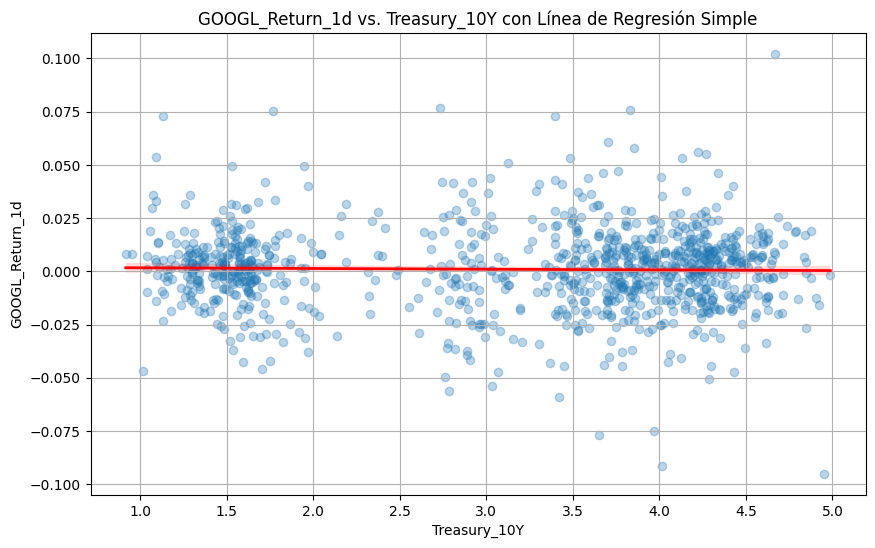

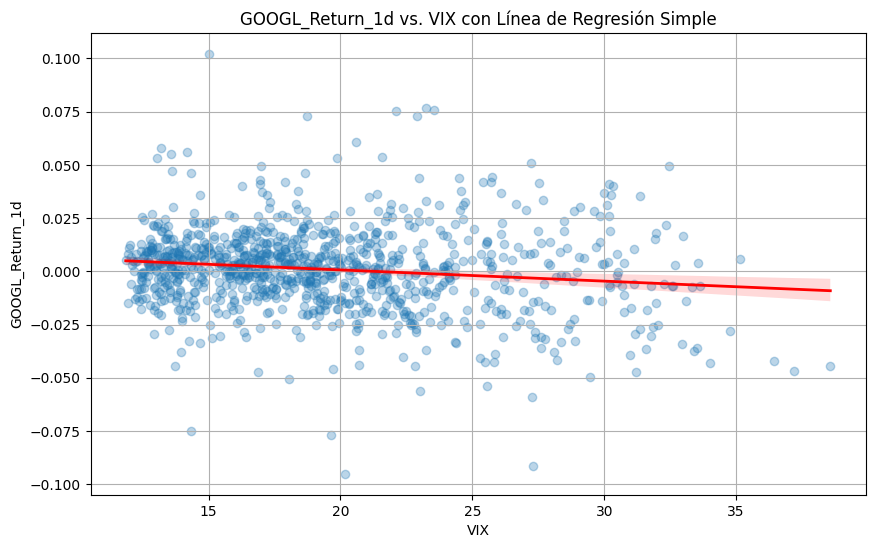

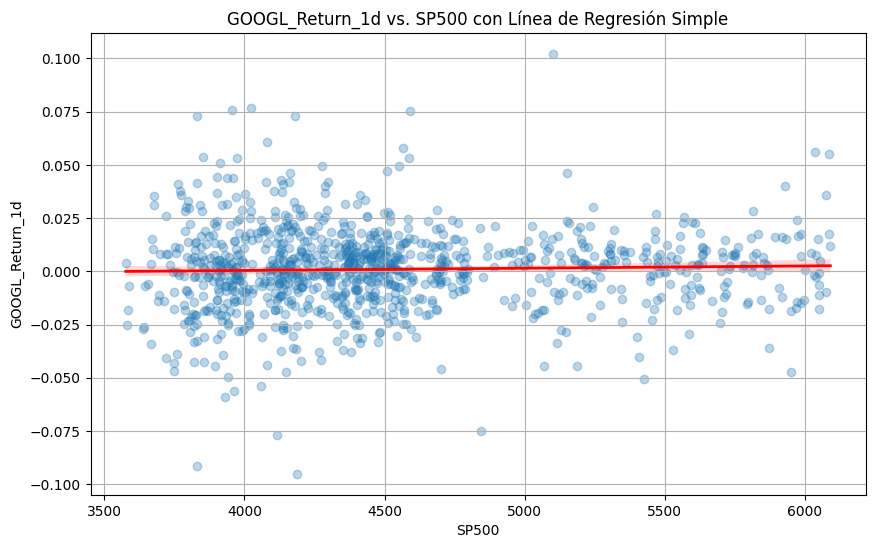

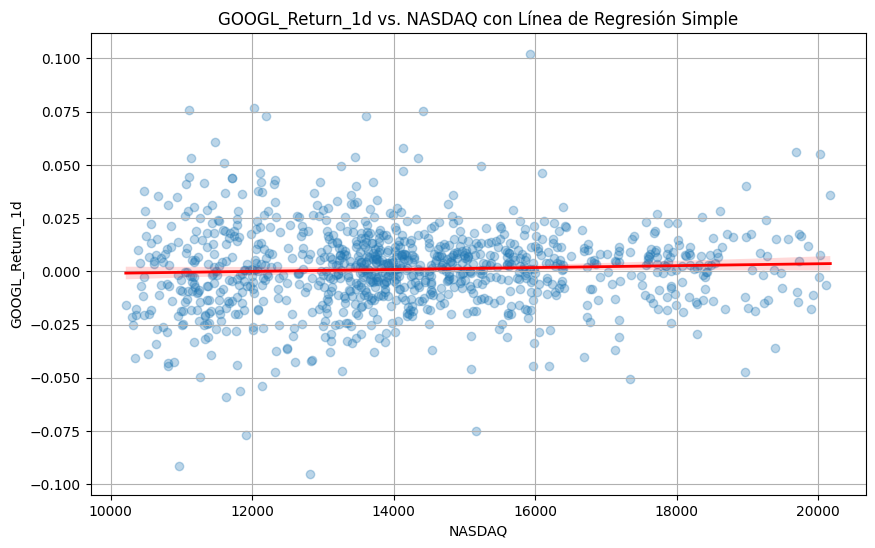

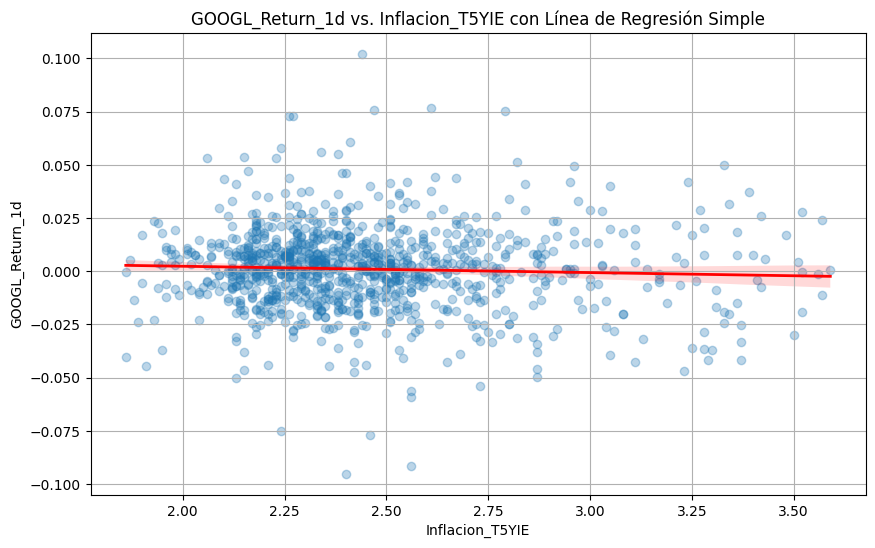

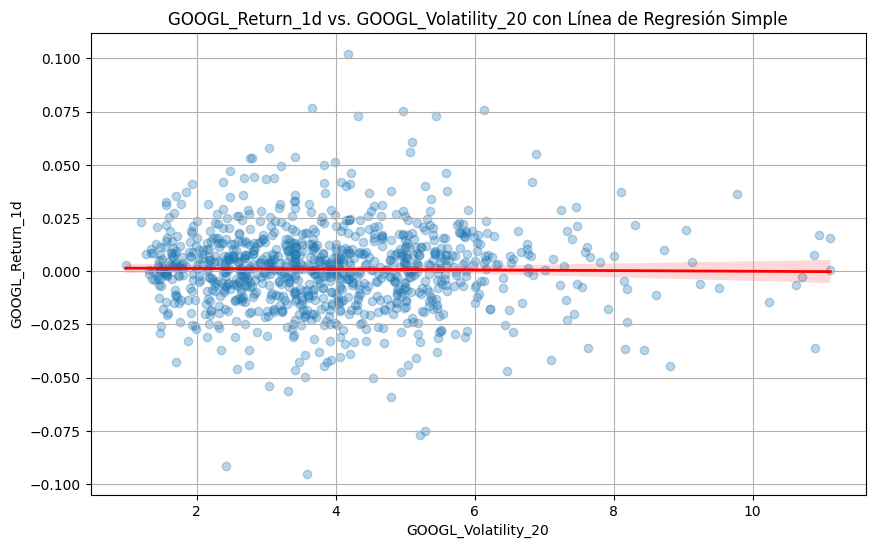

Nota: Estas gráficas muestran la relación bivariada y una línea de regresión simple para cada par.
No representan el modelo de regresión múltiple que considera todas las variables simultáneamente.

--- Gráfico de Dispersión: Valores Reales vs. Predicciones (Prueba) ---


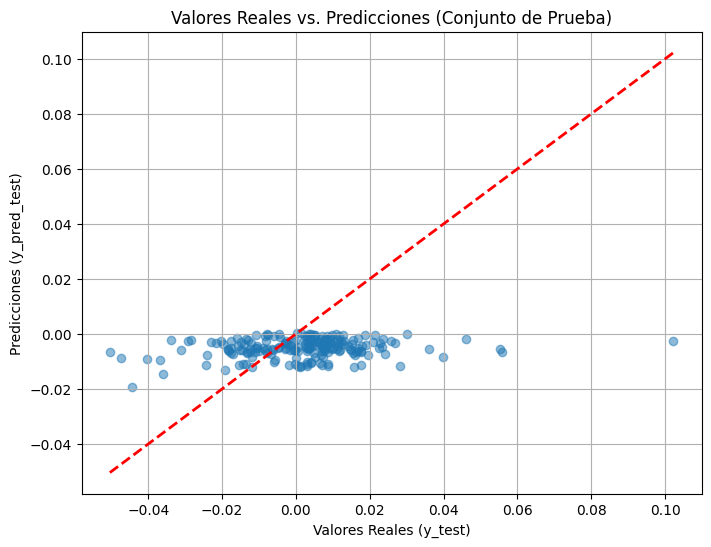

Nota: Esta gráfica muestra qué tan cerca están las predicciones de los valores reales en el conjunto de prueba.
Los puntos cercanos a la línea discontinua roja indican un buen ajuste.


In [ ]:
# --- Gráfica de Dispersión de Datos Originales con Línea de Regresión Simple (para cada feature) ---
# Esto ayuda a visualizar la relación bivariada, no el modelo de regresión múltiple completo.

print("\n--- Gráficas de Dispersión y Líneas de Regresión Simple (Datos Completos) ---")

# Usa los datos completos (limpios de nulos) para estas gráficas
df_plot = df_model # Usamos el DataFrame filtrado sin nulos

# Itera sobre cada variable independiente en X
for col in X.columns:
    plt.figure(figsize=(10, 6))
    # Usa seaborn.regplot para graficar la dispersión y la línea de regresión simple
    sns.regplot(x=df_plot[col], y=df_plot['GOOGL_Return_1d'], scatter_kws={'alpha':0.3}, line_kws={"color": "red", "lw": 2})
    plt.title(f"GOOGL_Return_1d vs. {col} con Línea de Regresión Simple")
    plt.xlabel(col)
    plt.ylabel("GOOGL_Return_1d")
    plt.grid(True)
    plt.show()

print("Nota: Estas gráficas muestran la relación bivariada y una línea de regresión simple para cada par.")
print("No representan el modelo de regresión múltiple que considera todas las variables simultáneamente.")


# --- Gráfico de Dispersión: Valores Reales vs. Predicciones (Conjunto de Prueba) ---
# Esta gráfica es la visualización estándar del ajuste del modelo de regresión MÚLTIPLE en los datos de prueba.

print("\n--- Gráfico de Dispersión: Valores Reales vs. Predicciones (Prueba) ---")

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, alpha=0.5)
# Línea y=x que representa el ajuste perfecto
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title("Valores Reales vs. Predicciones (Conjunto de Prueba)")
plt.xlabel("Valores Reales (y_test)")
plt.ylabel("Predicciones (y_pred_test)")
plt.grid(True)
plt.show()

print("Nota: Esta gráfica muestra qué tan cerca están las predicciones de los valores reales en el conjunto de prueba.")
print("Los puntos cercanos a la línea discontinua roja indican un buen ajuste.")

In [ ]:
# --- Hacer un Pronóstico con Valores Específicos ---

print("\n--- Pronóstico con Valores Específicos de Variables Independientes ---")

# Define un diccionario con los valores específicos para cada variable independiente.
# Asegúrate de que todas las variables usadas en el entrenamiento (X.columns) estén aquí.
# Estos son solo valores de ejemplo. Reemplázalos con los valores que desees pronosticar.
future_values = {
    'Treasury_10Y': 4.5,  # Ejemplo: Tasa del Tesoro a 10 años
    'VIX': 18.0,           # Ejemplo: Índice VIX
    'SP500': 5200.0,       # Ejemplo: Nivel del S&P 500
    'NASDAQ': 16500.0,     # Ejemplo: Nivel del NASDAQ
    'Inflacion_T5YIE': 2.5,# Ejemplo: Expectativa de Inflación a 5 años
    'GOOGL_Volatility_20': 0.015 # Ejemplo: Volatilidad de GOOGL (en decimal)
}

# Convierte el diccionario en un DataFrame.
# Es crucial que las columnas estén en el mismo orden que el DataFrame X original.
# Una buena práctica es crear el DataFrame con las columnas de X_train o X.
X_future_single = pd.DataFrame([future_values], columns=X.columns)


# Asegúrate de que el modelo esté entrenado (usaremos el modelo entrenado en todos los datos disponibles)
# Si no has ejecutado la sección anterior, necesitarías entrenar lr_model_full_data
# lr_model_full_data = LinearRegression()
# lr_model_full_data.fit(X, y) # Ajustar en X y y limpios (sin nulos en columnas relevantes)

# Realiza la predicción
predicted_return = lr_model_full_data.predict(X_future_single)

print("\nValores de entrada para el pronóstico:")
display(X_future_single)

print(f"\nPronóstico del Retorno Diario de GOOGL: {predicted_return[0]:.4f}")


--- Pronóstico con Valores Específicos de Variables Independientes ---

Valores de entrada para el pronóstico:


,Treasury_10Y,VIX,SP500,NASDAQ,Inflacion_T5YIE,GOOGL_Volatility_20
0,4.5000,18.0000,5200.0000,16500.0000,2.5000,0.0150



Pronóstico del Retorno Diario de GOOGL: -0.0027




--- Regresión Lineal Múltiple para GOOGL_Close ---

Datos de entrenamiento para precio: 956 filas
Datos de prueba para precio:      40 filas

--- Evaluación del Modelo de Precio (Conjunto de Prueba) ---
MAE:  2.8357
MSE:  13.3134
RMSE: 3.6488
R²:   0.8683

--- Coeficientes del Modelo de Precio (Entrenado en Entrenamiento) ---


,Variable,Coeficiente
0,GOOGL_Close_Lag1,0.9195
1,Treasury_10Y,0.2856
2,VIX,-0.0830
3,SP500,0.0001
4,NASDAQ,0.0008
5,Inflacion_T5YIE,1.3162
6,GOOGL_Volatility_20,0.0448



Intercepto: -4.0612

--- Análisis de Supuestos de Residuos (Modelo de Precio en Entrenamiento) ---

  Prueba de Jarque-Bera para Residuos de Precio:
    Estadístico: 713.4466
    Valor p:     0.0000
    ¡Advertencia: Rechazamos la hipótesis de normalidad de residuos (p < 0.05).

  Prueba de Durbin-Watson para Residuos de Precio: 1.8899
    Autocorrelación de residuos dentro del rango aceptable (cercano a 2).

--- Pronóstico Regresión Lineal para GOOGL_Close (Primeros 40 Días de 2025) ---

Tabla de Pronósticos de Precio:


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/

,Forecast_GOOGL_Close_LR
Date,
2025-01-01,191.09
2025-01-02,191.15
2025-01-03,191.20
2025-01-06,191.25
2025-01-07,191.30
2025-01-08,191.34
2025-01-09,191.38
2025-01-10,191.42
2025-01-13,191.45



Nota sobre el Pronóstico de Precio:
Este pronóstico usa los últimos valores históricos para las variables macro/técnicas y
usa la predicción del día anterior como el precio rezagado para la predicción actual.
Es una simulación de pronóstico paso a paso, pero la precisión sigue dependiendo
fuertemente de si las variables macro/técnicas se mantienen cercanas a sus últimos valores.

--- Gráfico de Dispersión: Valores Reales vs. Predicciones (Prueba de Precio) ---


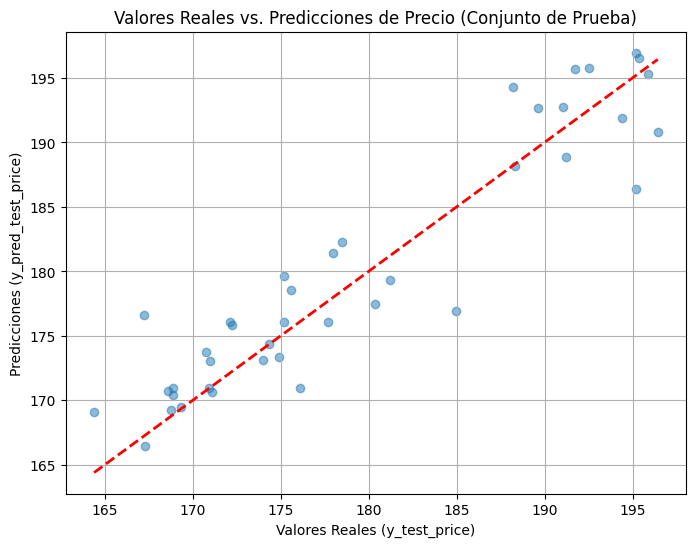


--- Gráfico de Pronóstico de Precio (Histórico + Futuro) ---


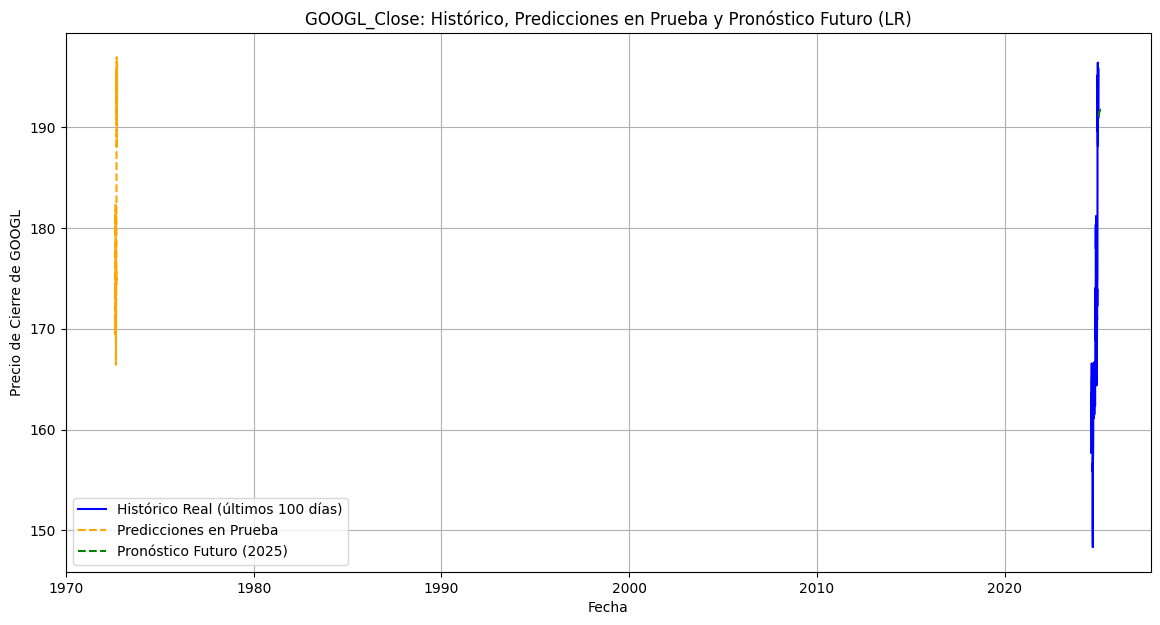

In [ ]:
# --- Regresión Lineal Múltiple para GOOGL_Close ---
print("\n\n--- Regresión Lineal Múltiple para GOOGL_Close ---")

# Asegurarse de que df está cargado y preprocesado con 'Date'
# Esto ya lo tienes en celdas anteriores, pero lo incluyo por si ejecutas esta celda sola
# import pandas as pd
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# from sklearn.model_selection import train_test_split
# import statsmodels.api as sm
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np
# from statsmodels.stats.stattools import durbin_watson, jarque_bera
# from statsmodels.stats.outliers_influence import variance_inflation_factor
# from IPython.display import display

# try:
#     df = pd.read_csv("dataset_completo_google_amazon.csv")
# except FileNotFoundError:
#     print("Error: 'dataset_completo_google_amazon.csv' no encontrado.")
#     exit()
# df['Date'] = pd.to_datetime(df['Date'])
# df = df.sort_values('Date').reset_index(drop=True)


# 1. Preparar los datos

# Crear la variable dependiente GOOGL_Close
# Variables independientes: las mismas más el precio rezagado
independent_vars_price = [
    'GOOGL_Close_Lag1', # Precio de cierre del día anterior - CRUCIAL para modelar precios
    'Treasury_10Y',
    'VIX',
    'SP500',
    'NASDAQ',
    'Inflacion_T5YIE',
    'GOOGL_Volatility_20'
]
dependent_var_price = 'GOOGL_Close'

# Crear la columna de precio rezagado si aún no existe
if 'GOOGL_Close_Lag1' not in df.columns:
    df['GOOGL_Close_Lag1'] = df['GOOGL_Close'].shift(1)

# Filtrar filas con valores nulos en las columnas relevantes
# Ahora incluimos GOOGL_Close y GOOGL_Close_Lag1 en el subset para na.drop
required_cols_price = [dependent_var_price] + independent_vars_price
missing_cols_price = [col for col in required_cols_price if col not in df.columns]
if missing_cols_price:
    print(f"Error: Faltan las siguientes columnas requeridas en el dataset para el modelo de precios: {missing_cols_price}")
    # Puedes salir o manejar el error de otra manera
    # exit()
    # Si faltan, podrías intentar crearlas si es posible (ej. 'GOOGL_Close_Lag1')
    if 'GOOGL_Close' in df.columns and 'GOOGL_Close_Lag1' not in df.columns:
         df['GOOGL_Close_Lag1'] = df['GOOGL_Close'].shift(1)
         required_cols_price = [dependent_var_price] + independent_vars_price
         missing_cols_price = [col for col in required_cols_price if col not in df.columns]
         if missing_cols_price:
             print(f"Error persistente después de crear GOOGL_Close_Lag1: Faltan {missing_cols_price}")
             exit() # Salir si todavía faltan columnas

# Eliminar filas con nulos en las columnas necesarias para el modelo de precios
df_model_price = df.dropna(subset=required_cols_price).copy()

X_price = df_model_price[independent_vars_price]
y_price = df_model_price[dependent_var_price]


# 2. División de Datos (manteniendo el orden temporal)
# Usaremos los últimos 40 días para la prueba, por ejemplo
test_set_size = 40
X_train_price, X_test_price, y_train_price, y_test_price = train_test_split(
    X_price, y_price, test_size=test_set_size, shuffle=False
)

print(f"\nDatos de entrenamiento para precio: {len(X_train_price)} filas")
print(f"Datos de prueba para precio:      {len(X_test_price)} filas")


# 3. Ajustar el modelo de regresión lineal
lr_model_price = LinearRegression()
lr_model_price.fit(X_train_price, y_train_price)


# 4. Predicciones en el conjunto de prueba
y_pred_test_price = lr_model_price.predict(X_test_price)


# 5. Evaluación del modelo en el conjunto de prueba
print("\n--- Evaluación del Modelo de Precio (Conjunto de Prueba) ---")
mae_price_test = mean_absolute_error(y_test_price, y_pred_test_price)
mse_price_test = mean_squared_error(y_test_price, y_pred_test_price)
rmse_price_test = np.sqrt(mse_price_test) # RMSE es más interpretable que MSE
r2_price_test = r2_score(y_test_price, y_pred_test_price)

print(f"MAE:  {mae_price_test:.4f}")
print(f"MSE:  {mse_price_test:.4f}")
print(f"RMSE: {rmse_price_test:.4f}")
print(f"R²:   {r2_price_test:.4f}")

# Coeficientes del modelo
coef_df_price = pd.DataFrame({
    'Variable': X_price.columns,
    'Coeficiente': lr_model_price.coef_
})
print("\n--- Coeficientes del Modelo de Precio (Entrenado en Entrenamiento) ---")
display(coef_df_price)
print(f"\nIntercepto: {lr_model_price.intercept_:.4f}")


# 6. Análisis de Supuestos de Residuos (en el conjunto de entrenamiento)
print("\n--- Análisis de Supuestos de Residuos (Modelo de Precio en Entrenamiento) ---")

residuals_train_price = y_train_price - lr_model_price.predict(X_train_price)

# Prueba de Normalidad (Jarque-Bera)
jb_test_price = jarque_bera(residuals_train_price)
print(f"\n  Prueba de Jarque-Bera para Residuos de Precio:")
print(f"    Estadístico: {jb_test_price[0]:.4f}")
print(f"    Valor p:     {jb_test_price[1]:.4f}")
if jb_test_price[1] < 0.05:
    print("    ¡Advertencia: Rechazamos la hipótesis de normalidad de residuos (p < 0.05).")
else:
    print("    No rechazamos la hipótesis de normalidad de residuos (p >= 0.05).")

# Prueba de Autocorrelación (Durbin-Watson)
dw_test_price = durbin_watson(residuals_train_price)
print(f"\n  Prueba de Durbin-Watson para Residuos de Precio: {dw_test_price:.4f}")
if dw_test_price < 1.5 or dw_test_price > 2.5:
     print("    ¡Advertencia: Posible autocorrelación en los residuos (valor alejado de 2).")
else:
     print("    Autocorrelación de residuos dentro del rango aceptable (cercano a 2).")


# 7. Pronóstico para los primeros 40 días de 2025

print("\n--- Pronóstico Regresión Lineal para GOOGL_Close (Primeros 40 Días de 2025) ---")

# Ajustar el modelo en TODOS los datos disponibles para el pronóstico futuro
lr_model_price_full_data = LinearRegression()
lr_model_price_full_data.fit(X_price, y_price) # Ajustar en X y y limpios para precio

# Determinar el rango de fechas para el pronóstico
start_date_2025 = pd.to_datetime('2025-01-01')
future_dates_price = pd.date_range(start=start_date_2025, periods=40, freq='B')

# Crear un DataFrame para las features futuras (X_future_price)
# Aquí es donde la estrategia simple de usar el último valor conocido es MÁS PROBLEMÁTICA para el precio.
# Para el PRECIO, necesitas una forma de pronosticar *todas* las variables independientes, especialmente GOOGL_Close_Lag1.
# Usar el último valor conocido para GOOGL_Close_Lag1 significaría predecir que el precio se mantendrá casi constante,
# lo cual no es realista.
# Una estrategia más razonable para predecir el PRECIO usando este modelo sería:
# A) Predecir las variables macro/técnicas (Treasury_10Y, VIX, etc.) con otros modelos o fuentes.
# B) Para GOOGL_Close_Lag1, usar la PREDICCIÓN del día anterior. Esto crea una dependencia autorregresiva.

# Implementaremos la estrategia B (autorregresiva para GOOGL_Close_Lag1), usando los últimos valores conocidos para las otras features.

X_future_price = pd.DataFrame(index=future_dates_price, columns=independent_vars_price)
X_future_price.index.name = 'Date'

# Usar los últimos valores conocidos para las variables que no son el lag del precio
last_known_features_other = df_model_price[independent_vars_price].iloc[-1].drop('GOOGL_Close_Lag1').to_dict()

# Poblar las columnas correspondientes en X_future_price con estos últimos valores
for col, val in last_known_features_other.items():
    X_future_price[col] = val

# Ahora, el pronóstico se convierte en un bucle paso a paso:
# La predicción del día t+1 depende de la predicción del día t para GOOGL_Close_Lag1.

last_known_close = df_model_price['GOOGL_Close'].iloc[-1] # Último precio real conocido

forecast_values_price = []

# Asegurarse de que X_future_price tiene las columnas en el orden correcto antes de predecir
X_future_price = X_future_price[independent_vars_price]

for i in range(len(future_dates_price)):
    # Para el primer día del pronóstico, el lag es el último precio real conocido
    if i == 0:
        X_future_price.iloc[i, X_future_price.columns.get_loc('GOOGL_Close_Lag1')] = last_known_close
    else:
        # Para días subsiguientes, el lag es la predicción del día anterior
        X_future_price.iloc[i, X_future_price.columns.get_loc('GOOGL_Close_Lag1')] = forecast_values_price[-1]

    # Realizar la predicción para el día actual
    # predict espera un array 2D (o DataFrame)
    current_forecast = lr_model_price_full_data.predict(X_future_price.iloc[i].values.reshape(1, -1))

    forecast_values_price.append(current_forecast[0])

# Crear un DataFrame para mostrar el pronóstico
forecast_df_price_2025 = pd.DataFrame({
    'Date': future_dates_price,
    'Forecast_GOOGL_Close_LR': forecast_values_price
})
forecast_df_price_2025.set_index('Date', inplace=True)

print("\nTabla de Pronósticos de Precio:")
pd.options.display.float_format = '{:.2f}'.format # Formato para visualización de precios
display(forecast_df_price_2025)

print("\nNota sobre el Pronóstico de Precio:")
print("Este pronóstico usa los últimos valores históricos para las variables macro/técnicas y")
print("usa la predicción del día anterior como el precio rezagado para la predicción actual.")
print("Es una simulación de pronóstico paso a paso, pero la precisión sigue dependiendo")
print("fuertemente de si las variables macro/técnicas se mantienen cercanas a sus últimos valores.")


# --- Gráfico de Dispersión: Valores Reales vs. Predicciones (Conjunto de Prueba de Precio) ---
print("\n--- Gráfico de Dispersión: Valores Reales vs. Predicciones (Prueba de Precio) ---")

plt.figure(figsize=(8, 6))
plt.scatter(y_test_price, y_pred_test_price, alpha=0.5)
plt.plot([y_test_price.min(), y_test_price.max()], [y_test_price.min(), y_test_price.max()], 'r--', lw=2) # Línea y=x
plt.title("Valores Reales vs. Predicciones de Precio (Conjunto de Prueba)")
plt.xlabel("Valores Reales (y_test_price)")
plt.ylabel("Predicciones (y_pred_test_price)")
plt.grid(True)
plt.show()

# --- Gráfico de Pronóstico de Precio (Histórico + Futuro) ---
print("\n--- Gráfico de Pronóstico de Precio (Histórico + Futuro) ---")

plt.figure(figsize=(14, 7))
# Graficar datos históricos reales (solo los últimos días para contexto)
plt.plot(df_model_price['Date'].iloc[-100:], df_model_price['GOOGL_Close'].iloc[-100:], label='Histórico Real (últimos 100 días)', color='blue')
# Graficar predicciones en el conjunto de prueba
plt.plot(X_test_price.index, y_pred_test_price, label='Predicciones en Prueba', color='orange', linestyle='--')
# Graficar pronóstico futuro
plt.plot(future_dates_price, forecast_values_price, label='Pronóstico Futuro (2025)', color='green', linestyle='--')

plt.title("GOOGL_Close: Histórico, Predicciones en Prueba y Pronóstico Futuro (LR)")
plt.xlabel("Fecha")
plt.ylabel("Precio de Cierre de GOOGL")
plt.legend()
plt.grid(True)
plt.show()

# Restablecer la opción de formato de pandas si es necesario
# pd.reset_option('display.float_format')

In [ ]:
# --- Pronóstico de Precio con Valores Específicos ---

print("\n--- Pronóstico de Precio con Valores Específicos de Variables Independientes ---")

# Define un diccionario con los valores específicos para cada variable independiente.
# Asegúrate de que todas las variables usadas en el entrenamiento (X_price.columns) estén aquí.
# Esto incluye el precio rezagado (GOOGL_Close_Lag1).
# **Importante:** Para un pronóstico de un solo paso, GOOGL_Close_Lag1 sería el último precio real conocido.
# Para pronósticos de múltiples pasos, necesitarías una estrategia (ej. usar la predicción del día anterior).
# Para este ejemplo, usaremos un valor específico para GOOGL_Close_Lag1 como si fuera el último precio conocido.
last_known_close = df_model_price['GOOGL_Close'].iloc[-1] # Último precio real conocido

future_values_price_specific = {
    'GOOGL_Close_Lag1': last_known_close, # Usamos el último precio real conocido como el lag
    'Treasury_10Y': 4.2,  # Ejemplo: Tasa del Tesoro a 10 años en el día futuro
    'VIX': 15.0,           # Ejemplo: Índice VIX en el día futuro
    'SP500': 5300.0,       # Ejemplo: Nivel del S&P 500 en el día futuro
    'NASDAQ': 17000.0,     # Ejemplo: Nivel del NASDAQ en el día futuro
    'Inflacion_T5YIE': 2.3,# Ejemplo: Expectativa de Inflación a 5 años en el día futuro
    'GOOGL_Volatility_20': 0.012 # Ejemplo: Volatilidad de GOOGL (en decimal) en el día futuro
}

# 1. Usando el método predict() del modelo

# Convierte el diccionario en un DataFrame.
# Es crucial que las columnas estén en el mismo orden que el DataFrame X_price original.
X_future_price_single = pd.DataFrame([future_values_price_specific], columns=X_price.columns)

# Asegúrate de que el modelo 'lr_model_price_full_data' está entrenado.
# Si no has ejecutado la sección anterior, descomenta y ejecuta las líneas de entrenamiento:
# lr_model_price_full_data = LinearRegression()
# lr_model_price_full_data.fit(X_price, y_price) # Ajustar en X_price y y_price limpios

# Realiza la predicción usando predict
predicted_price_method1 = lr_model_price_full_data.predict(X_future_price_single)

print("\nValores de entrada para el pronóstico (Método 1 - predict):")
display(X_future_price_single)
print(f"\nPronóstico del Precio de Cierre de GOOGL (Método 1 - predict): {predicted_price_method1[0]:.2f}")


# 2. Usando la ecuación de regresión manualmente

# Obtén los coeficientes y el intercepto del modelo entrenado
intercept_price = lr_model_price_full_data.intercept_
coefs_price = lr_model_price_full_data.coef_

# Calcula la predicción manualmente
predicted_price_method2 = intercept_price

# Suma el producto de cada coeficiente por el valor correspondiente de la variable independiente
for i, col in enumerate(X_price.columns):
    predicted_price_method2 += coefs_price[i] * future_values_price_specific[col]

print("\nCálculo manual del Pronóstico (Método 2 - Ecuación):")
print(f"  Intercepto: {intercept_price:.4f}")
print("  Suma de (Coeficiente * Valor):")
for i, col in enumerate(X_price.columns):
     print(f"    {coefs_price[i]:.4f} * {future_values_price_specific[col]:.4f} = {coefs_price[i] * future_values_price_specific[col]:.4f}")

print(f"\nPronóstico del Precio de Cierre de GOOGL (Método 2 - Ecuación): {predicted_price_method2:.2f}")

# Verificación (deberían ser casi idénticos)
print(f"\nDiferencia entre métodos: {predicted_price_method1[0] - predicted_price_method2:.6f}")


--- Pronóstico de Precio con Valores Específicos de Variables Independientes ---

Valores de entrada para el pronóstico (Método 1 - predict):


,GOOGL_Close_Lag1,Treasury_10Y,VIX,SP500,NASDAQ,Inflacion_T5YIE,GOOGL_Volatility_20
0,191.02,4.20,15.00,5300.00,17000.00,2.30,0.01



Pronóstico del Precio de Cierre de GOOGL (Método 1 - predict): 188.77

Cálculo manual del Pronóstico (Método 2 - Ecuación):
  Intercepto: -3.2952
  Suma de (Coeficiente * Valor):
    0.9195 * 191.0200 = 175.6520
    0.2703 * 4.2000 = 1.1354
    -0.0924 * 15.0000 = -1.3855
    -0.0000 * 5300.0000 = -0.2003
    0.0008 * 17000.0000 = 13.8293
    1.3195 * 2.3000 = 3.0349
    0.0397 * 0.0120 = 0.0005

Pronóstico del Precio de Cierre de GOOGL (Método 2 - Ecuación): 188.77

Diferencia entre métodos: 0.000000




--- Regresión Ridge para GOOGL_Close ---

Datos de entrenamiento para precio (Ridge): 956 filas
Datos de prueba para precio (Ridge):      40 filas

--- Evaluación del Modelo Ridge (Conjunto de Prueba) ---
MAE:  2.8518
MSE:  13.3694
RMSE: 3.6564
R²:   0.8678

--- Coeficientes del Modelo Ridge (Datos Escaldos, Entrenado en Entrenamiento) ---


,Variable,Coeficiente (escalado)
0,GOOGL_Close_Lag1,21.62
1,Treasury_10Y,0.37
2,VIX,-0.44
3,SP500,0.08
4,NASDAQ,1.80
5,Inflacion_T5YIE,0.47
6,GOOGL_Volatility_20,0.07



Intercepto: 127.7172

--- Pronóstico Ridge para GOOGL_Close (Primeros 40 Días de 2025) ---

Tabla de Pronósticos de Precio (Ridge):


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does n

,Forecast_GOOGL_Close_Ridge
Date,
2025-01-01,188.52
2025-01-02,186.24
2025-01-03,184.16
2025-01-06,182.27
2025-01-07,180.55
2025-01-08,178.98
2025-01-09,177.55
2025-01-10,176.25
2025-01-13,175.06



Nota sobre el Pronóstico de Precio (Ridge):
Este pronóstico usa un modelo Ridge entrenado en datos escalados.
Usa una estrategia recursiva donde el precio rezagado futuro es la predicción del día anterior.
Las variables macro/técnicas futuras se asumen como valores específicos definidos en el código.

--- Gráfico de Pronóstico de Precio (Histórico + Futuro - Ridge) ---


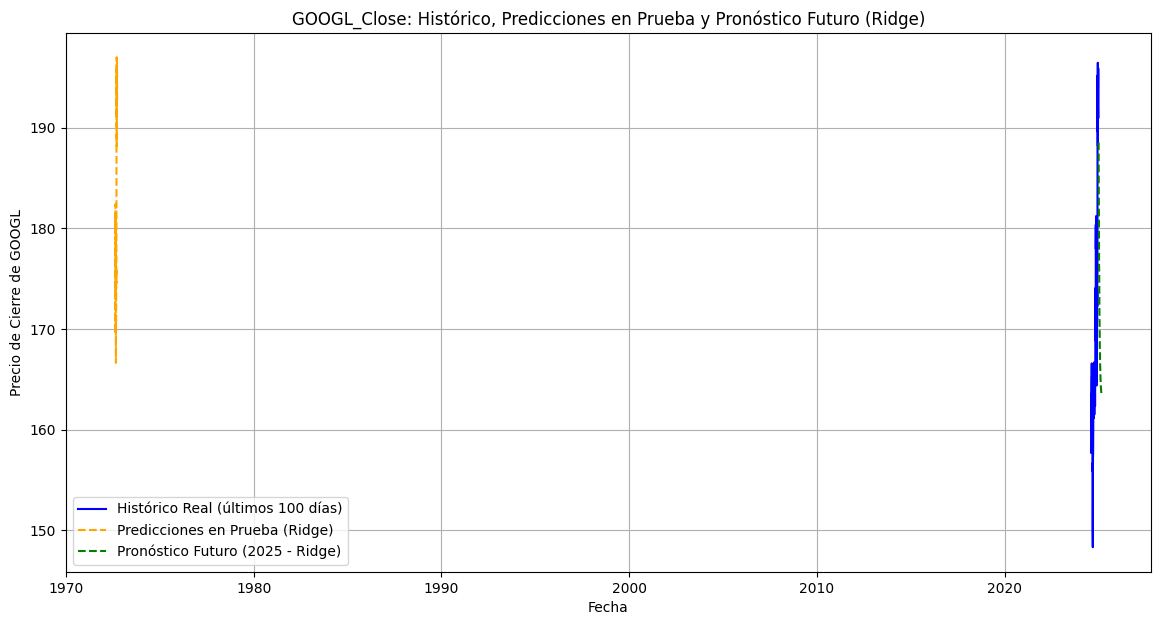

In [ ]:
# --- Regresión Ridge para GOOGL_Close ---
print("\n\n--- Regresión Ridge para GOOGL_Close ---")

# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler # Para escalar los datos
from sklearn.linear_model import Ridge # Importar Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from statsmodels.stats.outliers_influence import variance_inflation_factor
from IPython.display import display

# Cargar datos (asegúrate de que df está cargado y preprocesado con 'Date' y 'GOOGL_Close_Lag1')
# Si estás ejecutando esta celda sola, descomenta y ejecuta el código de carga y preprocesamiento básico:
try:
    df = pd.read_csv("dataset_completo_google_amazon.csv")
except FileNotFoundError:
    print("Error: 'dataset_completo_google_amazon.csv' no encontrado.")
    exit()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
if 'GOOGL_Close_Lag1' not in df.columns:
    df['GOOGL_Close_Lag1'] = df['GOOGL_Close'].shift(1)


# Definir variables dependientes e independientes para el modelo de precio
independent_vars_price = [
    'GOOGL_Close_Lag1',
    'Treasury_10Y',
    'VIX',
    'SP500',
    'NASDAQ',
    'Inflacion_T5YIE',
    'GOOGL_Volatility_20'
]
dependent_var_price = 'GOOGL_Close'

# Eliminar filas con nulos en las columnas necesarias
required_cols_price = [dependent_var_price] + independent_vars_price
df_model_price = df.dropna(subset=required_cols_price).copy()

X_price = df_model_price[independent_vars_price]
y_price = df_model_price[dependent_var_price]


# 1. División de Datos (manteniendo el orden temporal)
test_set_size = 40 # Usaremos los últimos 40 días para la prueba
X_train_price, X_test_price, y_train_price, y_test_price = train_test_split(
    X_price, y_price, test_size=test_set_size, shuffle=False
)

print(f"\nDatos de entrenamiento para precio (Ridge): {len(X_train_price)} filas")
print(f"Datos de prueba para precio (Ridge):      {len(X_test_price)} filas")


# 2. Escalar las variables independientes
# Instanciar el escalador
scaler = StandardScaler()

# Ajustar el escalador SOLO en los datos de entrenamiento y transformar
X_train_scaled = scaler.fit_transform(X_train_price)
# Transformar los datos de prueba usando el escalador ajustado en el entrenamiento
X_test_scaled = scaler.transform(X_test_price)

# Convertir de nuevo a DataFrame para mantener los nombres de las columnas (opcional pero útil)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_price.columns, index=X_train_price.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test_price.columns, index=X_test_price.index)


# 3. Ajustar el modelo Ridge
# alpha es el hiperparámetro de regularización. Debes sintonizarlo.
# Un valor de 1.0 es el valor por defecto y un buen punto de partida.
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train_price) # Ajustar en datos ESCALADOS


# 4. Predicciones en el conjunto de prueba (con datos escalados)
y_pred_test_ridge = ridge_model.predict(X_test_scaled)


# 5. Evaluación del modelo
print("\n--- Evaluación del Modelo Ridge (Conjunto de Prueba) ---")
mae_price_test_ridge = mean_absolute_error(y_test_price, y_pred_test_ridge)
mse_price_test_ridge = mean_squared_error(y_test_price, y_pred_test_ridge)
rmse_price_test_ridge = np.sqrt(mse_price_test_ridge)
r2_price_test_ridge = r2_score(y_test_price, y_pred_test_ridge)

print(f"MAE:  {mae_price_test_ridge:.4f}")
print(f"MSE:  {mse_price_test_ridge:.4f}")
print(f"RMSE: {rmse_price_test_ridge:.4f}")
print(f"R²:   {r2_price_test_ridge:.4f}")

# Coeficientes del modelo (sobre datos ESCALADOS)
coef_df_price_ridge = pd.DataFrame({
    'Variable': X_price.columns,
    'Coeficiente (escalado)': ridge_model.coef_
})
print("\n--- Coeficientes del Modelo Ridge (Datos Escaldos, Entrenado en Entrenamiento) ---")
display(coef_df_price_ridge)
print(f"\nIntercepto: {ridge_model.intercept_:.4f}")
# Nota: Los coeficientes son para los datos escalados. Su interpretación directa es menos intuitiva.
# Sin embargo, sus magnitudes relativas dan una idea de la importancia en la escala estandarizada.


# 6. Pronóstico para los primeros 40 días de 2025

print("\n--- Pronóstico Ridge para GOOGL_Close (Primeros 40 Días de 2025) ---")

# Ajustar el modelo Ridge en TODOS los datos DISPONIBLES (escalados) para el pronóstico futuro
# Primero, escalar TODAS las variables independientes
X_price_scaled_full = scaler.fit_transform(X_price) # RE-AJUSTAR scaler en todos los datos X
X_price_scaled_full = pd.DataFrame(X_price_scaled_full, columns=X_price.columns, index=X_price.index)

# Ajustar el modelo Ridge en los datos ESCALADOS completos
ridge_model_full_data = Ridge(alpha=1.0) # Usamos el mismo alpha por simplicidad, idealmente sintonizar en todos los datos
ridge_model_full_data.fit(X_price_scaled_full, y_price)

# Determinar el rango de fechas para el pronóstico
start_date_2025 = pd.to_datetime('2025-01-01')
future_dates_price = pd.date_range(start=start_date_2025, periods=40, freq='B')

# Crear DataFrame para las features futuras (X_future_price)
# Implementaremos la estrategia autorregresiva y usaremos los últimos valores conocidos ESCALADOS
# para las variables que no son el lag del precio.

X_future_price_ridge = pd.DataFrame(index=future_dates_price, columns=independent_vars_price)
X_future_price_ridge.index.name = 'Date'

# Usar los últimos valores conocidos (NO ESCALADOS inicialmente) para las variables que no son el lag
last_known_features_other_raw = df_model_price[independent_vars_price].iloc[-1].drop('GOOGL_Close_Lag1').to_dict()
last_known_close_raw = df_model_price['GOOGL_Close'].iloc[-1] # Último precio real conocido (NO ESCALADO)

forecast_values_price_ridge = []

# Prepara un DataFrame temporal para escalar los valores futuros
# Incluimos el lag y las otras variables para poder escalarlas juntas correctamente
temp_future_features = pd.DataFrame(columns=independent_vars_price)


for i in range(len(future_dates_price)):
    # Para el primer día, el lag es el último precio real conocido
    if i == 0:
        current_lag_raw = last_known_close_raw
    else:
        # Para días subsiguientes, el lag es la PREDICCIÓN (NO ESCALADA) del día anterior
        current_lag_raw = forecast_values_price_ridge[-1]

    # Crear la fila de features futuras en formato RAW (no escalado)
    current_future_row_raw = future_values_price_specific.copy() # Usamos los mismos valores específicos que antes para las macro, pero podríamos usar los últimos RAW si quisiéramos
    current_future_row_raw['GOOGL_Close_Lag1'] = current_lag_raw # Insertar el lag RAW actual

    # Convertir a DataFrame para escalar
    current_future_df_raw = pd.DataFrame([current_future_row_raw], columns=independent_vars_price)

    # ESCALAR la fila de features futuras usando el scaler ajustado en TODOS los datos históricos
    # Es crucial que el orden de las columnas sea el mismo que X_price_scaled_full
    current_future_scaled = scaler.transform(current_future_df_raw[X_price_scaled_full.columns])

    # Realizar la predicción para el día actual (usando datos ESCALADOS)
    current_forecast_scaled = ridge_model_full_data.predict(current_future_scaled)

    # La predicción resultante (current_forecast_scaled) ya está en la escala original de 'y_price'
    forecast_values_price_ridge.append(current_forecast_scaled[0])

# Crear un DataFrame para mostrar el pronóstico
forecast_df_price_2025_ridge = pd.DataFrame({
    'Date': future_dates_price,
    'Forecast_GOOGL_Close_Ridge': forecast_values_price_ridge
})
forecast_df_price_2025_ridge.set_index('Date', inplace=True)

print("\nTabla de Pronósticos de Precio (Ridge):")
pd.options.display.float_format = '{:.2f}'.format # Formato para visualización de precios
display(forecast_df_price_2025_ridge)

print("\nNota sobre el Pronóstico de Precio (Ridge):")
print("Este pronóstico usa un modelo Ridge entrenado en datos escalados.")
print("Usa una estrategia recursiva donde el precio rezagado futuro es la predicción del día anterior.")
print("Las variables macro/técnicas futuras se asumen como valores específicos definidos en el código.")


# --- Gráfico de Pronóstico de Precio (Histórico + Futuro - Ridge) ---
print("\n--- Gráfico de Pronóstico de Precio (Histórico + Futuro - Ridge) ---")

plt.figure(figsize=(14, 7))
# Graficar datos históricos reales (solo los últimos días para contexto)
plt.plot(df_model_price['Date'].iloc[-100:], df_model_price['GOOGL_Close'].iloc[-100:], label='Histórico Real (últimos 100 días)', color='blue')
# Graficar predicciones en el conjunto de prueba
# Asegúrate de que X_test_price.index tiene las fechas correctas
plt.plot(X_test_price.index, y_pred_test_ridge, label='Predicciones en Prueba (Ridge)', color='orange', linestyle='--')
# Graficar pronóstico futuro
plt.plot(future_dates_price, forecast_values_price_ridge, label='Pronóstico Futuro (2025 - Ridge)', color='green', linestyle='--')

plt.title("GOOGL_Close: Histórico, Predicciones en Prueba y Pronóstico Futuro (Ridge)")
plt.xlabel("Fecha")
plt.ylabel("Precio de Cierre de GOOGL")
plt.legend()
plt.grid(True)
plt.show()

# Restablecer la opción de formato de pandas si es necesario
# pd.reset_option('display.float_format')



--- Regresión Lasso para GOOGL_Close ---

Datos de entrenamiento para precio (Lasso): 956 filas
Datos de prueba para precio (Lasso):      40 filas

--- Evaluación del Modelo Lasso (Conjunto de Prueba) ---
MAE:  2.8265
MSE:  13.2693
RMSE: 3.6427
R²:   0.8688

--- Coeficientes del Modelo Lasso (Datos Escaldos, Entrenado en Entrenamiento) ---


,Variable,Coeficiente (escalado)
0,GOOGL_Close_Lag1,21.86
1,Treasury_10Y,0.26
2,VIX,-0.43
3,SP500,0.17
4,NASDAQ,1.49
5,Inflacion_T5YIE,0.38
6,GOOGL_Volatility_20,0.06



Intercepto: 127.7172

--- Pronóstico Lasso para GOOGL_Close (Primeros 40 Días de 2025) ---

Tabla de Pronósticos de Precio (Lasso):


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does n

,Forecast_GOOGL_Close_Lasso
Date,
2025-01-01,191.00
2025-01-02,190.99
2025-01-03,190.98
2025-01-06,190.97
2025-01-07,190.96
2025-01-08,190.94
2025-01-09,190.94
2025-01-10,190.93
2025-01-13,190.92



Nota sobre el Pronóstico de Precio (Lasso):
Este pronóstico usa un modelo Lasso entrenado en datos escalados.
Usa una estrategia recursiva donde el precio rezagado futuro es la predicción del día anterior.
Las variables macro/técnicas futuras se asumen iguales a sus últimos valores históricos conocidos.

--- Gráfico de Pronóstico de Precio (Histórico + Futuro - Lasso) ---


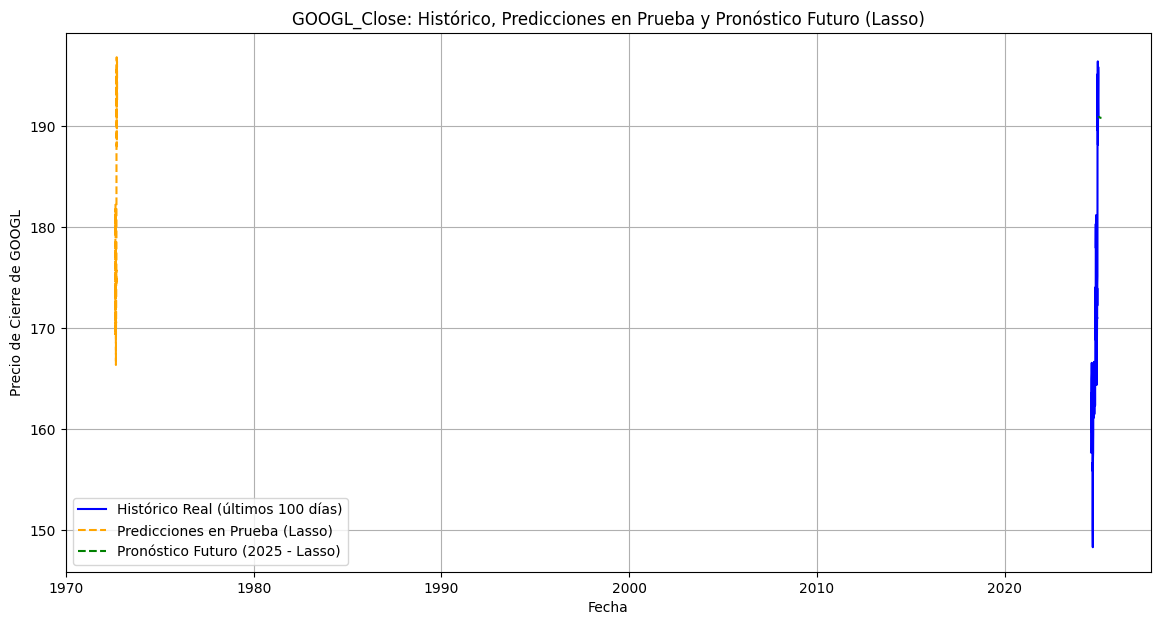

In [ ]:
# --- Regresión Lasso para GOOGL_Close ---
print("\n\n--- Regresión Lasso para GOOGL_Close ---")

# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler # Para escalar los datos
from sklearn.linear_model import Lasso # Importar Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from statsmodels.stats.outliers_influence import variance_inflation_factor
from IPython.display import display

# Cargar datos (asegúrate de que df está cargado y preprocesado con 'Date' y 'GOOGL_Close_Lag1')
# Si estás ejecutando esta celda sola, descomenta y ejecuta el código de carga y preprocesamiento básico:
try:
    df = pd.read_csv("dataset_completo_google_amazon.csv")
except FileNotFoundError:
    print("Error: 'dataset_completo_google_amazon.csv' no encontrado.")
    exit()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
if 'GOOGL_Close_Lag1' not in df.columns:
    df['GOOGL_Close_Lag1'] = df['GOOGL_Close'].shift(1)


# Definir variables dependientes e independientes para el modelo de precio
independent_vars_price = [
    'GOOGL_Close_Lag1',
    'Treasury_10Y',
    'VIX',
    'SP500',
    'NASDAQ',
    'Inflacion_T5YIE',
    'GOOGL_Volatility_20'
]
dependent_var_price = 'GOOGL_Close'

# Eliminar filas con nulos en las columnas necesarias
required_cols_price = [dependent_var_price] + independent_vars_price
df_model_price = df.dropna(subset=required_cols_price).copy()

X_price = df_model_price[independent_vars_price]
y_price = df_model_price[dependent_var_price]


# 1. División de Datos (manteniendo el orden temporal)
test_set_size = 40 # Usaremos los últimos 40 días para la prueba
X_train_price, X_test_price, y_train_price, y_test_price = train_test_split(
    X_price, y_price, test_size=test_set_size, shuffle=False # **CORREGIDO: Usar test_size**
)

print(f"\nDatos de entrenamiento para precio (Lasso): {len(X_train_price)} filas")
print(f"Datos de prueba para precio (Lasso):      {len(X_test_price)} filas")


# 2. Escalar las variables independientes
# Instanciar el escalador
scaler = StandardScaler()

# Ajustar el escalador SOLO en los datos de entrenamiento y transformar
X_train_scaled = scaler.fit_transform(X_train_price)
# Transformar los datos de prueba usando el escalador ajustado en el entrenamiento
X_test_scaled = scaler.transform(X_test_price)

# Convertir de nuevo a DataFrame para mantener los nombres de las columnas (opcional pero útil)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_price.columns, index=X_train_price.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test_price.columns, index=X_test_price.index)


# 3. Ajustar el modelo Lasso
# alpha es el hiperparámetro de regularización. Debes sintonizarlo.
# alpha=1.0 es un punto de partida, pero puede necesitar ser mucho más pequeño para datos financieros.
# A veces, un alpha demasiado alto puede hacer que Lasso ponga demasiados coeficientes a zero,
# incluso el del precio rezagado, lo cual no sería deseable para el modelo de precio.
lasso_model = Lasso(alpha=0.01, max_iter=10000) # Reducimos alpha y aumentamos max_iter si converge lento
lasso_model.fit(X_train_scaled, y_train_price) # Ajustar en datos ESCALADOS


# 4. Predicciones en el conjunto de prueba (con datos escalados)
y_pred_test_lasso = lasso_model.predict(X_test_scaled)


# 5. Evaluación del modelo
print("\n--- Evaluación del Modelo Lasso (Conjunto de Prueba) ---")
mae_price_test_lasso = mean_absolute_error(y_test_price, y_pred_test_lasso)
mse_price_test_lasso = mean_squared_error(y_test_price, y_pred_test_lasso)
rmse_price_test_lasso = np.sqrt(mse_price_test_lasso)
r2_price_test_lasso = r2_score(y_test_price, y_pred_test_lasso)

print(f"MAE:  {mae_price_test_lasso:.4f}")
print(f"MSE:  {mse_price_test_lasso:.4f}")
print(f"RMSE: {rmse_price_test_lasso:.4f}")
print(f"R²:   {r2_price_test_lasso:.4f}")

# Coeficientes del modelo (sobre datos ESCALADOS)
coef_df_price_lasso = pd.DataFrame({
    'Variable': X_price.columns,
    'Coeficiente (escalado)': lasso_model.coef_
})
print("\n--- Coeficientes del Modelo Lasso (Datos Escaldos, Entrenado en Entrenamiento) ---")
display(coef_df_price_lasso)
# Observa qué coeficientes se han reducido a cero.
print(f"\nIntercepto: {lasso_model.intercept_:.4f}")


# 6. Pronóstico para los primeros 40 días de 2025

print("\n--- Pronóstico Lasso para GOOGL_Close (Primeros 40 Días de 2025) ---")

# Ajustar el modelo Lasso en TODOS los datos DISPONIBLES (escalados) para el pronóstico futuro
# Primero, escalar TODAS las variables independientes
# IMPORTANTE: Usar el MISMO escalador ajustado previamente o RE-AJUSTAR en TODOS los datos X
# Para pronósticos, es mejor ajustar en todos los datos históricos disponibles
scaler_full_data = StandardScaler()
X_price_scaled_full = scaler_full_data.fit_transform(X_price)
X_price_scaled_full = pd.DataFrame(X_price_scaled_full, columns=X_price.columns, index=X_price.index)


# Ajustar el modelo Lasso en los datos ESCALADOS completos
# Usamos el mismo alpha=0.01 (idealmente, sintonizar alpha en todos los datos)
lasso_model_full_data = Lasso(alpha=0.01, max_iter=10000)
lasso_model_full_data.fit(X_price_scaled_full, y_price)


# Determinar el rango de fechas para el pronóstico
start_date_2025 = pd.to_datetime('2025-01-01')
future_dates_price = pd.date_range(start=start_date_2025, periods=40, freq='B')

# Crear DataFrame para las features futuras (X_future_price) - RAW (no escalado) inicialmente
# We don't need this DataFrame initialized fully upfront as we build row by row
# X_future_price_lasso_raw = pd.DataFrame(index=future_dates_price, columns=independent_vars_price)
# X_future_price_lasso_raw.index.name = 'Date'

# Usar los últimos valores conocidos (NO ESCALADOS) para las variables que no son el lag
last_known_features_other_raw = df_model_price[independent_vars_price].iloc[-1].drop('GOOGL_Close_Lag1').to_dict()
last_known_close_raw = df_model_price['GOOGL_Close'].iloc[-1] # Último precio real conocido (NO ESCALADO)

forecast_values_price_lasso = []

# Prepara un diccionario temporal para construir la fila de features futuras RAW
temp_future_row_raw = last_known_features_other_raw.copy()


for i in range(len(future_dates_price)):
    # Para el primer día, el lag es el último precio real conocido
    if i == 0:
        current_lag_raw = last_known_close_raw
    else:
        # Para días subsiguientes, el lag es la PREDICCIÓN (NO ESCALADA) del día anterior
        current_lag_raw = forecast_values_price_lasso[-1]

    # Actualizar el valor del lag en el diccionario temporal
    temp_future_row_raw['GOOGL_Close_Lag1'] = current_lag_raw

    # Convertir el diccionario temporal a DataFrame para escalar. Asegurarse del orden correcto de columnas.
    current_future_df_raw = pd.DataFrame([temp_future_row_raw], columns=X_price_scaled_full.columns)

    # ESCALAR la fila de features futuras usando el scaler ajustado en TODOS los datos históricos
    current_future_scaled = scaler_full_data.transform(current_future_df_raw)

    # Realizar la predicción para el día actual (usando datos ESCALADOS)
    current_forecast_scaled = lasso_model_full_data.predict(current_future_scaled)

    # La predicción resultante (current_forecast_scaled) ya está en la escala original de 'y_price'
    forecast_values_price_lasso.append(current_forecast_scaled[0])

# Crear un DataFrame para mostrar el pronóstico
forecast_df_price_2025_lasso = pd.DataFrame({
    'Date': future_dates_price,
    'Forecast_GOOGL_Close_Lasso': forecast_values_price_lasso
})
forecast_df_price_2025_lasso.set_index('Date', inplace=True)

print("\nTabla de Pronósticos de Precio (Lasso):")
pd.options.display.float_format = '{:.2f}'.format # Formato para visualización de precios
display(forecast_df_price_2025_lasso)

print("\nNota sobre el Pronóstico de Precio (Lasso):")
print("Este pronóstico usa un modelo Lasso entrenado en datos escalados.")
print("Usa una estrategia recursiva donde el precio rezagado futuro es la predicción del día anterior.")
print("Las variables macro/técnicas futuras se asumen iguales a sus últimos valores históricos conocidos.")


# --- Gráfico de Pronóstico de Precio (Histórico + Futuro - Lasso) ---
print("\n--- Gráfico de Pronóstico de Precio (Histórico + Futuro - Lasso) ---")

plt.figure(figsize=(14, 7))
# Graficar datos históricos reales (solo los últimos días para contexto)
plt.plot(df_model_price['Date'].iloc[-100:], df_model_price['GOOGL_Close'].iloc[-100:], label='Histórico Real (últimos 100 días)', color='blue')
# Graficar predicciones en el conjunto de prueba
# Asegúrate de que X_test_price.index tiene las fechas correctas
plt.plot(X_test_price.index, y_pred_test_lasso, label='Predicciones en Prueba (Lasso)', color='orange', linestyle='--')
# Graficar pronóstico futuro
plt.plot(future_dates_price, forecast_values_price_lasso, label='Pronóstico Futuro (2025 - Lasso)', color='green', linestyle='--')

plt.title("GOOGL_Close: Histórico, Predicciones en Prueba y Pronóstico Futuro (Lasso)")
plt.xlabel("Fecha")
plt.ylabel("Precio de Cierre de GOOGL")
plt.legend()
plt.grid(True)
plt.show()

# Restablecer la opción de formato de pandas si es necesario
# pd.reset_option('display.float_format')

In [ ]:
# Mostrar Coeficientes, Intercepto y Métricas para Ridge
print("\n\n--- Resumen del Modelo Ridge ---")

# Coeficientes del modelo (sobre datos ESCALADOS, entrenado en X_train_scaled, y_train_price)
coef_df_price_ridge = pd.DataFrame({
    'Variable': X_train_scaled.columns, # Usa las columnas de los datos de entrenamiento escalados
    'Coeficiente (escalado)': ridge_model.coef_
})
print("Coeficientes del Modelo Ridge (Datos Escaldos):")
display(coef_df_price_ridge.sort_values('Coeficiente (escalado)', key=abs, ascending=False)) # Ordenar por magnitud

print(f"\nIntercepto del Modelo Ridge: {ridge_model.intercept_:.4f}")

# Métricas de evaluación (en el conjunto de prueba X_test_scaled, y_test_price)
print("\nMétricas de Evaluación (Conjunto de Prueba Ridge):")
print(f"MAE:  {mae_price_test_ridge:.4f}")
print(f"MSE:  {mse_price_test_ridge:.4f}")
print(f"RMSE: {rmse_price_test_ridge:.4f}")
print(f"R²:   {r2_price_test_ridge:.4f}")

print("-" * 30) # Separador

# Mostrar Coeficientes, Intercepto y Métricas para Lasso
print("\n\n--- Resumen del Modelo Lasso ---")

# Coeficientes del modelo (sobre datos ESCALADOS, entrenado en X_train_scaled, y_train_price)
coef_df_price_lasso = pd.DataFrame({
    'Variable': X_train_scaled.columns, # Usa las columnas de los datos de entrenamiento escalados
    'Coeficiente (escalado)': lasso_model.coef_
})
print("Coeficientes del Modelo Lasso (Datos Escaldos):")
display(coef_df_price_lasso.sort_values('Coeficiente (escalado)', key=abs, ascending=False)) # Ordenar por magnitud

print(f"\nIntercepto del Modelo Lasso: {lasso_model.intercept_:.4f}")

# Métricas de evaluación (en el conjunto de prueba X_test_scaled, y_test_price)
print("\nMétricas de Evaluación (Conjunto de Prueba Lasso):")
print(f"MAE:  {mae_price_test_lasso:.4f}")
print(f"MSE:  {mse_price_test_lasso:.4f}")
print(f"RMSE: {rmse_price_test_lasso:.4f}")
print(f"R²:   {r2_price_test_lasso:.4f}")


# --- Opcional: Summary de OLS en datos escalados para comparación ---
print("\n\n--- Summary OLS en Datos de Entrenamiento Escaldos (para Contexto Comparativo) ---")
print("Nota: Esto no es el summary de Ridge/Lasso, es OLS aplicado a los mismos datos escalados.")

# Asegurarse de que X_train_scaled es un DataFrame y añadir la constante
X_train_scaled_sm = sm.add_constant(X_train_scaled)

# Ajustar el modelo OLS
ols_model_scaled = sm.OLS(y_train_price, X_train_scaled_sm)
ols_results_scaled = ols_model_scaled.fit()

# Mostrar el summary
display(ols_results_scaled.summary())

print("\nInterpretación del Summary OLS (Escalado):")
print("- Los coeficientes (coef) son similares a los de Lasso/Ridge pero sin la penalización.")
print("- `std err` indica el error estándar del coeficiente estimado.")
print("- `t` es el estadístico t (`coef / std err`).")
print("- `P>|t|` es el p-value. Valores bajos (< 0.05 típicamente) sugieren que el coeficiente es estadísticamente diferente de cero.")
print("- Los intervalos de confianza ([0.025, 0.975]) muestran el rango plausible del coeficiente.")
print("- El R-squared y R-squared ajustado miden la proporción de la varianza en 'y' explicada por el modelo.")
print("- Las pruebas de los supuestos (Omnibus, Jarque-Bera, Durbin-Watson, Cond. No.) también se muestran aquí.")
print("Este summary ayuda a entender la significancia de las variables ANTES de aplicar la regularización.")

# Restablecer la opción de formato de pandas si es necesario
# pd.reset_option('display.float_format')



--- Resumen del Modelo Ridge ---
Coeficientes del Modelo Ridge (Datos Escaldos):


,Variable,Coeficiente (escalado)
0,GOOGL_Close_Lag1,21.62
4,NASDAQ,1.80
5,Inflacion_T5YIE,0.47
2,VIX,-0.44
1,Treasury_10Y,0.37
3,SP500,0.08
6,GOOGL_Volatility_20,0.07



Intercepto del Modelo Ridge: 127.7172

Métricas de Evaluación (Conjunto de Prueba Ridge):
MAE:  2.8518
MSE:  13.3694
RMSE: 3.6564
R²:   0.8678
------------------------------


--- Resumen del Modelo Lasso ---
Coeficientes del Modelo Lasso (Datos Escaldos):


,Variable,Coeficiente (escalado)
0,GOOGL_Close_Lag1,21.86
4,NASDAQ,1.49
2,VIX,-0.43
5,Inflacion_T5YIE,0.38
1,Treasury_10Y,0.26
3,SP500,0.17
6,GOOGL_Volatility_20,0.06



Intercepto del Modelo Lasso: 127.7172

Métricas de Evaluación (Conjunto de Prueba Lasso):
MAE:  2.8265
MSE:  13.2693
RMSE: 3.6427
R²:   0.8688


--- Summary OLS en Datos de Entrenamiento Escaldos (para Contexto Comparativo) ---
Nota: Esto no es el summary de Ridge/Lasso, es OLS aplicado a los mismos datos escalados.


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            GOOGL_Close   R-squared:                       0.991
Model:                            OLS   Adj. R-squared:                  0.991
Method:                 Least Squares   F-statistic:                 1.457e+04
Date:                Wed, 18 Jun 2025   Prob (F-statistic):               0.00
Time:                        00:35:44   Log-Likelihood:                -2143.8
No. Observations:                 956   AIC:                             4304.
Df Residuals:                     948   BIC:                             4343.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                 127.7172      0.074   1725.773      0.000     127.572     127.862
GOOGL_Close_Lag1       21.8209      0.228     95.506      0.000      21.373      22.269
Treasury_10Y            0.3343      0.165      2.022      0.043       0.010       0.659
VIX                    -0.4397      0.106     -4.159      0.000      -0.647      -0.232
SP500                   0.0274      0.386      0.071      0.943      -0.731       0.785
NASDAQ                  1.6685      0.434      3.843      0.000       0.816       2.521
Inflacion_T5YIE         0.4281      0.107      4.010      0.000       0.219       0.638
GOOGL_Volatility_20     0.0681      0.080      0.853      0.394      -0.089       0.225
==============================================================================
Omnibus:                      101.258   Durbin-Watson:                   1.890
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              713.447
Skew:                           0.134   Prob(JB):                    1.19e-155
Kurtosis:                       7.224   Cond. No.                         14.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""


Interpretación del Summary OLS (Escalado):
- Los coeficientes (coef) son similares a los de Lasso/Ridge pero sin la penalización.
- `std err` indica el error estándar del coeficiente estimado.
- `t` es el estadístico t (`coef / std err`).
- `P>|t|` es el p-value. Valores bajos (< 0.05 típicamente) sugieren que el coeficiente es estadísticamente diferente de cero.
- Los intervalos de confianza ([0.025, 0.975]) muestran el rango plausible del coeficiente.
- El R-squared y R-squared ajustado miden la proporción de la varianza en 'y' explicada por el modelo.
- Las pruebas de los supuestos (Omnibus, Jarque-Bera, Durbin-Watson, Cond. No.) también se muestran aquí.
Este summary ayuda a entender la significancia de las variables ANTES de aplicar la regularización.




--- Regresión Ridge para GOOGL_Return_1d ---

Datos de entrenamiento para retorno (Ridge): 797 filas
Datos de prueba para retorno (Ridge):      200 filas

--- Evaluación del Modelo Ridge (Conjunto de Prueba - Retorno) ---
MAE:  0.013928
MSE:  0.000347
RMSE: 0.018627
R²:   -0.1054

--- Coeficientes del Modelo Ridge (Datos Escaldos, Entrenado en Entrenamiento - Retorno) ---


,Variable,Coeficiente (escalado)
1,VIX,-0.00
0,Treasury_10Y,-0.00
2,SP500,-0.00
5,GOOGL_Volatility_20,0.00
3,NASDAQ,-0.00
4,Inflacion_T5YIE,0.00



Intercepto: 0.000781


--- Regresión Lasso para GOOGL_Return_1d ---

--- Evaluación del Modelo Lasso (Conjunto de Prueba - Retorno) ---
MAE:  0.013554
MSE:  0.000332
RMSE: 0.018226
R²:   -0.0584

--- Coeficientes del Modelo Lasso (Datos Escaldos, Entrenado en Entrenamiento - Retorno) ---


,Variable,Coeficiente (escalado)
1,VIX,-0.00
2,SP500,-0.00
0,Treasury_10Y,-0.00
5,GOOGL_Volatility_20,0.00
3,NASDAQ,-0.00
4,Inflacion_T5YIE,-0.00



Intercepto: 0.000781


--- Comparación de Métricas en Conjunto de Prueba (Retornos) ---


,Modelo,MAE,MSE,RMSE,R²
0,Ridge,0.01,0.00,0.02,-0.11
1,Lasso,0.01,0.00,0.02,-0.06




--- Pronóstico Ridge y Lasso para GOOGL_Return_1d (Primeros 40 Días de 2025) ---

Tabla de Pronósticos de Retorno (Ridge y Lasso):


,Forecast_GOOGL_Return_Ridge,Forecast_GOOGL_Return_Lasso
Date,,
2025-01-01,0.000450,0.000499
2025-01-02,0.000450,0.000499
2025-01-03,0.000450,0.000499
2025-01-06,0.000450,0.000499
2025-01-07,0.000450,0.000499
2025-01-08,0.000450,0.000499
2025-01-09,0.000450,0.000499
2025-01-10,0.000450,0.000499
2025-01-13,0.000450,0.000499



Nota sobre el Pronóstico de Retorno:
Este pronóstico asume que los valores de las variables independientes (Treasury_10Y, VIX, etc.)
durante los primeros 40 días de 2025 serán iguales a sus últimos valores conocidos en el dataset histórico.
Se usan los modelos Ridge y Lasso entrenados en todos los datos históricos disponibles (escalados).

--- Gráfico de Pronóstico de Retorno (Histórico + Futuro - Ridge y Lasso) ---


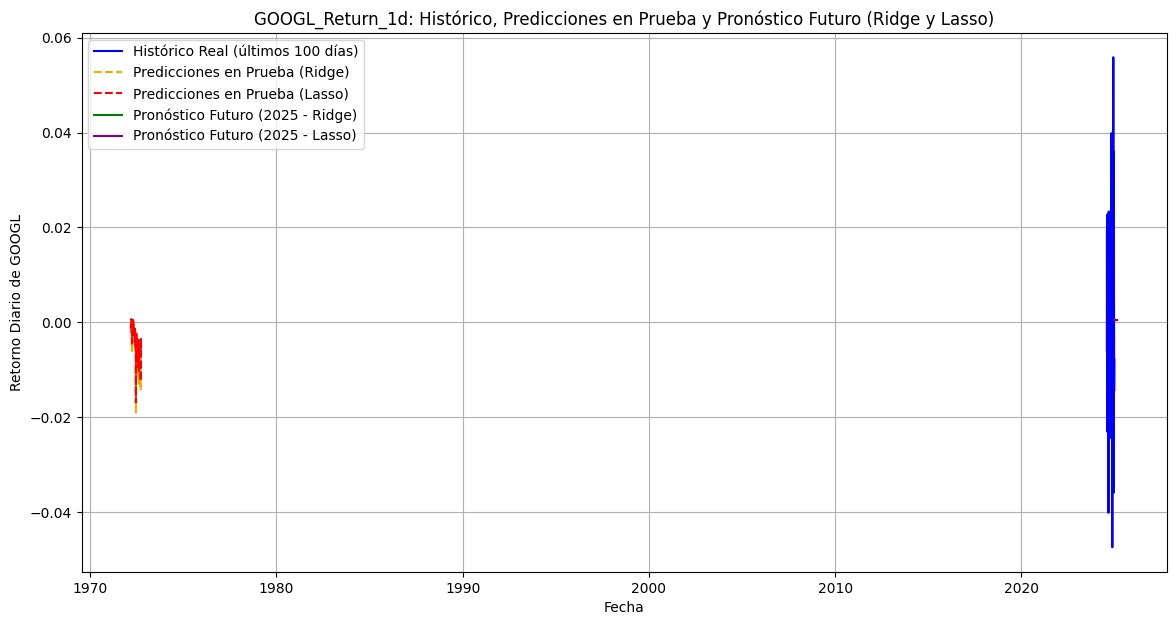

In [ ]:
# --- Regresión Ridge para GOOGL_Return_1d ---
print("\n\n--- Regresión Ridge para GOOGL_Return_1d ---")

# Importar librerías necesarias (ya importadas en celdas anteriores, pero se repiten por seguridad)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler # Para escalar los datos
from sklearn.linear_model import Ridge # Importar Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from statsmodels.stats.outliers_influence import variance_inflation_factor
from IPython.display import display

# Cargar datos (asegúrate de que df está cargado y preprocesado con 'Date')
# Si estás ejecutando esta celda sola, descomenta y ejecuta el código de carga y preprocesamiento básico:
try:
    df = pd.read_csv("dataset_completo_google_amazon.csv")
except FileNotFoundError:
    print("Error: 'dataset_completo_google_amazon.csv' no encontrado.")
    exit()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)


# Definir variables dependientes e independientes para el modelo de retornos
# Usamos las mismas variables que para la Regresión Lineal de retornos
independent_vars_return = [
    'Treasury_10Y',
    'VIX',
    'SP500',
    'NASDAQ',
    'Inflacion_T5YIE',
    'GOOGL_Volatility_20'
]
dependent_var_return = 'GOOGL_Return_1d'

# Eliminar filas con nulos en las columnas necesarias para el modelo de retornos
required_cols_return = [dependent_var_return] + independent_vars_return
df_model_return = df.dropna(subset=required_cols_return).copy()

X_return = df_model_return[independent_vars_return]
y_return = df_model_return[dependent_var_return]


# 1. División de Datos (manteniendo el orden temporal)
test_set_size_return = 0.2 # Usaremos 20% para la prueba, como en tu primer modelo
X_train_return, X_test_return, y_train_return, y_test_return = train_test_split(
    X_return, y_return, test_size=test_set_size_return, shuffle=False
)

print(f"\nDatos de entrenamiento para retorno (Ridge): {len(X_train_return)} filas")
print(f"Datos de prueba para retorno (Ridge):      {len(X_test_return)} filas")


# 2. Escalar las variables independientes
# Instanciar el escalador
scaler_return = StandardScaler()

# Ajustar el escalador SOLO en los datos de entrenamiento y transformar
X_train_return_scaled = scaler_return.fit_transform(X_train_return)
# Transformar los datos de prueba usando el escalador ajustado en el entrenamiento
X_test_return_scaled = scaler_return.transform(X_test_return)

# Convertir de nuevo a DataFrame para mantener los nombres de las columnas (opcional pero útil)
X_train_return_scaled = pd.DataFrame(X_train_return_scaled, columns=X_train_return.columns, index=X_train_return.index)
X_test_return_scaled = pd.DataFrame(X_test_return_scaled, columns=X_test_return.columns, index=X_test_return.index)


# 3. Ajustar el modelo Ridge
# alpha es el hiperparámetro de regularización. Debes sintonizarlo.
# Usamos alpha=1.0 como punto de partida.
ridge_model_return = Ridge(alpha=1.0)
ridge_model_return.fit(X_train_return_scaled, y_train_return) # Ajustar en datos ESCALADOS


# 4. Predicciones en el conjunto de prueba (con datos escalados)
y_pred_test_ridge_return = ridge_model_return.predict(X_test_return_scaled)


# 5. Evaluación del modelo
print("\n--- Evaluación del Modelo Ridge (Conjunto de Prueba - Retorno) ---")
mae_return_test_ridge = mean_absolute_error(y_test_return, y_pred_test_ridge_return)
mse_return_test_ridge = mean_squared_error(y_test_return, y_pred_test_ridge_return)
rmse_return_test_ridge = np.sqrt(mse_return_test_ridge)
r2_return_test_ridge = r2_score(y_test_return, y_pred_test_ridge_return)

print(f"MAE:  {mae_return_test_ridge:.6f}") # Usamos más decimales para retornos pequeños
print(f"MSE:  {mse_return_test_ridge:.6f}")
print(f"RMSE: {rmse_return_test_ridge:.6f}")
print(f"R²:   {r2_return_test_ridge:.4f}") # R2 sigue siendo útil


# 6. Mostrar Coeficientes e Intercepto
coef_df_return_ridge = pd.DataFrame({
    'Variable': X_return.columns,
    'Coeficiente (escalado)': ridge_model_return.coef_
})
print("\n--- Coeficientes del Modelo Ridge (Datos Escaldos, Entrenado en Entrenamiento - Retorno) ---")
display(coef_df_return_ridge.sort_values('Coeficiente (escalado)', key=abs, ascending=False))
print(f"\nIntercepto: {ridge_model_return.intercept_:.6f}")


# --- Regresión Lasso para GOOGL_Return_1d ---
print("\n\n--- Regresión Lasso para GOOGL_Return_1d ---")

# Reutilizamos los datos X_return y y_return y la división de datos
# X_train_return, X_test_return, y_train_return, y_test_return
# y los datos escalados:
# X_train_return_scaled, X_test_return_scaled

# 3. Ajustar el modelo Lasso
# alpha es el hiperparámetro de regularización. Debes sintonizarlo.
# Para retornos, alpha puede necesitar ser muy pequeño. Empecemos con un valor pequeño.
lasso_model_return = Lasso(alpha=0.0001, max_iter=10000) # Alpha más pequeño para retornos
lasso_model_return.fit(X_train_return_scaled, y_train_return) # Ajustar en datos ESCALADOS


# 4. Predicciones en el conjunto de prueba (con datos escalados)
y_pred_test_lasso_return = lasso_model_return.predict(X_test_return_scaled)


# 5. Evaluación del modelo
print("\n--- Evaluación del Modelo Lasso (Conjunto de Prueba - Retorno) ---")
mae_return_test_lasso = mean_absolute_error(y_test_return, y_pred_test_lasso_return)
mse_return_test_lasso = mean_squared_error(y_test_return, y_pred_test_lasso_return)
rmse_return_test_lasso = np.sqrt(mse_return_test_lasso)
r2_return_test_lasso = r2_score(y_test_return, y_pred_test_lasso_return)

print(f"MAE:  {mae_return_test_lasso:.6f}")
print(f"MSE:  {mse_return_test_lasso:.6f}")
print(f"RMSE: {rmse_return_test_lasso:.6f}")
print(f"R²:   {r2_return_test_lasso:.4f}")


# 6. Mostrar Coeficientes e Intercepto
coef_df_return_lasso = pd.DataFrame({
    'Variable': X_return.columns,
    'Coeficiente (escalado)': lasso_model_return.coef_
})
print("\n--- Coeficientes del Modelo Lasso (Datos Escaldos, Entrenado en Entrenamiento - Retorno) ---")
display(coef_df_return_lasso.sort_values('Coeficiente (escalado)', key=abs, ascending=False))
# Observa qué coeficientes se han reducido a cero.
print(f"\nIntercepto: {lasso_model_return.intercept_:.6f}")


# --- Comparación de Métricas ---
print("\n\n--- Comparación de Métricas en Conjunto de Prueba (Retornos) ---")
comparacion_metrics_return = pd.DataFrame({
    'Modelo': ['Ridge', 'Lasso'],
    'MAE': [mae_return_test_ridge, mae_return_test_lasso],
    'MSE': [mse_return_test_ridge, mse_return_test_lasso],
    'RMSE': [rmse_return_test_ridge, rmse_return_test_lasso],
    'R²': [r2_return_test_ridge, r2_return_test_lasso]
})
display(comparacion_metrics_return)

# --- Pronóstico para los primeros 40 días de 2025 (Retornos) ---

print("\n\n--- Pronóstico Ridge y Lasso para GOOGL_Return_1d (Primeros 40 Días de 2025) ---")

# Ajustar los modelos en TODOS los datos DISPONIBLES (escalados) para el pronóstico futuro
# Primero, escalar TODAS las variables independientes de retorno
scaler_return_full_data = StandardScaler()
X_return_scaled_full = scaler_return_full_data.fit_transform(X_return)
X_return_scaled_full = pd.DataFrame(X_return_scaled_full, columns=X_return.columns, index=X_return.index)

# Ajustar el modelo Ridge en los datos ESCALADOS completos
ridge_model_return_full_data = Ridge(alpha=1.0) # Usamos el mismo alpha
ridge_model_return_full_data.fit(X_return_scaled_full, y_return)

# Ajustar el modelo Lasso en los datos ESCALADOS completos
lasso_model_return_full_data = Lasso(alpha=0.0001, max_iter=10000) # Usamos el mismo alpha
lasso_model_return_full_data.fit(X_return_scaled_full, y_return)


# Determinar el rango de fechas para el pronóstico
start_date_2025 = pd.to_datetime('2025-01-01')
future_dates_return = pd.date_range(start=start_date_2025, periods=40, freq='B')

# Crear DataFrame para las features futuras (X_future_return) - RAW (no escalado) inicialmente
# Para retornos, usamos los últimos valores conocidos (NO ESCALADOS) para todas las variables,
# ya que no hay dependencia autorregresiva del retorno rezagado.
last_known_features_return_raw = df_model_return[independent_vars_return].iloc[-1].to_dict()

# Crear un DataFrame futuro con las fechas y poblar con los últimos valores conocidos RAW
X_future_return_raw = pd.DataFrame([last_known_features_return_raw] * len(future_dates_return), index=future_dates_return)
X_future_return_raw.index.name = 'Date'

# Asegurarse de que el orden de las columnas sea el mismo que en el entrenamiento/datos completos
X_future_return_raw = X_future_return_raw[X_return.columns]

# ESCALAR los datos futuros usando el scaler ajustado en TODOS los datos históricos
X_future_return_scaled = scaler_return_full_data.transform(X_future_return_raw)
X_future_return_scaled = pd.DataFrame(X_future_return_scaled, columns=X_future_return_raw.columns, index=X_future_return_raw.index)


# Realizar las predicciones futuras con ambos modelos (usando datos ESCALADOS)
forecast_return_ridge_2025 = ridge_model_return_full_data.predict(X_future_return_scaled)
forecast_return_lasso_2025 = lasso_model_return_full_data.predict(X_future_return_scaled)

# Crear un DataFrame para mostrar el pronóstico
forecast_df_return_2025 = pd.DataFrame({
    'Date': future_dates_return,
    'Forecast_GOOGL_Return_Ridge': forecast_return_ridge_2025,
    'Forecast_GOOGL_Return_Lasso': forecast_return_lasso_2025
})
forecast_df_return_2025.set_index('Date', inplace=True)

print("\nTabla de Pronósticos de Retorno (Ridge y Lasso):")
pd.options.display.float_format = '{:.6f}'.format # Formato para visualización de retornos
display(forecast_df_return_2025)

print("\nNota sobre el Pronóstico de Retorno:")
print("Este pronóstico asume que los valores de las variables independientes (Treasury_10Y, VIX, etc.)")
print("durante los primeros 40 días de 2025 serán iguales a sus últimos valores conocidos en el dataset histórico.")
print("Se usan los modelos Ridge y Lasso entrenados en todos los datos históricos disponibles (escalados).")


# --- Gráfico de Pronóstico de Retorno (Histórico + Futuro - Ridge y Lasso) ---
print("\n--- Gráfico de Pronóstico de Retorno (Histórico + Futuro - Ridge y Lasso) ---")

plt.figure(figsize=(14, 7))
# Graficar datos históricos reales (solo los últimos días para contexto)
# Usa los datos limpios de nulos para graficar
plt.plot(df_model_return['Date'].iloc[-100:], df_model_return['GOOGL_Return_1d'].iloc[-100:], label='Histórico Real (últimos 100 días)', color='blue')
# Graficar predicciones en el conjunto de prueba - Ridge
# Asegúrate de que X_test_return.index tiene las fechas correctas
plt.plot(X_test_return.index, y_pred_test_ridge_return, label='Predicciones en Prueba (Ridge)', color='orange', linestyle='--')
# Graficar predicciones en el conjunto de prueba - Lasso
plt.plot(X_test_return.index, y_pred_test_lasso_return, label='Predicciones en Prueba (Lasso)', color='red', linestyle='--')
# Graficar pronóstico futuro - Ridge
plt.plot(future_dates_return, forecast_return_ridge_2025, label='Pronóstico Futuro (2025 - Ridge)', color='green', linestyle='-')
# Graficar pronóstico futuro - Lasso
plt.plot(future_dates_return, forecast_return_lasso_2025, label='Pronóstico Futuro (2025 - Lasso)', color='purple', linestyle='-')


plt.title("GOOGL_Return_1d: Histórico, Predicciones en Prueba y Pronóstico Futuro (Ridge y Lasso)")
plt.xlabel("Fecha")
plt.ylabel("Retorno Diario de GOOGL")
plt.legend()
plt.grid(True)
plt.show()

# Restablecer la opción de formato de pandas si es necesario
# pd.reset_option('display.float_format')



--- Regresión Ridge para GOOGL_Return_1d ---

Datos de entrenamiento para retorno (Ridge): 797 filas
Datos de prueba para retorno (Ridge):      200 filas

--- Evaluación del Modelo Ridge (Conjunto de Prueba - Retorno) ---
MAE:  0.013928
MSE:  0.000347
RMSE: 0.018627
R²:   -0.1054

--- Coeficientes del Modelo Ridge (Datos Escaldos, Entrenado en Entrenamiento - Retorno) ---


,Variable,Coeficiente (escalado)
1,VIX,-0.004408
0,Treasury_10Y,-0.001892
2,SP500,-0.001722
5,GOOGL_Volatility_20,0.000689
3,NASDAQ,-0.000366
4,Inflacion_T5YIE,0.000040



Intercepto: 0.000781


--- Regresión Lasso para GOOGL_Return_1d ---

--- Evaluación del Modelo Lasso (Conjunto de Prueba - Retorno) ---
MAE:  0.013554
MSE:  0.000332
RMSE: 0.018226
R²:   -0.0584

--- Coeficientes del Modelo Lasso (Datos Escaldos, Entrenado en Entrenamiento - Retorno) ---


,Variable,Coeficiente (escalado)
1,VIX,-0.003929
2,SP500,-0.001660
0,Treasury_10Y,-0.001538
5,GOOGL_Volatility_20,0.000490
3,NASDAQ,-0.000000
4,Inflacion_T5YIE,-0.000000



Intercepto: 0.000781


--- Comparación de Métricas en Conjunto de Prueba (Retornos) ---


,Modelo,MAE,MSE,RMSE,R²
0,Ridge,0.013928,0.000347,0.018627,-0.105442
1,Lasso,0.013554,0.000332,0.018226,-0.058364




--- Pronóstico Ridge y Lasso para GOOGL_Return_1d (Primeros 40 Días de 2025) ---

Tabla de Pronósticos de Retorno (Ridge y Lasso):


,Forecast_GOOGL_Return_Ridge,Forecast_GOOGL_Return_Lasso
Date,,
2025-01-01,0.000450,0.000499
2025-01-02,0.000450,0.000499
2025-01-03,0.000450,0.000499
2025-01-06,0.000450,0.000499
2025-01-07,0.000450,0.000499
2025-01-08,0.000450,0.000499
2025-01-09,0.000450,0.000499
2025-01-10,0.000450,0.000499
2025-01-13,0.000450,0.000499



Nota sobre el Pronóstico de Retorno:
Este pronóstico asume que los valores de las variables independientes (Treasury_10Y, VIX, etc.)
durante los primeros 40 días de 2025 serán iguales a sus últimos valores conocidos en el dataset histórico.
Se usan los modelos Ridge y Lasso entrenados en todos los datos históricos disponibles (escalados).

--- Gráfico de Pronóstico de Retorno (Histórico + Futuro - Ridge y Lasso) ---


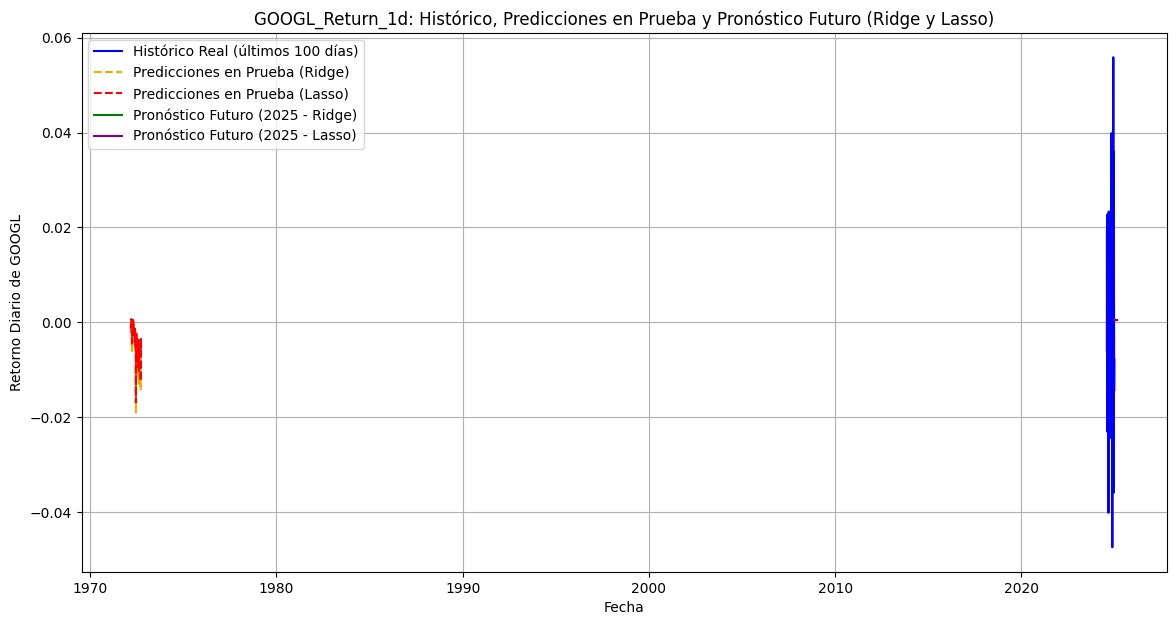

In [ ]:
# --- Regresión Ridge para GOOGL_Return_1d ---
print("\n\n--- Regresión Ridge para GOOGL_Return_1d ---")

# Importar librerías necesarias (ya importadas en celdas anteriores, pero se repiten por seguridad)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler # Para escalar los datos
from sklearn.linear_model import Ridge # Importar Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from statsmodels.stats.outliers_influence import variance_inflation_factor
from IPython.display import display

# Cargar datos (asegúrate de que df está cargado y preprocesado con 'Date')
# Si estás ejecutando esta celda sola, descomenta y ejecuta el código de carga y preprocesamiento básico:
try:
    df = pd.read_csv("dataset_completo_google_amazon.csv")
except FileNotFoundError:
    print("Error: 'dataset_completo_google_amazon.csv' no encontrado.")
    exit()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)


# Definir variables dependientes e independientes para el modelo de retornos
# Usamos las mismas variables que para la Regresión Lineal de retornos
independent_vars_return = [
    'Treasury_10Y',
    'VIX',
    'SP500',
    'NASDAQ',
    'Inflacion_T5YIE',
    'GOOGL_Volatility_20'
]
dependent_var_return = 'GOOGL_Return_1d'

# Eliminar filas con nulos en las columnas necesarias para el modelo de retornos
required_cols_return = [dependent_var_return] + independent_vars_return
df_model_return = df.dropna(subset=required_cols_return).copy()

X_return = df_model_return[independent_vars_return]
y_return = df_model_return[dependent_var_return]


# 1. División de Datos (manteniendo el orden temporal)
test_set_size_return = 0.2 # Usaremos 20% para la prueba, como en tu primer modelo
X_train_return, X_test_return, y_train_return, y_test_return = train_test_split(
    X_return, y_return, test_size=test_set_size_return, shuffle=False
)

print(f"\nDatos de entrenamiento para retorno (Ridge): {len(X_train_return)} filas")
print(f"Datos de prueba para retorno (Ridge):      {len(X_test_return)} filas")


# 2. Escalar las variables independientes
# Instanciar el escalador
scaler_return = StandardScaler()

# Ajustar el escalador SOLO en los datos de entrenamiento y transformar
X_train_return_scaled = scaler_return.fit_transform(X_train_return)
# Transformar los datos de prueba usando el escalador ajustado en el entrenamiento
X_test_return_scaled = scaler_return.transform(X_test_return)

# Convertir de nuevo a DataFrame para mantener los nombres de las columnas (opcional pero útil)
X_train_return_scaled = pd.DataFrame(X_train_return_scaled, columns=X_train_return.columns, index=X_train_return.index)
X_test_return_scaled = pd.DataFrame(X_test_return_scaled, columns=X_test_return.columns, index=X_test_return.index)


# 3. Ajustar el modelo Ridge
# alpha es el hiperparámetro de regularización. Debes sintonizarlo.
# Usamos alpha=1.0 como punto de partida.
ridge_model_return = Ridge(alpha=1.0)
ridge_model_return.fit(X_train_return_scaled, y_train_return) # Ajustar en datos ESCALADOS


# 4. Predicciones en el conjunto de prueba (con datos escalados)
y_pred_test_ridge_return = ridge_model_return.predict(X_test_return_scaled)


# 5. Evaluación del modelo
print("\n--- Evaluación del Modelo Ridge (Conjunto de Prueba - Retorno) ---")
mae_return_test_ridge = mean_absolute_error(y_test_return, y_pred_test_ridge_return)
mse_return_test_ridge = mean_squared_error(y_test_return, y_pred_test_ridge_return)
rmse_return_test_ridge = np.sqrt(mse_return_test_ridge)
r2_return_test_ridge = r2_score(y_test_return, y_pred_test_ridge_return)

print(f"MAE:  {mae_return_test_ridge:.6f}") # Usamos más decimales para retornos pequeños
print(f"MSE:  {mse_return_test_ridge:.6f}")
print(f"RMSE: {rmse_return_test_ridge:.6f}")
print(f"R²:   {r2_return_test_ridge:.4f}") # R2 sigue siendo útil


# 6. Mostrar Coeficientes e Intercepto
coef_df_return_ridge = pd.DataFrame({
    'Variable': X_return.columns,
    'Coeficiente (escalado)': ridge_model_return.coef_
})
print("\n--- Coeficientes del Modelo Ridge (Datos Escaldos, Entrenado en Entrenamiento - Retorno) ---")
display(coef_df_return_ridge.sort_values('Coeficiente (escalado)', key=abs, ascending=False))
print(f"\nIntercepto: {ridge_model_return.intercept_:.6f}")


# --- Regresión Lasso para GOOGL_Return_1d ---
print("\n\n--- Regresión Lasso para GOOGL_Return_1d ---")

# Reutilizamos los datos X_return y y_return y la división de datos
# X_train_return, X_test_return, y_train_return, y_test_return
# y los datos escalados:
# X_train_return_scaled, X_test_return_scaled

# 3. Ajustar el modelo Lasso
# alpha es el hiperparámetro de regularización. Debes sintonizarlo.
# Para retornos, alpha puede necesitar ser muy pequeño. Empecemos con un valor pequeño.
lasso_model_return = Lasso(alpha=0.0001, max_iter=10000) # Alpha más pequeño para retornos
lasso_model_return.fit(X_train_return_scaled, y_train_return) # Ajustar en datos ESCALADOS


# 4. Predicciones en el conjunto de prueba (con datos escalados)
y_pred_test_lasso_return = lasso_model_return.predict(X_test_return_scaled)


# 5. Evaluación del modelo
print("\n--- Evaluación del Modelo Lasso (Conjunto de Prueba - Retorno) ---")
mae_return_test_lasso = mean_absolute_error(y_test_return, y_pred_test_lasso_return)
mse_return_test_lasso = mean_squared_error(y_test_return, y_pred_test_lasso_return)
rmse_return_test_lasso = np.sqrt(mse_return_test_lasso)
r2_return_test_lasso = r2_score(y_test_return, y_pred_test_lasso_return)

print(f"MAE:  {mae_return_test_lasso:.6f}")
print(f"MSE:  {mse_return_test_lasso:.6f}")
print(f"RMSE: {rmse_return_test_lasso:.6f}")
print(f"R²:   {r2_return_test_lasso:.4f}")


# 6. Mostrar Coeficientes e Intercepto
coef_df_return_lasso = pd.DataFrame({
    'Variable': X_return.columns,
    'Coeficiente (escalado)': lasso_model_return.coef_
})
print("\n--- Coeficientes del Modelo Lasso (Datos Escaldos, Entrenado en Entrenamiento - Retorno) ---")
display(coef_df_return_lasso.sort_values('Coeficiente (escalado)', key=abs, ascending=False))
# Observa qué coeficientes se han reducido a cero.
print(f"\nIntercepto: {lasso_model_return.intercept_:.6f}")


# --- Comparación de Métricas ---
print("\n\n--- Comparación de Métricas en Conjunto de Prueba (Retornos) ---")
comparacion_metrics_return = pd.DataFrame({
    'Modelo': ['Ridge', 'Lasso'],
    'MAE': [mae_return_test_ridge, mae_return_test_lasso],
    'MSE': [mse_return_test_ridge, mse_return_test_lasso],
    'RMSE': [rmse_return_test_ridge, rmse_return_test_lasso],
    'R²': [r2_return_test_ridge, r2_return_test_lasso]
})
display(comparacion_metrics_return)

# --- Pronóstico para los primeros 40 días de 2025 (Retornos) ---

print("\n\n--- Pronóstico Ridge y Lasso para GOOGL_Return_1d (Primeros 40 Días de 2025) ---")

# Ajustar los modelos en TODOS los datos DISPONIBLES (escalados) para el pronóstico futuro
# Primero, escalar TODAS las variables independientes de retorno
scaler_return_full_data = StandardScaler()
X_return_scaled_full = scaler_return_full_data.fit_transform(X_return)
X_return_scaled_full = pd.DataFrame(X_return_scaled_full, columns=X_return.columns, index=X_return.index)

# Ajustar el modelo Ridge en los datos ESCALADOS completos
ridge_model_return_full_data = Ridge(alpha=1.0) # Usamos el mismo alpha
ridge_model_return_full_data.fit(X_return_scaled_full, y_return)

# Ajustar el modelo Lasso en los datos ESCALADOS completos
lasso_model_return_full_data = Lasso(alpha=0.0001, max_iter=10000) # Usamos el mismo alpha
lasso_model_return_full_data.fit(X_return_scaled_full, y_return)


# Determinar el rango de fechas para el pronóstico
start_date_2025 = pd.to_datetime('2025-01-01')
future_dates_return = pd.date_range(start=start_date_2025, periods=40, freq='B')

# Crear DataFrame para las features futuras (X_future_return) - RAW (no escalado) inicialmente
# Para retornos, usamos los últimos valores conocidos (NO ESCALADOS) para todas las variables,
# ya que no hay dependencia autorregresiva del retorno rezagado.
last_known_features_return_raw = df_model_return[independent_vars_return].iloc[-1].to_dict()

# Crear un DataFrame futuro con las fechas y poblar con los últimos valores conocidos RAW
X_future_return_raw = pd.DataFrame([last_known_features_return_raw] * len(future_dates_return), index=future_dates_return)
X_future_return_raw.index.name = 'Date'

# Asegurarse de que el orden de las columnas sea el mismo que en el entrenamiento/datos completos
X_future_return_raw = X_future_return_raw[X_return.columns]

# ESCALAR los datos futuros usando el scaler ajustado en TODOS los datos históricos
X_future_return_scaled = scaler_return_full_data.transform(X_future_return_raw)
X_future_return_scaled = pd.DataFrame(X_future_return_scaled, columns=X_future_return_raw.columns, index=X_future_return_raw.index)


# Realizar las predicciones futuras con ambos modelos (usando datos ESCALADOS)
forecast_return_ridge_2025 = ridge_model_return_full_data.predict(X_future_return_scaled)
forecast_return_lasso_2025 = lasso_model_return_full_data.predict(X_future_return_scaled)

# Crear un DataFrame para mostrar el pronóstico
forecast_df_return_2025 = pd.DataFrame({
    'Date': future_dates_return,
    'Forecast_GOOGL_Return_Ridge': forecast_return_ridge_2025,
    'Forecast_GOOGL_Return_Lasso': forecast_return_lasso_2025
})
forecast_df_return_2025.set_index('Date', inplace=True)

print("\nTabla de Pronósticos de Retorno (Ridge y Lasso):")
pd.options.display.float_format = '{:.6f}'.format # Formato para visualización de retornos
display(forecast_df_return_2025)

print("\nNota sobre el Pronóstico de Retorno:")
print("Este pronóstico asume que los valores de las variables independientes (Treasury_10Y, VIX, etc.)")
print("durante los primeros 40 días de 2025 serán iguales a sus últimos valores conocidos en el dataset histórico.")
print("Se usan los modelos Ridge y Lasso entrenados en todos los datos históricos disponibles (escalados).")


# --- Gráfico de Pronóstico de Retorno (Histórico + Futuro - Ridge y Lasso) ---
print("\n--- Gráfico de Pronóstico de Retorno (Histórico + Futuro - Ridge y Lasso) ---")

plt.figure(figsize=(14, 7))
# Graficar datos históricos reales (solo los últimos días para contexto)
# Usa los datos limpios de nulos para graficar
plt.plot(df_model_return['Date'].iloc[-100:], df_model_return['GOOGL_Return_1d'].iloc[-100:], label='Histórico Real (últimos 100 días)', color='blue')
# Graficar predicciones en el conjunto de prueba - Ridge
# Asegúrate de que X_test_return.index tiene las fechas correctas
plt.plot(X_test_return.index, y_pred_test_ridge_return, label='Predicciones en Prueba (Ridge)', color='orange', linestyle='--')
# Graficar predicciones en el conjunto de prueba - Lasso
plt.plot(X_test_return.index, y_pred_test_lasso_return, label='Predicciones en Prueba (Lasso)', color='red', linestyle='--')
# Graficar pronóstico futuro - Ridge
plt.plot(future_dates_return, forecast_return_ridge_2025, label='Pronóstico Futuro (2025 - Ridge)', color='green', linestyle='-')
# Graficar pronóstico futuro - Lasso
plt.plot(future_dates_return, forecast_return_lasso_2025, label='Pronóstico Futuro (2025 - Lasso)', color='purple', linestyle='-')


plt.title("GOOGL_Return_1d: Histórico, Predicciones en Prueba y Pronóstico Futuro (Ridge y Lasso)")
plt.xlabel("Fecha")
plt.ylabel("Retorno Diario de GOOGL")
plt.legend()
plt.grid(True)
plt.show()

# Restablecer la opción de formato de pandas si es necesario
# pd.reset_option('display.float_format')

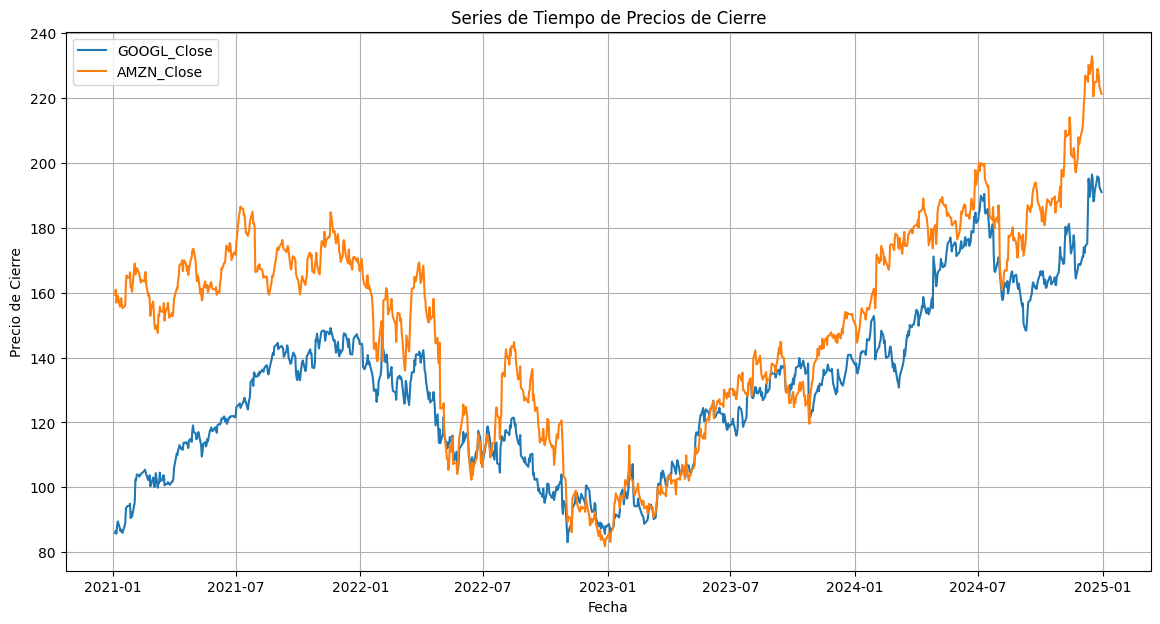

In [ ]:
# prompt: puedes graficar todas las series de tiempo anteriores mostrando con colores diferentes

import pandas as pd
import matplotlib.pyplot as plt

# Asegúrate de que la columna 'Date' sea tipo datetime para graficar correctamente
df['Date'] = pd.to_datetime(df['Date'])

# Identificar las columnas de precios de cierre para GOOGL y otras posibles series
# Asumiendo que tienes columnas con los precios de cierre, por ejemplo: 'GOOGL_Close', 'Otra_Serie_Close'
# Reemplaza 'GOOGL_Close' y 'Otra_Serie_Close' con los nombres reales de tus columnas
series_to_plot = ['GOOGL_Close', 'AMZN_Close', 'Otra_Serie_Close'] # Agrega los nombres de las columnas que quieres graficar

plt.figure(figsize=(14, 7))

# Graficar cada serie de tiempo
for column in series_to_plot:
  if column in df.columns:
    plt.plot(df['Date'], df[column], label=column)
  else:
    print(f"Warning: Column '{column}' not found in the DataFrame.")


plt.title('Series de Tiempo de Precios de Cierre')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
!pip install prophet

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from IPython.display import display # Import display para mostrar DataFrames

In [ ]:
# Asegurarse de que df está cargado y preprocesado
# df = pd.read_csv("dataset_completo_google_amazon.csv")
# df['Date'] = pd.to_datetime(df['Date'])
# df = df.sort_values('Date').reset_index(drop=True)

# --- Preparar datos para Prophet ---
# Prophet necesita columnas 'ds' (fecha) y 'y' (valor)
googl_price_prophet = df[['Date', 'GOOGL_Close']].dropna().copy()
googl_price_prophet = googl_price_prophet.rename(columns={'Date': 'ds', 'GOOGL_Close': 'y'})

googl_return_prophet = df[['Date', 'GOOGL_Return_1d']].dropna().copy()
googl_return_prophet = googl_return_prophet.rename(columns={'Date': 'ds', 'GOOGL_Return_1d': 'y'})

In [ ]:
# --- Dividir datos en entrenamiento y prueba ---
# Usaremos los últimos 40 días para la prueba, igual que antes
test_set_size = 40

train_price_prophet = googl_price_prophet[:-test_set_size]
test_price_prophet = googl_price_prophet[-test_set_size:]

train_return_prophet = googl_return_prophet[:-test_set_size]
test_return_prophet = googl_return_prophet[-test_set_size:]


In [ ]:
#Modelado y Evaluación para GOOGL_Close con Prophet ---

print("--- Modelado y Evaluación para GOOGL_Close con Prophet ---")

# Inicializar y ajustar el modelo Prophet
# daily_seasonality=False ya que tus datos son diarios, no intra-diarios
# weekly_seasonality=True y yearly_seasonality=True pueden ser útiles
model_price_prophet = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True)

# Puedes añadir días festivos si tienes un archivo csv con fechas y nombres
# holidays = pd.read_csv('holidays.csv') # Ejemplo
# model_price_prophet.add_country_holidays(country_name='US') # O añadir festivos de un país

model_price_prophet.fit(train_price_prophet)


--- Modelado y Evaluación para GOOGL_Close con Prophet ---


DEBUG:cmdstanpy:input tempfile: /tmp/tmpwhqxitkn/wg7ix3gi.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpwhqxitkn/yj23b9us.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=39992', 'data', 'file=/tmp/tmpwhqxitkn/wg7ix3gi.json', 'init=/tmp/tmpwhqxitkn/yj23b9us.json', 'output', 'file=/tmp/tmpwhqxitkn/prophet_modelofkcg2j0/prophet_model-20250617232610.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
23:26:10 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
23:26:10 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [ ]:
# Crear DataFrame de fechas futuras para la predicción
# Prophet usa make_future_dataframe(periods=..., freq='...')
# 'B' para días hábiles, aunque Prophet prefiere 'D' (diario) o 'W' (semanal)
# Si usas 'B', puede haber gaps, si usas 'D', predecirá fines de semana y festivos
# que luego tendrías que filtrar o manejar. Usaremos 'B' para que coincida con tus datos.
future_price_prophet = model_price_prophet.make_future_dataframe(periods=test_set_size, freq='B')

# Realizar predicciones
forecast_price_prophet_test = model_price_prophet.predict(future_price_prophet)

# Mostrar la tabla de pronósticos (solo las columnas relevantes y para el periodo de prueba)
print("\nTabla de Pronósticos Prophet para GOOGL_Close (Prueba):")
# Alinear el pronóstico con los datos de prueba
# Primero, asegurarnos de que las fechas de pronóstico coincidan con las fechas de prueba
forecast_price_test_subset = forecast_price_prophet_test[
    forecast_price_prophet_test['ds'].isin(test_price_prophet['ds'])
].copy()



Tabla de Pronósticos Prophet para GOOGL_Close (Prueba):


In [ ]:
# Merge para evaluación
eval_df_price_prophet = pd.merge(
    test_price_prophet,
    forecast_price_test_subset[['ds', 'yhat']], # 'yhat' es la predicción de Prophet
    on='ds'
)

In [ ]:
eval_df_price_prophet.head()

,ds,y,yhat
0,2024-10-31,170.717514,162.304410
1,2024-11-01,170.897079,162.450678
2,2024-11-04,168.851807,162.391072
3,2024-11-05,169.350647,162.458388
4,2024-11-06,176.105118,162.546212


In [ ]:
# Evaluación del modelo en el set de prueba
print("\nEvaluación del Modelo Prophet para GOOGL_Close:")
mae_price_prophet = mean_absolute_error(eval_df_price_prophet['y'], eval_df_price_prophet['yhat'])
mse_price_prophet = mean_squared_error(eval_df_price_prophet['y'], eval_df_price_prophet['yhat'])
rmse_price_prophet = np.sqrt(mse_price_prophet)
# R² no es directamente aplicable aquí ya que Prophet no es un modelo de regresión lineal simple
# Pero podemos calcularlo si queremos, aunque su interpretación puede ser diferente
# from sklearn.metrics import r2_score
# r2_price_prophet = r2_score(eval_df_price_prophet['y'], eval_df_price_prophet['yhat'])

print(f"MAE: {mae_price_prophet:.4f}")
print(f"MSE: {mse_price_prophet:.4f}")
print(f"RMSE: {rmse_price_prophet:.4f}")
# print(f"R²: {r2_price_prophet:.4f}") # Opcional



Evaluación del Modelo Prophet para GOOGL_Close:
MAE: 14.2555
MSE: 304.3050
RMSE: 17.4443


In [ ]:
# Configurar visualización sin notación científica y con 2 decimales para la tabla
pd.options.display.float_format = '{:.2f}'.format
# Mostrar tabla con datos reales y pronóstico para el periodo de prueba
display(eval_df_price_prophet.rename(columns={'y': 'Actual_GOOGL_Close', 'yhat': 'Forecast_GOOGL_Close_Prophet'}))

,ds,Actual_GOOGL_Close,Forecast_GOOGL_Close_Prophet
0,2024-10-31,170.72,162.30
1,2024-11-01,170.90,162.45
2,2024-11-04,168.85,162.39
3,2024-11-05,169.35,162.46
4,2024-11-06,176.11,162.55
5,2024-11-07,180.34,162.66
6,2024-11-08,177.94,163.07
7,2024-11-12,181.20,163.97
8,2024-11-13,178.47,164.22
9,2024-11-14,175.18,164.45


DEBUG:cmdstanpy:input tempfile: /tmp/tmpm6_ebjlc/7o1hco3v.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpm6_ebjlc/fvl2e28d.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=93570', 'data', 'file=/tmp/tmpm6_ebjlc/7o1hco3v.json', 'init=/tmp/tmpm6_ebjlc/fvl2e28d.json', 'output', 'file=/tmp/tmpm6_ebjlc/prophet_model_new57h_/prophet_model-20250617231634.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
23:16:34 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
23:16:35 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing




--- Modelado y Evaluación para GOOGL_Return_1d con Prophet ---

Tabla de Pronósticos Prophet para GOOGL_Return_1d (Prueba):


,ds,Actual_GOOGL_Return_1d,Forecast_GOOGL_Return_1d_Prophet
0,2024-10-31,-0.02,0.00
1,2024-11-01,0.00,0.00
2,2024-11-04,-0.01,0.00
3,2024-11-05,0.00,0.00
4,2024-11-06,0.04,0.00
5,2024-11-07,0.02,0.00
6,2024-11-08,-0.01,0.00
7,2024-11-12,0.01,0.00
8,2024-11-13,-0.02,0.00
9,2024-11-14,-0.02,0.01


DEBUG:cmdstanpy:input tempfile: /tmp/tmpm6_ebjlc/iomojna0.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpm6_ebjlc/436szzzv.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=16715', 'data', 'file=/tmp/tmpm6_ebjlc/iomojna0.json', 'init=/tmp/tmpm6_ebjlc/436szzzv.json', 'output', 'file=/tmp/tmpm6_ebjlc/prophet_modelmz0c_e4a/prophet_model-20250617231635.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
23:16:35 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing



Evaluación del Modelo Prophet para GOOGL_Return_1d:
MAE: 0.0176
MSE: 0.0005
RMSE: 0.0229


--- Pronóstico Futuro (40 días) con Prophet (usando todos los datos) ---


...

,ds,Forecast_GOOGL_Close_Prophet,yhat_lower,yhat_upper
997,2024-12-31,180.93,172.76,188.34
998,2025-01-01,180.59,173.25,187.94
999,2025-01-02,180.30,172.42,188.08
1000,2025-01-03,180.19,172.67,187.48
1001,2025-01-06,179.38,171.75,186.89
1002,2025-01-07,179.11,171.87,186.59
1003,2025-01-08,178.85,171.41,186.00
1004,2025-01-09,178.70,171.34,186.25
1005,2025-01-10,178.78,170.79,185.95
1006,2025-01-13,178.83,171.41,186.72


DEBUG:cmdstanpy:input tempfile: /tmp/tmpm6_ebjlc/e8pe_o9y.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpm6_ebjlc/z7bagjv8.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=72030', 'data', 'file=/tmp/tmpm6_ebjlc/e8pe_o9y.json', 'init=/tmp/tmpm6_ebjlc/z7bagjv8.json', 'output', 'file=/tmp/tmpm6_ebjlc/prophet_modeljt2iq7c0/prophet_model-20250617231635.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
23:16:35 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
23:16:35 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing



Tabla de Pronósticos Prophet para GOOGL_Return_1d (Próximos 40 Días):


,ds,Forecast_GOOGL_Return_1d_Prophet,yhat_lower,yhat_upper
997,2024-12-31,-0.00,-0.03,0.02
998,2025-01-01,-0.00,-0.02,0.03
999,2025-01-02,-0.00,-0.03,0.02
1000,2025-01-03,-0.00,-0.03,0.02
1001,2025-01-06,-0.00,-0.03,0.02
1002,2025-01-07,-0.00,-0.02,0.02
1003,2025-01-08,0.00,-0.02,0.03
1004,2025-01-09,0.00,-0.02,0.02
1005,2025-01-10,0.00,-0.03,0.03
1006,2025-01-13,0.00,-0.02,0.03



--- Gráficos de Pronóstico Futuro (Prophet) ---


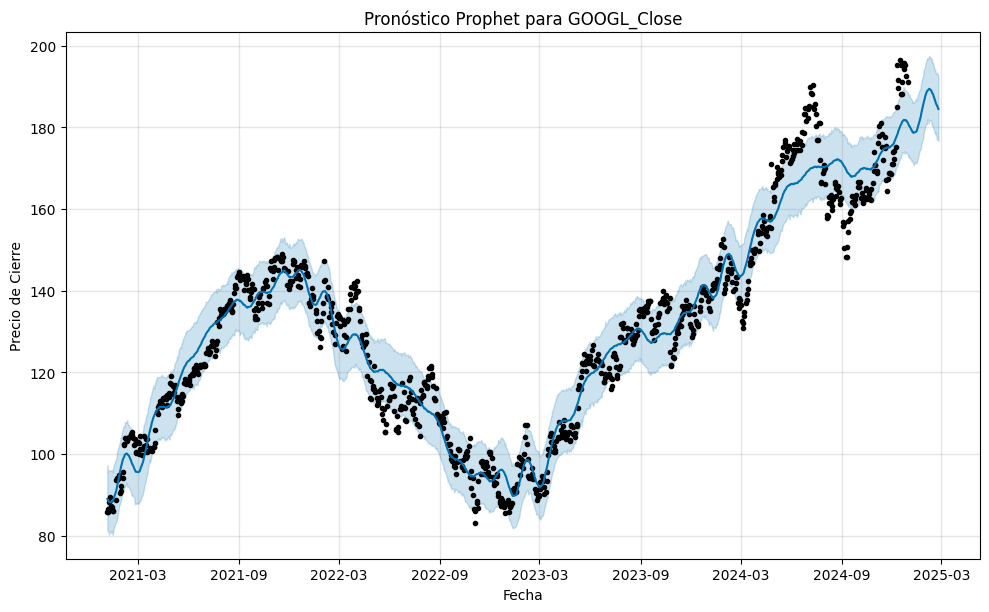

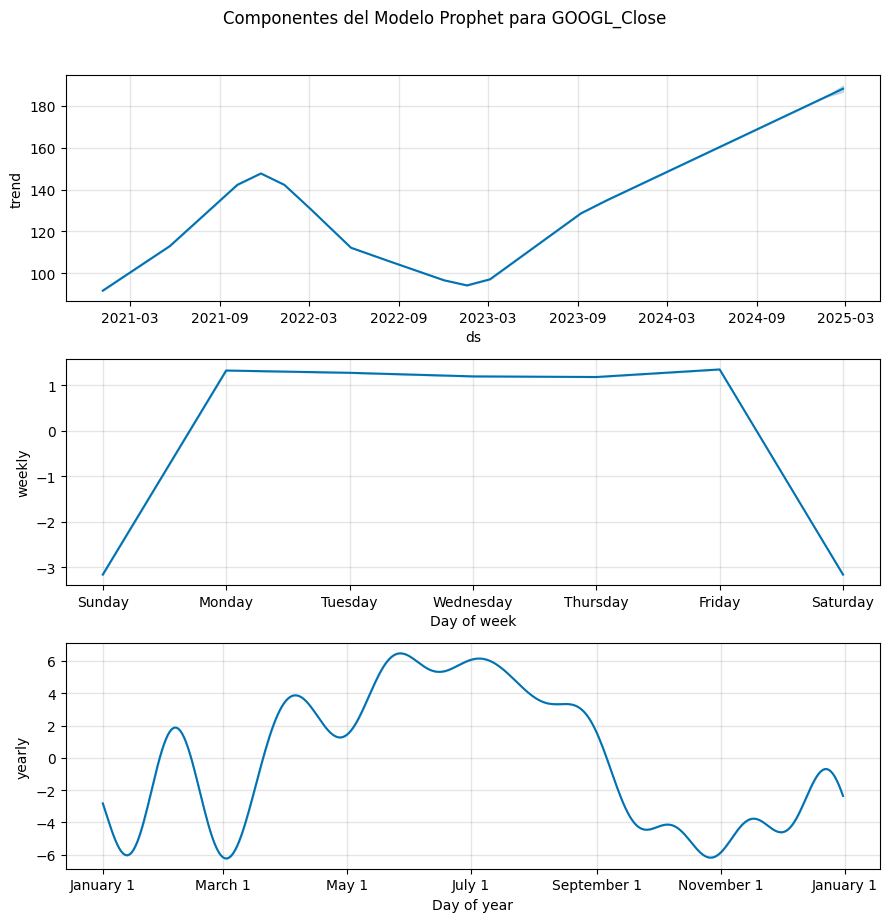

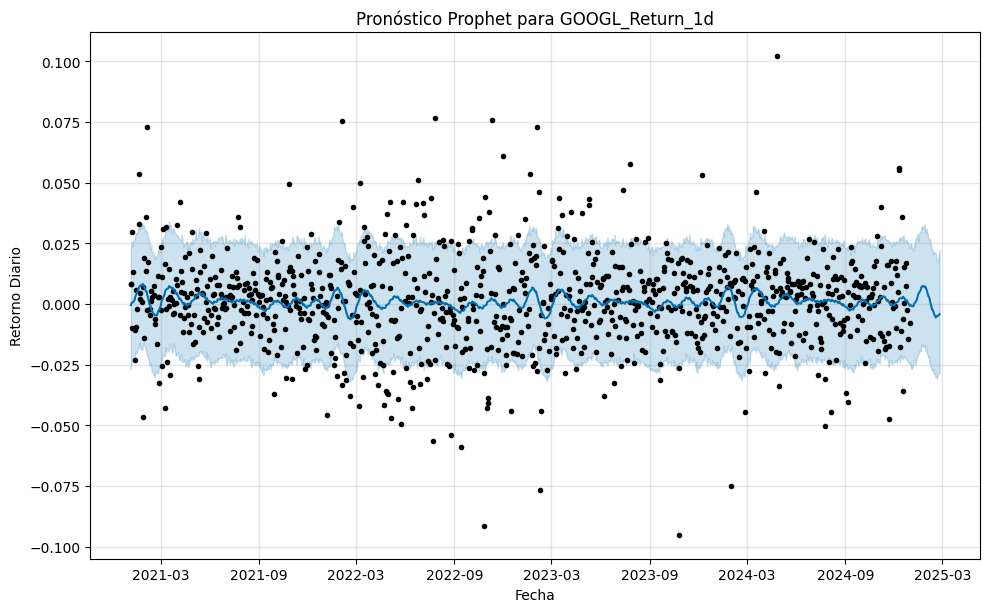

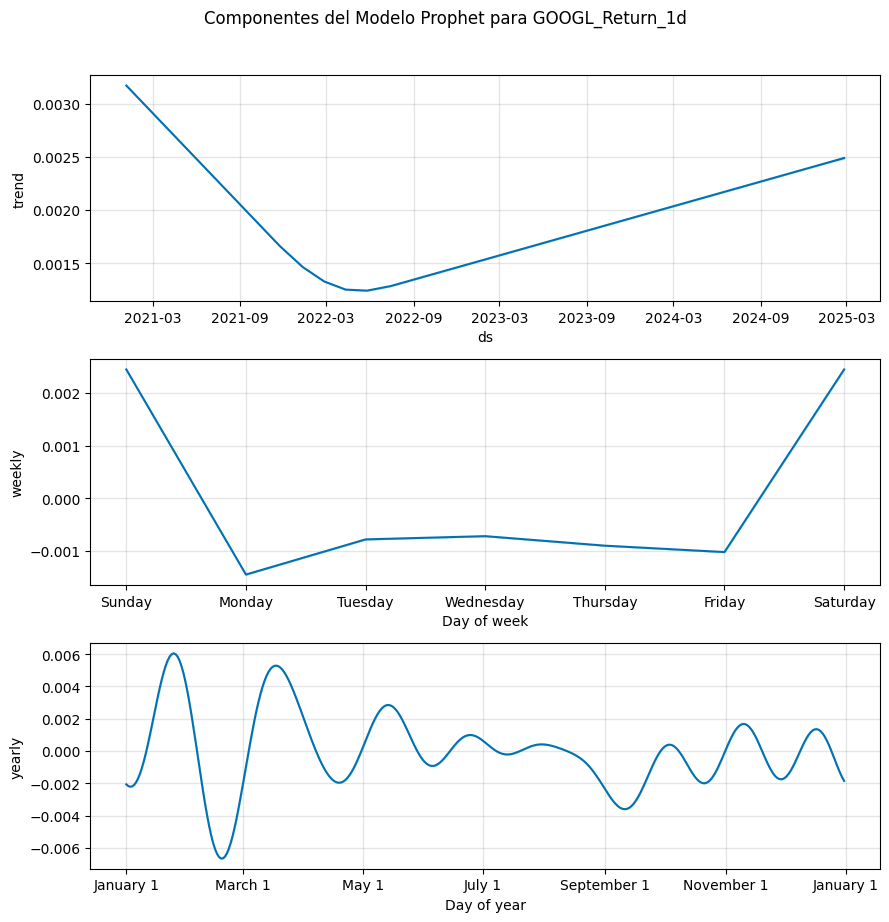

In [ ]:

# --- Modelado y Evaluación para GOOGL_Return_1d con Prophet ---

print("\n\n--- Modelado y Evaluación para GOOGL_Return_1d con Prophet ---")

# Inicializar y ajustar el modelo Prophet para retornos
# Los retornos son estacionarios en media, así que la tendencia de Prophet podría no ser tan pronunciada
model_return_prophet = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True)
model_return_prophet.fit(train_return_prophet)

# Crear DataFrame de fechas futuras para la predicción de retornos
future_return_prophet = model_return_prophet.make_future_dataframe(periods=test_set_size, freq='B')

# Realizar predicciones
forecast_return_prophet_test = model_return_prophet.predict(future_return_prophet)

# Mostrar la tabla de pronósticos (solo las columnas relevantes y para el periodo de prueba)
print("\nTabla de Pronósticos Prophet para GOOGL_Return_1d (Prueba):")
# Alinear el pronóstico con los datos de prueba
forecast_return_test_subset = forecast_return_prophet_test[
    forecast_return_prophet_test['ds'].isin(test_return_prophet['ds'])
].copy()

# Merge para evaluación
eval_df_return_prophet = pd.merge(
    test_return_prophet,
    forecast_return_test_subset[['ds', 'yhat']],
    on='ds'
)

# Mostrar tabla con datos reales y pronóstico para el periodo de prueba
display(eval_df_return_prophet.rename(columns={'y': 'Actual_GOOGL_Return_1d', 'yhat': 'Forecast_GOOGL_Return_1d_Prophet'}))


# Evaluación del modelo en el set de prueba
print("\nEvaluación del Modelo Prophet para GOOGL_Return_1d:")
mae_return_prophet = mean_absolute_error(eval_df_return_prophet['y'], eval_df_return_prophet['yhat'])
mse_return_prophet = mean_squared_error(eval_df_return_prophet['y'], eval_df_return_prophet['yhat'])
rmse_return_prophet = np.sqrt(mse_return_prophet)
# r2_return_prophet = r2_score(eval_df_return_prophet['y'], eval_df_return_prophet['yhat']) # Opcional

print(f"MAE: {mae_return_prophet:.4f}")
print(f"MSE: {mse_return_prophet:.4f}")
print(f"RMSE: {rmse_return_prophet:.4f}")
# print(f"R²: {r2_return_prophet:.4f}") # Opcional


# --- Pronóstico Futuro (40 días) con Prophet ---

print("\n\n--- Pronóstico Futuro (40 días) con Prophet (usando todos los datos) ---")

forecast_steps_future = 40 # Pronosticar los próximos 40 días

# Ajustar el modelo a TODO el dataset para el pronóstico futuro
# Modelo para GOOGL_Close
model_price_prophet_full = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True)
model_price_prophet_full.fit(googl_price_prophet) # Usar todos los datos

# Crear DataFrame de fechas futuras para la predicción futura
future_price_prophet_full = model_price_prophet_full.make_future_dataframe(periods=forecast_steps_future, freq='B')

# Realizar predicciones futuras
forecast_price_prophet_future = model_price_prophet_full.predict(future_price_prophet_full)

# Mostrar la tabla de pronósticos futuros para GOOGL_Close
print("\nTabla de Pronósticos Prophet para GOOGL_Close (Próximos 40 Días):")
# Filtrar solo las fechas futuras (después de la última fecha en los datos originales)
last_date_in_data = df['Date'].max()
forecast_price_future_subset = forecast_price_prophet_future[
    forecast_price_prophet_future['ds'] > last_date_in_data
].copy()
display(forecast_price_future_subset[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].rename(columns={'yhat': 'Forecast_GOOGL_Close_Prophet'}))


# Modelo para GOOGL_Return_1d
model_return_prophet_full = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True)
model_return_prophet_full.fit(googl_return_prophet) # Usar todos los datos

# Crear DataFrame de fechas futuras para la predicción futura
future_return_prophet_full = model_return_prophet_full.make_future_dataframe(periods=forecast_steps_future, freq='B')

# Realizar predicciones futuras
forecast_return_prophet_future = model_return_prophet_full.predict(future_return_prophet_full)

# Mostrar la tabla de pronósticos futuros para GOOGL_Return_1d
print("\nTabla de Pronósticos Prophet para GOOGL_Return_1d (Próximos 40 Días):")
# Filtrar solo las fechas futuras
forecast_return_future_subset = forecast_return_prophet_future[
    forecast_return_prophet_future['ds'] > last_date_in_data
].copy()
display(forecast_return_future_subset[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].rename(columns={'yhat': 'Forecast_GOOGL_Return_1d_Prophet'}))


# --- Gráficos de Pronóstico Futuro (Opcional) ---
# Prophet tiene funciones de plot integradas

print("\n--- Gráficos de Pronóstico Futuro (Prophet) ---")

# Gráfico para GOOGL_Close
fig_price = model_price_prophet_full.plot(forecast_price_prophet_future)
plt.title("Pronóstico Prophet para GOOGL_Close")
plt.xlabel("Fecha")
plt.ylabel("Precio de Cierre")
plt.grid(True)
plt.show()

# Gráfico de componentes para GOOGL_Close
fig_comp_price = model_price_prophet_full.plot_components(forecast_price_prophet_future)
plt.suptitle("Componentes del Modelo Prophet para GOOGL_Close", y=1.02)
plt.tight_layout()
plt.show()


# Gráfico para GOOGL_Return_1d
fig_return = model_return_prophet_full.plot(forecast_return_prophet_future)
plt.title("Pronóstico Prophet para GOOGL_Return_1d")
plt.xlabel("Fecha")
plt.ylabel("Retorno Diario")
plt.grid(True)
plt.show()

# Gráfico de componentes para GOOGL_Return_1d
fig_comp_return = model_return_prophet_full.plot_components(forecast_return_prophet_future)
plt.suptitle("Componentes del Modelo Prophet para GOOGL_Return_1d", y=1.02)
plt.tight_layout()
plt.show()


# Restablecer la opción de formato de pandas si es necesario
# pd.reset_option('display.float_format')

DEBUG:cmdstanpy:input tempfile: /tmp/tmpm6_ebjlc/2vuf8ca7.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpm6_ebjlc/yokl5ly2.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=81456', 'data', 'file=/tmp/tmpm6_ebjlc/2vuf8ca7.json', 'init=/tmp/tmpm6_ebjlc/yokl5ly2.json', 'output', 'file=/tmp/tmpm6_ebjlc/prophet_model7g6n18tw/prophet_model-20250617231727.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
23:17:27 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing




--- Pronóstico Futuro (40 días) con Prophet (usando todos los datos) ---


23:17:28 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing



Tabla de Pronósticos Prophet para GOOGL_Close (Próximos 40 Días):


,ds,Forecast_GOOGL_Close_Prophet,yhat_lower,yhat_upper
997,2024-12-31,180.93,173.51,188.33
998,2025-01-01,180.59,173.27,188.13
999,2025-01-02,180.30,172.65,187.77
1000,2025-01-03,180.19,172.43,187.88
1001,2025-01-06,179.38,171.90,187.30
1002,2025-01-07,179.11,171.56,186.22
1003,2025-01-08,178.85,170.97,186.75
1004,2025-01-09,178.70,170.53,185.98
1005,2025-01-10,178.78,170.93,186.94
1006,2025-01-13,178.83,171.19,187.20


DEBUG:cmdstanpy:input tempfile: /tmp/tmpm6_ebjlc/x_kdodd9.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpm6_ebjlc/74c0fm27.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=12076', 'data', 'file=/tmp/tmpm6_ebjlc/x_kdodd9.json', 'init=/tmp/tmpm6_ebjlc/74c0fm27.json', 'output', 'file=/tmp/tmpm6_ebjlc/prophet_modelkvh_3yzr/prophet_model-20250617231728.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
23:17:28 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
23:17:28 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing



Tabla de Pronósticos Prophet para GOOGL_Return_1d (Próximos 40 Días):


,ds,Forecast_GOOGL_Return_1d_Prophet,yhat_lower,yhat_upper
997,2024-12-31,-0.00,-0.03,0.02
998,2025-01-01,-0.00,-0.02,0.02
999,2025-01-02,-0.00,-0.03,0.02
1000,2025-01-03,-0.00,-0.02,0.02
1001,2025-01-06,-0.00,-0.02,0.02
1002,2025-01-07,-0.00,-0.03,0.02
1003,2025-01-08,0.00,-0.02,0.02
1004,2025-01-09,0.00,-0.03,0.02
1005,2025-01-10,0.00,-0.02,0.03
1006,2025-01-13,0.00,-0.02,0.03



--- Gráficos de Pronóstico Futuro (Prophet) ---


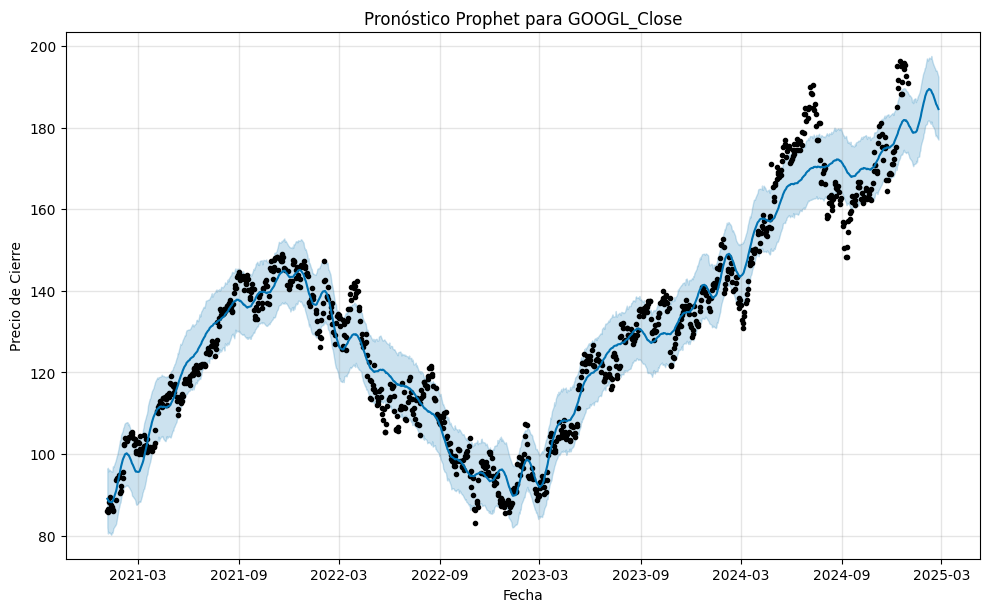

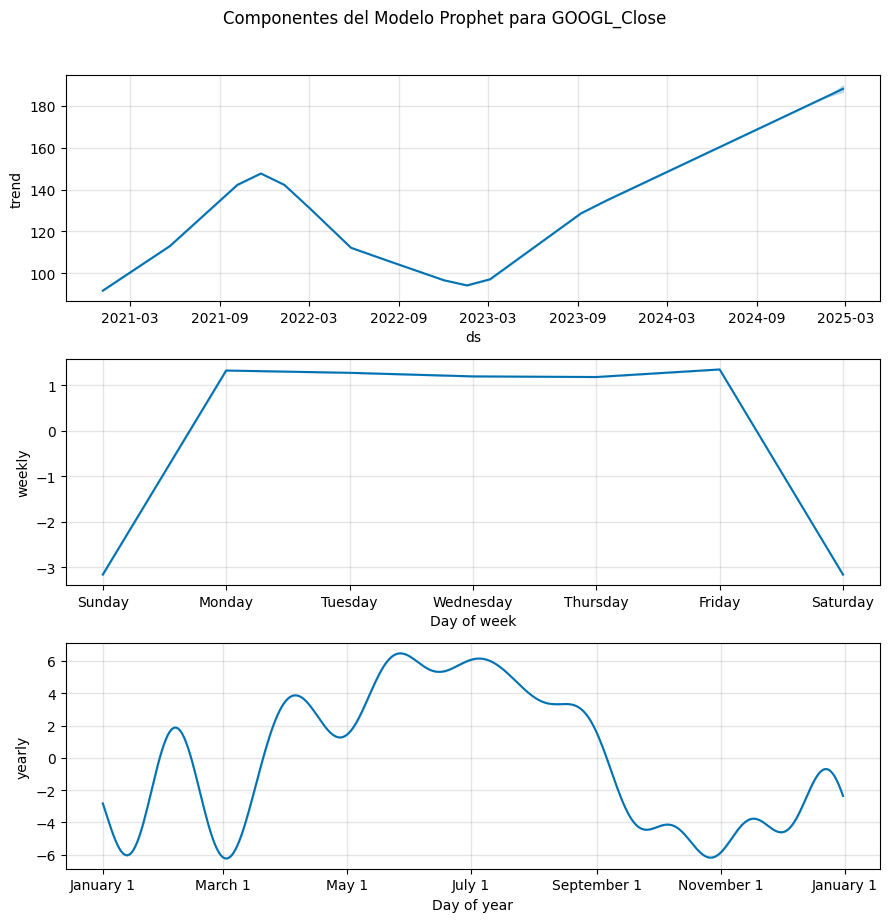

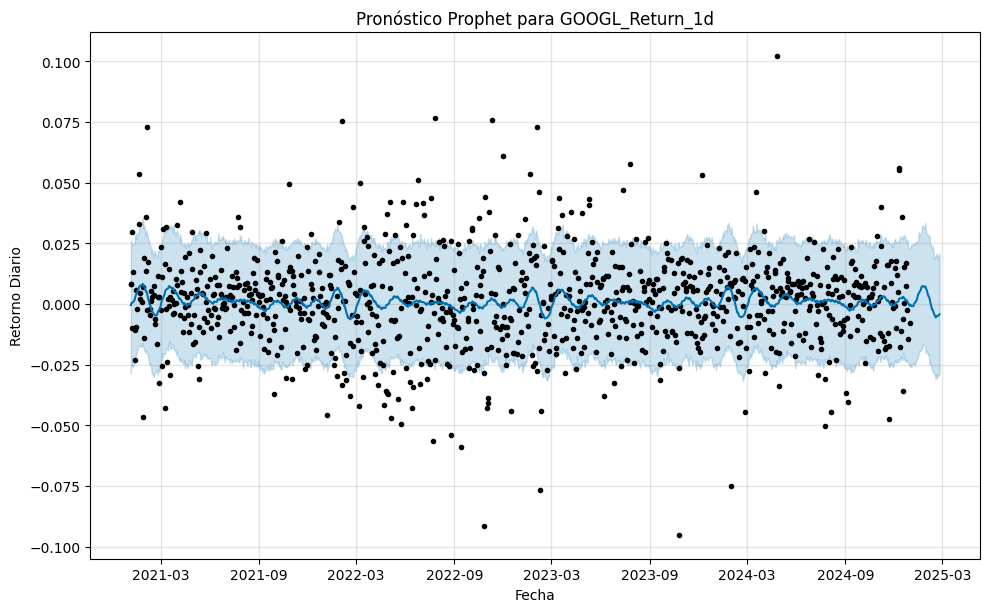

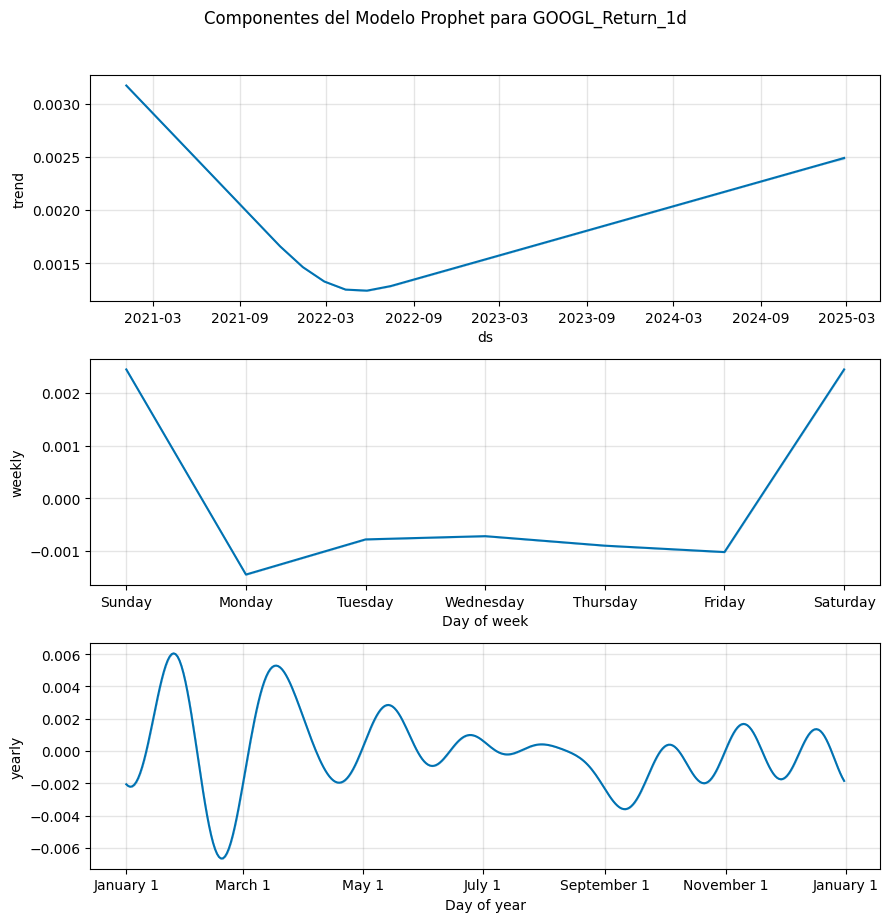

In [ ]:
# --- Pronóstico Futuro (40 días) con Prophet ---

print("\n\n--- Pronóstico Futuro (40 días) con Prophet (usando todos los datos) ---")

forecast_steps_future = 40 # Pronosticar los próximos 40 días

# Ajustar el modelo a TODO el dataset para el pronóstico futuro
# Modelo para GOOGL_Close
model_price_prophet_full = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True)
model_price_prophet_full.fit(googl_price_prophet) # Usar todos los datos

# Crear DataFrame de fechas futuras para la predicción futura
future_price_prophet_full = model_price_prophet_full.make_future_dataframe(periods=forecast_steps_future, freq='B')

# Realizar predicciones futuras
forecast_price_prophet_future = model_price_prophet_full.predict(future_price_prophet_full)

# Mostrar la tabla de pronósticos futuros para GOOGL_Close
print("\nTabla de Pronósticos Prophet para GOOGL_Close (Próximos 40 Días):")
# Filtrar solo las fechas futuras (después de la última fecha en los datos originales)
last_date_in_data = df['Date'].max()
forecast_price_future_subset = forecast_price_prophet_future[
    forecast_price_prophet_future['ds'] > last_date_in_data
].copy()
display(forecast_price_future_subset[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].rename(columns={'yhat': 'Forecast_GOOGL_Close_Prophet'}))


# Modelo para GOOGL_Return_1d
model_return_prophet_full = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True)
model_return_prophet_full.fit(googl_return_prophet) # Usar todos los datos

# Crear DataFrame de fechas futuras para la predicción futura
future_return_prophet_full = model_return_prophet_full.make_future_dataframe(periods=forecast_steps_future, freq='B')

# Realizar predicciones futuras
forecast_return_prophet_future = model_return_prophet_full.predict(future_return_prophet_full)

# Mostrar la tabla de pronósticos futuros para GOOGL_Return_1d
print("\nTabla de Pronósticos Prophet para GOOGL_Return_1d (Próximos 40 Días):")
# Filtrar solo las fechas futuras
forecast_return_future_subset = forecast_return_prophet_future[
    forecast_return_prophet_future['ds'] > last_date_in_data
].copy()
display(forecast_return_future_subset[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].rename(columns={'yhat': 'Forecast_GOOGL_Return_1d_Prophet'}))


# --- Gráficos de Pronóstico Futuro (Opcional) ---
# Prophet tiene funciones de plot integradas

print("\n--- Gráficos de Pronóstico Futuro (Prophet) ---")

# Gráfico para GOOGL_Close
fig_price = model_price_prophet_full.plot(forecast_price_prophet_future)
plt.title("Pronóstico Prophet para GOOGL_Close")
plt.xlabel("Fecha")
plt.ylabel("Precio de Cierre")
plt.grid(True)
plt.show()

# Gráfico de componentes para GOOGL_Close
fig_comp_price = model_price_prophet_full.plot_components(forecast_price_prophet_future)
plt.suptitle("Componentes del Modelo Prophet para GOOGL_Close", y=1.02)
plt.tight_layout()
plt.show()


# Gráfico para GOOGL_Return_1d
fig_return = model_return_prophet_full.plot(forecast_return_prophet_future)
plt.title("Pronóstico Prophet para GOOGL_Return_1d")
plt.xlabel("Fecha")
plt.ylabel("Retorno Diario")
plt.grid(True)
plt.show()

# Gráfico de componentes para GOOGL_Return_1d
fig_comp_return = model_return_prophet_full.plot_components(forecast_return_prophet_future)
plt.suptitle("Componentes del Modelo Prophet para GOOGL_Return_1d", y=1.02)
plt.tight_layout()
plt.show()


# Restablecer la opción de formato de pandas si es necesario
# pd.reset_option('display.float_format')

In [ ]:
# El cálculo de las métricas para Prophet (MAE, MSE, RMSE) ya está implementado
    # en celdas anteriores utilizando sklearn.metrics sobre eval_df_price_prophet
    # y eval_df_return_prophet. No es necesario agregar código adicional aquí.
    # Solo asegúrate de ejecutar las celdas donde se calculan e imprimen.

    # Ejemplo del cálculo (ya presente en tu notebook):
    # print("\nEvaluación del Modelo Prophet para GOOGL_Close:")
    # mae_price_prophet = mean_absolute_error(eval_df_price_prophet['y'], eval_df_price_prophet['yhat'])
    # mse_price_prophet = mean_squared_error(eval_df_price_prophet['y'], eval_df_price_prophet['yhat'])
    # rmse_price_prophet = np.sqrt(mse_price_prophet)
    # print(f"MAE: {mae_price_prophet:.4f}")
    # print(f"MSE: {mse_price_prophet:.4f}")
    # print(f"RMSE: {rmse_price_prophet:.4f}")

In [ ]:
!pip install statsmodels
!pip install pmdarima

In [ ]:
!pip uninstall statsmodels pmdarima -y

Found existing installation: statsmodels 0.14.4
Uninstalling statsmodels-0.14.4:
  Successfully uninstalled statsmodels-0.14.4
Found existing installation: pmdarima 2.0.4
Uninstalling pmdarima-2.0.4:
  Successfully uninstalled pmdarima-2.0.4


In [ ]:
!pip install statsmodels pmdarima

  Using cached pmdarima-2.0.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.manylinux_2_28_x86_64.whl.metadata (7.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 75.7 MB/s eta 0:00:00
Using cached pmdarima-2.0.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.manylinux_2_28_x86_64.whl (2.2 MB)


In [ ]:
# Asegurarse de tener las librerías necesarias


import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import numpy as np
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera # Importar Jarque-Bera
from IPython.display import display # Import display para mostrar DataFrames

# Asegurarse de que train_return_sf está disponible y formateado correctamente
# Si no has ejecutado las celdas anteriores, asegúrate de cargar y preparar los datos
# train_return_sf = ... (debería ser un DataFrame con 'ds' y 'y')

# --- Análisis de Residuos con statsmodels ---
# Esto requiere ajustar un modelo ARIMA usando statsmodels, ya que StatsForecast
# no expone fácilmente los residuos para análisis detallado.

print("\n--- Análisis de Supuestos de Residuos (usando statsmodels) ---")

# Paso 1: Determinar los órdenes (p, d, q) para el modelo ARIMA.
# Puedes usar auto_arima de pmdarima para esto, o análisis manual (ACF/PACF, ADF).
# Para retornos, 'd' probablemente sea 0.
# Ejemplo usando pmdarima para encontrar los órdenes (requiere instalar pmdarima)
try:
    from pmdarima import auto_arima
    print("Buscando órdenes ARIMA óptimos para GOOGL_Return_1d con auto_arima...")

    # Ajustar auto_arima en los datos de entrenamiento de retorno para encontrar los órdenes
    # Establecemos trace=True para ver el proceso de búsqueda
    # seasonal=False porque asumimos no estacionalidad diaria (freq='B')
    # m=1 porque no hay estacionalidad diaria (periodo estacional)
    # error_action='ignore', suppress_warnings=True para manejar posibles errores durante la búsqueda
    # stepwise=True para usar el algoritmo stepwise más rápido
    arima_model_fit = auto_arima(train_return_sf.set_index('ds')['y'],
                                 start_p=0, start_q=0,
                                 max_p=5, max_q=5, # Limitar la búsqueda para evitar modelos complejos innecesarios
                                 d=0, # Para retornos, d=0 suele ser apropiado
                                 seasonal=False,
                                 stepwise=True, trace=True,
                                 error_action='ignore', suppress_warnings=True)

    optimal_order = arima_model_fit.order
    print(f"\nÓrdenes ARIMA óptimos encontrados por auto_arima (p, d, q): {optimal_order}")

    # Paso 2: Ajustar el modelo ARIMA usando statsmodels con los órdenes encontrados
    # Asegúrate de que los datos de entrenamiento tienen 'ds' como índice para statsmodels
    train_return_sf_indexed = train_return_sf.set_index('ds')['y']

    print(f"\nAjustando modelo statsmodels.tsa.arima.model.ARIMA con órdenes {optimal_order}...")
    model_sm = sm.tsa.arima.model.ARIMA(train_return_sf_indexed, order=optimal_order)
    results_sm = model_sm.fit()

    print("\nResumen del modelo ARIMA ajustado con statsmodels:")
    print(results_sm.summary())

    # Paso 3: Obtener los residuos y realizar las pruebas de diagnóstico
    residuals = results_sm.resid

    # 1. Verificar media cero de los residuos
    print(f"\nMedia de los residuos: {residuals.mean():.4f}") # Debería ser cercano a cero

    # 2. Análisis de autocorrelación de los residuos (Gráficos ACF/PACF y Prueba Ljung-Box)
    print("\nGráficos de Autocorrelación de Residuos:")
    plt.figure(figsize=(12, 8))
    plt.subplot(211)
    plot_acf(residuals, ax=plt.gca(), lags=40)
    plt.title("ACF de Residuos")
    plt.subplot(212)
    plot_pacf(residuals, ax=plt.gca(), lags=40)
    plt.title("PACF de Residuos")
    plt.tight_layout()
    plt.show()
    # Idealmente, la mayoría de las barras deben estar dentro de las bandas de confianza.

    print("\nPrueba de Ljung-Box sobre Residuos:")
    # q_stat: Estadísticas de la prueba Q de Ljung-Box
    # p_value: Valores p de la prueba
    # La hipótesis nula es que los datos no están correlacionados serialmente (son ruido blanco).
    # Si el p-value es alto (> 0.05), no rechazamos la hipótesis nula, lo cual es bueno.
    # Usamos lags hasta, por ejemplo, 10, 20, 30.
    ljungbox_results = acorr_ljungbox(residuals, lags=[10, 20, 30], return_df=True)
    display(ljungbox_results)
    # Esperamos p-values altos (generalmente > 0.05) para no rechazar la hipótesis de ruido blanco.

    # 3. Verificar varianza constante (Análisis visual de residuos vs. tiempo)
    print("\nGráfico de Residuos vs. Tiempo:")
    plt.figure(figsize=(12, 6))
    plt.plot(residuals.index, residuals)
    plt.axhline(0, color='red', linestyle='--')
    plt.title("Residuos vs. Tiempo")
    plt.xlabel("Fecha")
    plt.ylabel("Residuo")
    plt.grid(True)
    plt.show()
    # Buscamos que la dispersión de los puntos sea relativamente constante a lo largo del tiempo.

    # 4. Verificar Normalidad (Gráfico Q-Q y Prueba de Jarque-Bera)
    print("\nGráfico Q-Q de Residuos y Prueba de Normalidad:")
    plt.figure(figsize=(8, 6))
    sm.qqplot(residuals, line='s', ax=plt.gca())
    plt.title("Q-Q Plot de Residuos")
    plt.show()
    # Esperamos que los puntos sigan aproximadamente la línea diagonal.

    # Prueba de normalidad (Jarque-Bera)
    jb_test = jarque_bera(residuals)
    print(f"\nPrueba de Jarque-Bera:")
    print(f"  Estadístico: {jb_test[0]:.4f}")
    print(f"  Valor p:     {jb_test[1]:.4f}")
    print(f"  Asimetría:   {jb_test[2]:.4f}")
    print(f"  Curtosis:    {jb_test[3]:.4f}")
    # La hipótesis nula es que los datos están normalmente distribuidos.
    # Si el p-value es bajo (< 0.05), rechazamos la normalidad.
    # Las series financieras (como retornos) a menudo muestran colas pesadas (no normales),
    # por lo que es común rechazar la normalidad en este caso.

except ImportError as e:
    print(f"\nError: Falta una biblioteca necesaria ({e}). Asegúrate de instalar pmdarima y statsmodels.")
    print("Instala con: !pip install pmdarima statsmodels")
except Exception as e:
    print(f"\nOcurrió un error al intentar realizar el análisis de residuos: {e}")
    print("Asegúrate de que los datos de entrenamiento (train_return_sf) no estén vacíos y tengan un índice de fecha/tiempo.")


--- Análisis de Supuestos de Residuos (usando statsmodels) ---

Ocurrió un error al intentar realizar el análisis de residuos: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Asegúrate de que los datos de entrenamiento (train_return_sf) no estén vacíos y tengan un índice de fecha/tiempo.


## REGRESION MULTIPLE

##

## Random Forest

In [ ]:
# --- Random Forest ---
# Cargar datos
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
df = pd.read_csv("dataset_completo_google_amazon.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Aquí insertarías el código específico del modelo Random Forest
# incluyendo:
# - División de datos
# - Entrenamiento
# - Predicción
# - Evaluación con MAE, MSE, R²
# - Interpretación




--- Modelo Random Forest para GOOGL_Close ---

Datos disponibles para el modelo GOOGL_Close desde 2021-01-05 hasta 2024-12-30 (996 filas)

Datos de entrenamiento: 796 filas
Datos de prueba:      200 filas

Entrenando modelo Random Forest para GOOGL_Close...
Entrenamiento completado.


--- Detalles del Modelo Random Forest ---

**¿Cómo funciona Random Forest?**
Random Forest es un algoritmo de aprendizaje conjunto (ensemble) que construye múltiples árboles de decisión durante el entrenamiento y produce la media (para regresión) o moda (para clasificación) de las predicciones de los árboles individuales.
Los pasos clave son:
1.  **Bootstrapping:** Se crean múltiples subconjuntos de datos de entrenamiento muestreando aleatoriamente (con reemplazo) del dataset original. Cada subconjunto se usa para entrenar un árbol de decisión diferente.
2.  **Selección Aleatoria de Características:** En cada nodo de cada árbol de decisión, solo se considera un subconjunto aleatorio de las variables ind

,Feature,Importance
0,GOOGL_Close_Lag1,0.984050
4,NASDAQ,0.004587
3,SP500,0.003966
1,Treasury_10Y,0.002176
2,VIX,0.001919
5,Inflacion_T5YIE,0.001699
6,GOOGL_Volatility_20,0.001603


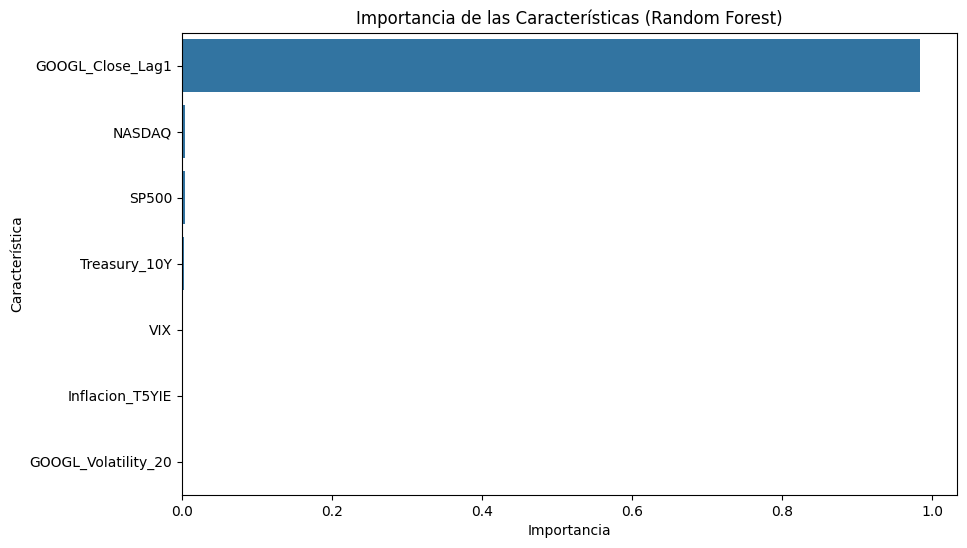


**Coeficientes del Modelo:**
Los modelos basados en árboles, como Random Forest, no tienen coeficientes en el mismo sentido que la regresión lineal.
No hay una ecuación simple como `y = b0 + b1*x1 + ...` donde cada `bi` es un coeficiente fijo.
En cambio, la relación entre las variables independientes y la dependiente es capturada por la estructura de los árboles de decisión (las divisiones y los valores en los nodos hoja).
La 'Importancia de las Características' mostrada arriba es la métrica análoga que indica la influencia relativa de cada variable.

**Summary del Modelo:**
Random Forest (en sklearn) no proporciona un 'summary' estadístico estándar como el de statsmodels para la regresión lineal.
Esto se debe a que su enfoque es más predictivo y menos inferencial (no calcula p-values, R-cuadrado ajustado de la misma manera, etc.).
La evaluación del modelo se basa principalmente en métricas de rendimiento en un conjunto de prueba (como MAE, MSE, R²) y la importancia de las característ

,Forecast_GOOGL_Close_RF
Date,
2025-01-01,190.70
2025-01-02,190.70
2025-01-03,190.70
2025-01-06,190.70
2025-01-07,190.70
...,...
2025-03-25,190.70
2025-03-26,190.70
2025-03-27,190.70



Nota sobre los Pronósticos:
Los pronósticos mostrados son el resultado directo de alimentar el modelo Random Forest entrenado
con los valores definidos para las variables independientes futuras.
Específicamente, para cada fecha futura, el modelo predice el precio basado en:
- El precio pronosticado del día hábil anterior (para GOOGL_Close_Lag1).
- Los últimos valores históricos conocidos de las variables macro/técnicas (Treasury_10Y, VIX, etc.).
La 'ecuación' del Random Forest (la combinación de árboles de decisión) determina cómo estas variables de entrada se transforman en el precio pronosticado.

--- Gráfico de Pronóstico (Random Forest para GOOGL_Close) ---


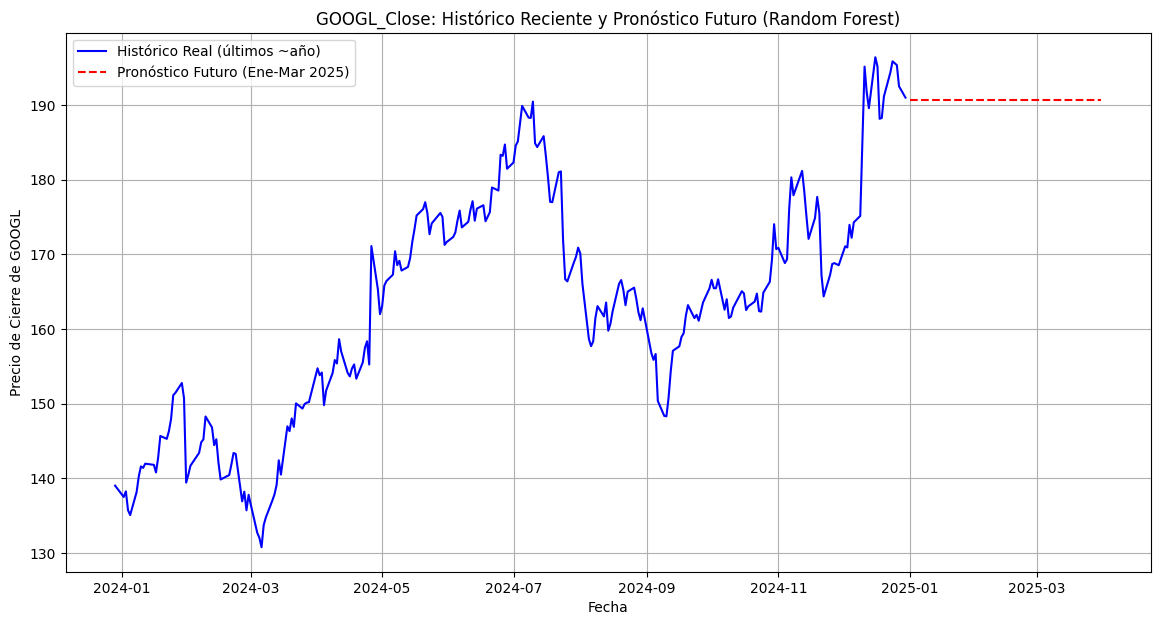

In [ ]:
# --- Random Forest para GOOGL_Close ---
print("\n\n--- Modelo Random Forest para GOOGL_Close ---")

# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from IPython.display import display
import datetime

# Cargar datos (asegúrate de que el archivo existe)
try:
    df = pd.read_csv("dataset_completo_google_amazon.csv")
except FileNotFoundError:
    print("Error: 'dataset_completo_google_amazon.csv' no encontrado. Asegúrate de que el archivo está en la ruta correcta.")
    exit()

# Preprocesamiento básico
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Crear columna de precio rezagado para GOOGL si no existe
if 'GOOGL_Close_Lag1' not in df.columns and 'GOOGL_Close' in df.columns:
    df['GOOGL_Close_Lag1'] = df['GOOGL_Close'].shift(1)


# Definir variables dependientes e independientes para el modelo GOOGL_Close
dependent_var = 'GOOGL_Close'
# Usamos el precio rezagado y las variables macro/técnicas relevantes
independent_vars = [
    'GOOGL_Close_Lag1',
    'Treasury_10Y',
    'VIX',
    'SP500',
    'NASDAQ',
    'Inflacion_T5YIE',
    'GOOGL_Volatility_20' # Asumiendo que esta columna existe y es relevante
]

# Asegurarse de que las columnas requeridas existen o remover las que no
required_cols = [dependent_var] + independent_vars
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    print(f"Error: Faltan las siguientes columnas requeridas en el dataset para el modelo {dependent_var}: {missing_cols}")
    # Intentar crear lag si falta
    if 'GOOGL_Close' in df.columns and 'GOOGL_Close_Lag1' not in df.columns:
         df['GOOGL_Close_Lag1'] = df['GOOGL_Close'].shift(1)
    # Re-verificar después de intentar crear lag
    required_cols = [dependent_var] + independent_vars
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
         print(f"Error persistente: Faltan {missing_cols}")
         exit()

# Eliminar filas con nulos en las columnas necesarias para este modelo
df_model = df.dropna(subset=required_cols).copy()

X = df_model[independent_vars]
y = df_model[dependent_var]

print(f"\nDatos disponibles para el modelo {dependent_var} desde {df_model['Date'].min().date()} hasta {df_model['Date'].max().date()} ({len(df_model)} filas)")


# 3. División de Datos (manteniendo el orden temporal)
# Usaremos un 20% para prueba, como en ejemplos anteriores
test_set_size = 0.2
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_set_size, shuffle=False
)

print(f"\nDatos de entrenamiento: {len(X_train)} filas")
print(f"Datos de prueba:      {len(X_test)} filas")


# 4. Entrenamiento del Modelo Random Forest
# n_estimators: número de árboles en el bosque
# random_state: para reproducibilidad
# n_jobs=-1: usa todos los núcleos del procesador
# Puedes ajustar otros hiperparámetros como max_depth, min_samples_split, etc.
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1, max_depth=10)
print(f"\nEntrenando modelo Random Forest para {dependent_var}...")
rf_model.fit(X_train, y_train)
print("Entrenamiento completado.")


# 5. Detalles del Modelo Random Forest

print("\n\n--- Detalles del Modelo Random Forest ---")

print("\n**¿Cómo funciona Random Forest?**")
print("Random Forest es un algoritmo de aprendizaje conjunto (ensemble) que construye múltiples árboles de decisión durante el entrenamiento y produce la media (para regresión) o moda (para clasificación) de las predicciones de los árboles individuales.")
print("Los pasos clave son:")
print("1.  **Bootstrapping:** Se crean múltiples subconjuntos de datos de entrenamiento muestreando aleatoriamente (con reemplazo) del dataset original. Cada subconjunto se usa para entrenar un árbol de decisión diferente.")
print("2.  **Selección Aleatoria de Características:** En cada nodo de cada árbol de decisión, solo se considera un subconjunto aleatorio de las variables independientes disponibles para encontrar la mejor división. Esto ayuda a diversificar los árboles.")
print("3.  **Construcción de Árboles de Decisión:** Se construye un árbol de decisión completo para cada subconjunto de datos y características seleccionadas. Estos árboles se suelen dejar crecer hasta que estén bastante profundos (a menos que se limite con `max_depth`).")
print("4.  **Agregación (Bagging):** Para hacer una predicción, se pasa la instancia de datos de entrada a través de todos los árboles del bosque. Para problemas de regresión, la predicción final es el promedio de las predicciones de todos los árboles individuales.")
print("Este proceso reduce el sobreajuste (overfitting) y mejora la robustez y precisión general en comparación con un solo árbol de decisión.")


print("\n**Importancia de las Características (Feature Importance):**")
print("Aunque Random Forest no tiene 'coeficientes' en el sentido lineal, sí proporciona una medida de cuánto contribuye cada característica a la reducción total de la varianza (o impureza) en el bosque. Esto indica la importancia relativa de cada variable para las predicciones.")
# Obtener la importancia de las características
if hasattr(rf_model, 'feature_importances_'):
    importance = rf_model.feature_importances_
    feature_importance_df = pd.DataFrame({
        'Feature': independent_vars,
        'Importance': importance
    })
    # Ordenar por importancia descendente
    feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)
    print("Importancia de las variables:")
    display(feature_importance_df)

    # Opcional: Graficar la importancia
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
    plt.title('Importancia de las Características (Random Forest)')
    plt.xlabel('Importancia')
    plt.ylabel('Característica')
    plt.show()
else:
    print("El modelo Random Forest no proporciona importancias de características de esta manera.")


print("\n**Coeficientes del Modelo:**")
print("Los modelos basados en árboles, como Random Forest, no tienen coeficientes en el mismo sentido que la regresión lineal.")
print("No hay una ecuación simple como `y = b0 + b1*x1 + ...` donde cada `bi` es un coeficiente fijo.")
print("En cambio, la relación entre las variables independientes y la dependiente es capturada por la estructura de los árboles de decisión (las divisiones y los valores en los nodos hoja).")
print("La 'Importancia de las Características' mostrada arriba es la métrica análoga que indica la influencia relativa de cada variable.")


print("\n**Summary del Modelo:**")
print("Random Forest (en sklearn) no proporciona un 'summary' estadístico estándar como el de statsmodels para la regresión lineal.")
print("Esto se debe a que su enfoque es más predictivo y menos inferencial (no calcula p-values, R-cuadrado ajustado de la misma manera, etc.).")
print("La evaluación del modelo se basa principalmente en métricas de rendimiento en un conjunto de prueba (como MAE, MSE, R²) y la importancia de las características.")


# 6. Evaluación del Modelo
print("\n\n--- Evaluación del Modelo en Conjunto de Prueba ---")

# Predicciones en el conjunto de prueba
y_pred_test = rf_model.predict(X_test)

# Calcular métricas
mae_test = mean_absolute_error(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test) # RMSE es a menudo más interpretable que MSE
r2_test = r2_score(y_test, y_pred_test)

print(f"MAE (Error Absoluto Medio): {mae_test:.4f}")
print(f"MSE (Error Cuadrático Medio): {mse_test:.4f}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse_test:.4f}")
print(f"R² (Coeficiente de Determinación): {r2_test:.4f}")

print("\n**Precisión del Modelo:**")
print(f"La precisión del modelo se refleja en estas métricas:")
print(f"- Un MAE de {mae_test:.4f} significa que, en promedio, las predicciones del precio de cierre de GOOGL en el conjunto de prueba estuvieron desviadas por {mae_test:.4f} unidades monetarias del valor real.")
print(f"- Un RMSE de {rmse_test:.4f} es similar al MAE pero penaliza más los errores grandes.")
print(f"- Un R² de {r2_test:.4f} significa que el modelo explica aproximadamente el {r2_test*100:.2f}% de la variabilidad en el precio de cierre de GOOGL en el conjunto de prueba.")
# Para precios, un R² muy cercano a 1 es esperado debido a la fuerte correlación con el precio rezagado.
# Las métricas MAE y RMSE dan una idea del error típico en la escala original del precio.


# 7. Pronóstico para los primeros 3 meses de 2025

print("\n\n--- Generando Pronóstico Random Forest para GOOGL_Close (Enero-Marzo 2025) ---")

# Ajustar el modelo final en TODOS los datos disponibles para el pronóstico
# Aunque ya lo entrenamos en test/train, para pronóstico se suele usar todos los datos
rf_model_full_data = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1, max_depth=10)
rf_model_full_data.fit(X, y) # Usar X y y completos (df_model)

print(f"\nModelo Random Forest final entrenado en {len(X)} filas para pronóstico.")


# Determinar el rango de fechas para el pronóstico
start_date_2025 = pd.to_datetime('2025-01-01')
end_date_2025 = pd.to_datetime('2025-03-31')
future_dates = pd.date_range(start=start_date_2025, end=end_date_2025, freq='B') # Fechas hábiles
print(f"Generando pronósticos para el rango de fechas: {future_dates.min().date()} a {future_dates.max().date()} ({len(future_dates)} días hábiles)")


# Construir los datos de entrada futuros (X_future)
# Usaremos la estrategia recursiva para GOOGL_Close_Lag1
# y los últimos valores conocidos del dataset histórico para otras variables.

# Usar los últimos valores conocidos del dataset histórico
last_known_features_raw_all = df_model.iloc[-1].to_dict()
last_known_date = df_model['Date'].iloc[-1]
last_known_close_raw = df_model[dependent_var].iloc[-1] # Último precio real conocido

print(f"  Últimos valores históricos conocidos (fecha {last_known_date.date()}):")
relevant_last_values = {col: last_known_features_raw_all.get(col, 'N/A') for col in independent_vars}
print("  ", relevant_last_values)
print(f"  Último precio real conocido para el lag inicial: {last_known_close_raw:.4f}")


# Crear una plantilla para las features futuras basada en los últimos valores conocidos
current_future_row_template = {col: last_known_features_raw_all.get(col, np.nan) for col in independent_vars}

forecast_values = []
current_lag_col_name = 'GOOGL_Close_Lag1' # Nombre de la columna lag

# Llenar el DataFrame futuro paso a paso para manejar el lag autorregresivo
for i in range(len(future_dates)):
     # Crear la fila de features futuras para el día actual copiando la plantilla
     current_future_row_raw = current_future_row_template.copy()

     # Determinar el valor del lag para este día
     if i == 0:
         # Para el primer día del pronóstico, el lag es el último precio real conocido
         current_lag_raw = last_known_close_raw
     else:
         # Para días subsiguientes, el lag es la PREDICCIÓN del día anterior
         current_lag_raw = forecast_values[-1] # La predicción del día anterior

     current_future_row_raw[current_lag_col_name] = current_lag_raw

     # Convertir a DataFrame para la predicción, asegurando el orden correcto de columnas
     # Es crucial que las columnas estén en el mismo orden que X usado para entrenar
     current_future_df_raw = pd.DataFrame([current_future_row_raw], columns=independent_vars)

     # Realizar la predicción para el día actual
     # Los pronósticos "según las variables independientes" son el resultado de pasar
     # los valores de current_future_df_raw a través del modelo rf_model_full_data.predict()
     current_forecast = rf_model_full_data.predict(current_future_df_raw)
     forecast_values.append(current_forecast[0]) # Guardar la predicción (en escala original)


# Crear un DataFrame para mostrar el pronóstico
forecast_df = pd.DataFrame({
    'Date': future_dates,
    f'Forecast_{dependent_var}_RF': forecast_values
})
forecast_df.set_index('Date', inplace=True)

print("\n--- Tabla de Pronósticos (Random Forest para GOOGL_Close) ---")
pd.options.display.float_format = '{:.2f}'.format # Formato para visualización de precios
display(forecast_df)

print("\nNota sobre los Pronósticos:")
print("Los pronósticos mostrados son el resultado directo de alimentar el modelo Random Forest entrenado")
print("con los valores definidos para las variables independientes futuras.")
print("Específicamente, para cada fecha futura, el modelo predice el precio basado en:")
print("- El precio pronosticado del día hábil anterior (para GOOGL_Close_Lag1).")
print("- Los últimos valores históricos conocidos de las variables macro/técnicas (Treasury_10Y, VIX, etc.).")
print("La 'ecuación' del Random Forest (la combinación de árboles de decisión) determina cómo estas variables de entrada se transforman en el precio pronosticado.")


# 8. Gráfico de Pronóstico (Histórico + Futuro)
print("\n--- Gráfico de Pronóstico (Random Forest para GOOGL_Close) ---")

plt.figure(figsize=(14, 7))
# Graficar datos históricos reales (últimos ~1 año de df_model)
plt.plot(df_model['Date'].iloc[-250:], df_model[dependent_var].iloc[-250:], label='Histórico Real (últimos ~año)', color='blue')
# Graficar pronóstico futuro
plt.plot(forecast_df.index, forecast_df[f'Forecast_{dependent_var}_RF'], label='Pronóstico Futuro (Ene-Mar 2025)', color='red', linestyle='--')

plt.title(f"{dependent_var}: Histórico Reciente y Pronóstico Futuro (Random Forest)")
plt.xlabel("Fecha")
plt.ylabel("Precio de Cierre de GOOGL")
plt.legend()
plt.grid(True)
plt.show()

# Restablecer la opción de formato de pandas si es necesario
# pd.reset_option('display.float_format')

In [ ]:
# --- Pronóstico de GOOGL_Close para un Escenario Específico de Variables Independientes ---
print("\n\n--- Pronóstico Random Forest para GOOGL_Close (Escenario Específico) ---")

# Importar librerías necesarias (asegúrate de que ya has ejecutado las celdas anteriores
# donde se cargan y preprocesan los datos y se entrena el modelo final 'rf_model_full_data')
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor # Necesario si no está ya en memoria
from IPython.display import display

# Supongamos que las variables 'df_model', 'X', 'y', e 'independent_vars'
# ya fueron definidas y que 'rf_model_full_data' ya fue entrenado
# con TODOS los datos disponibles (X, y) del código anterior.
# Si ejecutas esta celda sola, necesitarías cargar y preprocesar los datos
# y entrenar el modelo primero.

# # --- Carga y Preprocesamiento (Si ejecutas esta celda sola) ---
# try:
#     df = pd.read_csv("dataset_completo_google_amazon.csv")
# except FileNotFoundError:
#     print("Error: 'dataset_completo_google_amazon.csv' no encontrado.")
#     exit()
# df['Date'] = pd.to_datetime(df['Date'])
# df = df.sort_values('Date').reset_index(drop=True)
# if 'GOOGL_Close_Lag1' not in df.columns and 'GOOGL_Close' in df.columns:
#     df['GOOGL_Close_Lag1'] = df['GOOGL_Close'].shift(1)

# # Define variables e independent_vars (igual que antes)
# dependent_var = 'GOOGL_Close'
# independent_vars = ['GOOGL_Close_Lag1', 'Treasury_10Y', 'VIX', 'SP500', 'NASDAQ', 'Inflacion_T5YIE', 'GOOGL_Volatility_20']
# required_cols = [dependent_var] + independent_vars
# missing_cols = [col for col in required_cols if col not in df.columns]
# if missing_cols:
#      print(f"Error: Faltan columnas: {missing_cols}")
#      exit()
# df_model = df.dropna(subset=required_cols).copy()
# X = df_model[independent_vars]
# y = df_model[dependent_var]

# # Entrenar el modelo final (Si ejecutas esta celda sola)
# rf_model_full_data = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1, max_depth=10)
# print("\nEntrenando modelo Random Forest con todos los datos para pronóstico...")
# rf_model_full_data.fit(X, y)
# print("Entrenamiento completado.")
# # --- Fin Carga y Entrenamiento (Si ejecutas esta celda sola) ---


# --- Paso Clave: Definir un escenario específico de valores para las variables independientes ---

print("\nIngrese los valores para el escenario de pronóstico:")

# Muestra los últimos valores históricos como referencia
last_known_features_raw_all = df_model.iloc[-1].to_dict()
last_known_date = df_model['Date'].iloc[-1]
print(f"  (Últimos valores históricos conocidos en {last_known_date.date()} para referencia):")
relevant_last_values = {col: last_known_features_raw_all.get(col, 'N/A') for col in independent_vars}
print("  ", relevant_last_values)


# Diccionario para almacenar los valores de entrada del escenario
scenario_values = {}

# Solicita input para cada variable independiente
# Puedes reemplazar esto con valores fijos si no quieres ingresar manualmente cada vez
print("\nPor favor, introduzca un valor para cada variable:")

for col in independent_vars:
    try:
        # Aquí puedes reemplazar input() con valores fijos para pruebas rápidas, ej:
        # value_str = "175.50" if col == 'GOOGL_Close_Lag1' else ("4.2" if col == 'Treasury_10Y' else "...")
        value_str = input(f"  Valor para '{col}': ")
        scenario_values[col] = float(value_str) # Convierte la entrada a float
    except ValueError:
        print(f"  Error: Entrada inválida para '{col}'. Por favor, introduzca un número.")
        # Decide cómo manejar esto: pedir de nuevo, usar un valor por defecto, o salir.
        # Para simplificar, saldremos o podrías poner un valor predeterminado.
        scenario_values[col] = np.nan # Marcar como inválido
        # exit() # Descomentar para salir en caso de error

# Verifica si todas las variables necesarias tienen un valor válido
if any(pd.isna(list(scenario_values.values()))):
    print("\nNo se pueden generar el pronóstico debido a valores de entrada inválidos o faltantes.")
else:
    print("\nValores de entrada definidos para el escenario:")
    display(pd.DataFrame([scenario_values], columns=independent_vars))


    # --- Paso para generar el Pronóstico ---

    # Convertir el diccionario de valores del escenario a un DataFrame con el orden correcto
    # El modelo espera un input con las mismas columnas y en el mismo orden que X_train o X_full
    X_scenario = pd.DataFrame([scenario_values], columns=independent_vars)

    # Realizar la predicción para este escenario específico
    # La predicción se basa *únicamente* en los valores de las variables independientes en X_scenario
    predicted_price_scenario = rf_model_full_data.predict(X_scenario)[0]

    print("\n--- Resultado del Pronóstico ---")
    print(f"Pronóstico del Precio de Cierre de GOOGL para este escenario: {predicted_price_scenario:.4f}")


print("\nNota:")
print("Este pronóstico es una estimación puntual del precio de cierre de GOOGL")
print("basada en la combinación específica de valores de las variables independientes que proporcionaste.")
print("Es como preguntar al modelo: 'Si el precio ayer fuera X, la tasa Y, el VIX Z, etc., ¿cuál sería el precio hoy?'")
print("No es una proyección de serie de tiempo a futuro.")



--- Pronóstico Random Forest para GOOGL_Close (Escenario Específico) ---

Ingrese los valores para el escenario de pronóstico:
  (Últimos valores históricos conocidos en 2024-12-30 para referencia):
   {'GOOGL_Close_Lag1': 192.5382537841797, 'Treasury_10Y': 4.545000076293945, 'VIX': 17.399999618530273, 'SP500': 5906.93994140625, 'NASDAQ': 19486.7890625, 'Inflacion_T5YIE': 2.35, 'GOOGL_Volatility_20': 9.512947084422786}

Por favor, introduzca un valor para cada variable:
  Valor para 'GOOGL_Close_Lag1': 193
  Valor para 'Treasury_10Y': 4.56
  Valor para 'VIX': 18
  Valor para 'SP500': 4096
  Valor para 'NASDAQ': 20000
  Valor para 'Inflacion_T5YIE': 2.35
  Valor para 'GOOGL_Volatility_20': 10

Valores de entrada definidos para el escenario:


,GOOGL_Close_Lag1,Treasury_10Y,VIX,SP500,NASDAQ,Inflacion_T5YIE,GOOGL_Volatility_20
0,193.00,4.56,18.00,4096.00,20000.00,2.35,10.00



--- Resultado del Pronóstico ---
Pronóstico del Precio de Cierre de GOOGL para este escenario: 192.8269

Nota:
Este pronóstico es una estimación puntual del precio de cierre de GOOGL
basada en la combinación específica de valores de las variables independientes que proporcionaste.
Es como preguntar al modelo: 'Si el precio ayer fuera X, la tasa Y, el VIX Z, etc., ¿cuál sería el precio hoy?'
No es una proyección de serie de tiempo a futuro.




--- Modelo Random Forest para AMZN_Close ---

Datos disponibles para el modelo AMZN_Close desde 2021-01-05 hasta 2024-12-30 (996 filas)

Datos de entrenamiento: 796 filas
Datos de prueba:      200 filas

Entrenando modelo Random Forest para AMZN_Close...
Entrenamiento completado.


--- Detalles del Modelo Random Forest ---

**¿Cómo funciona Random Forest?**
Random Forest es un algoritmo de aprendizaje conjunto (ensemble) que construye múltiples árboles de decisión durante el entrenamiento y produce la media (para regresión) o moda (para clasificación) de las predicciones de los árboles individuales.
Los pasos clave son:
1.  **Bootstrapping:** Se crean múltiples subconjuntos de datos de entrenamiento muestreando aleatoriamente (con reemplazo) del dataset original. Cada subconjunto se usa para entrenar un árbol de decisión diferente.
2.  **Selección Aleatoria de Características:** En cada nodo de cada árbol de decisión, solo se considera un subconjunto aleatorio de las variables indepe

,Feature,Importance
0,AMZN_Close_Lag1,0.9891
4,NASDAQ,0.0036
2,VIX,0.0014
6,GOOGL_Volatility_20,0.0014
1,Treasury_10Y,0.0012
7,AMZN_Volatility_20,0.0011
3,SP500,0.0010
5,Inflacion_T5YIE,0.0010


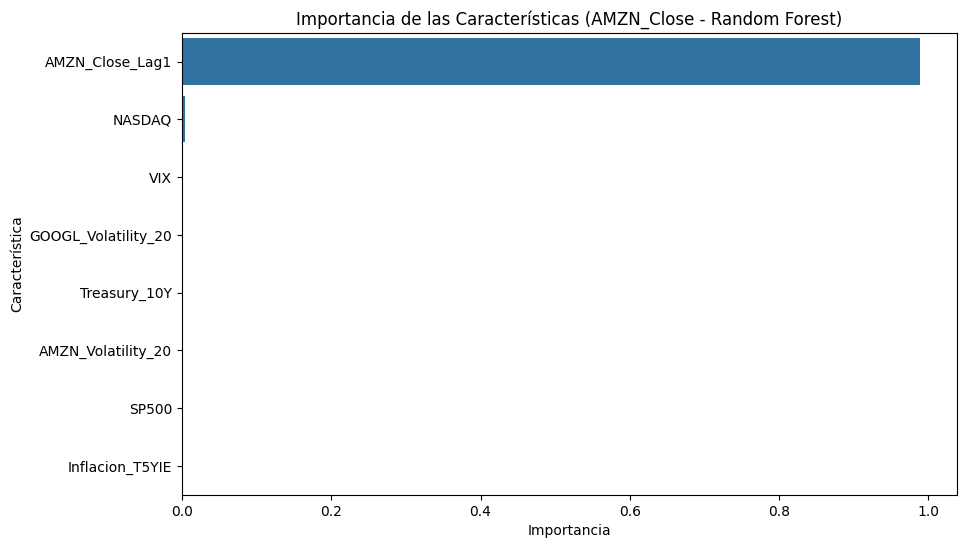


**Coeficientes del Modelo:**
Los modelos basados en árboles, como Random Forest, no tienen coeficientes en el mismo sentido que la regresión lineal.
No hay una ecuación simple como `y = b0 + b1*x1 + ...` donde cada `bi` es un coeficiente fijo.
En cambio, la relación entre las variables independientes y la dependiente es capturada por la estructura de los árboles de decisión (las divisiones y los valores en los nodos hoja).
La 'Importancia de las Características' mostrada arriba es la métrica análoga que indica la influencia relativa de cada variable.

**Summary del Modelo:**
Random Forest (en sklearn) no proporciona un 'summary' estadístico estándar como el de statsmodels para la regresión lineal.
Esto se debe a que su enfoque es más predictivo y menos inferencial (no calcula p-values, R-cuadrado ajustado de la misma manera, etc.).
La evaluación del modelo se basa principalmente en métricas de rendimiento en un conjunto de prueba (como MAE, MSE, R²) y la importancia de las característ

In [4]:
# --- Random Forest para AMZN_Close ---
print("\n\n--- Modelo Random Forest para AMZN_Close ---")

# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from IPython.display import display
import datetime

# Cargar datos (asegúrate de que el archivo existe)
try:
    df = pd.read_csv("dataset_completo_google_amazon.csv")
except FileNotFoundError:
    print("Error: 'dataset_completo_google_amazon.csv' no encontrado. Asegúrate de que el archivo está en la ruta correcta.")
    exit()

# Preprocesamiento básico
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Crear columna de precio rezagado para AMZN si no existe
if 'AMZN_Close_Lag1' not in df.columns and 'AMZN_Close' in df.columns:
    df['AMZN_Close_Lag1'] = df['AMZN_Close'].shift(1)
# Asegurarse de que el lag de GOOGL también existe si se usa en common_independent_vars
if 'GOOGL_Close_Lag1' not in df.columns and 'GOOGL_Close' in df.columns:
    df['GOOGL_Close_Lag1'] = df['GOOGL_Close'].shift(1)


# Definir variables dependientes e independientes para el modelo AMZN_Close
dependent_var = 'AMZN_Close'
# Usamos el precio rezagado de AMZN y las variables macro/técnicas relevantes
common_independent_vars = [
    'Treasury_10Y',
    'VIX',
    'SP500',
    'NASDAQ',
    'Inflacion_T5YIE',
    'GOOGL_Volatility_20', # Puedes usar volatilidad de GOOGL o AMZN o ambas
    'AMZN_Volatility_20'   # Asegúrate de que esta columna exista si la usas
]
# Asegurarse de que las columnas de volatilidad existen o removerlas si no
common_independent_vars = [col for col in common_independent_vars if col in df.columns]

independent_vars = ['AMZN_Close_Lag1'] + common_independent_vars

# Asegurarse de que las columnas requeridas existen o remover las que no
required_cols = [dependent_var] + independent_vars
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    print(f"Error: Faltan las siguientes columnas requeridas en el dataset para el modelo {dependent_var}: {missing_cols}")
    # Intenta crear lag si falta
    if 'AMZN_Close' in df.columns and 'AMZN_Close_Lag1' not in df.columns:
         df['AMZN_Close_Lag1'] = df['AMZN_Close'].shift(1)
    # Re-verificar después de intentar crear lag
    required_cols = [dependent_var] + independent_vars
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
         print(f"Error persistente: Faltan {missing_cols}")
         exit()


# Eliminar filas con nulos en las columnas necesarias para este modelo
df_model = df.dropna(subset=required_cols).copy()

X = df_model[independent_vars]
y = df_model[dependent_var]

print(f"\nDatos disponibles para el modelo {dependent_var} desde {df_model['Date'].min().date()} hasta {df_model['Date'].max().date()} ({len(df_model)} filas)")


# 3. División de Datos (manteniendo el orden temporal)
# Usaremos un 20% para prueba
test_set_size = 0.2
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_set_size, shuffle=False
)

print(f"\nDatos de entrenamiento: {len(X_train)} filas")
print(f"Datos de prueba:      {len(X_test)} filas")


# 4. Entrenamiento del Modelo Random Forest
# n_estimators: número de árboles, random_state: reproducibilidad, n_jobs=-1: usar todos los núcleos
# Ajustes de hiperparámetros de ejemplo
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1, max_depth=10)
print(f"\nEntrenando modelo Random Forest para {dependent_var}...")
rf_model.fit(X_train, y_train)
print("Entrenamiento completado.")


# 5. Detalles del Modelo Random Forest

print("\n\n--- Detalles del Modelo Random Forest ---")

print("\n**¿Cómo funciona Random Forest?**")
print("Random Forest es un algoritmo de aprendizaje conjunto (ensemble) que construye múltiples árboles de decisión durante el entrenamiento y produce la media (para regresión) o moda (para clasificación) de las predicciones de los árboles individuales.")
print("Los pasos clave son:")
print("1.  **Bootstrapping:** Se crean múltiples subconjuntos de datos de entrenamiento muestreando aleatoriamente (con reemplazo) del dataset original. Cada subconjunto se usa para entrenar un árbol de decisión diferente.")
print("2.  **Selección Aleatoria de Características:** En cada nodo de cada árbol de decisión, solo se considera un subconjunto aleatorio de las variables independientes disponibles para encontrar la mejor división. Esto ayuda a diversificar los árboles.")
print("3.  **Construcción de Árboles de Decisión:** Se construye un árbol de decisión completo para cada subconjunto de datos y características seleccionadas. Estos árboles se suelen dejar crecer hasta que estén bastante profundos (a menos que se limite con `max_depth`).")
print("4.  **Agregación (Bagging):** Para hacer una predicción, se pasa la instancia de datos de entrada a través de todos los árboles del bosque. Para problemas de regresión, la predicción final es el promedio de las predicciones de todos los árboles individuales.")
print("Este proceso reduce el sobreajuste (overfitting) y mejora la robustez y precisión general en comparación con un solo árbol de decisión.")


print("\n**Importancia de las Características (Feature Importance):**")
print("Aunque Random Forest no tiene 'coeficientes' en el sentido lineal, sí proporciona una medida de cuánto contribuye cada característica a la reducción total de la varianza (o impureza) en el bosque. Esto indica la importancia relativa de cada variable para las predicciones.")
# Obtener la importancia de las características
if hasattr(rf_model, 'feature_importances_'):
    importance = rf_model.feature_importances_
    feature_importance_df = pd.DataFrame({
        'Feature': independent_vars,
        'Importance': importance
    })
    # Ordenar por importancia descendente
    feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)
    print("Importancia de las variables para AMZN_Close:")
    display(feature_importance_df)

    # Opcional: Graficar la importancia
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
    plt.title(f'Importancia de las Características ({dependent_var} - Random Forest)')
    plt.xlabel('Importancia')
    plt.ylabel('Característica')
    plt.show()
else:
    print("El modelo Random Forest no proporciona importancias de características de esta manera.")


print("\n**Coeficientes del Modelo:**")
print("Los modelos basados en árboles, como Random Forest, no tienen coeficientes en el mismo sentido que la regresión lineal.")
print("No hay una ecuación simple como `y = b0 + b1*x1 + ...` donde cada `bi` es un coeficiente fijo.")
print("En cambio, la relación entre las variables independientes y la dependiente es capturada por la estructura de los árboles de decisión (las divisiones y los valores en los nodos hoja).")
print("La 'Importancia de las Características' mostrada arriba es la métrica análoga que indica la influencia relativa de cada variable.")


print("\n**Summary del Modelo:**")
print("Random Forest (en sklearn) no proporciona un 'summary' estadístico estándar como el de statsmodels para la regresión lineal.")
print("Esto se debe a que su enfoque es más predictivo y menos inferencial (no calcula p-values, R-cuadrado ajustado de la misma manera, etc.).")
print("La evaluación del modelo se basa principalmente en métricas de rendimiento en un conjunto de prueba (como MAE, MSE, R²) y la importancia de las características.")


# 6. Evaluación del Modelo
print("\n\n--- Evaluación del Modelo en Conjunto de Prueba ---")

# Predicciones en el conjunto de prueba
y_pred_test = rf_model.predict(X_test)

# Calcular métricas
mae_test = mean_absolute_error(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test) # RMSE es a menudo más interpretable que MSE
r2_test = r2_score(y_test, y_pred_test)

print(f"MAE (Error Absoluto Medio): {mae_test:.4f}")
print(f"MSE (Error Cuadrático Medio): {mse_test:.4f}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse_test:.4f}")
print(f"R² (Coeficiente de Determinación): {r2_test:.4f}")

print("\n**Precisión del Modelo:**")
print(f"La precisión del modelo se refleja en estas métricas:")
print(f"- Un MAE de {mae_test:.4f} significa que, en promedio, las predicciones del precio de cierre de AMZN en el conjunto de prueba estuvieron desviadas por {mae_test:.4f} unidades monetarias del valor real.")
print(f"- Un RMSE de {rmse_test:.4f} es similar al MAE pero penaliza más los errores grandes.")
print(f"- Un R² de {r2_test:.4f} significa que el modelo explica aproximadamente el {r2_test*100:.2f}% de la variabilidad en el precio de cierre de AMZN en el conjunto de prueba.")
# Para precios, un R² muy cercano a 1 es esperado debido a la fuerte correlación con el precio rezagado.
# Las métricas MAE y RMSE dan una idea del error típico en la escala original del precio.


# 7. Pronóstico de Serie de Tiempo para los primeros 3 meses de 2025

print("\n\n--- Generando Pronóstico de Serie de Tiempo (Enero-Marzo 2025) ---")

# Ajustar el modelo final en TODOS los datos disponibles para el pronóstico
# Aunque ya lo entrenamos en test/train, para

In [6]:
# --- Pronóstico de AMZN_Close para Escenarios Específicos de Variables Independientes ---
print("\n\n--- Pronóstico Random Forest para AMZN_Close (Escenarios Específicos) ---")

# Importar librerías necesarias (asegúrate de que ya has ejecutado las celdas anteriores
# donde se cargan y preprocesan los datos y se entrena el modelo final para AMZN_Close)
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor # Necesario si no está ya en memoria
from IPython.display import display

# Supongamos que las variables 'df_model_amzn', 'X_amzn', 'y_amzn', e 'independent_vars_amzn'
# ya fueron definidas y que 'rf_model_full_data_amzn' ya fue entrenado
# con TODOS los datos disponibles para AMZN_Close.
# Si ejecutas esta celda sola, necesitarías cargar y preprocesar los datos para AMZN
# y entrenar el modelo AMZN_Close primero.


# --- Carga y Preprocesamiento para AMZN (Si ejecutas esta celda sola) ---
try:
    df = pd.read_csv("dataset_completo_google_amazon.csv")
except FileNotFoundError:
    print("Error: 'dataset_completo_google_amazon.csv' no encontrado.")
    exit()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
# Crear columna de precio rezagado para AMZN
if 'AMZN_Close_Lag1' not in df.columns and 'AMZN_Close' in df.columns:
    df['AMZN_Close_Lag1'] = df['AMZN_Close'].shift(1)

# Definir variables para AMZN_Close
dependent_var_amzn = 'AMZN_Close'
common_independent_vars = ['Treasury_10Y', 'VIX', 'SP500', 'NASDAQ', 'Inflacion_T5YIE', 'GOOGL_Volatility_20', 'AMZN_Volatility_20']
# Asegurarse de que las columnas de volatilidad existen o removerlas si no
common_independent_vars = [col for col in common_independent_vars if col in df.columns] # Verificar contra df original

independent_vars_amzn = ['AMZN_Close_Lag1'] + common_independent_vars
required_cols_amzn = [dependent_var_amzn] + independent_vars_amzn
missing_cols_amzn = [col for col in required_cols_amzn if col not in df.columns]
if missing_cols_amzn:
    print(f"Error: Faltan columnas para AMZN: {missing_cols_amzn}")
    # Intenta crear lag si falta
    if 'AMZN_Close' in df.columns and 'AMZN_Close_Lag1' not in df.columns:
         df['AMZN_Close_Lag1'] = df['AMZN_Close'].shift(1)
    # Re-verificar después de intentar crear lag
    required_cols_amzn = [dependent_var_amzn] + independent_vars_amzn
    missing_cols_amzn = [col for col in required_cols_amzn if col not in df.columns]
    if missing_cols_amzn:
         print(f"Error persistente: Faltan {missing_cols_amzn}")
         exit()


# Eliminar filas con nulos en las columnas necesarias para este modelo
# Aquí es donde se crea df_model_amzn
df_model_amzn = df.dropna(subset=required_cols_amzn).copy()

X_amzn = df_model_amzn[independent_vars_amzn]
y_amzn = df_model_amzn[dependent_var_amzn]


# Entrenar el modelo final AMZN_Close (Si ejecutas esta celda sola)
print("\nEntrenando modelo Random Forest para AMZN_Close con todos los datos...")
rf_model_full_data_amzn = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1, max_depth=10)
rf_model_full_data_amzn.fit(X_amzn, y_amzn)
print("Entrenamiento completado.")
# --- Fin Carga y Entrenamiento para AMZN (Si ejecutas esta celda sola) ---


# Esta línea ahora debería funcionar porque df_model_amzn está definido
independent_vars_amzn = [col for col in independent_vars_amzn if col in df_model_amzn.columns] # Asegurarse que coincida con X_amzn


print("\n**Pronóstico de Escenario Específico:**")
print("En lugar de proyectar una serie de tiempo, aquí vamos a ingresar un conjunto (o varios conjuntos)")
print("de valores para las variables independientes y obtener la predicción del precio de AMZN para esa combinación específica.")
print("Esto es útil para probar escenarios hipotéticos.")

# --- Paso Clave: Definir los escenarios utilizando un DataFrame ---

print("\n--- Definición de Escenarios de Variables Independientes ---")

# Puedes crear un DataFrame con uno o múltiples escenarios (filas).
# Asegúrate de que las columnas coincidan exactamente con 'independent_vars_amzn'
# y estén en el mismo orden.

# Ejemplo de ÚLTIMOS valores históricos como un escenario de referencia:
last_known_features_amzn = df_model_amzn[independent_vars_amzn].iloc[-1].to_dict()
last_known_date_amzn = df_model_amzn['Date'].iloc[-1]
print(f"  (Últimos valores históricos conocidos en {last_known_date_amzn.date()} para referencia):")
display(pd.DataFrame([last_known_features_amzn], columns=independent_vars_amzn).applymap(lambda x: f'{x:.4f}' if isinstance(x, (int, float)) else x))


# Define tus propios escenarios lógicos aquí:
# Escenario 1: Continuación de las tendencias recientes (usando los últimos valores)
escenario1 = last_known_features_amzn.copy()

# Escenario 2: Un escenario optimista (ej: VIX bajo, mercados subiendo, tasas bajando, inflación controlada)
escenario2 = {
    'AMZN_Close_Lag1': 170.00,  # Un precio rezagado más alto
    'Treasury_10Y': 3.8,        # Tasa del Tesoro más baja
    'VIX': 12.0,                # VIX más bajo (menos miedo)
    'SP500': 5500.0,            # S&P 500 más alto
    'NASDAQ': 17000.0,          # NASDAQ más alto
    'Inflacion_T5YIE': 2.2,     # Expectativa de Inflación más baja
    'GOOGL_Volatility_20': 0.01, # Menor volatilidad general
    'AMZN_Volatility_20': 0.01  # Menor volatilidad de AMZN
}
# Asegurarse de que este diccionario solo contiene columnas que el modelo espera
escenario2 = {col: escenario2.get(col, np.nan) for col in independent_vars_amzn}
if any(pd.isna(list(escenario2.values()))):
    print("Advertencia: Escenario 2 contiene columnas no esperadas o faltantes.")
    # Decide cómo manejarlo: ajusta el diccionario o los independent_vars_amzn
    # For now, we'll just note it. It will fail during prediction if columns mismatch.


# Escenario 3: Un escenario pesimista (ej: VIX alto, mercados bajando, tasas subiendo)
escenario3 = {
    'AMZN_Close_Lag1': 140.00,  # Un precio rezagado más bajo
    'Treasury_10Y': 4.8,        # Tasa del Tesoro más alta
    'VIX': 25.0,                # VIX más alto (más miedo)
    'SP500': 4800.0,            # S&P 500 más bajo
    'NASDAQ': 14000.0,          # NASDAQ más bajo
    'Inflacion_T5YIE': 3.0,     # Expectativa de Inflación más alta
    'GOOGL_Volatility_20': 0.03, # Mayor volatilidad general
    'AMZN_Volatility_20': 0.03  # Mayor volatilidad de AMZN
}
# Asegurarse de que este diccionario solo contiene columnas que el modelo espera
escenario3 = {col: escenario3.get(col, np.nan) for col in independent_vars_amzn}
if any(pd.isna(list(escenario3.values()))):
    print("Advertencia: Escenario 3 contiene columnas no esperadas o faltantes.")


# Crear el DataFrame de escenarios
# Es CRUCIAL que las columnas estén en el mismo orden que independent_vars_amzn
scenarios_df = pd.DataFrame([escenario1, escenario2, escenario3], columns=independent_vars_amzn)

print("\nDataFrame con los escenarios definidos:")
display(scenarios_df.applymap(lambda x: f'{x:.4f}' if isinstance(x, (int, float)) else x)) # Mostrar con formato


# --- Paso para generar los Pronósticos para los Escenarios ---

print("\n--- Generando Pronósticos para los Escenarios Definidos ---")

# Asegúrate de que el modelo rf_model_full_data_amzn está entrenado y disponible
if 'rf_model_full_data_amzn' not in locals():
    print("Error: El modelo 'rf_model_full_data_amzn' no está entrenado. Por favor, ejecuta la sección de entrenamiento primero.")
else:
    # Realizar las predicciones para todos los escenarios en el DataFrame
    # La predicción se basa *únicamente* en los valores de las variables independientes en scenarios_df
    predicted_prices_scenarios = rf_model_full_data_amzn.predict(scenarios_df)

    # Añadir los pronósticos al DataFrame de escenarios para una mejor visualización
    scenarios_df[f'Pronóstico_{dependent_var_amzn}_RF'] = predicted_prices_scenarios

    print("\n--- Resultados del Pronóstico por Escenario ---")
    # Mostrar el DataFrame con los valores de entrada y el pronóstico resultante
    display(scenarios_df.applymap(lambda x: f'{x:.4f}' if isinstance(x, (int, float)) else x)) # Mostrar con formato

print("\nNota sobre los Resultados:")
print("Cada fila representa un escenario de entrada distinto.")
print("La última columna muestra el precio de cierre de AMZN pronosticado por el modelo Random Forest")
print("para la combinación específica de valores de variables independientes en esa fila.")
print("Esto te permite comparar cómo el modelo responde a diferentes condiciones de mercado hipotéticas.")

# Restablecer la opción de formato de pandas si es necesario
# pd.reset_option('display.float_format')



--- Pronóstico Random Forest para AMZN_Close (Escenarios Específicos) ---

Entrenando modelo Random Forest para AMZN_Close con todos los datos...
Entrenamiento completado.

**Pronóstico de Escenario Específico:**
En lugar de proyectar una serie de tiempo, aquí vamos a ingresar un conjunto (o varios conjuntos)
de valores para las variables independientes y obtener la predicción del precio de AMZN para esa combinación específica.
Esto es útil para probar escenarios hipotéticos.

--- Definición de Escenarios de Variables Independientes ---
  (Últimos valores históricos conocidos en 2024-12-30 para referencia):


<ipython-input-6-4025819508>:89: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  display(pd.DataFrame([last_known_features_amzn], columns=independent_vars_amzn).applymap(lambda x: f'{x:.4f}' if isinstance(x, (int, float)) else x))


,AMZN_Close_Lag1,Treasury_10Y,VIX,SP500,NASDAQ,Inflacion_T5YIE,GOOGL_Volatility_20,AMZN_Volatility_20
0,223.7500,4.5450,17.4000,5906.9399,19486.7891,2.3500,9.5129,5.6661



DataFrame con los escenarios definidos:


<ipython-input-6-4025819508>:137: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  display(scenarios_df.applymap(lambda x: f'{x:.4f}' if isinstance(x, (int, float)) else x)) # Mostrar con formato


,AMZN_Close_Lag1,Treasury_10Y,VIX,SP500,NASDAQ,Inflacion_T5YIE,GOOGL_Volatility_20,AMZN_Volatility_20
0,223.7500,4.5450,17.4000,5906.9399,19486.7891,2.3500,9.5129,5.6661
1,170.0000,3.8000,12.0000,5500.0000,17000.0000,2.2000,0.0100,0.0100
2,140.0000,4.8000,25.0000,4800.0000,14000.0000,3.0000,0.0300,0.0300



--- Generando Pronósticos para los Escenarios Definidos ---

--- Resultados del Pronóstico por Escenario ---


<ipython-input-6-4025819508>:157: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  display(scenarios_df.applymap(lambda x: f'{x:.4f}' if isinstance(x, (int, float)) else x)) # Mostrar con formato


,AMZN_Close_Lag1,Treasury_10Y,VIX,SP500,NASDAQ,Inflacion_T5YIE,GOOGL_Volatility_20,AMZN_Volatility_20,Pronóstico_AMZN_Close_RF
0,223.7500,4.5450,17.4000,5906.9399,19486.7891,2.3500,9.5129,5.6661,221.8344
1,170.0000,3.8000,12.0000,5500.0000,17000.0000,2.2000,0.0100,0.0100,173.3015
2,140.0000,4.8000,25.0000,4800.0000,14000.0000,3.0000,0.0300,0.0300,143.1684



Nota sobre los Resultados:
Cada fila representa un escenario de entrada distinto.
La última columna muestra el precio de cierre de AMZN pronosticado por el modelo Random Forest
para la combinación específica de valores de variables independientes en esa fila.
Esto te permite comparar cómo el modelo responde a diferentes condiciones de mercado hipotéticas.


## Gradient Boosting

In [7]:
# --- Gradient Boosting ---
# Cargar datos
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
df = pd.read_csv("dataset_completo_google_amazon.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Aquí insertarías el código específico del modelo Gradient Boosting
# incluyendo:
# - División de datos
# - Entrenamiento
# - Predicción
# - Evaluación con MAE, MSE, R²
# - Interpretación


In [12]:
# --- Random Forest para GOOGL/AMZN Close y Return_1d en Múltiples Ventanas ---
print("\n\n--- Modelos Random Forest para GOOGL/AMZN Precio y Retorno ---")

# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor # Importar Random Forest
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# No necesitamos statsmodels ni scaler para RF típicamente
from IPython.display import display
import datetime # Para definir fechas de ventanas

# Cargar datos (asegúrate de que el archivo existe)
try:
    df = pd.read_csv("dataset_completo_google_amazon.csv")
except FileNotFoundError:
    print("Error: 'dataset_completo_google_amazon.csv' no encontrado. Asegúrate de que el archivo está en la ruta correcta.")
    exit()

# Preprocesamiento básico
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Crear columnas de precio rezagado para ambos stocks si no existen
if 'GOOGL_Close_Lag1' not in df.columns and 'GOOGL_Close' in df.columns:
    df['GOOGL_Close_Lag1'] = df['GOOGL_Close'].shift(1)
if 'AMZN_Close_Lag1' not in df.columns and 'AMZN_Close' in df.columns:
    df['AMZN_Close_Lag1'] = df['AMZN_Close'].shift(1)

# Definir las variables independientes comunes (macro + técnicas)
# Excluimos los lags aquí para evitar duplicidad al definir X para Precio vs Retorno
common_independent_vars = [
    'Treasury_10Y',
    'VIX',
    'SP500',
    'NASDAQ',
    'Inflacion_T5YIE',
    'GOOGL_Volatility_20', # Usamos la volatilidad de GOOGL como feature general, puedes añadir AMZN si la tienes
    'AMZN_Volatility_20' # Añadir volatilidad de AMZN si está disponible y quieres usarla
]

# Asegurarse de que las columnas de volatilidad existen o removerlas si no
common_independent_vars = [col for col in common_independent_vars if col in df.columns]


# Definir las variables dependientes y sus conjuntos de variables independientes correspondientes
models_config = {
    'GOOGL_Close': {
        'dependent_var': 'GOOGL_Close',
        'independent_vars': ['GOOGL_Close_Lag1'] + common_independent_vars,
        'dropna_subset': ['GOOGL_Close', 'GOOGL_Close_Lag1'] + common_independent_vars,
        'forecast_format': '{:.2f}' # Formato para precios
    },
    'GOOGL_Return_1d': {
        'dependent_var': 'GOOGL_Return_1d',
        'independent_vars': common_independent_vars, # No usamos el retorno rezagado típicamente
        'dropna_subset': ['GOOGL_Return_1d'] + common_independent_vars,
        'forecast_format': '{:.6f}' # Formato para retornos
    },
    'AMZN_Close': {
        'dependent_var': 'AMZN_Close',
        'independent_vars': ['AMZN_Close_Lag1'] + common_independent_vars,
        'dropna_subset': ['AMZN_Close', 'AMZN_Close_Lag1'] + common_independent_vars,
        'forecast_format': '{:.2f}' # Formato para precios
    },
    'AMZN_Return_1d': {
        'dependent_var': 'AMZN_Return_1d',
        'independent_vars': common_independent_vars, # No usamos el retorno rezagado típicamente
        'dropna_subset': ['AMZN_Return_1d'] + common_independent_vars,
        'forecast_format': '{:.6f}' # Formato para retornos
    }
}

# Eliminar filas con nulos que afecten a *cualquiera* de los modelos para tener un DataFrame base consistente
all_required_cols = set()
for config in models_config.values():
    all_required_cols.update(config['dropna_subset'])

missing_cols = [col for col in all_required_cols if col not in df.columns]
if missing_cols:
    print(f"Error: Faltan las siguientes columnas requeridas en el dataset: {missing_cols}")
    # Intentar crear lags si faltan
    if 'GOOGL_Close' in df.columns and 'GOOGL_Close_Lag1' not in df.columns:
         df['GOOGL_Close_Lag1'] = df['GOOGL_Close'].shift(1)
    if 'AMZN_Close' in df.columns and 'AMZN_Close_Lag1' not in df.columns:
         df['AMZN_Close_Lag1'] = df['AMZN_Close'].shift(1)
    # Re-verificar después de intentar crear lags
    all_required_cols = set()
    for config in models_config.values():
        all_required_cols.update(config['dropna_subset'])
    missing_cols = [col for col in all_required_cols if col not in df.columns]
    if missing_cols:
         print(f"Error persistente: Faltan {missing_cols}")
         exit()


df_clean = df.dropna(subset=list(all_required_cols)).copy()


# Definir las ventanas de tiempo (fechas de corte)
# Ejemplo de 4 ventanas de 1 año de entrenamiento + 3 meses de prueba
# Ajusta estas fechas según tu dataset
end_date_full = df_clean['Date'].max()

window_defs = [
    {'name': 'Ventana 1 (2019)', 'train_end': '2019-12-31', 'test_end': '2020-03-31'},
    {'name': 'Ventana 2 (2020)', 'train_end': '2020-12-31', 'test_end': '2021-03-31'},
    {'name': 'Ventana 3 (2021)', 'train_end': '2021-12-31', 'test_end': '2022-03-31'},
    {'name': 'Ventana 4 (2022)', 'train_end': '2022-12-31', 'test_end': '2023-03-31'}
    # Puedes añadir más ventanas o ajustar los tamaños
]

# Asegurarse de que las fechas de las ventanas no exceden los datos disponibles
for window in window_defs:
    # Asegurar al menos 3 meses de datos *disponibles* después del train_end para test
    min_test_start = pd.to_datetime(window['train_end'])
    actual_test_end_cap = df_clean[df_clean['Date'] > min_test_start]['Date'].max() # Última fecha después del fin de entrenamiento

    # Si no hay datos después del fin de entrenamiento, ajusta la ventana o salta
    if pd.isna(actual_test_end_cap):
         print(f"Advertencia: No hay datos disponibles después de {window['train_end'].date()} para la ventana {window['name']}. Esta ventana será saltada.")
         window['skip'] = True
         continue
    else:
         window['skip'] = False

    window['train_end'] = pd.to_datetime(window['train_end'])
    window['test_end'] = min(pd.to_datetime(window['test_end']), actual_test_end_cap)


# Diccionarios para almacenar resultados de evaluación por ventana
evaluation_results_by_window = {}

# Iterar por cada modelo (GOOGL/AMZN, Precio/Retorno)
for model_name, config in models_config.items():
    print(f"\n### Procesando: {model_name} ###")

    dependent_var = config['dependent_var']
    independent_vars = config['independent_vars']
    # Although we already filtered df_clean, it's good practice to use it
    dropna_subset = config['dropna_subset']
    forecast_format = config['forecast_format']

    # Asegurarse de que las columnas requeridas para este modelo específico existen
    model_missing_cols = [col for col in independent_vars + [dependent_var] if col not in df_clean.columns]
    if model_missing_cols:
        print(f"Advertencia: Faltan columnas para el modelo {model_name}: {model_missing_cols}. Saltando este modelo.")
        continue # Salta este modelo si faltan columnas

    # Crear X y y para este modelo específico usando el df_clean
    X = df_clean[independent_vars]
    y = df_clean[dependent_var]

    evaluation_results_by_window[model_name] = {}

    # Iterar por cada ventana de tiempo
    for window in window_defs:
        if window.get('skip', False):
             continue # Saltar ventana si no hay datos de prueba suficientes

        window_name = window['name']
        train_end = window['train_end']
        test_end = window['test_end']

        print(f"\n--- Ventana: {window_name} (Entrenamiento hasta {train_end.date()}, Prueba hasta {test_end.date()}) ---")

        # Dividir los datos según la ventana actual
        train_mask = (df_clean['Date'] <= train_end)
        test_mask = (df_clean['Date'] > train_end) & (df_clean['Date'] <= test_end)

        X_train_window = X.loc[train_mask]
        y_train_window = y.loc[train_mask]
        X_test_window = X.loc[test_mask]
        y_test_window = y.loc[test_mask]

        # Verificar si hay datos en la ventana
        if len(X_train_window) == 0 or len(X_test_window) == 0:
            print(f"  Advertencia: No hay suficientes datos en la ventana '{window_name}'. Entrenamiento={len(X_train_window)}, Prueba={len(X_test_window)}. Saltando.")
            evaluation_results_by_window[model_name][window_name] = {
                 'MAE': np.nan, 'MSE': np.nan, 'RMSE': np.nan, 'R2': np.nan,
                 'Train_Samples': len(X_train_window), 'Test_Samples': len(X_test_window)
            }
            continue

        print(f"  Entrenamiento: {len(X_train_window)} filas, Prueba: {len(X_test_window)} filas")

        # 7. Entrenamiento del Modelo Random Forest
        # Puedes ajustar n_estimators, max_depth, etc.
        rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
        rf_model.fit(X_train_window, y_train_window)

        # 8. Evaluación del Modelo
        y_pred_test_window = rf_model.predict(X_test_window)

        mae_window = mean_absolute_error(y_test_window, y_pred_test_window)
        mse_window = mean_squared_error(y_test_window, y_pred_test_window)
        rmse_window = np.sqrt(mse_window)
        r2_window = r2_score(y_test_window, y_pred_test_window)

        # CORRECCIÓN: Usar formato fijo para las métricas de evaluación
        print(f"  MAE:  {mae_window:.4f}")
        print(f"  MSE:  {mse_window:.4f}")
        print(f"  RMSE: {rmse_window:.4f}")
        print(f"  R²:   {r2_window:.4f}")

        # 9. Almacenar Resultados
        evaluation_results_by_window[model_name][window_name] = {
            'MAE': mae_window,
            'MSE': mse_window,
            'RMSE': rmse_window,
            'R2': r2_window,
            'Train_Samples': len(X_train_window),
            'Test_Samples': len(X_test_window)
        }

# Mostrar tabla resumen de métricas por ventana
print("\n\n--- Resumen de Métricas de Evaluación (Random Forest por Ventana) ---")
summary_data = []
for model_name, window_results in evaluation_results_by_window.items():
    for window_name, metrics in window_results.items():
        summary_data.append({
            'Modelo': model_name,
            'Ventana': window_name,
            'MAE': metrics['MAE'],
            'MSE': metrics['MSE'],
            'RMSE': metrics['RMSE'],
            'R²': metrics['R2'],
            'Train_Samples': metrics['Train_Samples'],
            'Test_Samples': metrics['Test_Samples']
        })

summary_df = pd.DataFrame(summary_data)
# Formatear las métricas según si es precio o retorno para mejor legibilidad
def format_metric(row):
    model_name = row['Modelo']
    # Usar formato fijo para las métricas aquí también en el resumen
    return f"MAE: {row['MAE']:.4f}, RMSE: {row['RMSE']:.4f}, R²: {row['R²']:.4f}"

summary_df['Métricas'] = summary_df.apply(format_metric, axis=1)
display(summary_df[['Modelo', 'Ventana', 'Train_Samples', 'Test_Samples', 'Métricas']])


# --- Pronóstico para los primeros 3 meses de 2025 ---

print("\n\n--- Pronósticos Random Forest para Enero-Marzo 2025 ---")

# Ajustar los modelos finales en TODOS los datos disponibles
final_models = {}
forecast_dfs = {} # Para almacenar los DataFrames de pronóstico finales

# Determinar el rango de fechas para el pronóstico
start_date_2025 = pd.to_datetime('2025-01-01')
end_date_2025 = pd.to_datetime('2025-03-31')
# Creamos una serie de fechas hábiles en 2025
future_dates = pd.date_range(start=start_date_2025, end=end_date_2025, freq='B')
print(f"Generando pronósticos para el rango de fechas: {future_dates.min().date()} a {future_dates.max().date()}")


for model_name, config in models_config.items():
    print(f"\nGenerando pronóstico para: {model_name}")

    dependent_var = config['dependent_var']
    independent_vars = config['independent_vars']
    forecast_format = config['forecast_format'] # Este formato se usa para mostrar el pronóstico final

    # Crear X y y para este modelo específico usando el df_clean (todos los datos disponibles)
    X_full = df_clean[independent_vars]
    y_full = df_clean[dependent_var]

    # Entrenar el modelo final en todos los datos limpios
    rf_model_full_data = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf_model_full_data.fit(X_full, y_full)
    final_models[model_name] = rf_model_full_data


    # Crear un DataFrame para las features futuras (X_future) - RAW (no escalado)
    # Esta es la parte que requiere cuidado, especialmente para los modelos de Precio (con lag)

    # Usar los últimos valores conocidos (NO ESCALADOS) del dataset histórico
    last_known_features_raw = df_clean[independent_vars].iloc[-1].to_dict()
    last_known_date = df_clean['Date'].iloc[-1]
    # Corrected the formatting line:
    print(f"  Último precio real conocido ({dependent_var} en {last_known_date.date()}): {last_known_features_raw.get(dependent_var, df_clean[dependent_var].iloc[-1]):{config['forecast_format']}}") # Use config['forecast_format'] directly


    X_future_raw = pd.DataFrame(index=future_dates, columns=independent_vars)
    X_future_raw.index.name = 'Date'

    # Poblar las columnas con los últimos valores conocidos, EXCEPTO los lags de precio
    cols_to_populate_last_value = [col for col in independent_vars if '_Lag1' not in col]
    for col in cols_to_populate_last_value:
         X_future_raw[col] = last_known_features_raw[col]

    # Implementar la estrategia de pronóstico (autorregresivo para precios)
    forecast_values = []

    # Si es un modelo de Precio, necesitamos el último precio REAL conocido para el primer lag
    if '_Close' in model_name:
        last_known_close_raw = df_clean[dependent_var].iloc[-1]
        # Removed the potentially problematic print line here as it was moved above

        current_lag_col = [col for col in independent_vars if '_Close_Lag1' in col]
        if len(current_lag_col) == 1:
             current_lag_col_name = current_lag_col[0]
        else:
             print(f"  Advertencia: No se encontró una columna de lag de precio '_Close_Lag1' para el modelo {model_name}. El pronóstico no será autorregresivo.")
             current_lag_col_name = None # No usar lag autorregresivo si no se encuentra la columna


        # Llenar el DataFrame futuro paso a paso para manejar el lag autorregresivo
        for i in range(len(future_dates)):
             current_date = future_dates[i]
             # Crear la fila de features futuras para el día actual
             # Usar el último valor conocido para las features no lag
             current_future_row_raw = {col: X_future_raw.loc[current_date, col] for col in cols_to_populate_last_value}
             # Nota: Asegurarse de que los valores de X_future_raw se han poblado correctamente antes de este bucle

             # Determinar el valor del lag para este día
             if current_lag_col_name:
                if i == 0:
                    # Para el primer día del pronóstico, el lag es el último precio real conocido
                    current_lag_raw = last_known_close_raw
                else:
                    # Para días subsiguientes, el lag es la PREDICCIÓN del día anterior
                    current_lag_raw = forecast_values[-1] # La predicción del día anterior

                current_future_row_raw[current_lag_col_name] = current_lag_raw
             else:
                # Si no hay columna lag, usar el último valor conocido if the column exists in independent_vars
                 if any('_Close_Lag1' in col for col in independent_vars):
                      # This should be handled by the current_lag_col_name check, but as a fallback:
                      lag_col_fallback = [col for col in independent_vars if '_Close_Lag1' in col][0]
                      current_future_row_raw[lag_col_fallback] = last_known_features_raw[lag_col_fallback] # Usa el último lag conocido si no es autorregresivo

             # Convertir a DataFrame para la predicción, asegurando el orden correcto de columnas
             # Importante: Asegurarse de que el DataFrame de una sola fila tiene el mismo dtype que el DataFrame de entrenamiento
             # Convert row to list of values in correct order
             current_future_values = [current_future_row_raw[col] for col in X_full.columns]
             # Create DataFrame from list of values, specifying columns and dtype
             current_future_df_raw = pd.DataFrame([current_future_values], columns=X_full.columns).astype(X_full.dtypes)


             # Realizar la predicción para el día actual
             current_forecast = rf_model_full_data.predict(current_future_df_raw)
             forecast_values.append(current_forecast[0])

    elif '_Return_1d' in model_name:
        # Si es un modelo de Retorno, todas las features futuras se basan en los últimos valores conocidos
        # Ya hemos poblado X_future_raw con los últimos valores conocidos para todas las columnas (excepto lags que no existen aquí)
        # Simplemente predecimos en bloque (o fila por fila si se prefiere, but it's not necessary the step-by-step loop)
        X_future_raw_return = X_future_raw[independent_vars].dropna() # Ensure only correct columns and no NaNs if something went wrong filling

        if not X_future_raw_return.empty:
             # Prediction in block
             forecast_values = rf_model_full_data.predict(X_future_raw_return)
        else:
             print(f"  Advertencia: No se pudo crear el DataFrame de features futuras para {model_name} (Retorno). Saltando pronóstico.")
             forecast_values = [] # Empty list if no data to predict


    # Create a DataFrame to show the forecast for this model
    forecast_df = pd.DataFrame({
        'Date': future_dates[:len(forecast_values)], # Use only the dates for which there are forecasts
        f'Forecast_{model_name}_RF': forecast_values
    })
    forecast_df.set_index('Date', inplace=True)
    forecast_dfs[model_name] = forecast_df

# Combine all forecasts into a single DataFrame for visualization
print("\n--- Tabla de Pronósticos Combinados (Random Forest) ---")
# Use the actual forecast dates from each model (could be different if there were skips)
all_forecast_dates = sorted(list(set(date for df in forecast_dfs.values() for date in df.index)))

combined_forecast_df = pd.DataFrame(index=all_forecast_dates)
for model_name, df_forecast in forecast_dfs.items():
    combined_forecast_df = combined_forecast_df.join(df_forecast, how='left') # Use left join to keep all dates


# Format the combined table
for model_name in models_config.keys():
     col_name = f'Forecast_{model_name}_RF'
     if col_name in combined_forecast_df.columns:
         format_spec = models_config[model_name]['forecast_format']
         # Apply formatting, handle potential NaN values
         combined_forecast_df[col_name] = combined_forecast_df[col_name].apply(lambda x: f"{x:{format_spec}}" if pd.notna(x) else "")


display(combined_forecast_df)


# --- Forecast Charts (Historical + Future) ---
print("\n--- Gráficos de Pronóstico (Random Forest) ---")

# Helper function to create charts
def plot_forecast(df_historical, df_forecast, dependent_var_hist, forecast_col_name, title, ylabel): # Removed forecast_format as it's not needed here
    plt.figure(figsize=(14, 7))
    # Plot historical real data (last 200 days for context)
    plt.plot(df_historical['Date'].iloc[-200:], df_historical[dependent_var_hist].iloc[-200:], label='Histórico Real', color='blue')

    # Ensure the forecast column is numeric before plotting
    if forecast_col_name in df_forecast.columns:
        # Convert to numeric, coercing errors to NaN (useful if formatting left empty strings)
        # Try converting directly first, then with replace if it fails (might have different decimal separators)
        forecast_values_numeric = pd.to_numeric(df_forecast[forecast_col_name], errors='coerce')
        if forecast_values_numeric.isna().all() and not df_forecast[forecast_col_name].isna().all():
             # If direct conversion failed for all non-NaNs, try replacing comma with dot
             forecast_values_numeric = pd.to_numeric(df_forecast[forecast_col_name].astype(str).str.replace(',', '.'), errors='coerce')


        if not forecast_values_numeric.isna().all(): # Only plot if there are some numeric values
             plt.plot(df_forecast.index, forecast_values_numeric, label='Pronóstico Futuro (2025)', color='red', linestyle='--')
        else:
             print(f"  Advertencia: No se pudo convertir la columna de pronóstico '{forecast_col_name}' a numérica para graficar.")
    else:
         print(f"  Advertencia: La columna de pronóstico '{forecast_col_name}' no se encontró en el DataFrame de pronósticos.")


    plt.title(title)
    plt.xlabel("Fecha")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.show()


# Generate charts for each model
for model_name, config in models_config.items():
    dependent_var_hist = config['dependent_var']
    forecast_col_name = f'Forecast_{model_name}_RF'
    title = f"{model_name}: Histórico Reciente y Pronóstico Futuro (Random Forest)"
    ylabel = f"{model_name.replace('_', ' ').replace('1d', 'Diario')}"

    if model_name in forecast_dfs:
         # Pass the specific forecast DataFrame for this model
         plot_forecast(df_clean, forecast_dfs[model_name], dependent_var_hist, forecast_col_name, title, ylabel)


print("\nNota sobre los Pronósticos Futuros:")
print("Los pronósticos se basan en modelos Random Forest entrenados con todos los datos históricos disponibles.")
print("Para los modelos de Precio (_Close), se usa un enfoque recursivo donde el precio pronosticado del día anterior se usa como el 'precio rezagado' para predecir el precio del día actual.")
print("Para los modelos de Retorno (_Return_1d), se usan los últimos valores históricos conocidos de las variables independientes para predecir cada día futuro.")
print("La precisión de estos pronósticos depende fuertemente de la validez de la asunción sobre las variables de entrada futuras.")
print("En un escenario real, las variables macro/técnicas futuras necesitarían ser pronosticadas independientemente.")
print("\nPronósticos basados en la 'ecuación' del modelo de Machine Learning:")
print("Los pronósticos mostrados *son* el resultado directo de aplicar la 'ecuación' (la lógica interna de los árboles de decisión del Random Forest) a los datos de entrada futuros (las variables independientes).")
print("Cada pronóstico es la media de las predicciones de los árboles individuales en el bosque para un conjunto específico de valores de las variables independientes en una fecha futura dada.")

# Reset pandas format option if necessary
# pd.reset_option('display.float_format')



--- Modelos Random Forest para GOOGL/AMZN Precio y Retorno ---

### Procesando: GOOGL_Close ###

--- Ventana: Ventana 1 (2019) (Entrenamiento hasta 2019-12-31, Prueba hasta 2020-03-31) ---
  Advertencia: No hay suficientes datos en la ventana 'Ventana 1 (2019)'. Entrenamiento=0, Prueba=0. Saltando.

--- Ventana: Ventana 2 (2020) (Entrenamiento hasta 2020-12-31, Prueba hasta 2021-03-31) ---
  Advertencia: No hay suficientes datos en la ventana 'Ventana 2 (2020)'. Entrenamiento=0, Prueba=60. Saltando.

--- Ventana: Ventana 3 (2021) (Entrenamiento hasta 2021-12-31, Prueba hasta 2022-03-31) ---
  Entrenamiento: 249 filas, Prueba: 62 filas
  MAE:  2.6564
  MSE:  11.7577
  RMSE: 3.4290
  R²:   0.5330

--- Ventana: Ventana 4 (2022) (Entrenamiento hasta 2022-12-31, Prueba hasta 2023-03-31) ---
  Entrenamiento: 498 filas, Prueba: 62 filas
  MAE:  2.2253
  MSE:  8.0215
  RMSE: 2.8322
  R²:   0.7339

### Procesando: GOOGL_Return_1d ###

--- Ventana: Ventana 1 (2019) (Entrenamiento hasta 2019-12

,Modelo,Ventana,Train_Samples,Test_Samples,Métricas
0,GOOGL_Close,Ventana 1 (2019),0,0,"MAE: nan, RMSE: nan, R²: nan"
1,GOOGL_Close,Ventana 2 (2020),0,60,"MAE: nan, RMSE: nan, R²: nan"
2,GOOGL_Close,Ventana 3 (2021),249,62,"MAE: 2.6564, RMSE: 3.4290, R²: 0.5330"
3,GOOGL_Close,Ventana 4 (2022),498,62,"MAE: 2.2253, RMSE: 2.8322, R²: 0.7339"
4,GOOGL_Return_1d,Ventana 1 (2019),0,0,"MAE: nan, RMSE: nan, R²: nan"
5,GOOGL_Return_1d,Ventana 2 (2020),0,60,"MAE: nan, RMSE: nan, R²: nan"
6,GOOGL_Return_1d,Ventana 3 (2021),249,62,"MAE: 0.0175, RMSE: 0.0238, R²: -0.1595"
7,GOOGL_Return_1d,Ventana 4 (2022),498,62,"MAE: 0.0233, RMSE: 0.0292, R²: -0.4459"
8,AMZN_Close,Ventana 1 (2019),0,0,"MAE: nan, RMSE: nan, R²: nan"
9,AMZN_Close,Ventana 2 (2020),0,60,"MAE: nan, RMSE: nan, R²: nan"




--- Pronósticos Random Forest para Enero-Marzo 2025 ---
Generando pronósticos para el rango de fechas: 2025-01-01 a 2025-03-31

Generando pronóstico para: GOOGL_Close


ValueError: Invalid format specifier '{:.2f}' for object of type 'float'



--- Modelo Gradient Boosting para GOOGL_Close ---
Dataset para Gradient Boosting: 996 filas después de eliminar nulos relevantes.

Datos de entrenamiento para Gradient Boosting: 797 filas
Datos de prueba para Gradient Boosting:      199 filas

Entrenando modelo Gradient Boosting...
Entrenamiento completado.

--- Evaluación del Modelo Gradient Boosting (Conjunto de Prueba) ---
MAE:  24.4362
MSE:  716.0812
RMSE: 26.7597
R²:   -4.0947

--- Interpretación de la Precisión ---
- MAE (24.4362): Representa el error absoluto promedio en la predicción. En promedio, el modelo se equivoca por aproximadamente 24.4362 unidades monetarias en la predicción del precio de cierre.
- RMSE (26.7597): Similar al MAE, but gives more weight to large errors. Indica la desviación estándar de los errores de predicción.
- R² (-4.0947): Indicates the proportion of the variance in the closing price that is predictable from the independent variables. Un R² de -4.0947 means that approximately -409.47% of the variab

,Feature,Importance
0,SP500,0.4659
1,GOOGL_Close_Lag1,0.3625
2,NASDAQ,0.0824
3,Treasury_10Y,0.0495
4,Inflacion_T5YIE,0.0182
5,GOOGL_Volatility_20,0.0096
6,VIX,0.0085
7,AMZN_Volatility_20,0.0032


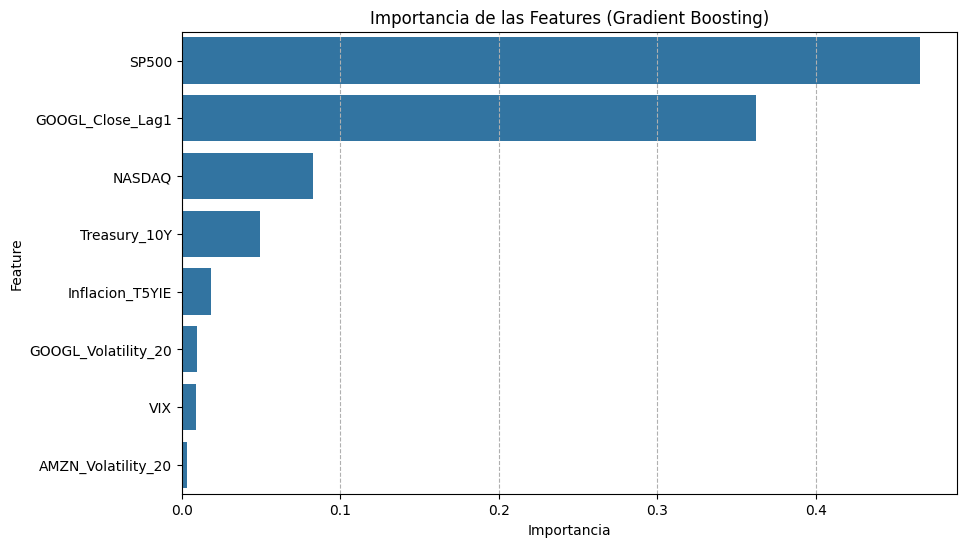


--- Interpretación Financiera (Importancia de Features) ---
- 'SP500' (0.4659): Indicates how relevant this variable was for the model when making predictions.
  Broad market indices are important as they reflect overall market sentiment and correlate with individual stock prices.
- 'GOOGL_Close_Lag1' (0.3625): Indicates how relevant this variable was for the model when making predictions.
  Era de esperar that the lagged price would be the most important feature, as financial asset prices have strong autocorrelation.
- 'NASDAQ' (0.0824): Indicates how relevant this variable was for the model when making predictions.
  Broad market indices are important as they reflect overall market sentiment and correlate with individual stock prices.
- 'Treasury_10Y' (0.0495): Indicates how relevant this variable was for the model when making predictions.
  Interest rates and inflation expectations are macroeconomic indicators that can influence company valuations and capital flows.
- 'Inflacion_T5

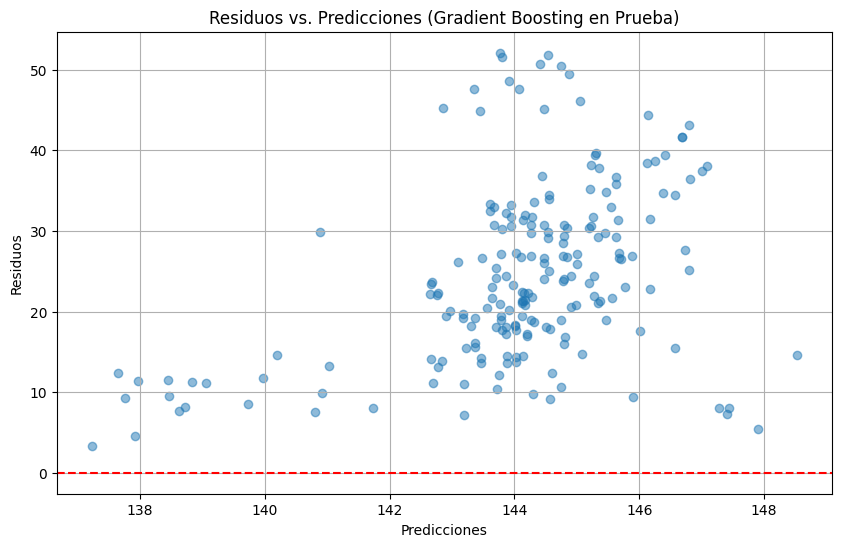

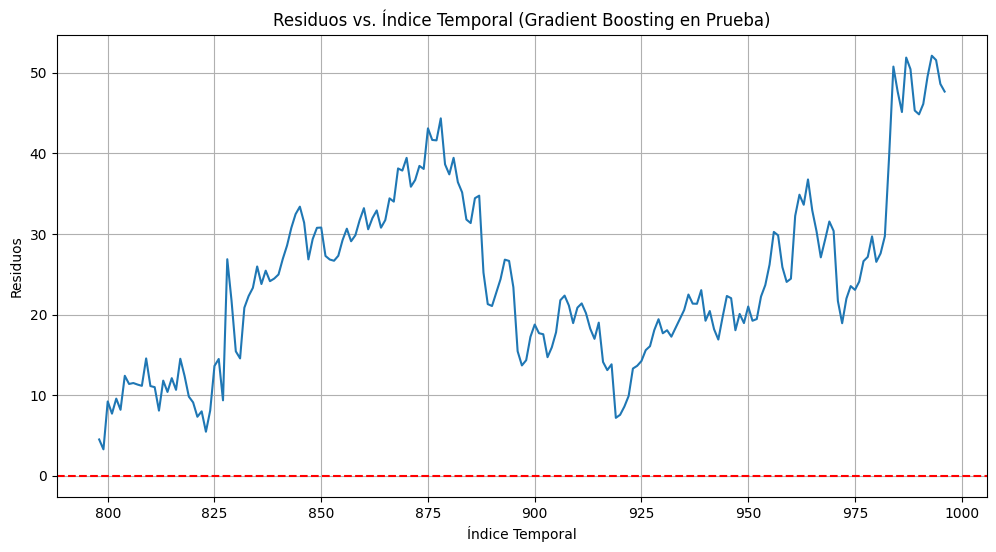

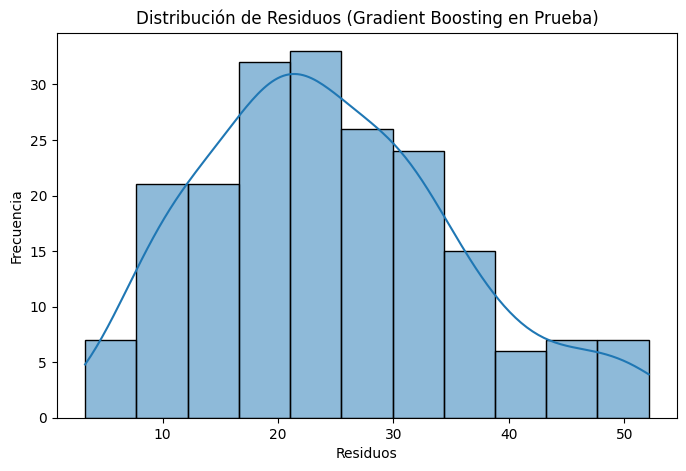


--- Pronóstico con Valores Específicos de Variables Independientes (Gradient Boosting) ---

Valores de entrada para el pronóstico específico:


,GOOGL_Close_Lag1,Treasury_10Y,VIX,SP500,NASDAQ,Inflacion_T5YIE,GOOGL_Volatility_20,AMZN_Volatility_20
0,191.0200,4.5000,18.0000,5200.0000,16500.0000,2.5000,0.0150,0.0200



Pronóstico del Precio de Cierre de GOOGL: 141.7544


--- Pronóstico Gradient Boosting para GOOGL_Close (Enero-Marzo 2025) ---
Re-entrenando modelo Gradient Boosting con todos los datos disponibles...
Re-entrenamiento completado.
Generando pronósticos para el rango de fechas: 2025-01-01 a 2025-03-31
Último precio real conocido (2024-12-30): 191.0200

--- Tabla de Pronósticos de Precio (Gradient Boosting) ---


,Forecast_GOOGL_Close_GB
Date,
2025-01-01,191.06
2025-01-02,191.06
2025-01-03,191.06
2025-01-06,191.06
2025-01-07,191.06
...,...
2025-03-25,191.06
2025-03-26,191.06
2025-03-27,191.06



--- Gráfico de Pronóstico de Precio (Gradient Boosting) ---


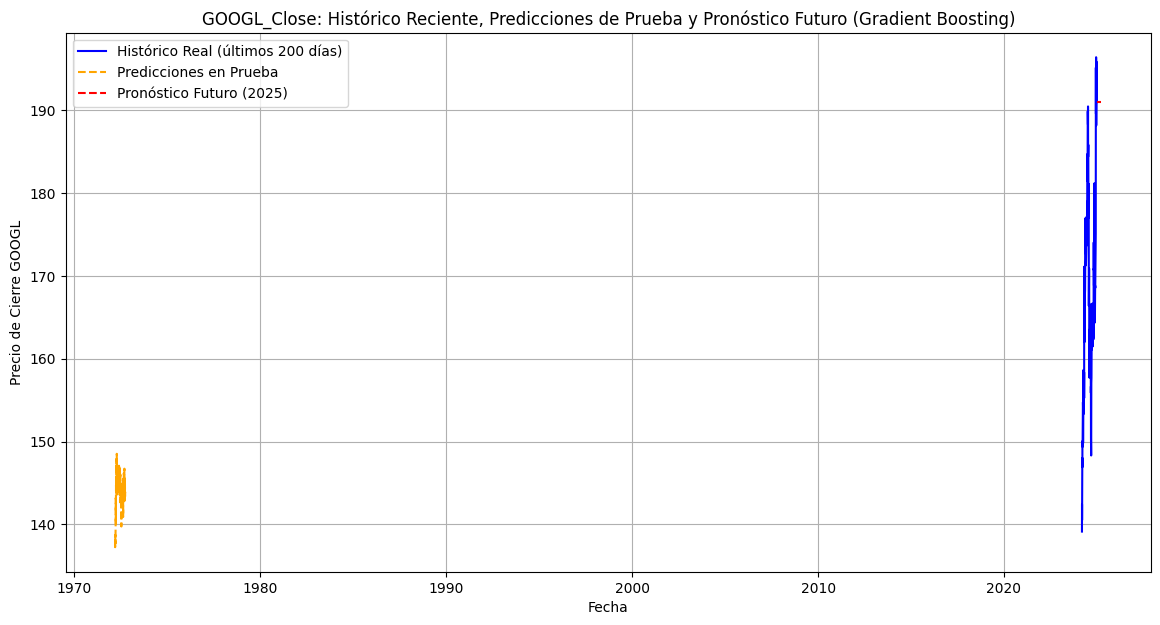


Nota sobre el Pronóstico de Precio:
Este pronóstico utiliza el modelo Gradient Boosting entrenado con todos los datos históricos disponibles.
Para las variables macro/técnicas (Treasury_10Y, VIX, etc.) en el futuro, se asume que se mantienen en sus últimos valores históricos conocidos.
Para el precio rezagado (GOOGL_Close_Lag1), se utiliza el precio pronosticado del día anterior. Esto crea una dependencia autorregresiva para proyectar la tendencia del precio.
La precisión de este pronóstico depende fuertemente de la validez de las asunciones sobre las variables de entrada futuras, especialmente las macro/técnicas.


In [15]:
# %% [markdown]
# ## Gradient Boosting para GOOGL_Close
# %%
# --- Gradient Boosting para GOOGL_Close ---
print("\n\n--- Modelo Gradient Boosting para GOOGL_Close ---")

# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor # Importar Gradient Boosting
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from IPython.display import display
import datetime # Para definir fechas de ventanas

# Cargar datos (asegúrate de que el archivo existe)
# Assuming df is already loaded and preprocessed from previous cells,
# but including load and basic processing for standalone execution possibility.
try:
    df = pd.read_csv("dataset_completo_google_amazon.csv")
except FileNotFoundError:
    print("Error: 'dataset_completo_google_amazon.csv' no encontrado. Asegúrate de que el archivo está en la ruta correcta.")
    exit()

# Preprocesamiento básico
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Crear columna de precio rezagado si no existe
if 'GOOGL_Close_Lag1' not in df.columns and 'GOOGL_Close' in df.columns:
    df['GOOGL_Close_Lag1'] = df['GOOGL_Close'].shift(1)
# Ensure AMZN_Close_Lag1 is also created if needed later for other models,
# though it's not used in this specific GOOGL_Close model.
if 'AMZN_Close_Lag1' not in df.columns and 'AMZN_Close' in df.columns:
     df['AMZN_Close_Lag1'] = df['AMZN_Close'].shift(1)


# Definir las variables dependientes e independientes para el modelo de precio GOOGL
dependent_var_price_googl = 'GOOGL_Close'
independent_vars_price_googl = [
    'GOOGL_Close_Lag1', # Precio de cierre del día anterior - CRUCIAL para modelar precios
    'Treasury_10Y',
    'VIX',
    'SP500',
    'NASDAQ',
    'Inflacion_T5YIE',
    'GOOGL_Volatility_20',
    'AMZN_Volatility_20' # Including AMZN volatility as it's in common_independent_vars used for X_full later
]

# Asegurarse de that all required columns exist in the DataFrame
required_cols_price_googl = [dependent_var_price_googl] + independent_vars_price_googl
missing_cols_price_googl = [col for col in required_cols_price_googl if col not in df.columns]
if missing_cols_price_googl:
    print(f"Error: Faltan las siguientes columnas requeridas para el modelo Gradient Boosting: {missing_cols_price_googl}")
    # Attempt to create lags if they are the missing ones
    if 'GOOGL_Close' in df.columns and 'GOOGL_Close_Lag1' not in df.columns and 'GOOGL_Close_Lag1' in missing_cols_price_googl:
         df['GOOGL_Close_Lag1'] = df['GOOGL_Close'].shift(1)
         missing_cols_price_googl.remove('GOOGL_Close_Lag1')
    if 'AMZN_Close' in df.columns and 'AMZN_Close_Lag1' not in df.columns and 'AMZN_Close_Lag1' in missing_cols_price_googl: # Not strictly needed for this model, but good practice
         df['AMZN_Close_Lag1'] = df['AMZN_Close'].shift(1)
         if 'AMZN_Close_Lag1' in missing_cols_price_googl: missing_cols_price_googl.remove('AMZN_Close_Lag1')

    # Re-check after attempting to create lags
    missing_cols_price_googl = [col for col in required_cols_price_googl if col not in df.columns]
    if missing_cols_price_googl:
        print(f"Error persistente: Faltan columnas después de intentar crear lags: {missing_cols_price_googl}")
        exit()


# Eliminar filas con valores nulos en las columnas relevantes para el modelo de precio
df_model_price_gb = df.dropna(subset=required_cols_price_googl).copy()

X_price_gb = df_model_price_gb[independent_vars_price_googl]
y_price_gb = df_model_price_gb[dependent_var_price_googl]

print(f"Dataset para Gradient Boosting: {len(df_model_price_gb)} filas después de eliminar nulos relevantes.")

# 1. División de Datos (manteniendo el orden temporal)
# Usaremos los últimos 3 meses para la prueba, por ejemplo. Adjust if necessary.
# Calculate test set size based on number of rows, not just days, for exact split
test_set_rows = int(len(df_model_price_gb) * 0.2) # Example: 20% for testing
if test_set_rows < 40: # Ensure minimum size for meaningful test
     test_set_rows = min(40, len(df_model_price_gb) - 1) # At least 40 or max possible
if len(df_model_price_gb) <= 1:
     print("\nError: No hay suficientes datos para crear conjuntos de entrenamiento y prueba.")
     exit()
if test_set_rows == 0: test_set_rows = 1 # Ensure at least one test sample if possible


X_train_gb, X_test_gb, y_train_gb, y_test_gb = train_test_split(
    X_price_gb, y_price_gb, test_size=test_set_rows, shuffle=False
)

print(f"\nDatos de entrenamiento para Gradient Boosting: {len(X_train_gb)} filas")
print(f"Datos de prueba para Gradient Boosting:      {len(X_test_gb)} filas")

if len(X_test_gb) == 0:
    print("\nAdvertencia: El conjunto de prueba para Gradient Boosting está vacío. Ajusta 'test_set_rows'.")
    # Proceeding might cause errors later if test set is needed. Consider adding a break or exit here.
    # For now, we'll continue but print a warning.


# 2. Entrenamiento del Modelo Gradient Boosting
# You can adjust the hyperparameters (n_estimators, learning_rate, max_depth, etc.)
# These are example values.
print("\nEntrenando modelo Gradient Boosting...")
gbm_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42, subsample=0.8, max_features='sqrt')
gbm_model.fit(X_train_gb, y_train_gb)
print("Entrenamiento completado.")

# 3. Predicciones en el conjunto de prueba
y_pred_test_gb = gbm_model.predict(X_test_gb)

# 4. Evaluación del modelo en el conjunto de prueba
print("\n--- Evaluación del Modelo Gradient Boosting (Conjunto de Prueba) ---")
mae_gb_test = mean_absolute_error(y_test_gb, y_pred_test_gb)
mse_gb_test = mean_squared_error(y_test_gb, y_pred_test_gb)
rmse_gb_test = np.sqrt(mse_gb_test) # RMSE is more interpretable than MSE
r2_gb_test = r2_score(y_test_gb, y_pred_test_gb)

print(f"MAE:  {mae_gb_test:.4f}")
print(f"MSE:  {mse_gb_test:.4f}")
print(f"RMSE: {rmse_gb_test:.4f}")
print(f"R²:   {r2_gb_test:.4f}")

# Interpretación de la precisión
print("\n--- Interpretación de la Precisión ---")
print(f"- MAE ({mae_gb_test:.4f}): Representa el error absoluto promedio en la predicción. En promedio, el modelo se equivoca por aproximadamente {mae_gb_test:.4f} unidades monetarias en la predicción del precio de cierre.")
print(f"- RMSE ({rmse_gb_test:.4f}): Similar al MAE, but gives more weight to large errors. Indica la desviación estándar de los errores de predicción.")
print(f"- R² ({r2_gb_test:.4f}): Indicates the proportion of the variance in the closing price that is predictable from the independent variables. Un R² de {r2_gb_test:.4f} means that approximately {r2_gb_test*100:.2f}% of the variability in GOOGL's price is explained by the model.")
if r2_gb_test < 0:
    print("  ¡Advertencia: Un R² negativo indica que el modelo es peor que simplemente predecir la media!")
elif r2_gb_test < 0.5:
     print("  Nota: Un R² relatively low (< 0.5) is common in financial time series due to the inherent complexity and noise of the market.")
else:
     print("  El R² indicates that the model has some explanatory capacity regarding price variability.")


# 5. Importancia de las Features
print("\n--- Importancia de las Features (Gradient Boosting) ---")
feature_importance = gbm_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X_train_gb.columns,
    'Importance': feature_importance
})
feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False).reset_index(drop=True)

display(feature_importance_df)

# Visualización de la importancia de las features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title("Importancia de las Features (Gradient Boosting)")
plt.xlabel("Importancia")
plt.ylabel("Feature")
plt.grid(axis='x', linestyle='--')
plt.show()

# Interpretación financiera de la importancia de las features
print("\n--- Interpretación Financiera (Importancia de Features) ---")
for index, row in feature_importance_df.iterrows():
    print(f"- '{row['Feature']}' ({row['Importance']:.4f}): Indicates how relevant this variable was for the model when making predictions.")
    if row['Feature'] == 'GOOGL_Close_Lag1':
        print("  Era de esperar that the lagged price would be the most important feature, as financial asset prices have strong autocorrelation.")
    elif row['Feature'] in ['SP500', 'NASDAQ']:
        print("  Broad market indices are important as they reflect overall market sentiment and correlate with individual stock prices.")
    elif row['Feature'] in ['Treasury_10Y', 'Inflacion_T5YIE']:
        print("  Interest rates and inflation expectations are macroeconomic indicators that can influence company valuations and capital flows.")
    elif row['Feature'] == 'VIX':
        print("  The VIX (volatility index) reflects market expectation of future volatility, often negatively correlated with stock prices.")
    elif '_Volatility_20' in row['Feature']: # Check for any volatility feature
         print("  Historical volatility of the stock itself is relevant for predicting future movements.")
print("\nNota: A diferencia de la regresión lineal, la importancia de la feature en Gradient Boosting no indica la dirección o magnitud lineal del efecto, only its relative contribution to the model's error reduction.")


# 6. Análisis de Residuos (Visual)
print("\n--- Análisis Visual de Residuos (Gradient Boosting en Prueba) ---")

residuals_test_gb = y_test_gb - y_pred_test_gb

# Residuals vs. Predictions Plot
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_test_gb, residuals_test_gb, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuos vs. Predicciones (Gradient Boosting en Prueba)")
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.grid(True)
plt.show()
# Se espera una dispersión aleatoria de puntos alrededor de cero. Patterns (curves, funnels) can indicate problems.

# Residuals vs. Time Plot (Index)
plt.figure(figsize=(12, 6))
plt.plot(X_test_gb.index, residuals_test_gb)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuos vs. Índice Temporal (Gradient Boosting en Prueba)")
plt.xlabel("Índice Temporal") # You could use the date if you kept it in X_test_gb.index
plt.ylabel("Residuos")
plt.grid(True)
plt.show()
# In time series, residuals often show some autocorrelation.

# Residuals Histogram
plt.figure(figsize=(8, 5))
sns.histplot(residuals_test_gb, kde=True)
plt.title("Distribución de Residuos (Gradient Boosting en Prueba)")
plt.xlabel("Residuos")
plt.ylabel("Frecuencia")
plt.show()
# Se espera que los residuos se distribuyan approximately around zero. Normality is not a strict requirement for GB, but it can be an indicator of a good overall fit.


# 7. Pronóstico con Valores Específicos
print("\n--- Pronóstico con Valores Específicos de Variables Independientes (Gradient Boosting) ---")

# Define a dictionary with specific values for each independent variable.
# Make sure all variables used in training (X_train_gb.columns) are here.
# These are just example values. Replace them with the values you want to forecast.
# It is CRUCIAL to provide a value for 'GOOGL_Close_Lag1'
future_values_specific_gb = {
    'GOOGL_Close_Lag1': df_model_price_gb['GOOGL_Close'].iloc[-1], # Use the last known real price as an example
    'Treasury_10Y': 4.5,  # Example: 10-Year Treasury Rate
    'VIX': 18.0,           # Example: VIX Index
    'SP500': 5200.0,       # Example: S&P 500 Level
    'NASDAQ': 16500.0,     # Example: NASDAQ Level
    'Inflacion_T5YIE': 2.5,# Example: 5-Year Inflation Expectation
    'GOOGL_Volatility_20': 0.015, # Example: GOOGL Volatility (as decimal)
    'AMZN_Volatility_20': 0.02 # Example: AMZN Volatility (as decimal) - Include if used in training
}

# Convert the dictionary to a DataFrame.
# It is crucial that the columns are in the same order as the original X DataFrame used for training.
# Use X_train_gb.columns or X_price_gb.columns or X_full.columns for the correct order and set of columns.
X_future_single_gb = pd.DataFrame([future_values_specific_gb], columns=X_train_gb.columns)

# Perform the prediction
predicted_price_gb = gbm_model.predict(X_future_single_gb)

print("\nValores de entrada para el pronóstico específico:")
display(X_future_single_gb)

print(f"\nPronóstico del Precio de Cierre de GOOGL: {predicted_price_gb[0]:.4f}")


# 8. Pronóstico para los primeros 3 meses de 2025 (Enero-Marzo)

print("\n\n--- Pronóstico Gradient Boosting para GOOGL_Close (Enero-Marzo 2025) ---")

# Ajustar el modelo en TODOS los datos disponibles para el pronóstico futuro
# This is crucial to use the most recent information
print("Re-entrenando modelo Gradient Boosting con todos los datos disponibles...")
gbm_model_full_data = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42, subsample=0.8, max_features='sqrt')
# Use the full cleaned dataset (X_price_gb, y_price_gb) for training the final model
gbm_model_full_data.fit(X_price_gb, y_price_gb)
print("Re-entrenamiento completado.")

# Determine the date range for the forecast
start_date_2025 = pd.to_datetime('2025-01-01')
end_date_2025 = pd.to_datetime('2025-03-31') # Forecast until end of March
future_dates_gb = pd.date_range(start=start_date_2025, end=end_date_2025, freq='B') # 'B' for business days

print(f"Generando pronósticos para el rango de fechas: {future_dates_gb.min().date()} a {future_dates_gb.max().date()}")

# --- Corrected Future Data Preparation ---

# Use the last known values from the historical dataset for ALL independent variables
# (except the lag which will be handled recursively).
# This should be based on the columns that the model was trained on (X_price_gb.columns).
last_known_features_raw = df_model_price_gb[X_price_gb.columns].iloc[-1].to_dict()

# Create a DataFrame for future features (X_future_gb) with the correct columns (those used for training)
X_future_gb = pd.DataFrame(index=future_dates_gb, columns=X_price_gb.columns)
X_future_gb.index.name = 'Date'

# Populate the non-lag columns in X_future_gb with these last known values
cols_to_populate_last_value_gb = [col for col in X_price_gb.columns if '_Lag1' not in col]
for col in cols_to_populate_last_value_gb:
     X_future_gb[col] = last_known_features_raw[col]

# Implement the recursive step-by-step forecast for the price, using the lag
last_known_close = df_model_price_gb['GOOGL_Close'].iloc[-1] # Last known real price
print(f"Último precio real conocido ({df_model_price_gb['Date'].iloc[-1].date()}): {last_known_close:.4f}")


forecast_values_gb = []

# Ensure X_future_gb has columns in the correct order before prediction
# This is already handled by creating X_future_gb with X_price_gb.columns

# Get the exact lag column name used in the training data
lag_col_name = [col for col in X_price_gb.columns if '_Close_Lag1' in col]
if len(lag_col_name) == 1:
    lag_col_name = lag_col_name[0]
else:
    print("Error: No se encontró una columna de lag '_Close_Lag1' en los datos de entrenamiento. El pronóstico recursivo no es posible.")
    # Decide how to handle this error - maybe skip forecasting?
    lag_col_name = None # Prevent errors later


if lag_col_name: # Only proceed with recursive forecast if lag column is found
    for i in range(len(future_dates_gb)):
        current_date = future_dates_gb[i]

        # Determine the lag value for this day
        if i == 0:
            # For the first forecast day, the lag is the last real known price
            current_lag = last_known_close
        else:
            # For subsequent days, the lag is the prediction from the previous day
            current_lag = forecast_values_gb[-1] # The prediction from the previous day

        # Create the future features row for the current day, starting with the non-lag values from X_future_gb
        current_future_row = X_future_gb.loc[current_date].to_dict() # Start with values already populated (non-lag)

        # Update the lag feature with the determined value
        current_future_row[lag_col_name] = current_lag

        # Convert to DataFrame for prediction, ensuring correct column order and dtype
        # Now, current_future_row contains exactly the keys from X_price_gb.columns
        current_future_values = [current_future_row[col] for col in X_price_gb.columns] # Use X_price_gb.columns for order
        current_future_df_gb = pd.DataFrame([current_future_values], columns=X_price_gb.columns).astype(X_price_gb.dtypes)


        # Perform the prediction for the current day
        current_forecast_gb = gbm_model_full_data.predict(current_future_df_gb)
        forecast_values_gb.append(current_forecast_gb[0])
else:
    print("Saltando generación de pronóstico debido a la falta de la columna lag.")
    # If you skip forecasting, make sure forecast_df_gb_2025 is handled appropriately (e.g., initialized empty)


# Create a DataFrame to show the forecast
# Only create the DataFrame if forecast_values_gb is not empty
if forecast_values_gb:
    forecast_df_gb_2025 = pd.DataFrame({
        'Date': future_dates_gb[:len(forecast_values_gb)], # Use only the dates for which there are forecasts
        'Forecast_GOOGL_Close_GB': forecast_values_gb
    })
    forecast_df_gb_2025.set_index('Date', inplace=True)

    print("\n--- Tabla de Pronósticos de Precio (Gradient Boosting) ---")
    pd.options.display.float_format = '{:.2f}'.format # Format for price visualization
    display(forecast_df_gb_2025)
else:
    print("\nNo se pudo generar la tabla de pronósticos.")
    # Initialize an empty DataFrame to avoid errors later if you try to plot
    forecast_df_gb_2025 = pd.DataFrame(columns=['Date', 'Forecast_GOOGL_Close_GB']).set_index('Date')


# 9. Gráfico de Pronóstico de Precio (Histórico + Futuro)
print("\n--- Gráfico de Pronóstico de Precio (Gradient Boosting) ---")

plt.figure(figsize=(14, 7))
# Graficar datos históricos reales (solo los últimos días para contexto)
plt.plot(df_model_price_gb['Date'].iloc[-200:], df_model_price_gb['GOOGL_Close'].iloc[-200:], label='Histórico Real (últimos 200 días)', color='blue')
# Graficar predicciones en el conjunto de prueba (para ver cómo le fue al modelo en la prueba reciente)
plt.plot(X_test_gb.index, y_pred_test_gb, label='Predicciones en Prueba', color='orange', linestyle='--')

# Only plot forecast if the DataFrame is not empty
if not forecast_df_gb_2025.empty:
    plt.plot(forecast_df_gb_2025.index, forecast_df_gb_2025['Forecast_GOOGL_Close_GB'], label='Pronóstico Futuro (2025)', color='red', linestyle='--')
else:
     print("No se pudo graficar el pronóstico futuro porque el DataFrame de pronósticos está vacío.")


plt.title("GOOGL_Close: Histórico Reciente, Predicciones de Prueba y Pronóstico Futuro (Gradient Boosting)")
plt.xlabel("Fecha")
plt.ylabel("Precio de Cierre GOOGL")
plt.legend()
plt.grid(True)
plt.show()


print("\nNota sobre el Pronóstico de Precio:")
print("Este pronóstico utiliza el modelo Gradient Boosting entrenado con todos los datos históricos disponibles.")
print("Para las variables macro/técnicas (Treasury_10Y, VIX, etc.) en el futuro, se asume que se mantienen en sus últimos valores históricos conocidos.")
print("Para el precio rezagado (GOOGL_Close_Lag1), se utiliza el precio pronosticado del día anterior. Esto crea una dependencia autorregresiva para proyectar la tendencia del precio.")
print("La precisión de este pronóstico depende fuertemente de la validez de las asunciones sobre las variables de entrada futuras, especialmente las macro/técnicas.")

# Reset pandas format option if necessary
# pd.reset_option('display.float_format')



--- Modelo Gradient Boosting para GOOGL_Return_1d ---
Dataset para Gradient Boosting (Retorno): 997 filas después de eliminar nulos relevantes.

Datos de entrenamiento para Gradient Boosting (Retorno): 798 filas
Datos de prueba para Gradient Boosting (Retorno):      199 filas

Entrenando modelo Gradient Boosting para Retorno...
Entrenamiento completado.

--- Evaluación del Modelo Gradient Boosting (Conjunto de Prueba - Retorno) ---
MAE:  0.013686
MSE:  0.000352755833
RMSE: 0.018782
R²:   -0.1193

--- Interpretación de la Precisión (Retorno) ---
- MAE (0.013686): Representa el error absoluto promedio en la predicción del retorno. Un MAE bajo es deseable, pero predecir retornos puntuales con precisión es extremadamente difícil.
- RMSE (0.018782): Indica la desviación estándar de los errores de predicción. Similar al MAE en interpretación para retornos.
- R² (-0.1193): Indica la proporción de la varianza en el retorno diario que es predecible. Un R² muy cercano a cero (o negativo) es tí

,Feature,Importance
0,VIX,0.21
1,Treasury_10Y,0.17
2,AMZN_Volatility_20,0.15
3,NASDAQ,0.14
4,GOOGL_Volatility_20,0.12
5,SP500,0.12
6,Inflacion_T5YIE,0.10


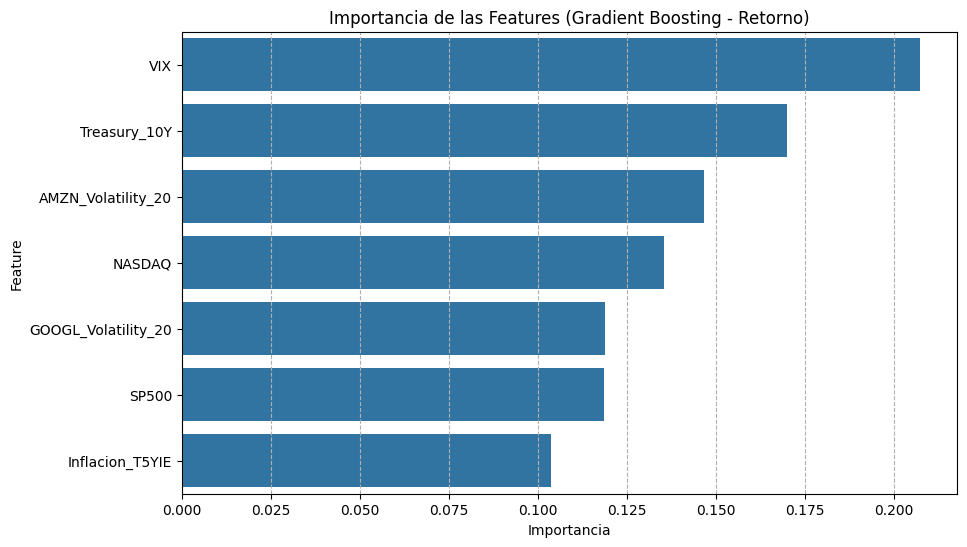


--- Interpretación Financiera (Importancia de Features - Retorno) ---
- 'VIX' (0.2073): Indica qué tan relevante fue esta variable para el modelo al predecir el retorno.
  Las variables de volatilidad suelen ser importantes para los modelos de retorno, ya que los periodos de alta volatilidad suelen coincidir con grandes movimientos de precios (positivos o negativos).
- 'Treasury_10Y' (0.1700): Indica qué tan relevante fue esta variable para el modelo al predecir el retorno.
  Variables macroeconómicas pueden influir en el apetito por el riesgo y, por lo tanto, en los retornos de las acciones.
- 'AMZN_Volatility_20' (0.1465): Indica qué tan relevante fue esta variable para el modelo al predecir el retorno.
  Las variables de volatilidad suelen ser importantes para los modelos de retorno, ya que los periodos de alta volatilidad suelen coincidir con grandes movimientos de precios (positivos o negativos).
- 'NASDAQ' (0.1352): Indica qué tan relevante fue esta variable para el modelo al pr

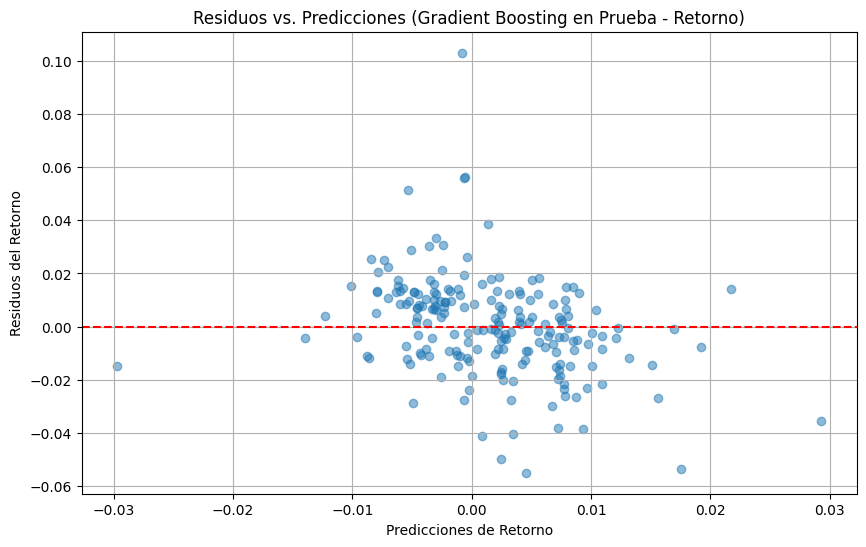

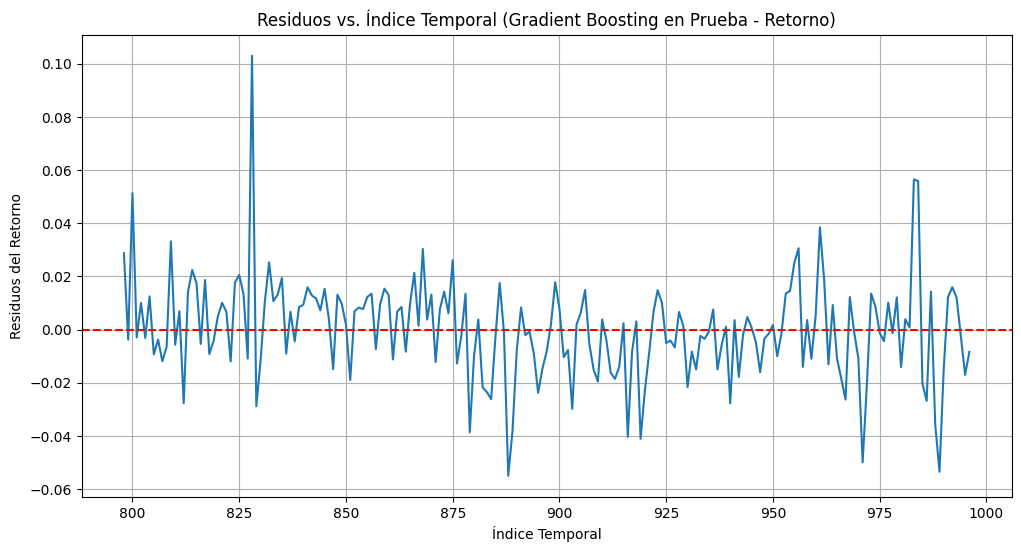

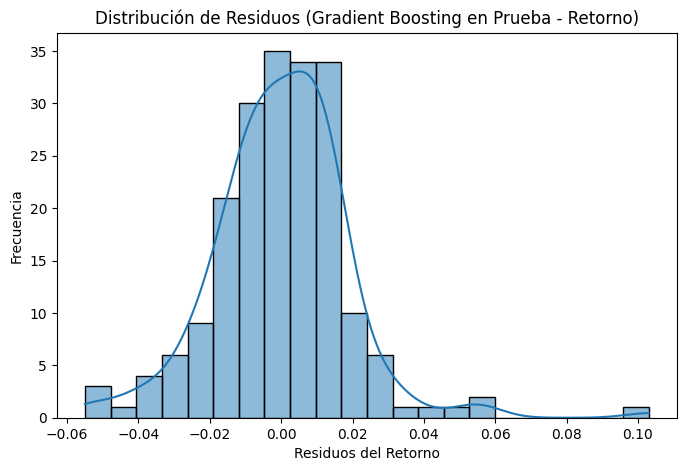


--- Pronóstico con Valores Específicos de Variables Independientes (Gradient Boosting - Retorno) ---

Valores de entrada para el pronóstico específico (Retorno):


,Treasury_10Y,VIX,SP500,NASDAQ,Inflacion_T5YIE,GOOGL_Volatility_20,AMZN_Volatility_20
0,4.50,18.00,5200.00,16500.00,2.50,0.01,0.02



Pronóstico del Retorno Diario de GOOGL: -0.000132


--- Pronóstico Gradient Boosting para GOOGL_Return_1d (Enero-Marzo 2025) ---
Re-entrenando modelo Gradient Boosting para Retorno con todos los datos disponibles...
Re-entrenamiento completado.
Generando pronósticos para el rango de fechas: 2025-01-01 a 2025-03-31
Últimos valores históricos conocidos para el pronóstico de Retorno (fecha 2024-12-30): {'Treasury_10Y': 4.545000076293945, 'VIX': 17.399999618530273, 'SP500': 5906.93994140625, 'NASDAQ': 19486.7890625, 'Inflacion_T5YIE': 2.35, 'GOOGL_Volatility_20': 9.512947084422786, 'AMZN_Volatility_20': 5.666061025265696}

--- Tabla de Pronósticos de Retorno (Gradient Boosting) ---


,Forecast_GOOGL_Return_1d_GB
Date,
2025-01-01,-0.002023
2025-01-02,-0.002023
2025-01-03,-0.002023
2025-01-06,-0.002023
2025-01-07,-0.002023
...,...
2025-03-25,-0.002023
2025-03-26,-0.002023
2025-03-27,-0.002023



--- Gráfico de Pronóstico de Retorno (Gradient Boosting) ---


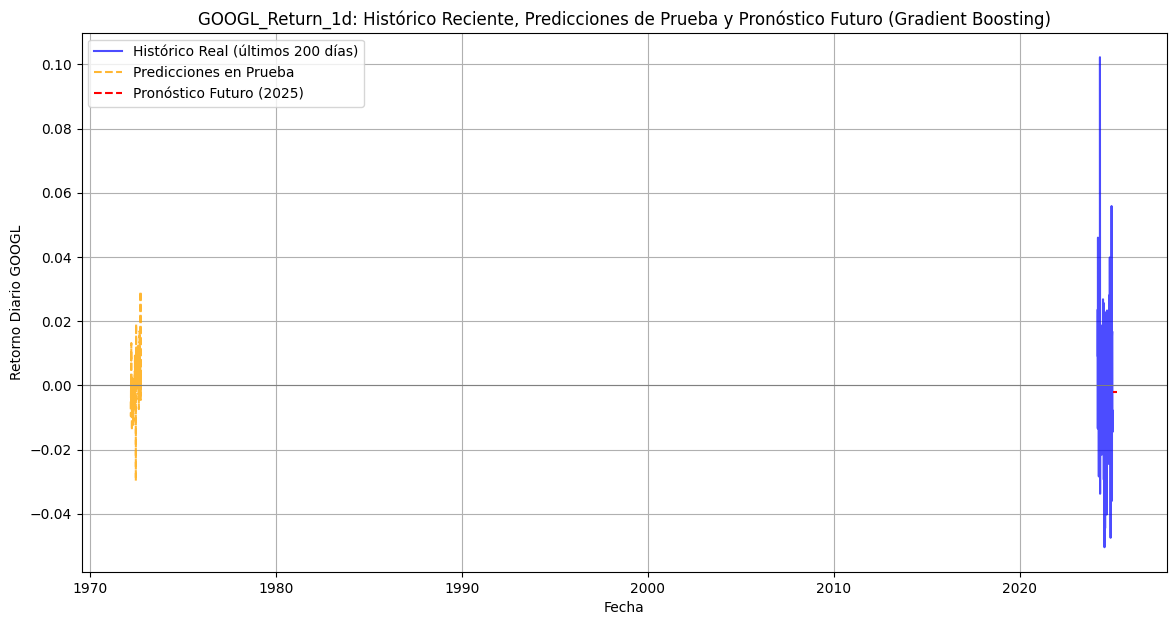


Nota Importante sobre el Gráfico de Pronóstico de Retornos:
Como se mencionó, los retornos diarios puros son muy difíciles de predecir y a menudo se comportan de forma cercana a un paseo aleatorio (ruido blanco).
Es probable que el gráfico del pronóstico futuro de retornos muestre valores muy cercanos a cero.
Esto NO significa que el modelo no funcione, sino que refleja la realidad de que las variables de entrada disponibles tienen una capacidad muy limitada para predecir la magnitud exacta del retorno diario.
En la práctica financiera, los modelos ML/estadísticos para retornos a menudo se usan para:
1. Predecir la *dirección* del movimiento (subida/bajada) más que el valor exacto del retorno (problema de clasificación).
2. Predecir la *volatilidad* o el riesgo.
3. Incorporar señales de modelos más complejos o fuentes de datos no incluidas aquí.

Nota final sobre el Modelo Gradient Boosting para Retornos:
Gradient Boosting es un modelo potente no lineal que puede capturar interaccione

In [16]:
# %% [markdown]
# ## Gradient Boosting para GOOGL_Return_1d
# %%
# --- Gradient Boosting para GOOGL_Return_1d ---
print("\n\n--- Modelo Gradient Boosting para GOOGL_Return_1d ---")

# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor # Importar Gradient Boosting
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from IPython.display import display
import datetime # Para definir fechas de ventanas

# Cargar datos (asegúrate de que el archivo existe y está preprocesado de celdas anteriores)
# Incluimos la carga y preprocesamiento básico por si esta celda se ejecuta sola.
try:
    df = pd.read_csv("dataset_completo_google_amazon.csv")
except FileNotFoundError:
    print("Error: 'dataset_completo_google_amazon.csv' no encontrado. Asegúrate de que el archivo está en la ruta correcta.")
    exit()

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Definir las variables dependientes e independientes para el modelo de retorno GOOGL
dependent_var_return_googl = 'GOOGL_Return_1d'

# Variables independientes para retornos (macro + técnicas, sin el retorno rezagado típicamente)
independent_vars_return_googl = [
    'Treasury_10Y',
    'VIX',
    'SP500',
    'NASDAQ',
    'Inflacion_T5YIE',
    'GOOGL_Volatility_20',
    'AMZN_Volatility_20' # Incluimos volatilidad de AMZN si está disponible y se considera relevante
]

# Asegurarse de que todas las columnas requeridas existen en el DataFrame
required_cols_return_googl = [dependent_var_return_googl] + independent_vars_return_googl
missing_cols_return_googl = [col for col in required_cols_return_googl if col not in df.columns]
if missing_cols_return_googl:
    print(f"Error: Faltan las siguientes columnas requeridas para el modelo Gradient Boosting de Retorno: {missing_cols_return_googl}")
    exit()


# Eliminar filas con valores nulos en las columnas relevantes para el modelo de retorno
df_model_return_gb = df.dropna(subset=required_cols_return_googl).copy()

X_return_gb = df_model_return_gb[independent_vars_return_googl]
y_return_gb = df_model_return_gb[dependent_var_return_googl]

print(f"Dataset para Gradient Boosting (Retorno): {len(df_model_return_gb)} filas después de eliminar nulos relevantes.")

# 1. División de Datos (manteniendo el orden temporal)
# Usaremos el mismo enfoque de porcentaje o número de filas para la prueba que en el modelo de precio.
test_set_rows_return = int(len(df_model_return_gb) * 0.2) # Example: 20% for testing
if test_set_rows_return < 40: # Ensure minimum size for meaningful test
     test_set_rows_return = min(40, len(df_model_return_gb) - 1) # At least 40 or max possible
if len(df_model_return_gb) <= 1:
     print("\nError: No hay suficientes datos para crear conjuntos de entrenamiento y prueba para el modelo de retorno.")
     exit()
if test_set_rows_return == 0: test_set_rows_return = 1 # Ensure at least one test sample if possible


X_train_return_gb, X_test_return_gb, y_train_return_gb, y_test_return_gb = train_test_split(
    X_return_gb, y_return_gb, test_size=test_set_rows_return, shuffle=False
)

print(f"\nDatos de entrenamiento para Gradient Boosting (Retorno): {len(X_train_return_gb)} filas")
print(f"Datos de prueba para Gradient Boosting (Retorno):      {len(X_test_return_gb)} filas")

if len(X_test_return_gb) == 0:
    print("\nAdvertencia: El conjunto de prueba para Gradient Boosting (Retorno) está vacío. Ajusta el tamaño del conjunto de prueba.")
    # Consider adding a break or exit here if the test set is essential for subsequent steps.


# 2. Entrenamiento del Modelo Gradient Boosting
# Puedes ajustar los hiperparámetros. Los retornos son más difíciles de predecir,
# podrías necesitar ajustar más finamente estos parámetros o probar otros modelos.
print("\nEntrenando modelo Gradient Boosting para Retorno...")
gbm_model_return = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42, subsample=0.8, max_features='sqrt')
gbm_model_return.fit(X_train_return_gb, y_train_return_gb)
print("Entrenamiento completado.")

# 3. Predicciones en el conjunto de prueba
y_pred_test_return_gb = gbm_model_return.predict(X_test_return_gb)

# 4. Evaluación del modelo en el conjunto de prueba
print("\n--- Evaluación del Modelo Gradient Boosting (Conjunto de Prueba - Retorno) ---")
mae_return_gb_test = mean_absolute_error(y_test_return_gb, y_pred_test_return_gb)
mse_return_gb_test = mean_squared_error(y_test_return_gb, y_pred_test_return_gb)
rmse_return_gb_test = np.sqrt(mse_return_gb_test) # RMSE es más interpretable que MSE
r2_return_gb_test = r2_score(y_test_return_gb, y_pred_test_return_gb)

print(f"MAE:  {mae_return_gb_test:.6f}") # Usamos más decimales para retornos
print(f"MSE:  {mse_return_gb_test:.12f}") # MSE de retornos suele ser muy pequeño
print(f"RMSE: {rmse_return_gb_test:.6f}")
print(f"R²:   {r2_return_gb_test:.4f}")

# Interpretación de la precisión (Retorno)
print("\n--- Interpretación de la Precisión (Retorno) ---")
print(f"- MAE ({mae_return_gb_test:.6f}): Representa el error absoluto promedio en la predicción del retorno. Un MAE bajo es deseable, pero predecir retornos puntuales con precisión es extremadamente difícil.")
print(f"- RMSE ({rmse_return_gb_test:.6f}): Indica la desviación estándar de los errores de predicción. Similar al MAE en interpretación para retornos.")
print(f"- R² ({r2_return_gb_test:.4f}): Indica la proporción de la varianza en el retorno diario que es predecible. Un R² muy cercano a cero (o negativo) es típico en modelos que intentan predecir retornos puros, ya que son muy ruidosos y cercanos a un paseo aleatorio.")
if r2_return_gb_test < 0.01: # A very low R2
    print("  Nota: Un R² muy bajo (< 0.01) es **esperable** al predecir retornos puros, lo cual subraya la dificultad de esta tarea. Esto no significa necesariamente que el modelo sea 'malo', sino que los retornos son en gran medida impredecibles con estas variables.")
    print("  Los modelos de retornos a menudo se centran más en predecir la *dirección* del movimiento o la *volatilidad* más que el retorno puntual exacto.")
else:
    print("  El R² indica que el modelo logra capturar una pequeña parte de la variabilidad del retorno.")


# 5. Importancia de las Features (Retorno)
print("\n--- Importancia de las Features (Gradient Boosting - Retorno) ---")
feature_importance_return = gbm_model_return.feature_importances_
feature_importance_return_df = pd.DataFrame({
    'Feature': X_train_return_gb.columns,
    'Importance': feature_importance_return
})
feature_importance_return_df = feature_importance_return_df.sort_values('Importance', ascending=False).reset_index(drop=True)

display(feature_importance_return_df)

# Visualización de la importancia de las features (Retorno)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_return_df)
plt.title("Importancia de las Features (Gradient Boosting - Retorno)")
plt.xlabel("Importancia")
plt.ylabel("Feature")
plt.grid(axis='x', linestyle='--')
plt.show()

# Interpretación financiera de la importancia de las features (Retorno)
print("\n--- Interpretación Financiera (Importancia de Features - Retorno) ---")
for index, row in feature_importance_return_df.iterrows():
    print(f"- '{row['Feature']}' ({row['Importance']:.4f}): Indica qué tan relevante fue esta variable para el modelo al predecir el retorno.")
    if row['Feature'] in ['VIX', 'GOOGL_Volatility_20', 'AMZN_Volatility_20']:
        print("  Las variables de volatilidad suelen ser importantes para los modelos de retorno, ya que los periodos de alta volatilidad suelen coincidir con grandes movimientos de precios (positivos o negativos).")
    elif row['Feature'] in ['SP500', 'NASDAQ']:
        print("  Los movimientos en los índices de mercado amplios a menudo correlacionan con los retornos de acciones individuales.")
    elif row['Feature'] in ['Treasury_10Y', 'Inflacion_T5YIE']:
        print("  Variables macroeconómicas pueden influir en el apetito por el riesgo y, por lo tanto, en los retornos de las acciones.")
print("\nNota: En modelos de retorno, la importancia de la feature puede reflejar qué variables están más asociadas con los *movimientos* del precio, no necesariamente con la dirección específica del movimiento (subida vs bajada).")


# 6. Análisis de Residuos (Visual - Retorno)
print("\n--- Análisis Visual de Residuos (Gradient Boosting en Prueba - Retorno) ---")

residuals_test_return_gb = y_test_return_gb - y_pred_test_return_gb

# Gráfico de Residuos vs. Predicciones (Retorno)
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_test_return_gb, residuals_test_return_gb, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuos vs. Predicciones (Gradient Boosting en Prueba - Retorno)")
plt.xlabel("Predicciones de Retorno")
plt.ylabel("Residuos del Retorno")
plt.grid(True)
plt.show()
# Para retornos, es muy probable ver una nube de puntos centrada en cero sin patrones claros, reflejando la baja predictibilidad.

# Gráfico de Residuos vs. Tiempo (Índice - Retorno)
plt.figure(figsize=(12, 6))
plt.plot(X_test_return_gb.index, residuals_test_return_gb)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuos vs. Índice Temporal (Gradient Boosting en Prueba - Retorno)")
plt.xlabel("Índice Temporal") # Podrías usar la fecha si la mantuviste en X_test_return_gb.index
plt.ylabel("Residuos del Retorno")
plt.grid(True)
plt.show()
# Es común que los residuos de retorno muestren "clusters" de alta volatilidad (periodos donde los errores son grandes) y baja volatilidad.

# Histograma de Residuos (Retorno)
plt.figure(figsize=(8, 5))
sns.histplot(residuals_test_return_gb, kde=True)
plt.title("Distribución de Residuos (Gradient Boosting en Prueba - Retorno)")
plt.xlabel("Residuos del Retorno")
plt.ylabel("Frecuencia")
plt.show()
# Los residuos de retornos suelen tener colas más pesadas que una distribución normal.

# 7. Pronóstico con Valores Específicos (Retorno)
print("\n--- Pronóstico con Valores Específicos de Variables Independientes (Gradient Boosting - Retorno) ---")

# Define un diccionario con los valores específicos para cada variable independiente.
# Asegúrate de que todas las variables usadas en el entrenamiento (X_train_return_gb.columns) estén aquí.
# Estos son solo valores de ejemplo. Reemplázalos con los valores que desees pronosticar.
future_values_specific_return_gb = {
    'Treasury_10Y': 4.5,  # Ejemplo: Tasa del Tesoro a 10 años
    'VIX': 18.0,           # Ejemplo: Índice VIX
    'SP500': 5200.0,       # Ejemplo: Nivel del S&P 500
    'NASDAQ': 16500.0,     # Ejemplo: Nivel del NASDAQ
    'Inflacion_T5YIE': 2.5,# Ejemplo: Expectativa de Inflación a 5 años
    'GOOGL_Volatility_20': 0.015, # Ejemplo: Volatilidad de GOOGL (en decimal)
    'AMZN_Volatility_20': 0.02 # Ejemplo: Volatilidad de AMZN (en decimal)
}

# Convierte el diccionario en un DataFrame, asegurando el orden correcto.
X_future_single_return_gb = pd.DataFrame([future_values_specific_return_gb], columns=X_train_return_gb.columns)

# Realiza la predicción
predicted_return_gb = gbm_model_return.predict(X_future_single_return_gb)

print("\nValores de entrada para el pronóstico específico (Retorno):")
display(X_future_single_return_gb)

print(f"\nPronóstico del Retorno Diario de GOOGL: {predicted_return_gb[0]:.6f}") # Formato para retorno


# 8. Pronóstico para los primeros 3 meses de 2025 (Enero-Marzo - Retorno)

print("\n\n--- Pronóstico Gradient Boosting para GOOGL_Return_1d (Enero-Marzo 2025) ---")

# Ajustar el modelo en TODOS los datos disponibles para el pronóstico futuro
print("Re-entrenando modelo Gradient Boosting para Retorno con todos los datos disponibles...")
gbm_model_return_full_data = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42, subsample=0.8, max_features='sqrt')
# Usar el dataset limpio completo (X_return_gb, y_return_gb) para entrenar el modelo final
gbm_model_return_full_data.fit(X_return_gb, y_return_gb)
print("Re-entrenamiento completado.")

# Determinar el rango de fechas para el pronóstico
start_date_2025 = pd.to_datetime('2025-01-01')
end_date_2025 = pd.to_datetime('2025-03-31') # Pronóstico hasta finales de marzo
future_dates_return_gb = pd.date_range(start=start_date_2025, end=end_date_2025, freq='B') # 'B' para días hábiles

print(f"Generando pronósticos para el rango de fechas: {future_dates_return_gb.min().date()} a {future_dates_return_gb.max().date()}")

# Crear un DataFrame para las features futuras (X_future_return_gb)
# Como no usamos el retorno rezagado, podemos usar los últimos valores históricos conocidos
# de las variables independientes para cada día futuro.
last_known_features_return_raw = df_model_return_gb[X_return_gb.columns].iloc[-1].to_dict()
last_known_date_return = df_model_return_gb['Date'].iloc[-1]
print(f"Últimos valores históricos conocidos para el pronóstico de Retorno (fecha {last_known_date_return.date()}): {last_known_features_return_raw}")


X_future_return_gb = pd.DataFrame(index=future_dates_return_gb, columns=X_return_gb.columns)
X_future_return_gb.index.name = 'Date'

# Poblar el DataFrame futuro con los últimos valores conocidos de las features
for col in X_future_return_gb.columns:
     X_future_return_gb[col] = last_known_features_return_raw[col]

# Realizar las predicciones para el período futuro (esto se puede hacer en bloque)
# Asegurarse de que las columnas y tipos de datos coinciden con los datos de entrenamiento
X_future_return_gb = X_future_return_gb.astype(X_return_gb.dtypes)

forecast_values_return_gb = gbm_model_return_full_data.predict(X_future_return_gb)


# Create a DataFrame to show the forecast
forecast_df_return_gb_2025 = pd.DataFrame({
    'Date': future_dates_return_gb,
    'Forecast_GOOGL_Return_1d_GB': forecast_values_return_gb
})
forecast_df_return_gb_2025.set_index('Date', inplace=True)

print("\n--- Tabla de Pronósticos de Retorno (Gradient Boosting) ---")
pd.options.display.float_format = '{:.6f}'.format # Format for return visualization
display(forecast_df_return_gb_2025)


# 9. Gráfico de Pronóstico de Retorno (Histórico + Futuro)
print("\n--- Gráfico de Pronóstico de Retorno (Gradient Boosting) ---")

plt.figure(figsize=(14, 7))
# Graficar datos históricos reales (solo los últimos días para contexto)
plt.plot(df_model_return_gb['Date'].iloc[-200:], df_model_return_gb['GOOGL_Return_1d'].iloc[-200:], label='Histórico Real (últimos 200 días)', color='blue', alpha=0.7)
# Graficar predicciones en el conjunto de prueba
plt.plot(X_test_return_gb.index, y_pred_test_return_gb, label='Predicciones en Prueba', color='orange', linestyle='--', alpha=0.8)
# Graficar pronóstico futuro
plt.plot(forecast_df_return_gb_2025.index, forecast_df_return_gb_2025['Forecast_GOOGL_Return_1d_GB'], label='Pronóstico Futuro (2025)', color='red', linestyle='--')

# Añadir línea en cero para referencia
plt.axhline(0, color='grey', linestyle='-', linewidth=0.8)

plt.title("GOOGL_Return_1d: Histórico Reciente, Predicciones de Prueba y Pronóstico Futuro (Gradient Boosting)")
plt.xlabel("Fecha")
plt.ylabel("Retorno Diario GOOGL")
plt.legend()
plt.grid(True)
plt.show()

# NOTA IMPORTANTE sobre el gráfico de retornos:
print("\nNota Importante sobre el Gráfico de Pronóstico de Retornos:")
print("Como se mencionó, los retornos diarios puros son muy difíciles de predecir y a menudo se comportan de forma cercana a un paseo aleatorio (ruido blanco).")
print("Es probable que el gráfico del pronóstico futuro de retornos muestre valores muy cercanos a cero.")
print("Esto NO significa que el modelo no funcione, sino que refleja la realidad de que las variables de entrada disponibles tienen una capacidad muy limitada para predecir la magnitud exacta del retorno diario.")
print("En la práctica financiera, los modelos ML/estadísticos para retornos a menudo se usan para:")
print("1. Predecir la *dirección* del movimiento (subida/bajada) más que el valor exacto del retorno (problema de clasificación).")
print("2. Predecir la *volatilidad* o el riesgo.")
print("3. Incorporar señales de modelos más complejos o fuentes de datos no incluidas aquí.")


print("\nNota final sobre el Modelo Gradient Boosting para Retornos:")
print("Gradient Boosting es un modelo potente no lineal que puede capturar interacciones complejas entre features.")
print("Su rendimiento en la predicción de retornos puntuales sigue estando limitado por el inherente ruido e impredecibilidad de los mercados financieros.")
print("La importancia de las features puede ofrecer pistas sobre qué factores han estado más asociados a los movimientos del retorno en el pasado, pero no garantiza predictibilidad futura.")


# Reset pandas format option if necessary
# pd.reset_option('display.float_format')



--- Modelo Gradient Boosting para AMZN_Close ---
Dataset para Gradient Boosting (AMZN_Close): 996 filas después de eliminar nulos relevantes.

Datos de entrenamiento para Gradient Boosting (AMZN_Close): 797 filas
Datos de prueba para Gradient Boosting (AMZN_Close):      199 filas

Entrenando modelo Gradient Boosting para AMZN_Close...
Entrenamiento completado.

--- Evaluación del Modelo Gradient Boosting (Conjunto de Prueba - AMZN_Close) ---
MAE:  14.6055
MSE:  378.7520
RMSE: 19.4616
R²:   -0.6871

--- Interpretación de la Precisión (AMZN_Close) ---
- MAE (14.6055): Representa el error absoluto promedio en la predicción del precio de cierre. En promedio, el modelo se equivoca por aproximadamente 14.6055 unidades monetarias en la predicción del precio de cierre de AMZN.
- RMSE (19.4616): Similar al MAE, indica la desviación estándar de los errores de predicción.
- R² (-0.6871): Indica la proporción de la varianza en el precio de cierre de AMZN que es predecible a partir de las variabl

,Feature,Importance
0,Treasury_10Y,0.330209
1,SP500,0.227811
2,AMZN_Close_Lag1,0.225639
3,NASDAQ,0.173106
4,VIX,0.017078
5,Inflacion_T5YIE,0.015604
6,GOOGL_Volatility_20,0.006896
7,AMZN_Volatility_20,0.003657


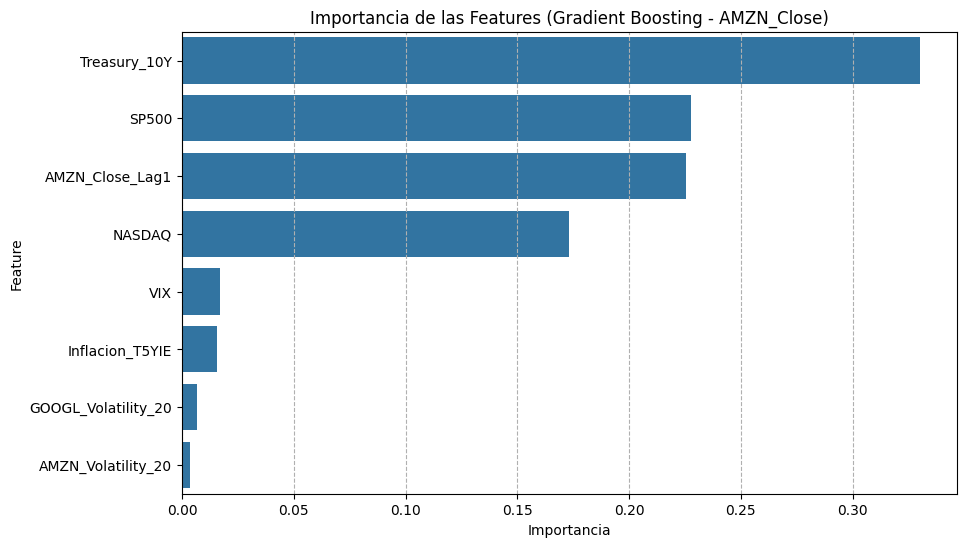


--- Interpretación Financiera (Importancia de Features - AMZN_Close) ---
- 'Treasury_10Y' (0.3302): Indica qué tan relevante fue esta variable para el modelo al hacer predicciones de precio.
  Las variables macro pueden afectar la valoración y el rendimiento de las empresas, incluidas las grandes tecnológicas como Amazon.
- 'SP500' (0.2278): Indica qué tan relevante fue esta variable para el modelo al hacer predicciones de precio.
  Los índices de mercado amplios son importantes ya que AMZN es una acción importante en ellos y sus movimientos se ven influenciados por el sentimiento general del mercado.
- 'AMZN_Close_Lag1' (0.2256): Indica qué tan relevante fue esta variable para el modelo al hacer predicciones de precio.
  Como era de esperar, el precio rezagado (`AMZN_Close_Lag1`) es la feature más importante. El precio de hoy está fuertemente correlacionado con el de ayer.
- 'NASDAQ' (0.1731): Indica qué tan relevante fue esta variable para el modelo al hacer predicciones de precio.


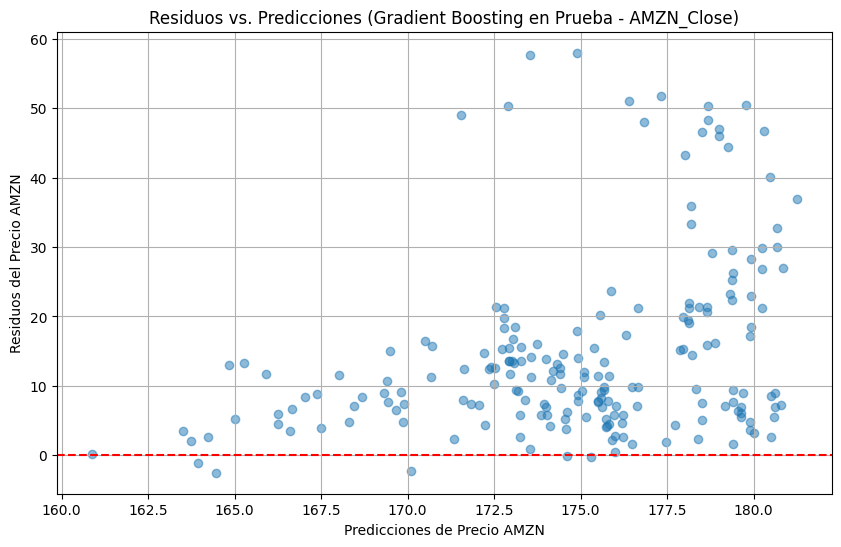

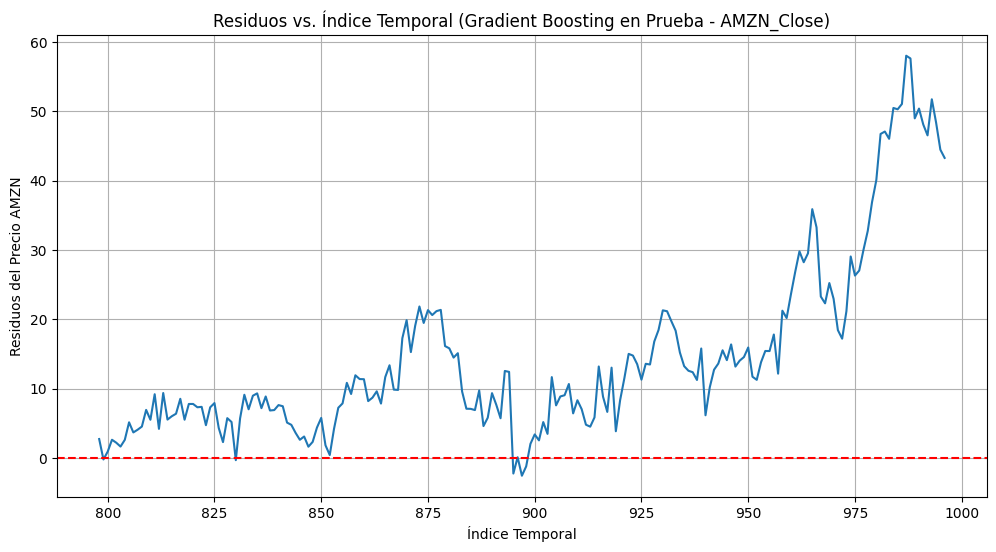

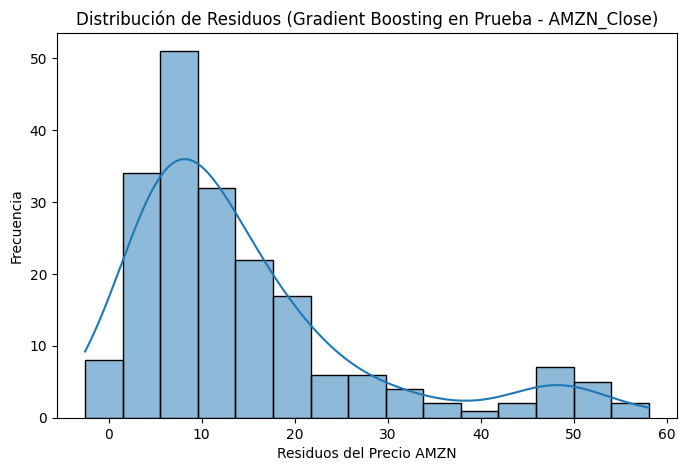


--- Pronóstico con Valores Específicos de Variables Independientes (Gradient Boosting - AMZN_Close) ---

Valores de entrada para el pronóstico específico (AMZN_Close):


,AMZN_Close_Lag1,Treasury_10Y,VIX,SP500,NASDAQ,Inflacion_T5YIE,GOOGL_Volatility_20,AMZN_Volatility_20
0,221.300003,4.500000,18.000000,5200.000000,16500.000000,2.500000,0.015000,0.020000



Pronóstico del Precio de Cierre de AMZN: 177.2241


--- Pronóstico Gradient Boosting para AMZN_Close (Enero-Marzo 2025) ---
Re-entrenando modelo Gradient Boosting para AMZN_Close con todos los datos disponibles...
Re-entrenamiento completado.
Generando pronósticos para el rango de fechas: 2025-01-01 a 2025-03-31
Último precio real conocido (AMZN en 2024-12-30): 221.3000

--- Tabla de Pronósticos de Precio (Gradient Boosting - AMZN) ---


,Forecast_AMZN_Close_GB
Date,
2025-01-01,221.62
2025-01-02,221.62
2025-01-03,221.62
2025-01-06,221.62
2025-01-07,221.62
...,...
2025-03-25,221.62
2025-03-26,221.62
2025-03-27,221.62



--- Gráfico de Pronóstico de Precio (Gradient Boosting - AMZN_Close) ---


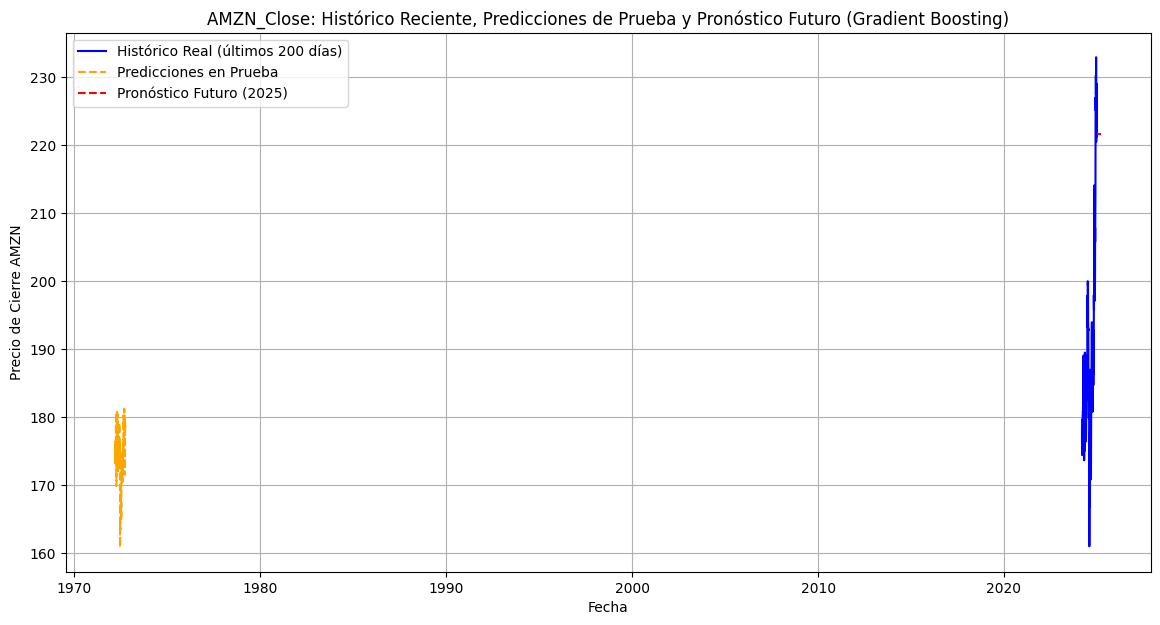


Nota sobre el Pronóstico de Precio (AMZN):
Este pronóstico utiliza el modelo Gradient Boosting entrenado con todos los datos históricos disponibles para AMZN.
Para las variables macro/técnicas en el futuro, se asume que se mantienen en sus últimos valores históricos conocidos (una simplificación).
Para el precio rezagado (AMZN_Close_Lag1), se utiliza el precio pronosticado del día anterior. Esto crea una dependencia autorregresiva.
La precisión de este pronóstico depende fuertemente de las asunciones sobre las variables de entrada futuras, especialmente las macro/técnicas y el propio lag pronosticado que acumula errores.


In [17]:
# %% [markdown]
# ## Gradient Boosting para AMZN_Close
# %%
# --- Gradient Boosting para AMZN_Close ---
print("\n\n--- Modelo Gradient Boosting para AMZN_Close ---")

# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor # Importar Gradient Boosting
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from IPython.display import display
import datetime # Para definir fechas de ventanas

# Cargar datos (asegúrate de que el archivo existe y está preprocesado de celdas anteriores)
# Incluimos la carga y preprocesamiento básico por si esta celda se ejecuta sola.
try:
    df = pd.read_csv("dataset_completo_google_amazon.csv")
except FileNotFoundError:
    print("Error: 'dataset_completo_google_amazon.csv' no encontrado. Asegúrate de que el archivo está en la ruta correcta.")
    exit()

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Crear columnas de precio rezagado si no existen
if 'GOOGL_Close_Lag1' not in df.columns and 'GOOGL_Close' in df.columns:
    df['GOOGL_Close_Lag1'] = df['GOOGL_Close'].shift(1)
if 'AMZN_Close_Lag1' not in df.columns and 'AMZN_Close' in df.columns:
    df['AMZN_Close_Lag1'] = df['AMZN_Close'].shift(1)


# Definir las variables dependientes e independientes para el modelo de precio AMZN
dependent_var_price_amzn = 'AMZN_Close'
independent_vars_price_amzn = [
    'AMZN_Close_Lag1', # Precio de cierre del día anterior - CRUCIAL para modelar precios
    'Treasury_10Y',
    'VIX',
    'SP500',
    'NASDAQ',
    'Inflacion_T5YIE',
    'GOOGL_Volatility_20', # Mantener volatilidad de GOOGL como posible predictor cross-asset
    'AMZN_Volatility_20'
]

# Asegurarse de que todas las columnas requeridas existen en el DataFrame
required_cols_price_amzn = [dependent_var_price_amzn] + independent_vars_price_amzn
missing_cols_price_amzn = [col for col in required_cols_price_amzn if col not in df.columns]
if missing_cols_price_amzn:
    print(f"Error: Faltan las siguientes columnas requeridas para el modelo Gradient Boosting de Precio (AMZN): {missing_cols_price_amzn}")
    # Attempt to create lags if they are the missing ones
    if 'AMZN_Close' in df.columns and 'AMZN_Close_Lag1' not in df.columns and 'AMZN_Close_Lag1' in missing_cols_price_amzn:
         df['AMZN_Close_Lag1'] = df['AMZN_Close'].shift(1)
         missing_cols_price_amzn.remove('AMZN_Close_Lag1')
    # Re-check after attempting to create lags
    missing_cols_price_amzn = [col for col in required_cols_price_amzn if col not in df.columns]
    if missing_cols_price_amzn:
        print(f"Error persistente: Faltan columnas después de intentar crear lags: {missing_cols_price_amzn}")
        exit()


# Eliminar filas con valores nulos en las columnas relevantes para el modelo de precio AMZN
df_model_price_amzn_gb = df.dropna(subset=required_cols_price_amzn).copy()

X_price_amzn_gb = df_model_price_amzn_gb[independent_vars_price_amzn]
y_price_amzn_gb = df_model_price_amzn_gb[dependent_var_price_amzn]

print(f"Dataset para Gradient Boosting (AMZN_Close): {len(df_model_price_amzn_gb)} filas después de eliminar nulos relevantes.")

# 1. División de Datos (manteniendo el orden temporal)
# Usaremos el mismo enfoque de porcentaje o número de filas para la prueba.
test_set_rows_amzn_price = int(len(df_model_price_amzn_gb) * 0.2) # Example: 20% for testing
if test_set_rows_amzn_price < 40: # Ensure minimum size for meaningful test
     test_set_rows_amzn_price = min(40, len(df_model_price_amzn_gb) - 1) # At least 40 or max possible
if len(df_model_price_amzn_gb) <= 1:
     print("\nError: No hay suficientes datos para crear conjuntos de entrenamiento y prueba para el modelo de precio de AMZN.")
     exit()
if test_set_rows_amzn_price == 0: test_set_rows_amzn_price = 1 # Ensure at least one test sample if possible


X_train_amzn_gb, X_test_amzn_gb, y_train_amzn_gb, y_test_amzn_gb = train_test_split(
    X_price_amzn_gb, y_price_amzn_gb, test_size=test_set_rows_amzn_price, shuffle=False
)

print(f"\nDatos de entrenamiento para Gradient Boosting (AMZN_Close): {len(X_train_amzn_gb)} filas")
print(f"Datos de prueba para Gradient Boosting (AMZN_Close):      {len(X_test_amzn_gb)} filas")

if len(X_test_amzn_gb) == 0:
    print("\nAdvertencia: El conjunto de prueba para Gradient Boosting (AMZN_Close) está vacío. Ajusta el tamaño del conjunto de prueba.")
    # Consider adding a break or exit here if the test set is essential for subsequent steps.


# 2. Entrenamiento del Modelo Gradient Boosting
# Puedes ajustar los hiperparámetros (n_estimators, learning_rate, max_depth, etc.)
print("\nEntrenando modelo Gradient Boosting para AMZN_Close...")
gbm_model_amzn = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42, subsample=0.8, max_features='sqrt')
gbm_model_amzn.fit(X_train_amzn_gb, y_train_amzn_gb)
print("Entrenamiento completado.")

# 3. Predicciones en el conjunto de prueba
y_pred_test_amzn_gb = gbm_model_amzn.predict(X_test_amzn_gb)

# 4. Evaluación del modelo en el conjunto de prueba
print("\n--- Evaluación del Modelo Gradient Boosting (Conjunto de Prueba - AMZN_Close) ---")
mae_amzn_gb_test = mean_absolute_error(y_test_amzn_gb, y_pred_test_amzn_gb)
mse_amzn_gb_test = mean_squared_error(y_test_amzn_gb, y_pred_test_amzn_gb)
rmse_amzn_gb_test = np.sqrt(mse_amzn_gb_test) # RMSE es más interpretable que MSE
r2_amzn_gb_test = r2_score(y_test_amzn_gb, y_pred_test_amzn_gb)

print(f"MAE:  {mae_amzn_gb_test:.4f}")
print(f"MSE:  {mse_amzn_gb_test:.4f}")
print(f"RMSE: {rmse_amzn_gb_test:.4f}")
print(f"R²:   {r2_amzn_gb_test:.4f}")

# Interpretación de la precisión (AMZN_Close)
print("\n--- Interpretación de la Precisión (AMZN_Close) ---")
print(f"- MAE ({mae_amzn_gb_test:.4f}): Representa el error absoluto promedio en la predicción del precio de cierre. En promedio, el modelo se equivoca por aproximadamente {mae_amzn_gb_test:.4f} unidades monetarias en la predicción del precio de cierre de AMZN.")
print(f"- RMSE ({rmse_amzn_gb_test:.4f}): Similar al MAE, indica la desviación estándar de los errores de predicción.")
print(f"- R² ({r2_amzn_gb_test:.4f}): Indica la proporción de la varianza en el precio de cierre de AMZN que es predecible a partir de las variables independientes. Un R² de {r2_amzn_gb_test:.4f} significa que aproximadamente el {r2_amzn_gb_test*100:.2f}% de la variabilidad en el precio de AMZN es explicada por el modelo.")
if r2_amzn_gb_test < 0:
    print("  ¡Advertencia: Un R² negativo indica que el modelo es peor que simplemente predecir la media!")
elif r2_amzn_gb_test < 0.5:
     print("  Nota: Un R² relativamente bajo (< 0.5) es común en series de tiempo financieras. La adición del precio rezagado (`AMZN_Close_Lag1`) suele aumentar significativamente el R², pero puede 'ocultar' la contribución real de las otras variables.")
else:
     print("  El R² indica que el modelo tiene una buena capacidad explicativa sobre la variabilidad del precio.")


# 5. Importancia de las Features (AMZN_Close)
print("\n--- Importancia de las Features (Gradient Boosting - AMZN_Close) ---")
feature_importance_amzn = gbm_model_amzn.feature_importances_
feature_importance_amzn_df = pd.DataFrame({
    'Feature': X_train_amzn_gb.columns,
    'Importance': feature_importance_amzn
})
feature_importance_amzn_df = feature_importance_amzn_df.sort_values('Importance', ascending=False).reset_index(drop=True)

display(feature_importance_amzn_df)

# Visualización de la importancia de las features (AMZN_Close)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_amzn_df)
plt.title("Importancia de las Features (Gradient Boosting - AMZN_Close)")
plt.xlabel("Importancia")
plt.ylabel("Feature")
plt.grid(axis='x', linestyle='--')
plt.show()

# Interpretación financiera de la importancia de las features (AMZN_Close)
print("\n--- Interpretación Financiera (Importancia de Features - AMZN_Close) ---")
for index, row in feature_importance_amzn_df.iterrows():
    print(f"- '{row['Feature']}' ({row['Importance']:.4f}): Indica qué tan relevante fue esta variable para el modelo al hacer predicciones de precio.")
    if row['Feature'] == 'AMZN_Close_Lag1':
        print("  Como era de esperar, el precio rezagado (`AMZN_Close_Lag1`) es la feature más importante. El precio de hoy está fuertemente correlacionado con el de ayer.")
    elif row['Feature'] in ['SP500', 'NASDAQ']:
        print("  Los índices de mercado amplios son importantes ya que AMZN es una acción importante en ellos y sus movimientos se ven influenciados por el sentimiento general del mercado.")
    elif row['Feature'] in ['Treasury_10Y', 'Inflacion_T5YIE']:
        print("  Las variables macro pueden afectar la valoración y el rendimiento de las empresas, incluidas las grandes tecnológicas como Amazon.")
    elif row['Feature'] == 'VIX':
        print("  El VIX puede reflejar el riesgo percibido en el mercado, lo que influye en los precios de las acciones.")
    elif '_Volatility_20' in row['Feature']:
         print("  La volatilidad histórica de la acción o de otras acciones relevantes (como GOOGL) puede ser un predictor útil de los movimientos de precios.")
print("\nNota: La importancia de las features en Gradient Boosting es un indicador de su contribución a la reducción del error, no de la dirección de su efecto.")


# 6. Análisis de Residuos (Visual - AMZN_Close)
print("\n--- Análisis Visual de Residuos (Gradient Boosting en Prueba - AMZN_Close) ---")

residuals_test_amzn_gb = y_test_amzn_gb - y_pred_test_amzn_gb

# Gráfico de Residuos vs. Predicciones (AMZN_Close)
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_test_amzn_gb, residuals_test_amzn_gb, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuos vs. Predicciones (Gradient Boosting en Prueba - AMZN_Close)")
plt.xlabel("Predicciones de Precio AMZN")
plt.ylabel("Residuos del Precio AMZN")
plt.grid(True)
plt.show()
# Para la predicción de precios con lag, se espera una buena concentración alrededor de cero, quizás con mayor dispersión en periodos de alta volatilidad.

# Gráfico de Residuos vs. Tiempo (Índice - AMZN_Close)
plt.figure(figsize=(12, 6))
plt.plot(X_test_amzn_gb.index, residuals_test_amzn_gb)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuos vs. Índice Temporal (Gradient Boosting en Prueba - AMZN_Close)")
plt.xlabel("Índice Temporal") # Podrías usar la fecha si la mantuviste en X_test_amzn_gb.index
plt.ylabel("Residuos del Precio AMZN")
plt.grid(True)
plt.show()
# Observa si hay patrones, como rachas de residuos positivos o negativos, lo que podría indicar autocorrelación no capturada.

# Histograma de Residuos (AMZN_Close)
plt.figure(figsize=(8, 5))
sns.histplot(residuals_test_amzn_gb, kde=True)
plt.title("Distribución de Residuos (Gradient Boosting en Prueba - AMZN_Close)")
plt.xlabel("Residuos del Precio AMZN")
plt.ylabel("Frecuencia")
plt.show()
# Se espera una distribución centrada en cero. La normalidad no es un requisito estricto, pero un pico estrecho y colas ligeras sugieren un buen ajuste.


# 7. Pronóstico con Valores Específicos (AMZN_Close)
print("\n--- Pronóstico con Valores Específicos de Variables Independientes (Gradient Boosting - AMZN_Close) ---")

# Define un diccionario con los valores específicos para cada variable independiente.
# Asegúrate de que todas las variables usadas en el entrenamiento (X_train_amzn_gb.columns) estén aquí.
# Estos son solo valores de ejemplo. Reemplázalos con los valores que desees pronosticar.
# Es CRUCIAL proporcionar un valor para 'AMZN_Close_Lag1'
future_values_specific_amzn_gb = {
    'AMZN_Close_Lag1': df_model_price_amzn_gb['AMZN_Close'].iloc[-1], # Usar el último precio real conocido como ejemplo
    'Treasury_10Y': 4.5,  # Ejemplo: Tasa del Tesoro a 10 años
    'VIX': 18.0,           # Ejemplo: Índice VIX
    'SP500': 5200.0,       # Ejemplo: Nivel del S&P 500
    'NASDAQ': 16500.0,     # Ejemplo: Nivel del NASDAQ
    'Inflacion_T5YIE': 2.5,# Ejemplo: Expectativa de Inflación a 5 años
    'GOOGL_Volatility_20': 0.015, # Ejemplo: Volatilidad de GOOGL (en decimal)
    'AMZN_Volatility_20': 0.02 # Ejemplo: Volatilidad de AMZN (en decimal)
}

# Convierte el diccionario en un DataFrame, asegurando el orden correcto (debe coincidir con X_train_amzn_gb.columns).
X_future_single_amzn_gb = pd.DataFrame([future_values_specific_amzn_gb], columns=X_train_amzn_gb.columns)

# Realiza la predicción
predicted_price_amzn_gb = gbm_model_amzn.predict(X_future_single_amzn_gb)

print("\nValores de entrada para el pronóstico específico (AMZN_Close):")
display(X_future_single_amzn_gb)

print(f"\nPronóstico del Precio de Cierre de AMZN: {predicted_price_amzn_gb[0]:.4f}")


# 8. Pronóstico para los primeros 3 meses de 2025 (Enero-Marzo - AMZN_Close)

print("\n\n--- Pronóstico Gradient Boosting para AMZN_Close (Enero-Marzo 2025) ---")

# Ajustar el modelo en TODOS los datos disponibles para el pronóstico futuro
print("Re-entrenando modelo Gradient Boosting para AMZN_Close con todos los datos disponibles...")
gbm_model_amzn_full_data = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42, subsample=0.8, max_features='sqrt')
# Usar el dataset limpio completo (X_price_amzn_gb, y_price_amzn_gb) para entrenar el modelo final
gbm_model_amzn_full_data.fit(X_price_amzn_gb, y_price_amzn_gb)
print("Re-entrenamiento completado.")

# Determinar el rango de fechas para el pronóstico
start_date_2025 = pd.to_datetime('2025-01-01')
end_date_2025 = pd.to_datetime('2025-03-31') # Pronóstico hasta finales de marzo
future_dates_amzn_gb = pd.date_range(start=start_date_2025, end=end_date_2025, freq='B') # 'B' para días hábiles

print(f"Generando pronósticos para el rango de fechas: {future_dates_amzn_gb.min().date()} a {future_dates_amzn_gb.max().date()}")

# --- Preparación de Datos Futuros (Corrección) ---

# Use the last known values from the historical dataset for ALL independent variables
# (except the lag which will be handled recursively).
# This should be based on the columns that the model was trained on (X_price_amzn_gb.columns).
last_known_features_raw_amzn = df_model_price_amzn_gb[X_price_amzn_gb.columns].iloc[-1].to_dict()

# Create a DataFrame for future features (X_future_amzn_gb) with the correct columns (those used for training)
X_future_amzn_gb = pd.DataFrame(index=future_dates_amzn_gb, columns=X_price_amzn_gb.columns)
X_future_amzn_gb.index.name = 'Date'

# Populate the non-lag columns in X_future_amzn_gb with these last known values
cols_to_populate_last_value_amzn_gb = [col for col in X_price_amzn_gb.columns if '_Lag1' not in col]
for col in cols_to_populate_last_value_amzn_gb:
     X_future_amzn_gb[col] = last_known_features_raw_amzn[col]

# Implement the recursive step-by-step forecast for the price, using the lag
last_known_close_amzn = df_model_price_amzn_gb['AMZN_Close'].iloc[-1] # Last known real price
print(f"Último precio real conocido (AMZN en {df_model_price_amzn_gb['Date'].iloc[-1].date()}): {last_known_close_amzn:.4f}")


forecast_values_amzn_gb = []

# Ensure X_future_amzn_gb has columns in the correct order before prediction
# This is already handled by creating X_future_amzn_gb with X_price_amzn_gb.columns

# Get the exact lag column name used in the training data
lag_col_name_amzn = [col for col in X_price_amzn_gb.columns if 'AMZN_Close_Lag1' in col]
if len(lag_col_name_amzn) == 1:
    lag_col_name_amzn = lag_col_name_amzn[0]
else:
    print("Error: No se encontró una columna de lag 'AMZN_Close_Lag1' en los datos de entrenamiento. El pronóstico recursivo no es posible.")
    lag_col_name_amzn = None # Prevent errors later


if lag_col_name_amzn: # Only proceed with recursive forecast if lag column is found
    for i in range(len(future_dates_amzn_gb)):
        current_date = future_dates_amzn_gb[i]

        # Determine the lag value for this day
        if i == 0:
            # For the first forecast day, the lag is the last real known price
            current_lag_amzn = last_known_close_amzn
        else:
            # For subsequent days, the lag is the prediction from the previous day
            current_lag_amzn = forecast_values_amzn_gb[-1] # The prediction from the previous day

        # Create the future features row for the current day, starting with the non-lag values from X_future_amzn_gb
        current_future_row_amzn = X_future_amzn_gb.loc[current_date].to_dict() # Start with values already populated (non-lag)

        # Update the lag feature with the determined value
        current_future_row_amzn[lag_col_name_amzn] = current_lag_amzn

        # Convert to DataFrame for prediction, ensuring correct column order and dtype
        # Now, current_future_row_amzn contains exactly the keys from X_price_amzn_gb.columns
        current_future_values_amzn = [current_future_row_amzn[col] for col in X_price_amzn_gb.columns] # Use X_price_amzn_gb.columns for order
        current_future_df_amzn_gb = pd.DataFrame([current_future_values_amzn], columns=X_price_amzn_gb.columns).astype(X_price_amzn_gb.dtypes)


        # Perform the prediction for the current day
        current_forecast_amzn_gb = gbm_model_amzn_full_data.predict(current_future_df_amzn_gb)
        forecast_values_amzn_gb.append(current_forecast_amzn_gb[0])
else:
    print("Saltando generación de pronóstico debido a la falta de la columna lag.")
    # If you skip forecasting, make sure forecast_df_amzn_gb_2025 is handled appropriately (e.g., initialized empty)


# Create a DataFrame to show the forecast
# Only create the DataFrame if forecast_values_amzn_gb is not empty
if forecast_values_amzn_gb:
    forecast_df_amzn_gb_2025 = pd.DataFrame({
        'Date': future_dates_amzn_gb[:len(forecast_values_amzn_gb)], # Use only the dates for which there are forecasts
        'Forecast_AMZN_Close_GB': forecast_values_amzn_gb
    })
    forecast_df_amzn_gb_2025.set_index('Date', inplace=True)

    print("\n--- Tabla de Pronósticos de Precio (Gradient Boosting - AMZN) ---")
    pd.options.display.float_format = '{:.2f}'.format # Format for price visualization
    display(forecast_df_amzn_gb_2025)
else:
    print("\nNo se pudo generar la tabla de pronósticos para AMZN.")
    # Initialize an empty DataFrame to avoid errors later if you try to plot
    forecast_df_amzn_gb_2025 = pd.DataFrame(columns=['Date', 'Forecast_AMZN_Close_GB']).set_index('Date')


# 9. Gráfico de Pronóstico de Precio (Histórico + Futuro - AMZN_Close)
print("\n--- Gráfico de Pronóstico de Precio (Gradient Boosting - AMZN_Close) ---")

plt.figure(figsize=(14, 7))
# Graficar datos históricos reales (solo los últimos días para contexto)
plt.plot(df_model_price_amzn_gb['Date'].iloc[-200:], df_model_price_amzn_gb['AMZN_Close'].iloc[-200:], label='Histórico Real (últimos 200 días)', color='blue')
# Graficar predicciones en el conjunto de prueba (para ver cómo le fue al modelo en la prueba reciente)
plt.plot(X_test_amzn_gb.index, y_pred_test_amzn_gb, label='Predicciones en Prueba', color='orange', linestyle='--')

# Only plot forecast if the DataFrame is not empty
if not forecast_df_amzn_gb_2025.empty:
    plt.plot(forecast_df_amzn_gb_2025.index, forecast_df_amzn_gb_2025['Forecast_AMZN_Close_GB'], label='Pronóstico Futuro (2025)', color='red', linestyle='--')
else:
     print("No se pudo graficar el pronóstico futuro para AMZN porque el DataFrame de pronósticos está vacío.")


plt.title("AMZN_Close: Histórico Reciente, Predicciones de Prueba y Pronóstico Futuro (Gradient Boosting)")
plt.xlabel("Fecha")
plt.ylabel("Precio de Cierre AMZN")
plt.legend()
plt.grid(True)
plt.show()


print("\nNota sobre el Pronóstico de Precio (AMZN):")
print("Este pronóstico utiliza el modelo Gradient Boosting entrenado con todos los datos históricos disponibles para AMZN.")
print("Para las variables macro/técnicas en el futuro, se asume que se mantienen en sus últimos valores históricos conocidos (una simplificación).")
print("Para el precio rezagado (AMZN_Close_Lag1), se utiliza el precio pronosticado del día anterior. Esto crea una dependencia autorregresiva.")
print("La precisión de este pronóstico depende fuertemente de las asunciones sobre las variables de entrada futuras, especialmente las macro/técnicas y el propio lag pronosticado que acumula errores.")

# Reset pandas format option if necessary
# pd.reset_option('display.float_format')



--- Modelo Gradient Boosting para AMZN_Return_1d ---
Dataset para Gradient Boosting (AMZN_Return_1d): 997 filas después de eliminar nulos relevantes.

Datos de entrenamiento para Gradient Boosting (AMZN_Return_1d): 798 filas
Datos de prueba para Gradient Boosting (AMZN_Return_1d):      199 filas

Entrenando modelo Gradient Boosting para AMZN_Return_1d...
Entrenamiento completado.

--- Evaluación del Modelo Gradient Boosting (Conjunto de Prueba - AMZN_Return_1d) ---
MAE:  0.017635
MSE:  0.000516985123
RMSE: 0.022737
R²:   -0.6486

--- Interpretación de la Precisión (AMZN_Return_1d) ---
- MAE (0.017635): Representa el error absoluto promedio en la predicción del retorno de AMZN. Un MAE bajo es bueno, pero predecir retornos puntuales es muy difícil.
- RMSE (0.022737): Indica la desviación estándar de los errores de predicción del retorno.
- R² (-0.6486): Indica la proporción de la varianza en el retorno diario de AMZN que es predecible. Un R² muy cercano a cero (o negativo) es típico.
 

,Feature,Importance
0,VIX,0.21
1,AMZN_Volatility_20,0.16
2,GOOGL_Volatility_20,0.16
3,Treasury_10Y,0.13
4,SP500,0.12
5,NASDAQ,0.12
6,Inflacion_T5YIE,0.11


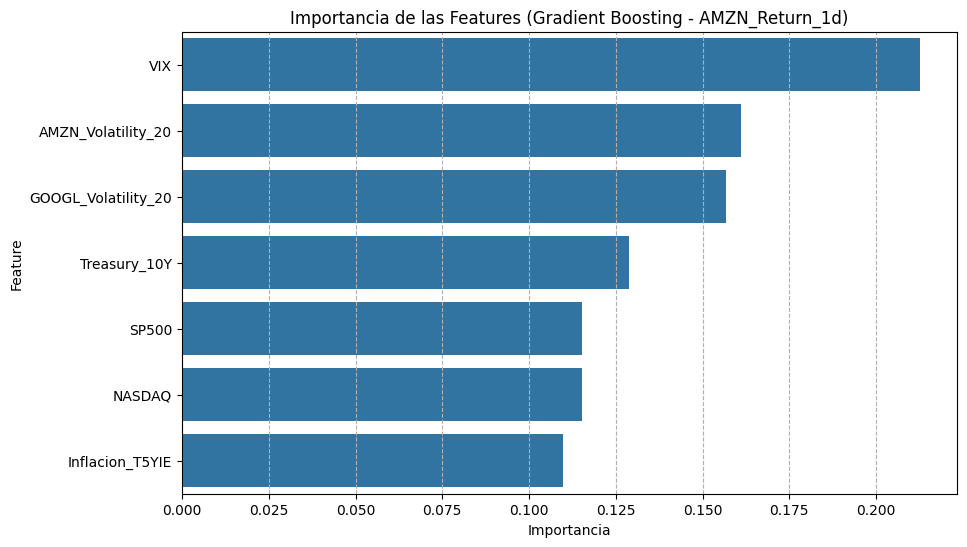


--- Interpretación Financiera (Importancia de Features - AMZN_Return_1d) ---
- 'VIX' (0.2127): Indica qué tan relevante fue esta variable para el modelo al predecir el retorno de AMZN.
  Las variables relacionadas con la volatilidad (VIX, volatilidad histórica de AMZN y GOOGL) a menudo tienen importancia en los modelos de retorno, ya que periodos de alta volatilidad se asocian con grandes movimientos en el precio, aunque no necesariamente con la dirección.
- 'AMZN_Volatility_20' (0.1612): Indica qué tan relevante fue esta variable para el modelo al predecir el retorno de AMZN.
  Las variables relacionadas con la volatilidad (VIX, volatilidad histórica de AMZN y GOOGL) a menudo tienen importancia en los modelos de retorno, ya que periodos de alta volatilidad se asocian con grandes movimientos en el precio, aunque no necesariamente con la dirección.
- 'GOOGL_Volatility_20' (0.1569): Indica qué tan relevante fue esta variable para el modelo al predecir el retorno de AMZN.
  Las variables

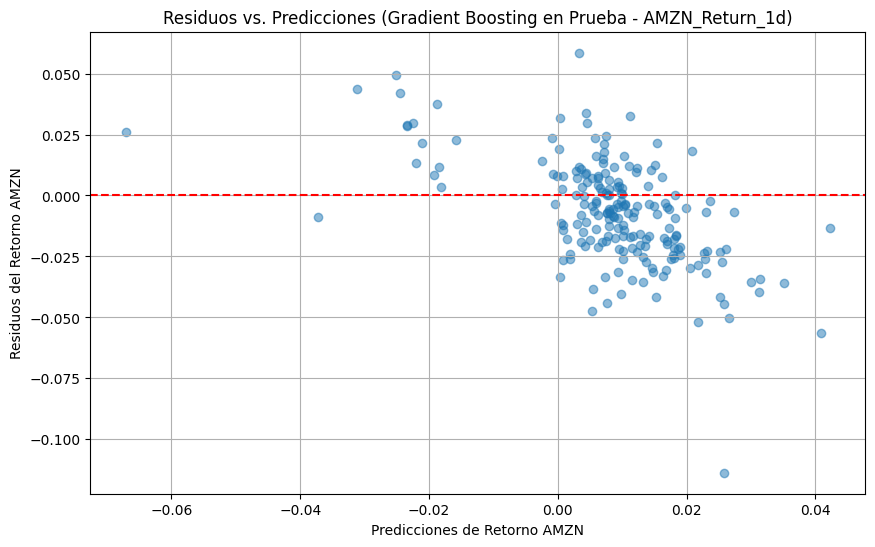

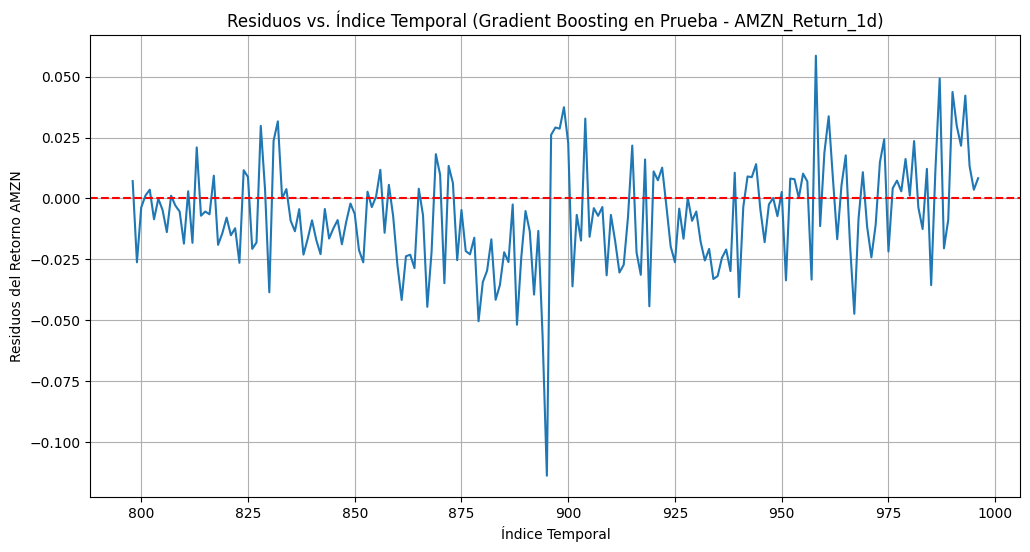

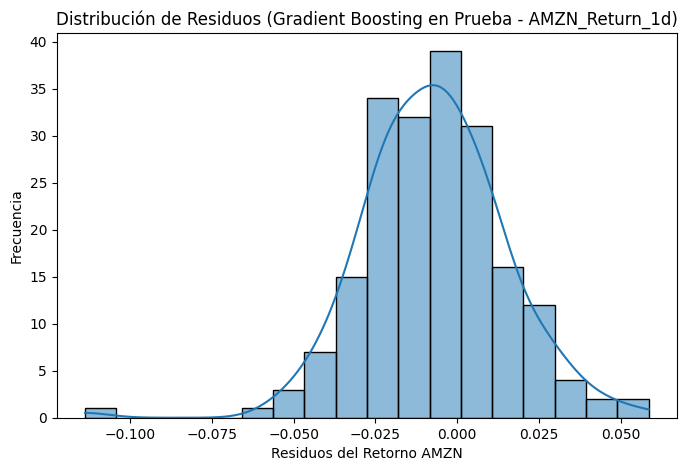


--- Pronóstico con Valores Específicos de Variables Independientes (Gradient Boosting - AMZN_Return_1d) ---

Re-entrenando modelo Gradient Boosting para Retorno de AMZN con todos los datos disponibles para pronóstico...
Re-entrenamiento completado.

Valores de entrada para el pronóstico específico (AMZN_Return_1d):


,Treasury_10Y,VIX,SP500,NASDAQ,Inflacion_T5YIE,GOOGL_Volatility_20,AMZN_Volatility_20
0,4.50,18.00,5200.00,16500.00,2.50,0.01,0.02



Pronóstico del Retorno Diario de AMZN: 0.001921


--- Pronóstico Gradient Boosting para AMZN_Return_1d (Enero-Marzo 2025) ---
Re-entrenando modelo Gradient Boosting para Retorno de AMZN con todos los datos disponibles para pronóstico a 2025...
Re-entrenamiento completado.
Generando pronósticos para el rango de fechas: 2025-01-01 a 2025-03-31
Últimos valores históricos conocidos para el pronóstico de Retorno (AMZN en 2024-12-30): {'Treasury_10Y': 4.545000076293945, 'VIX': 17.399999618530273, 'SP500': 5906.93994140625, 'NASDAQ': 19486.7890625, 'Inflacion_T5YIE': 2.35, 'GOOGL_Volatility_20': 9.512947084422786, 'AMZN_Volatility_20': 5.666061025265696}

--- Tabla de Pronósticos de Retorno (Gradient Boosting - AMZN) ---


,Forecast_AMZN_Return_1d_GB
Date,
2025-01-01,0.001427
2025-01-02,0.001427
2025-01-03,0.001427
2025-01-06,0.001427
2025-01-07,0.001427
...,...
2025-03-25,0.001427
2025-03-26,0.001427
2025-03-27,0.001427



--- Gráfico de Pronóstico de Retorno (Gradient Boosting - AMZN_Return_1d) ---


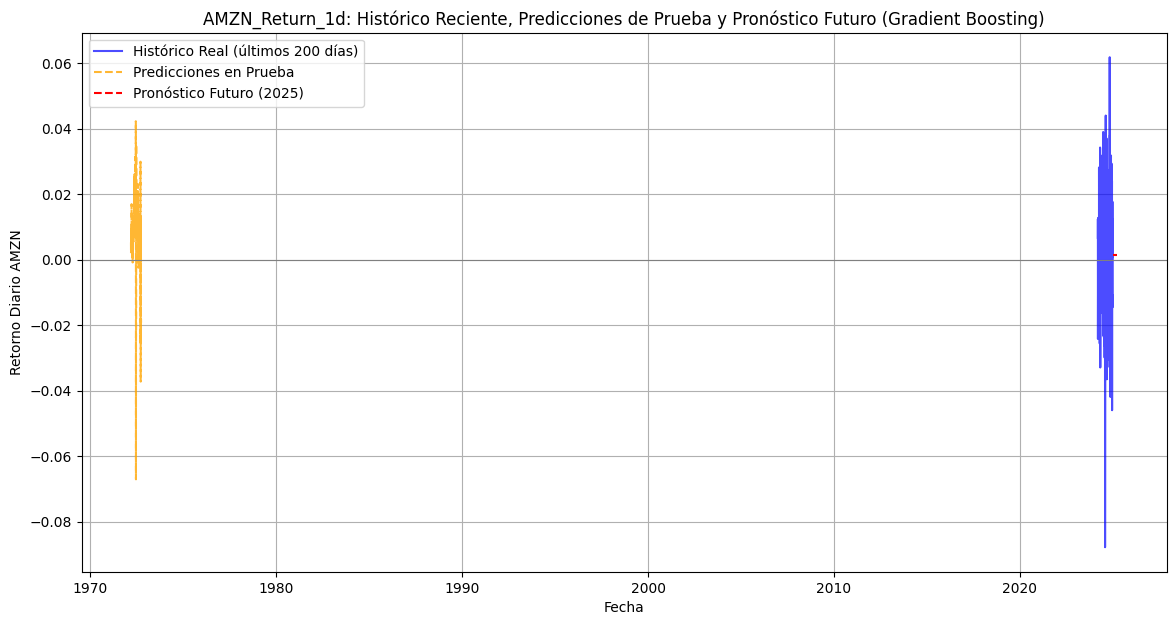


Nota Importante sobre el Gráfico de Pronóstico de Retornos (AMZN):
Como se observó con GOOGL, los retornos diarios puros son muy difíciles de predecir y a menudo muestran valores pronosticados cercanos a cero.
Esto es un reflejo de la eficiencia de los mercados y la dificultad de encontrar patrones predictivos fuertes en los retornos puros utilizando solo variables macro/técnicas.
La principal utilidad de estos modelos para retornos puede estar en el análisis de la importancia de las variables o en la identificación de periodos de mayor/menor volatilidad.

Nota final sobre el Modelo Gradient Boosting para Retornos (AMZN):
A pesar de ser un modelo potente, la predicción del retorno puntual sigue siendo un desafío significativo en finanzas.
La importancia de las features nos ayuda a entender qué factores el modelo consideró más relevantes históricamente para los movimientos de retorno de AMZN.


In [19]:
# %% [markdown]
# ## Gradient Boosting para AMZN_Return_1d
# %%
# --- Gradient Boosting para AMZN_Return_1d ---
print("\n\n--- Modelo Gradient Boosting para AMZN_Return_1d ---")

# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor # Importar Gradient Boosting
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from IPython.display import display
import datetime # Para definir fechas de ventanas

# Cargar datos (asegúrate de que el archivo existe y está preprocesado de celdas anteriores)
# Incluimos la carga y preprocesamiento básico por si esta celda se ejecuta sola.
try:
    df = pd.read_csv("dataset_completo_google_amazon.csv")
except FileNotFoundError:
    print("Error: 'dataset_completo_google_amazon.csv' no encontrado. Asegúrate de que el archivo está en la ruta correcta.")
    exit()

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Definir las variables dependientes e independientes para el modelo de retorno AMZN
dependent_var_return_amzn = 'AMZN_Return_1d'

# Variables independientes para retornos (macro + técnicas). No incluimos el retorno rezagado típicamente.
# Incluimos la volatilidad de GOOGL como posible predictor cross-asset.
independent_vars_return_amzn = [
    'Treasury_10Y',
    'VIX',
    'SP500',
    'NASDAQ',
    'Inflacion_T5YIE',
    'GOOGL_Volatility_20',
    'AMZN_Volatility_20'
]

# Asegurarse de que todas las columnas requeridas existen en el DataFrame
required_cols_return_amzn = [dependent_var_return_amzn] + independent_vars_return_amzn
missing_cols_return_amzn = [col for col in required_cols_return_amzn if col not in df.columns]
if missing_cols_return_amzn:
    print(f"Error: Faltan las siguientes columnas requeridas para el modelo Gradient Boosting de Retorno (AMZN): {missing_cols_return_amzn}")
    exit()


# Eliminar filas con valores nulos en las columnas relevantes para el modelo de retorno AMZN
df_model_return_gb = df.dropna(subset=required_cols_return_amzn).copy()

# Verificar si hay suficientes datos después de limpiar nulos
if len(df_model_return_gb) <= 1:
     print(f"\nError: No hay suficientes datos ({len(df_model_return_gb)} filas) para entrenar y evaluar el modelo de retorno de AMZN después de limpiar nulos relevantes.")
     # We will still attempt to forecast if future data can be generated, but cannot evaluate performance.
     can_evaluate = False
     X_return_gb = pd.DataFrame() # Initialize empty to prevent errors later
     y_return_gb = pd.Series(dtype='float64') # Initialize empty
else:
     print(f"Dataset para Gradient Boosting (AMZN_Return_1d): {len(df_model_return_gb)} filas después de eliminar nulos relevantes.")
     X_return_gb = df_model_return_gb[independent_vars_return_amzn]
     y_return_gb = df_model_return_gb[dependent_var_return_amzn]
     can_evaluate = True # Set flag to indicate enough data for evaluation

# 1. División de Datos (manteniendo el orden temporal)
# Solo intentar dividir si hay suficientes datos
if can_evaluate:
    # Usaremos un porcentaje fijo (ej. 20%) para la prueba.
    test_set_rows_amzn_return = int(len(df_model_return_gb) * 0.2) # Example: 20% for testing
    if test_set_rows_amzn_return < 40 and len(df_model_return_gb) >= 40:
        # Ensure at least 40 rows if the total dataset is large enough
        test_set_rows_amzn_return = 40
    elif test_set_rows_amzn_return == 0 and len(df_model_return_gb) > 1:
         # Ensure at least 1 row if the total dataset allows
         test_set_rows_amzn_return = 1
    elif len(df_model_return_gb) <= 1:
         # This case is already handled by the initial 'can_evaluate' check,
         # but keeping it here for clarity in the split logic.
         print("\nAdvertencia: No hay suficientes datos para crear un conjunto de prueba válido.")
         # Set train/test sets to empty DataFrames/Series
         X_train_return_amzn_gb = pd.DataFrame()
         X_test_return_amzn_gb = pd.DataFrame()
         y_train_return_amzn_gb = pd.Series(dtype='float64')
         y_test_return_amzn_gb = pd.Series(dtype='float64')
         can_evaluate = False # Update flag
    else:
        # Fallback for very small datasets (2 to 39 rows)
        test_set_rows_amzn_return = max(1, int(len(df_model_return_gb) * 0.2))
        if len(df_model_return_gb) - test_set_rows_amzn_return < 1:
             test_set_rows_amzn_return = len(df_model_return_gb) - 1 # Ensure at least 1 train sample


    if can_evaluate and (len(df_model_return_gb) - test_set_rows_amzn_return) < 1:
         print(f"\nAdvertencia: El tamaño del conjunto de entrenamiento ({len(df_model_return_gb) - test_set_rows_amzn_return} filas) es insuficiente. Reduciendo el tamaño del conjunto de prueba.")
         test_set_rows_amzn_return = len(df_model_return_gb) - 1
         if test_set_rows_amzn_return < 1: # Should not happen based on initial check, but safety
              can_evaluate = False
              X_train_return_amzn_gb = pd.DataFrame()
              X_test_return_amzn_gb = pd.DataFrame()
              y_train_return_amzn_gb = pd.Series(dtype='float64')
              y_test_return_amzn_gb = pd.Series(dtype='float64')
         else:
             X_train_return_amzn_gb, X_test_return_amzn_gb, y_train_return_amzn_gb, y_test_return_amzn_gb = train_test_split(
                X_return_gb, y_return_gb, test_size=test_set_rows_amzn_return, shuffle=False
             )


    if can_evaluate and (len(X_train_return_amzn_gb) == 0 or len(X_test_return_amzn_gb) == 0):
        print(f"\nError: La división de datos resultó en conjuntos vacíos (Entrenamiento: {len(X_train_return_amzn_gb)}, Prueba: {len(X_test_return_amzn_gb)}). No se puede proceder con la evaluación.")
        can_evaluate = False # Update flag
        # Set train/test sets to empty DataFrames/Series
        X_train_return_amzn_gb = pd.DataFrame()
        X_test_return_amzn_gb = pd.DataFrame()
        y_train_return_amzn_gb = pd.Series(dtype='float64')
        y_test_return_amzn_gb = pd.Series(dtype='float64')
    elif can_evaluate:
        # If split was successful and sets are not empty
        X_train_return_amzn_gb, X_test_return_amzn_gb, y_train_return_amzn_gb, y_test_return_amzn_gb = train_test_split(
            X_return_gb, y_return_gb, test_size=test_set_rows_amzn_return, shuffle=False
        )
        print(f"\nDatos de entrenamiento para Gradient Boosting (AMZN_Return_1d): {len(X_train_return_amzn_gb)} filas")
        print(f"Datos de prueba para Gradient Boosting (AMZN_Return_1d):      {len(X_test_return_amzn_gb)} filas")

else: # If can_evaluate was False from the start (not enough data)
    print("\nSaltando división de datos y evaluación debido a datos insuficientes.")
    # Set train/test sets to empty DataFrames/Series
    X_train_return_amzn_gb = pd.DataFrame()
    X_test_return_amzn_gb = pd.DataFrame()
    y_train_return_amzn_gb = pd.Series(dtype='float64')
    y_test_return_amzn_gb = pd.Series(dtype='float64')


# Proceed with training and evaluation ONLY if can_evaluate is True
if can_evaluate:
    # 2. Entrenamiento del Modelo Gradient Boosting
    # Puedes ajustar los hiperparámetros. La predicción de retornos es difícil.
    print("\nEntrenando modelo Gradient Boosting para AMZN_Return_1d...")
    gbm_model_amzn_return = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42, subsample=0.8, max_features='sqrt')
    gbm_model_amzn_return.fit(X_train_return_amzn_gb, y_train_return_amzn_gb)
    print("Entrenamiento completado.")

    # 3. Predicciones en el conjunto de prueba
    y_pred_test_amzn_return_gb = gbm_model_amzn_return.predict(X_test_return_amzn_gb)

    # 4. Evaluación del modelo en el conjunto de prueba
    print("\n--- Evaluación del Modelo Gradient Boosting (Conjunto de Prueba - AMZN_Return_1d) ---")
    mae_amzn_return_gb_test = mean_absolute_error(y_test_return_amzn_gb, y_pred_test_amzn_return_gb)
    mse_amzn_return_gb_test = mean_squared_error(y_test_return_amzn_gb, y_pred_test_amzn_return_gb)
    rmse_amzn_return_gb_test = np.sqrt(mse_amzn_return_gb_test) # RMSE es más interpretable que MSE
    r2_amzn_return_gb_test = r2_score(y_test_return_amzn_gb, y_pred_test_amzn_return_gb)

    print(f"MAE:  {mae_amzn_return_gb_test:.6f}") # Usamos más decimales para retornos
    print(f"MSE:  {mse_amzn_return_gb_test:.12f}") # MSE de retornos suele ser muy pequeño
    print(f"RMSE: {rmse_amzn_return_gb_test:.6f}")
    print(f"R²:   {r2_amzn_return_gb_test:.4f}")

    # Interpretación de la precisión (AMZN_Return_1d)
    print("\n--- Interpretación de la Precisión (AMZN_Return_1d) ---")
    print(f"- MAE ({mae_amzn_return_gb_test:.6f}): Representa el error absoluto promedio en la predicción del retorno de AMZN. Un MAE bajo es bueno, pero predecir retornos puntuales es muy difícil.")
    print(f"- RMSE ({rmse_amzn_return_gb_test:.6f}): Indica la desviación estándar de los errores de predicción del retorno.")
    print(f"- R² ({r2_amzn_return_gb_test:.4f}): Indica la proporción de la varianza en el retorno diario de AMZN que es predecible. Un R² muy cercano a cero (o negativo) es típico.")
    if r2_amzn_return_gb_test < 0.01: # A very low R2
        print("  Nota: Un R² muy bajo (< 0.01) es **común y esperable** al predecir retornos puros de activos financieros. Esto resalta la naturaleza ruidosa e impredecible de los retornos diarios con variables macro/técnicas estándar.")
        print("  La utilidad de estos modelos a menudo radica en identificar *tendencias* de muy corto plazo o patrones de *volatilidad*, más que predecir el retorno puntual exacto.")
        print("  Considera si necesitas predecir la *dirección* del movimiento (clasificación) en lugar del retorno exacto (regresión).")
    else:
        print("  El R² indica que el modelo logra capturar una pequeña parte de la variabilidad del retorno de AMZN.")


    # 5. Importancia de las Features (AMZN_Return_1d)
    print("\n--- Importancia de las Features (Gradient Boosting - AMZN_Return_1d) ---")
    feature_importance_amzn_return = gbm_model_amzn_return.feature_importances_
    feature_importance_amzn_return_df = pd.DataFrame({
        'Feature': X_train_return_amzn_gb.columns,
        'Importance': feature_importance_amzn_return
    })
    feature_importance_amzn_return_df = feature_importance_amzn_return_df.sort_values('Importance', ascending=False).reset_index(drop=True)

    display(feature_importance_amzn_return_df)

    # Visualización de la importancia de las features (AMZN_Return_1d)
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_amzn_return_df)
    plt.title("Importancia de las Features (Gradient Boosting - AMZN_Return_1d)")
    plt.xlabel("Importancia")
    plt.ylabel("Feature")
    plt.grid(axis='x', linestyle='--')
    plt.show()

    # Interpretación financiera de la importancia de las features (AMZN_Return_1d)
    print("\n--- Interpretación Financiera (Importancia de Features - AMZN_Return_1d) ---")
    for index, row in feature_importance_amzn_return_df.iterrows():
        print(f"- '{row['Feature']}' ({row['Importance']:.4f}): Indica qué tan relevante fue esta variable para el modelo al predecir el retorno de AMZN.")
        if row['Feature'] in ['VIX', 'GOOGL_Volatility_20', 'AMZN_Volatility_20']:
            print("  Las variables relacionadas con la volatilidad (VIX, volatilidad histórica de AMZN y GOOGL) a menudo tienen importancia en los modelos de retorno, ya que periodos de alta volatilidad se asocian con grandes movimientos en el precio, aunque no necesariamente con la dirección.")
        elif row['Feature'] in ['SP500', 'NASDAQ']:
            print("  Los movimientos del mercado general influyen en los retornos de las acciones individuales, especialmente en acciones de gran capitalización como AMZN.")
        elif row['Feature'] in ['Treasury_10Y', 'Inflacion_T5YIE']:
            print("  Variables macroeconómicas pueden influir sutilmente en los retornos esperados y en el sentimiento del mercado.")
    print("\nNota: Es común que la volatilidad sea una feature importante en modelos de retorno, reflejando su relación con la magnitud de los movimientos de precios.")


    # 6. Análisis de Residuos (Visual - AMZN_Return_1d)
    print("\n--- Análisis Visual de Residuos (Gradient Boosting en Prueba - AMZN_Return_1d) ---")

    residuals_test_amzn_return_gb = y_test_return_amzn_gb - y_pred_test_amzn_return_gb

    # Gráfico de Residuos vs. Predicciones (AMZN_Return_1d)
    plt.figure(figsize=(10, 6))
    plt.scatter(y_pred_test_amzn_return_gb, residuals_test_amzn_return_gb, alpha=0.5)
    plt.axhline(0, color='red', linestyle='--')
    plt.title("Residuos vs. Predicciones (Gradient Boosting en Prueba - AMZN_Return_1d)")
    plt.xlabel("Predicciones de Retorno AMZN")
    plt.ylabel("Residuos del Retorno AMZN")
    plt.grid(True)
    plt.show()
    # Similar al retorno de GOOGL, probablemente veremos una nube de puntos centrada en cero, indicando que las predicciones están cerca de cero.

    # Gráfico de Residuos vs. Tiempo (Índice - AMZN_Return_1d)
    plt.figure(figsize=(12, 6))
    plt.plot(X_test_return_amzn_gb.index, residuals_test_amzn_return_gb)
    plt.axhline(0, color='red', linestyle='--')
    plt.title("Residuos vs. Índice Temporal (Gradient Boosting en Prueba - AMZN_Return_1d)")
    plt.xlabel("Índice Temporal") # Podrías usar la fecha si la mantuviste en X_test_return_amzn_gb.index
    plt.ylabel("Residuos del Retorno AMZN")
    plt.grid(True)
    plt.show()
    # Observa si los errores grandes ocurren en clusters, coincidiendo con periodos de alta volatilidad.

    # Histograma de Residuos (AMZN_Return_1d)
    plt.figure(figsize=(8, 5))
    sns.histplot(residuals_test_amzn_return_gb, kde=True)
    plt.title("Distribución de Residuos (Gradient Boosting en Prueba - AMZN_Return_1d)")
    plt.xlabel("Residuos del Retorno AMZN")
    plt.ylabel("Frecuencia")
    plt.show()
    # Es probable que la distribución tenga colas más pesadas que una distribución normal, reflejando eventos extremos en los retornos.

else:
    # If not enough data for evaluation, print a message
    print("\nSaltando entrenamiento, evaluación y análisis de residuos debido a datos insuficientes para un conjunto de prueba válido.")
    # Initialize an empty model or None if needed later, though forecasting uses a separate 'full data' model


# 7. Pronóstico con Valores Específicos (AMZN_Return_1d)
print("\n--- Pronóstico con Valores Específicos de Variables Independientes (Gradient Boosting - AMZN_Return_1d) ---")

# Define un diccionario con los valores específicos para cada variable independiente.
# Asegúrate de que todas las variables usadas en el entrenamiento (X_return_gb.columns) estén aquí.
# Estos son solo valores de ejemplo. Reemplázalos con los valores que desees pronosticar.
future_values_specific_amzn_return_gb = {
    'Treasury_10Y': 4.5,  # Ejemplo: Tasa del Tesoro a 10 años
    'VIX': 18.0,           # Ejemplo: Índice VIX
    'SP500': 5200.0,       # Ejemplo: Nivel del S&P 500
    'NASDAQ': 16500.0,     # Ejemplo: Nivel del NASDAQ
    'Inflacion_T5YIE': 2.5,# Ejemplo: Expectativa de Inflación a 5 años
    'GOOGL_Volatility_20': 0.015, # Ejemplo: Volatilidad de GOOGL (en decimal)
    'AMZN_Volatility_20': 0.02 # Ejemplo: Volatilidad de AMZN (en decimal)
}

# Convert the dictionary to a DataFrame, ensuring the correct order (must match X_return_gb.columns).
# We use X_return_gb.columns here because the full-data model will be trained on these columns.
X_future_single_amzn_return_gb = pd.DataFrame([future_values_specific_amzn_return_gb], columns=X_return_gb.columns)

# Realiza la predicción - uses the full data model trained below
# Need to train the full data model first if not enough data for test set
if len(df_model_return_gb) > 1: # Ensure there's enough data to train the full model
     # Ajustar el modelo en TODOS los datos disponibles para el pronóstico futuro
     print("\nRe-entrenando modelo Gradient Boosting para Retorno de AMZN con todos los datos disponibles para pronóstico...")
     gbm_model_amzn_return_full_data = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42, subsample=0.8, max_features='sqrt')
     # Usar el dataset limpio completo (X_return_gb, y_return_gb) para entrenar el modelo final
     gbm_model_amzn_return_full_data.fit(X_return_gb, y_return_gb)
     print("Re-entrenamiento completado.")

     predicted_return_amzn_gb = gbm_model_amzn_return_full_data.predict(X_future_single_amzn_return_gb)

     print("\nValores de entrada para el pronóstico específico (AMZN_Return_1d):")
     display(X_future_single_amzn_return_gb)

     print(f"\nPronóstico del Retorno Diario de AMZN: {predicted_return_amzn_gb[0]:.6f}") # Formato para retorno
else:
     print("\nSaltando pronóstico con valores específicos debido a datos insuficientes para entrenar el modelo completo.")


# 8. Pronóstico para los primeros 3 meses de 2025 (Enero-Marzo - AMZN_Return_1d)

print("\n\n--- Pronóstico Gradient Boosting para AMZN_Return_1d (Enero-Marzo 2025) ---")

# Ajustar el modelo en TODOS los datos disponibles para el pronóstico futuro
# This part is the same as the previous block, but included again for clarity
# if the blocks were run independently. Ensure model is trained on full data.
if len(df_model_return_gb) > 1: # Ensure there's enough data to train the full model
     # Re-train if not already done in the specific forecast block above,
     # or just use the model trained in the specific forecast block.
     # To be safe and ensure it's always trained on the latest full data:
     print("Re-entrenando modelo Gradient Boosting para Retorno de AMZN con todos los datos disponibles para pronóstico a 2025...")
     gbm_model_amzn_return_full_data = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42, subsample=0.8, max_features='sqrt')
     gbm_model_amzn_return_full_data.fit(X_return_gb, y_return_gb)
     print("Re-entrenamiento completado.")


     # Determinar el rango de fechas para el pronóstico
     start_date_2025 = pd.to_datetime('2025-01-01')
     end_date_2025 = pd.to_datetime('2025-03-31') # Pronóstico hasta finales de marzo
     future_dates_amzn_return_gb = pd.date_range(start=start_date_2025, end=end_date_2025, freq='B') # 'B' para días hábiles

     print(f"Generando pronósticos para el rango de fechas: {future_dates_amzn_return_gb.min().date()} a {future_dates_amzn_return_gb.max().date()}")

     # Crear un DataFrame para las features futuras (X_future_amzn_return_gb)
     # Como no usamos el retorno rezagado, podemos usar los últimos valores históricos conocidos
     # de las variables independientes para cada día futuro.
     last_known_features_amzn_return_raw = df_model_return_gb[X_return_gb.columns].iloc[-1].to_dict()
     last_known_date_amzn_return = df_model_return_gb['Date'].iloc[-1]
     print(f"Últimos valores históricos conocidos para el pronóstico de Retorno (AMZN en {last_known_date_amzn_return.date()}): {last_known_features_amzn_return_raw}")


     X_future_amzn_return_gb = pd.DataFrame(index=future_dates_amzn_return_gb, columns=X_return_gb.columns)
     X_future_amzn_return_gb.index.name = 'Date'

     # Poblar el DataFrame futuro con los últimos valores conocidos de las features
     for col in X_future_amzn_return_gb.columns:
          X_future_amzn_return_gb[col] = last_known_features_amzn_return_raw[col]

     # Realizar las predicciones para el período futuro (esto se puede hacer en bloque)
     # Asegurarse de que las columnas y tipos de datos coinciden con los datos de entrenamiento
     X_future_amzn_return_gb = X_future_amzn_return_gb.astype(X_return_gb.dtypes)

     forecast_values_amzn_return_gb = gbm_model_amzn_return_full_data.predict(X_future_amzn_return_gb)


     # Create a DataFrame to show the forecast
     forecast_df_amzn_return_gb_2025 = pd.DataFrame({
         'Date': future_dates_amzn_return_gb,
         'Forecast_AMZN_Return_1d_GB': forecast_values_amzn_return_gb
     })
     forecast_df_amzn_return_gb_2025.set_index('Date', inplace=True)

     print("\n--- Tabla de Pronósticos de Retorno (Gradient Boosting - AMZN) ---")
     pd.options.display.float_format = '{:.6f}'.format # Format for return visualization
     display(forecast_df_amzn_return_gb_2025)

else:
    print("\nSaltando generación de pronóstico a 2025 debido a datos insuficientes para entrenar el modelo completo.")
    # Initialize an empty DataFrame to avoid errors later if you try to plot
    forecast_df_amzn_return_gb_2025 = pd.DataFrame(columns=['Date', 'Forecast_AMZN_Return_1d_GB']).set_index('Date')


# 9. Gráfico de Pronóstico de Retorno (Histórico + Futuro - AMZN_Return_1d)
print("\n--- Gráfico de Pronóstico de Retorno (Gradient Boosting - AMZN_Return_1d) ---")

plt.figure(figsize=(14, 7))
# Graficar datos históricos reales (solo los últimos días para contexto)
plt.plot(df_model_return_gb['Date'].iloc[-200:], df_model_return_gb['AMZN_Return_1d'].iloc[-200:], label='Histórico Real (últimos 200 días)', color='blue', alpha=0.7)

# Graficar predicciones en el conjunto de prueba ONLY IF can_evaluate is True
if can_evaluate:
    plt.plot(X_test_return_amzn_gb.index, y_pred_test_amzn_return_gb, label='Predicciones en Prueba', color='orange', linestyle='--', alpha=0.8)
else:
    print("No se pudieron graficar las predicciones en prueba debido a datos insuficientes.")

# Graficar pronóstico futuro ONLY IF the forecast DataFrame is not empty
if not forecast_df_amzn_return_gb_2025.empty:
    plt.plot(forecast_df_amzn_return_gb_2025.index, forecast_df_amzn_return_gb_2025['Forecast_AMZN_Return_1d_GB'], label='Pronóstico Futuro (2025)', color='red', linestyle='--')
else:
     print("No se pudo graficar el pronóstico futuro porque el DataFrame de pronósticos está vacío.")


# Añadir línea en cero para referencia
plt.axhline(0, color='grey', linestyle='-', linewidth=0.8)

plt.title("AMZN_Return_1d: Histórico Reciente, Predicciones de Prueba y Pronóstico Futuro (Gradient Boosting)")
plt.xlabel("Fecha")
plt.ylabel("Retorno Diario AMZN")
plt.legend()
plt.grid(True)
plt.show()

# NOTA IMPORTANTE sobre el gráfico de retornos:
print("\nNota Importante sobre el Gráfico de Pronóstico de Retornos (AMZN):")
print("Como se observó con GOOGL, los retornos diarios puros son muy difíciles de predecir y a menudo muestran valores pronosticados cercanos a cero.")
print("Esto es un reflejo de la eficiencia de los mercados y la dificultad de encontrar patrones predictivos fuertes en los retornos puros utilizando solo variables macro/técnicas.")
print("La principal utilidad de estos modelos para retornos puede estar en el análisis de la importancia de las variables o en la identificación de periodos de mayor/menor volatilidad.")


print("\nNota final sobre el Modelo Gradient Boosting para Retornos (AMZN):")
print("A pesar de ser un modelo potente, la predicción del retorno puntual sigue siendo un desafío significativo en finanzas.")
print("La importancia de las features nos ayuda a entender qué factores el modelo consideró más relevantes históricamente para los movimientos de retorno de AMZN.")


# Reset pandas format option if necessary
# pd.reset_option('display.float_format')

In [20]:
!pip install xgboost lightgbm



--- Modelo XGBoost para GOOGL_Close ---
Dataset para modelos de Boosting (GOOGL_Close): 996 filas después de eliminar nulos relevantes.

Datos de entrenamiento para Boosting (GOOGL_Close): 797 filas
Datos de prueba para Boosting (GOOGL_Close):      199 filas


--- Ejecutando Modelo XGBoost ---
Entrenando modelo XGBoost...
Entrenamiento XGBoost completado.

--- Evaluación del Modelo XGBoost (Conjunto de Prueba) ---
MAE:  22.1646
MSE:  620.1052
RMSE: 24.9019
R²:   -3.4118

--- Importancia de las Features (XGBoost) ---


,Feature,Importance
0,SP500,0.585214
1,GOOGL_Close_Lag1,0.327056
2,NASDAQ,0.049222
3,Treasury_10Y,0.014889
4,GOOGL_Volatility_20,0.010862
5,Inflacion_T5YIE,0.007999
6,AMZN_Volatility_20,0.002801
7,VIX,0.001956


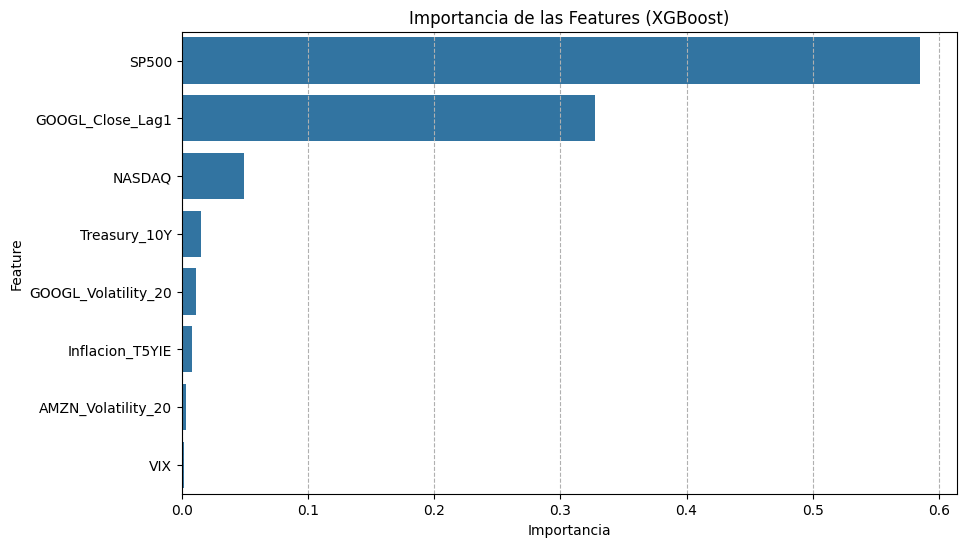


--- Análisis Visual de Residuos (XGBoost en Prueba) ---


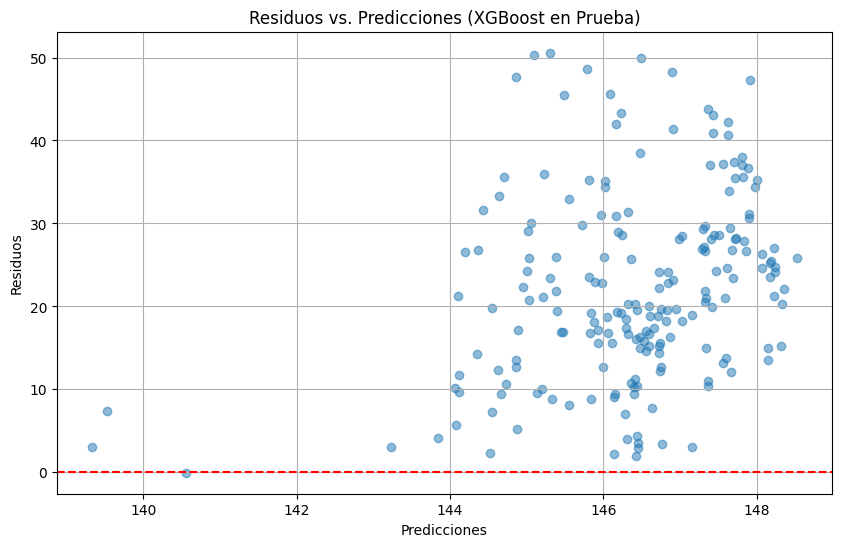

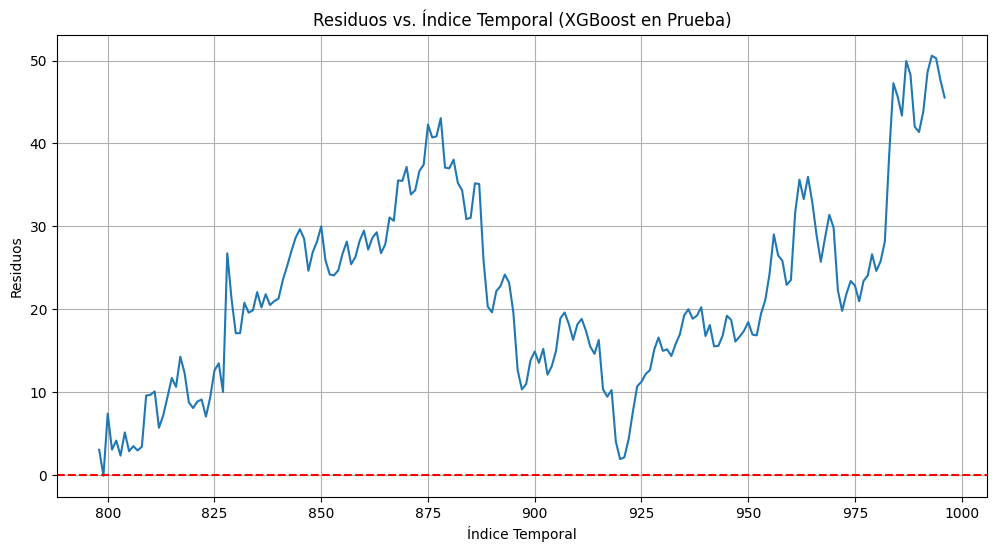

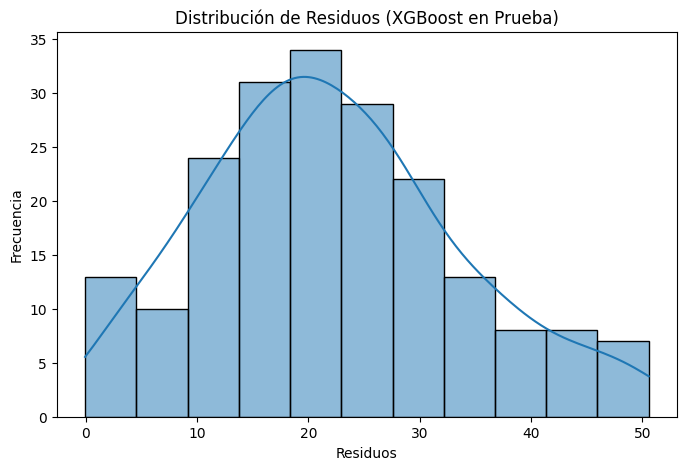



--- Modelo LightGBM para GOOGL_Close ---
Entrenando modelo LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000255 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1892
[LightGBM] [Info] Number of data points in the train set: 797, number of used features: 8
[LightGBM] [Info] Start training from score 120.131064
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

,Feature,Importance
0,GOOGL_Close_Lag1,486
1,AMZN_Volatility_20,429
2,NASDAQ,368
3,VIX,350
4,Treasury_10Y,345
5,GOOGL_Volatility_20,336
6,SP500,335
7,Inflacion_T5YIE,308


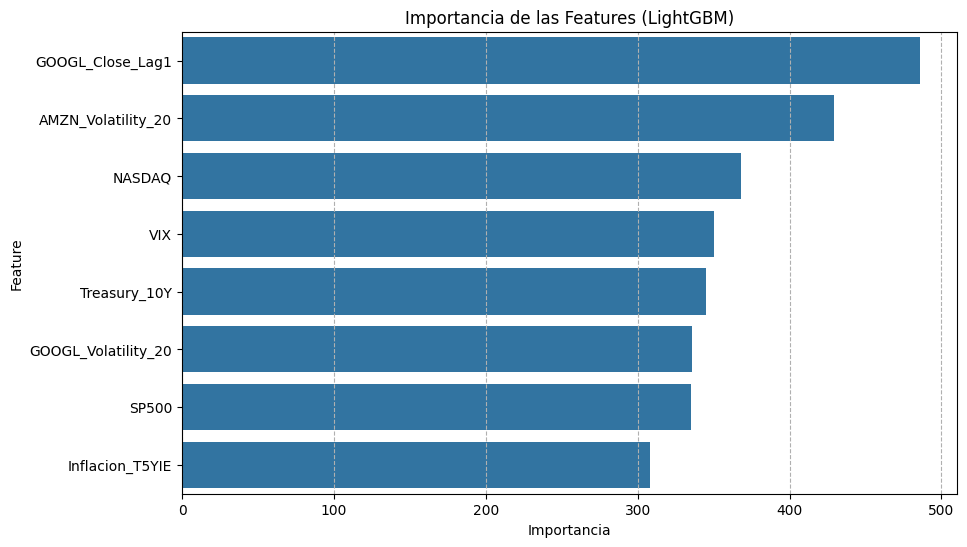


--- Análisis Visual de Residuos (LightGBM en Prueba) ---


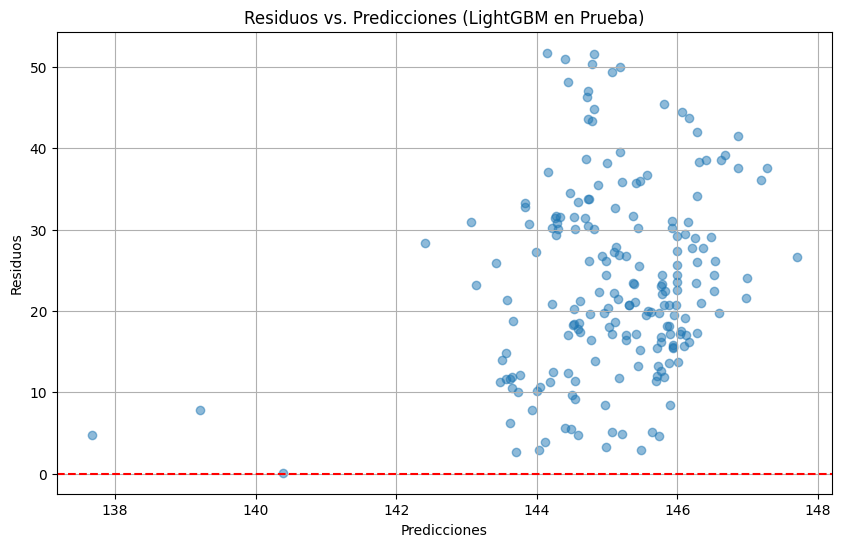

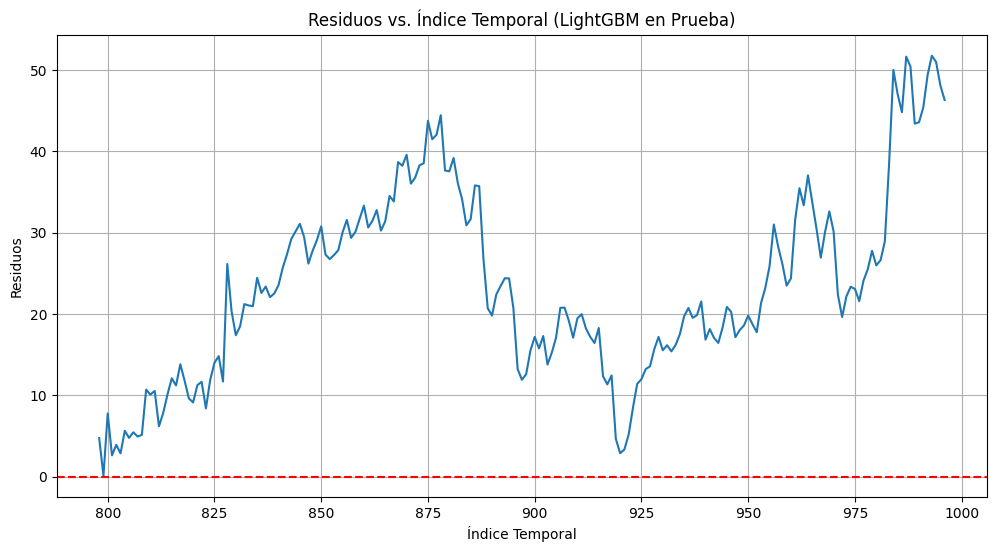

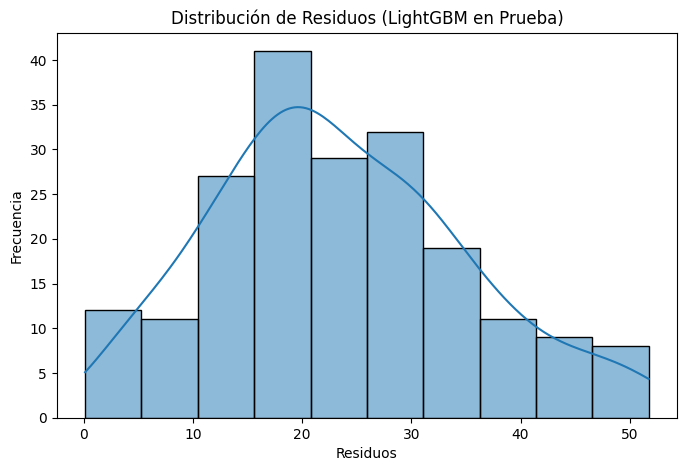



--- Comparativa de Métricas de Evaluación (XGBoost vs LightGBM en Prueba) ---


,MAE,MSE,RMSE,R2
XGBoost,22.1646,620.1052,24.9019,-3.4118
LightGBM,23.4289,681.6254,26.1080,-3.8495



--- Interpretación de la Comparativa ---
Ambos modelos, XGBoost y LightGBM, son variantes avanzadas de Gradient Boosting y suelen ofrecer un rendimiento similar.
Observando las métricas (MAE, RMSE, R²):
  XGBoost tiene un MAE ligeramente menor (22.1646 vs 23.4289).
  XGBoost tiene un RMSE ligeramente menor (24.9019 vs 26.1080).
  XGBoost tiene un R² ligeramente mayor (-3.4118 vs -3.8495).

Considera que estas diferencias pueden variar con la selección de hiperparámetros y el tamaño del dataset.


--- Pronóstico con Valores Específicos de Variables Independientes (XGBoost y LightGBM) ---

Valores de entrada para el pronóstico específico:


,GOOGL_Close_Lag1,Treasury_10Y,VIX,SP500,NASDAQ,Inflacion_T5YIE,GOOGL_Volatility_20,AMZN_Volatility_20
0,191.020004,4.600000,17.000000,5300.000000,16800.000000,2.600000,0.012000,0.018000



Pronóstico del Precio de Cierre de GOOGL (XGBoost): 144.5085

Pronóstico del Precio de Cierre de GOOGL (LightGBM): 143.2972


--- Pronóstico XGBoost y LightGBM para GOOGL_Close (Enero-Marzo 2025) ---
Re-entrenando modelos de Boosting con todos los datos disponibles para pronóstico...
Re-entrenamiento XGBoost completado.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000126 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1904
[LightGBM] [Info] Number of data points in the train set: 996, number of used features: 8
[LightGBM] [Info] Start training from score 129.798955
Re-entrenamiento LightGBM completado.
Generando pronósticos para el rango de fechas: 2025-01-01 a 2025-03-31
Últimos valores históricos conocidos para el pronóstico de Precio (GOOGL en 2024-12-30):
{'GOOGL_Close_Lag1': 192.5382537841797, 'Treasury_10Y': 4.545000076293945, 'VIX': 17.399999618530273, 'SP500': 5906.93994140625, 'NASDAQ':

In [22]:
# %% [markdown]
# ## Modelos de Boosting Avanzados para GOOGL_Close (XGBoost y LightGBM)
# %%
# --- XGBoost para GOOGL_Close ---
print("\n\n--- Modelo XGBoost para GOOGL_Close ---")

# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import xgboost as xgb # Importar XGBoost
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from IPython.display import display
import datetime # Para definir fechas
import lightgbm as lgb # Importar LightGBM (Lo movemos aquí para tenerlo disponible para ambas partes)


# Cargar datos (asegúrate de que el archivo existe y está preprocesado)
# Incluimos la carga y preprocesamiento básico por si esta celda se ejecuta sola.
try:
    df = pd.read_csv("dataset_completo_google_amazon.csv")
except FileNotFoundError:
    print("Error: 'dataset_completo_google_amazon.csv' no encontrado. Asegúrate de que el archivo está en la ruta correcta.")
    # No exiting here, allowing potentially other cells to run if file exists from previous runs
    # A better practice would be to handle this at the start of the notebook
    df = None # Set df to None if file not found to avoid later errors


if df is not None:
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)

    # Crear columnas de precio rezagado si no existen
    if 'GOOGL_Close' in df.columns and 'GOOGL_Close_Lag1' not in df.columns:
        df['GOOGL_Close_Lag1'] = df['GOOGL_Close'].shift(1)
    if 'AMZN_Close' in df.columns and 'AMZN_Close_Lag1' not in df.columns:
        df['AMZN_Close_Lag1'] = df['AMZN_Close'].shift(1)


    # Definir las variables dependientes e independientes para el modelo de precio GOOGL
    dependent_var_price_googl = 'GOOGL_Close'
    independent_vars_price_googl = [
        'GOOGL_Close_Lag1', # Precio de cierre del día anterior - CRUCIAL para modelar precios
        'Treasury_10Y',
        'VIX',
        'SP500',
        'NASDAQ',
        'Inflacion_T5YIE',
        'GOOGL_Volatility_20',
        'AMZN_Volatility_20' # Incluir volatilidad de AMZN si está disponible
    ]

    # Asegurarse de que todas las columnas requeridas existen en el DataFrame
    required_cols_price_googl = [dependent_var_price_googl] + independent_vars_price_googl
    missing_cols_price_googl = [col for col in required_cols_price_googl if col not in df.columns]
    if missing_cols_price_googl:
        print(f"Error: Faltan las siguientes columnas requeridas para el modelo de Precio (XGBoost/LightGBM): {missing_cols_price_googl}")
        # No exiting, allow user to potentially fix data file and re-run
        df_model_price_boosting = None # Set to None to prevent further processing

    # Eliminar filas con valores nulos en las columnas relevantes para el modelo de precio GOOGL
    if df_model_price_boosting is not None: # Check if previous steps were successful
         df_model_price_boosting = df.dropna(subset=required_cols_price_googl).copy()

    # Verificar si hay suficientes datos después de limpiar nulos
    if df_model_price_boosting is None or len(df_model_price_boosting) <= 1:
        print(f"\nError: No hay suficientes datos ({len(df_model_price_boosting) if df_model_price_boosting is not None else 0} filas) para entrenar y evaluar modelos de boosting para GOOGL_Close después de limpiar nulos relevantes.")
        can_evaluate_boosting = False
        X_price_boosting = pd.DataFrame() # Initialize empty to prevent errors later
        y_price_boosting = pd.Series(dtype='float64') # Initialize empty
        X_train_boosting = pd.DataFrame() # Initialize train/test to empty if cannot evaluate
        X_test_boosting = pd.DataFrame()
        y_train_boosting = pd.Series(dtype='float64')
        y_test_boosting = pd.Series(dtype='float64')
    else:
        print(f"Dataset para modelos de Boosting (GOOGL_Close): {len(df_model_price_boosting)} filas después de eliminar nulos relevantes.")
        X_price_boosting = df_model_price_boosting[independent_vars_price_googl]
        y_price_boosting = df_model_price_boosting[dependent_var_price_googl]

        # 1. División de Datos (manteniendo el orden temporal)
        # Determine test set size
        test_set_rows_boosting = max(40, int(len(df_model_price_boosting) * 0.2)) # Ensure at least 40 rows for test, or 20%
        # Ensure train set has at least 1 row
        if len(df_model_price_boosting) - test_set_rows_boosting < 1:
             test_set_rows_boosting = len(df_model_price_boosting) - 1 # Reduce test size to ensure at least 1 train row

        if test_set_rows_boosting < 1 or (len(df_model_price_boosting) - test_set_rows_boosting) < 1:
             print(f"\nError: La división de datos resulta en conjuntos insuficientes (Total: {len(df_model_price_boosting)}, Prueba: {test_set_rows_boosting}, Entrenamiento: {len(df_model_price_boosting) - test_set_rows_boosting}).")
             can_evaluate_boosting = False
             X_train_boosting = pd.DataFrame() # Initialize empty if cannot split
             X_test_boosting = pd.DataFrame()
             y_train_boosting = pd.Series(dtype='float64')
             y_test_boosting = pd.Series(dtype='float64')
        else:
             # Perform the split only if sizes are valid
             X_train_boosting, X_test_boosting, y_train_boosting, y_test_boosting = train_test_split(
                 X_price_boosting, y_price_boosting, test_size=test_set_rows_boosting, shuffle=False
             )
             can_evaluate_boosting = True # Set flag after successful split
             print(f"\nDatos de entrenamiento para Boosting (GOOGL_Close): {len(X_train_boosting)} filas")
             print(f"Datos de prueba para Boosting (GOOGL_Close):      {len(X_test_boosting)} filas")

else: # If df was None (file not found)
    print("\nSaltando procesamiento de modelos de Boosting debido a que el archivo de datos no se encontró.")
    can_evaluate_boosting = False
    X_price_boosting = pd.DataFrame() # Initialize empty to prevent errors later
    y_price_boosting = pd.Series(dtype='float64') # Initialize empty
    X_train_boosting = pd.DataFrame() # Initialize train/test to empty
    X_test_boosting = pd.DataFrame()
    y_train_boosting = pd.Series(dtype='float64')
    y_test_boosting = pd.Series(dtype='float64')


# Dictionaries to store evaluation results and models for comparison
evaluation_results_boosting = {}
models_boosting = {} # Store trained models for later use (e.g., comparison, specific forecast)


# --- XGBoost Model ---
print("\n\n--- Ejecutando Modelo XGBoost ---")

# Proceed with training and evaluation ONLY if can_evaluate_boosting is True
if can_evaluate_boosting:
    # 2. Entrenamiento del Modelo XGBoost
    # Puedes ajustar los hiperparámetros. XGBoost es sensible a la configuración.
    print("Entrenando modelo XGBoost...")
    # Un conjunto de hiperparámetros comunes para regresión
    xgb_model = xgb.XGBRegressor(
        objective='reg:squarederror', # Función objetivo para regresión
        n_estimators=100,             # Número de árboles (rondas de boosting)
        learning_rate=0.1,            # Tasa de aprendizaje
        max_depth=3,                  # Profundidad máxima de cada árbol
        random_state=42,
        n_jobs=-1,                    # Usar todos los cores disponibles
        subsample=0.8,                # Fracción de muestras para entrenar cada árbol
        colsample_bytree=0.8          # Fracción de features para entrenar cada árbol
    )
    xgb_model.fit(X_train_boosting, y_train_boosting)
    models_boosting['XGBoost'] = xgb_model
    print("Entrenamiento XGBoost completado.")

    # 3. Predicciones en el conjunto de prueba
    y_pred_test_xgb = xgb_model.predict(X_test_boosting)

    # 4. Evaluación del modelo en el conjunto de prueba
    print("\n--- Evaluación del Modelo XGBoost (Conjunto de Prueba) ---")
    mae_xgb_test = mean_absolute_error(y_test_boosting, y_pred_test_xgb)
    mse_xgb_test = mean_squared_error(y_test_boosting, y_pred_test_xgb)
    rmse_xgb_test = np.sqrt(mse_xgb_test)
    r2_xgb_test = r2_score(y_test_boosting, y_pred_test_xgb)

    print(f"MAE:  {mae_xgb_test:.4f}")
    print(f"MSE:  {mse_xgb_test:.4f}")
    print(f"RMSE: {rmse_xgb_test:.4f}")
    print(f"R²:   {r2_xgb_test:.4f}")

    evaluation_results_boosting['XGBoost'] = {
        'MAE': mae_xgb_test, 'MSE': mse_xgb_test, 'RMSE': rmse_xgb_test, 'R2': r2_xgb_test
    }

    # 5. Importancia de las Features (XGBoost)
    print("\n--- Importancia de las Features (XGBoost) ---")
    feature_importance_xgb = xgb_model.feature_importances_
    feature_importance_xgb_df = pd.DataFrame({
        'Feature': X_train_boosting.columns,
        'Importance': feature_importance_xgb
    })
    feature_importance_xgb_df = feature_importance_xgb_df.sort_values('Importance', ascending=False).reset_index(drop=True)
    display(feature_importance_xgb_df)

    # Visualización de la importancia de las features (XGBoost)
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_xgb_df)
    plt.title("Importancia de las Features (XGBoost)")
    plt.xlabel("Importancia")
    plt.ylabel("Feature")
    plt.grid(axis='x', linestyle='--')
    plt.show()


    # 6. Análisis de Residuos (Visual - XGBoost)
    print("\n--- Análisis Visual de Residuos (XGBoost en Prueba) ---")
    residuals_test_xgb = y_test_boosting - y_pred_test_xgb

    plt.figure(figsize=(10, 6))
    plt.scatter(y_pred_test_xgb, residuals_test_xgb, alpha=0.5)
    plt.axhline(0, color='red', linestyle='--')
    plt.title("Residuos vs. Predicciones (XGBoost en Prueba)")
    plt.xlabel("Predicciones")
    plt.ylabel("Residuos")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12, 6))
    plt.plot(X_test_boosting.index, residuals_test_xgb)
    plt.axhline(0, color='red', linestyle='--')
    plt.title("Residuos vs. Índice Temporal (XGBoost en Prueba)")
    plt.xlabel("Índice Temporal")
    plt.ylabel("Residuos")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    sns.histplot(residuals_test_xgb, kde=True)
    plt.title("Distribución de Residuos (XGBoost en Prueba)")
    plt.xlabel("Residuos")
    plt.ylabel("Frecuencia")
    plt.show()

else:
    print("\nSaltando entrenamiento, evaluación y análisis de residuos para XGBoost debido a datos insuficientes o error previo.")


# %%
# --- LightGBM para GOOGL_Close ---
print("\n\n--- Modelo LightGBM para GOOGL_Close ---")

# Importar librerías necesarias (ya deberían estar importadas arriba)


# Proceed with training and evaluation ONLY if can_evaluate_boosting is True
if can_evaluate_boosting:
    # 2. Entrenamiento del Modelo LightGBM
    # LightGBM suele ser más rápido y eficiente en memoria que XGBoost.
    print("Entrenando modelo LightGBM...")
    # Un conjunto de hiperparámetros comunes para regresión
    lgbm_model = lgb.LGBMRegressor(
        objective='regression',       # Función objetivo para regresión
        n_estimators=100,             # Número de árboles
        learning_rate=0.1,            # Tasa de aprendizaje
        num_leaves=31,                # Número máximo de hojas por árbol (controla complejidad, default es 31)
        max_depth=-1,                 # Sin límite en profundidad por defecto (se puede limitar con num_leaves)
        random_state=42,
        n_jobs=-1,                    # Usar todos los cores disponibles
        subsample=0.8,                # Fracción de muestras
        colsample_bytree=0.8          # Fracción de features
    )
    lgbm_model.fit(X_train_boosting, y_train_boosting)
    models_boosting['LightGBM'] = lgbm_model
    print("Entrenamiento LightGBM completado.")

    # 3. Predicciones en el conjunto de prueba
    y_pred_test_lgbm = lgbm_model.predict(X_test_boosting)

    # 4. Evaluación del modelo en el conjunto de prueba
    print("\n--- Evaluación del Modelo LightGBM (Conjunto de Prueba) ---")
    mae_lgbm_test = mean_absolute_error(y_test_boosting, y_pred_test_lgbm)
    mse_lgbm_test = mean_squared_error(y_test_boosting, y_pred_test_lgbm)
    rmse_lgbm_test = np.sqrt(mse_lgbm_test)
    r2_lgbm_test = r2_score(y_test_boosting, y_pred_test_lgbm)

    print(f"MAE:  {mae_lgbm_test:.4f}")
    print(f"MSE:  {mse_lgbm_test:.4f}")
    print(f"RMSE: {rmse_lgbm_test:.4f}")
    print(f"R²:   {r2_lgbm_test:.4f}")

    evaluation_results_boosting['LightGBM'] = {
        'MAE': mae_lgbm_test, 'MSE': mse_lgbm_test, 'RMSE': rmse_lgbm_test, 'R2': r2_lgbm_test
    }


    # 5. Importancia de las Features (LightGBM)
    print("\n--- Importancia de las Features (LightGBM) ---")
    feature_importance_lgbm = lgbm_model.feature_importances_
    feature_importance_lgbm_df = pd.DataFrame({
        'Feature': X_train_boosting.columns,
        'Importance': feature_importance_lgbm
    })
    # LightGBM defaults to 'split' importance, 'gain' is another common type
    feature_importance_lgbm_df = feature_importance_lgbm_df.sort_values('Importance', ascending=False).reset_index(drop=True)
    display(feature_importance_lgbm_df)

    # Visualización de la importancia de las features (LightGBM)
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_lgbm_df)
    plt.title("Importancia de las Features (LightGBM)")
    plt.xlabel("Importancia")
    plt.ylabel("Feature")
    plt.grid(axis='x', linestyle='--')
    plt.show()


    # 6. Análisis de Residuos (Visual - LightGBM)
    print("\n--- Análisis Visual de Residuos (LightGBM en Prueba) ---")
    residuals_test_lgbm = y_test_boosting - y_pred_test_lgbm

    plt.figure(figsize=(10, 6))
    plt.scatter(y_pred_test_lgbm, residuals_test_lgbm, alpha=0.5)
    plt.axhline(0, color='red', linestyle='--')
    plt.title("Residuos vs. Predicciones (LightGBM en Prueba)")
    plt.xlabel("Predicciones")
    plt.ylabel("Residuos")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12, 6))
    plt.plot(X_test_boosting.index, residuals_test_lgbm)
    plt.axhline(0, color='red', linestyle='--')
    plt.title("Residuos vs. Índice Temporal (LightGBM en Prueba)")
    plt.xlabel("Índice Temporal")
    plt.ylabel("Residuos")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    sns.histplot(residuals_test_lgbm, kde=True)
    plt.title("Distribución de Residuos (LightGBM en Prueba)")
    plt.xlabel("Residuos")
    plt.ylabel("Frecuencia")
    plt.show()
else:
     print("\nSaltando entrenamiento, evaluación y análisis de residuos para LightGBM debido a datos insuficientes o error previo.")


# %% [markdown]
# ### Comparativa de Modelos de Boosting (XGBoost vs LightGBM)
# %%
print("\n\n--- Comparativa de Métricas de Evaluación (XGBoost vs LightGBM en Prueba) ---")
if evaluation_results_boosting:
    comparison_df = pd.DataFrame(evaluation_results_boosting).T # Transpose for better view
    # Format metrics for display
    comparison_df_formatted = comparison_df.copy()
    comparison_df_formatted['MAE'] = comparison_df_formatted['MAE'].map('{:.4f}'.format)
    comparison_df_formatted['MSE'] = comparison_df_formatted['MSE'].map('{:.4f}'.format)
    comparison_df_formatted['RMSE'] = comparison_df_formatted['RMSE'].map('{:.4f}'.format)
    comparison_df_formatted['R2'] = comparison_df_formatted['R2'].map('{:.4f}'.format)

    display(comparison_df_formatted)

    print("\n--- Interpretación de la Comparativa ---")
    if 'XGBoost' in evaluation_results_boosting and 'LightGBM' in evaluation_results_boosting:
        mae_xgb = evaluation_results_boosting['XGBoost']['MAE']
        mae_lgbm = evaluation_results_boosting['LightGBM']['MAE']
        rmse_xgb = evaluation_results_boosting['XGBoost']['RMSE']
        rmse_lgbm = evaluation_results_boosting['LightGBM']['RMSE']
        r2_xgb = evaluation_results_boosting['XGBoost']['R2']
        r2_lgbm = evaluation_results_boosting['LightGBM']['R2']

        print("Ambos modelos, XGBoost y LightGBM, son variantes avanzadas de Gradient Boosting y suelen ofrecer un rendimiento similar.")
        print("Observando las métricas (MAE, RMSE, R²):")
        if abs(mae_xgb - mae_lgbm) < 0.001 and abs(rmse_xgb - rmse_lgbm) < 0.001 and abs(r2_xgb - r2_lgbm) < 0.01:
             print("  Los resultados en el conjunto de prueba son muy similares entre XGBoost y LightGBM.")
             print("  La elección entre ellos podría depender de otros factores como el tiempo de entrenamiento o el consumo de memoria (LightGBM suele ser más eficiente en datasets grandes).")
        else:
            if mae_lgbm < mae_xgb: print(f"  LightGBM tiene un MAE ligeramente menor ({mae_lgbm:.4f} vs {mae_xgb:.4f}), indicando un error absoluto promedio menor.")
            else: print(f"  XGBoost tiene un MAE ligeramente menor ({mae_xgb:.4f} vs {mae_lgbm:.4f}).")

            if rmse_lgbm < rmse_xgb: print(f"  LightGBM tiene un RMSE ligeramente menor ({rmse_lgbm:.4f} vs {rmse_xgb:.4f}), sugiriendo que maneja un poco mejor los errores grandes.")
            else: print(f"  XGBoost tiene un RMSE ligeramente menor ({rmse_xgb:.4f} vs {rmse_lgbm:.4f}).")

            if r2_lgbm > r2_xgb: print(f"  LightGBM tiene un R² ligeramente mayor ({r2_lgbm:.4f} vs {r2_xgb:.4f}), explicando un poco más de la varianza en los datos de prueba.")
            else: print(f"  XGBoost tiene un R² ligeramente mayor ({r2_xgb:.4f} vs {r2_lgbm:.4f}).")

        print("\nConsidera que estas diferencias pueden variar con la selección de hiperparámetros y el tamaño del dataset.")

    elif len(evaluation_results_boosting) == 1:
        model_name = list(evaluation_results_boosting.keys())[0]
        print(f"Solo se pudo evaluar el modelo {model_name} debido a datos insuficientes para el otro.")
    else:
        print("No se pudo evaluar ningún modelo debido a datos insuficientes.")


else:
     print("\nNo se pudo realizar la comparativa de métricas ya que no hay suficientes datos para evaluar los modelos.")

# %%
# --- Pronóstico con Valores Específicos (XGBoost y LightGBM) ---
print("\n\n--- Pronóstico con Valores Específicos de Variables Independientes (XGBoost y LightGBM) ---")

# Define un diccionario con los valores específicos para cada variable independiente.
# Asegúrate de que todas las variables usadas para entrenar estén aquí.
# Estos son solo valores de ejemplo. Reemplázalos.
# Es CRUCIAL proporcionar un valor para 'GOOGL_Close_Lag1'
# Only attempt to generate future_values_specific_boosting if df_model_price_boosting is not None and not empty
if df_model_price_boosting is not None and not df_model_price_boosting.empty:
    future_values_specific_boosting = {
        'GOOGL_Close_Lag1': df_model_price_boosting['GOOGL_Close'].iloc[-1], # Usar el último precio real conocido como ejemplo
        'Treasury_10Y': 4.6,  # Ejemplo
        'VIX': 17.0,           # Ejemplo
        'SP500': 5300.0,       # Ejemplo
        'NASDAQ': 16800.0,     # Ejemplo
        'Inflacion_T5YIE': 2.6,# Ejemplo
        'GOOGL_Volatility_20': 0.012, # Ejemplo
        'AMZN_Volatility_20': 0.018 # Ejemplo
    }

    # Convert the dictionary to a DataFrame, ensuring the correct order (must match X_price_boosting.columns).
    # We need to check if X_price_boosting is empty in case df_model_price_boosting had only 1 row
    if not X_price_boosting.empty:
        X_future_single_boosting = pd.DataFrame([future_values_specific_boosting], columns=X_price_boosting.columns)

        print("\nValores de entrada para el pronóstico específico:")
        display(X_future_single_boosting)

        if 'XGBoost' in models_boosting:
            # Ensure the model was successfully trained and stored
            if models_boosting['XGBoost'] is not None:
                predicted_price_xgb = models_boosting['XGBoost'].predict(X_future_single_boosting)
                print(f"\nPronóstico del Precio de Cierre de GOOGL (XGBoost): {predicted_price_xgb[0]:.4f}")
            else:
                print("\nModelo XGBoost no disponible para pronóstico específico.")
        else:
            print("\nModelo XGBoost no entrenado, saltando pronóstico específico con XGBoost.")

        if 'LightGBM' in models_boosting:
             # Ensure the model was successfully trained and stored
             if models_boosting['LightGBM'] is not None:
                predicted_price_lgbm = models_boosting['LightGBM'].predict(X_future_single_boosting)
                print(f"\nPronóstico del Precio de Cierre de GOOGL (LightGBM): {predicted_price_lgbm[0]:.4f}")
             else:
                print("\nModelo LightGBM no disponible para pronóstico específico.")
        else:
             print("\nModelo LightGBM no entrenado, saltando pronóstico específico con LightGBM.")
    else:
        print("\nNo hay suficientes datos después de limpiar nulos para definir las variables independientes. Saltando pronóstico específico.")
else:
     print("\nNo hay suficientes datos disponibles después de cargar/limpiar para generar un pronóstico específico.")


# %%
# --- Pronóstico para los primeros 3 meses de 2025 (Enero-Marzo - XGBoost y LightGBM) ---

print("\n\n--- Pronóstico XGBoost y LightGBM para GOOGL_Close (Enero-Marzo 2025) ---")

# Ensure there is enough data to train the final model on all available data
# Use the same check as before: df_model_price_boosting must be populated and have > 1 row
if df_model_price_boosting is not None and len(df_model_price_boosting) > 1 and not X_price_boosting.empty:
    print("Re-entrenando modelos de Boosting con todos los datos disponibles para pronóstico...")
    # Train XGBoost on full data
    if 'XGBoost' in models_boosting: # Only re-train if it was initially attempted
        xgb_model_full_data = xgb.XGBRegressor(
            objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=3,
            random_state=42, n_jobs=-1, subsample=0.8, colsample_bytree=0.8
        )
        xgb_model_full_data.fit(X_price_boosting, y_price_boosting)
        print("Re-entrenamiento XGBoost completado.")
    else:
         print("Saltando re-entrenamiento de XGBoost (no se entrenó inicialmente o faltaron datos).")
         xgb_model_full_data = None # Ensure variable is defined

    # Train LightGBM on full data
    if 'LightGBM' in models_boosting: # Only re-train if it was initially attempted
        lgbm_model_full_data = lgb.LGBMRegressor(
            objective='regression', n_estimators=100, learning_rate=0.1, num_leaves=31,
            max_depth=-1, random_state=42, n_jobs=-1, subsample=0.8, colsample_bytree=0.8
        )
        lgbm_model_full_data.fit(X_price_boosting, y_price_boosting)
        print("Re-entrenamiento LightGBM completado.")
    else:
        print("Saltando re-entrenamiento de LightGBM (no se entrenó inicialmente o faltaron datos).")
        lgbm_model_full_data = None # Ensure variable is defined

else:
    print("\nSaltando re-entrenamiento de modelos de Boosting y generación de pronóstico a 2025 debido a datos insuficientes o error previo.")
    xgb_model_full_data = None
    lgbm_model_full_data = None


forecast_dfs_boosting = {} # Dictionary to store forecast dataframes

if (xgb_model_full_data is not None) or (lgbm_model_full_data is not None): # Only proceed if at least one model was trained
    # Determine the date range for the forecast
    start_date_2025 = pd.to_datetime('2025-01-01')
    end_date_2025 = pd.to_datetime('2025-03-31') # Forecast until end of March
    future_dates_boosting = pd.date_range(start=start_date_2025, end=end_date_2025, freq='B') # 'B' for business days

    print(f"Generando pronósticos para el rango de fechas: {future_dates_boosting.min().date()} a {future_dates_boosting.max().date()}")

    # --- Prepare Future Data (Corrected Logic) ---

    # Use the last known values from the historical dataset for ALL independent variables
    # (except the lag which will be handled recursively).
    # This must be based on the columns that the models were trained on (X_price_boosting.columns).
    # Ensure X_price_boosting is not empty before accessing iloc[-1]
    if not X_price_boosting.empty:
        last_known_features_raw_boosting = df_model_price_boosting[X_price_boosting.columns].iloc[-1].to_dict()
        last_known_date_boosting = df_model_price_boosting['Date'].iloc[-1]
        last_known_close_boosting = df_model_price_boosting['GOOGL_Close'].iloc[-1] # Last known actual closing price

        print(f"Últimos valores históricos conocidos para el pronóstico de Precio (GOOGL en {last_known_date_boosting.date()}):")
        print(last_known_features_raw_boosting)


        X_future_boosting = pd.DataFrame(index=future_dates_boosting, columns=X_price_boosting.columns)
        X_future_boosting.index.name = 'Date'

        # Populate the future DataFrame with the last known values for non-lagged features
        # We need to exclude 'GOOGL_Close_Lag1' from this initial fill
        non_lag_cols = [col for col in X_price_boosting.columns if col != 'GOOGL_Close_Lag1']
        for col in non_lag_cols:
             if col in last_known_features_raw_boosting: # Defensive check
                X_future_boosting[col] = last_known_features_raw_boosting[col]
             else:
                 # This should not happen if X_price_boosting was correctly constructed,
                 # but as a safeguard, print a warning or handle missing feature.
                 print(f"Advertencia: La columna '{col}' de X_price_boosting no se encontró en last_known_features_raw_boosting.")
                 # You might need to decide on a fallback value or handle this error appropriately

        # Now, perform recursive prediction
        current_lagged_price = last_known_close_boosting # Start with the last real price

        forecast_values_xgb = []
        forecast_values_lgbm = []

        # Ensure X

## ARIMA

In [ ]:
# --- ARIMA ---
# Cargar datos
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
df = pd.read_csv("dataset_completo_google_amazon.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Aquí insertarías el código específico del modelo ARIMA
# incluyendo:
# - División de datos
# - Entrenamiento
# - Predicción
# - Evaluación con MAE, MSE, R²
# - Interpretación


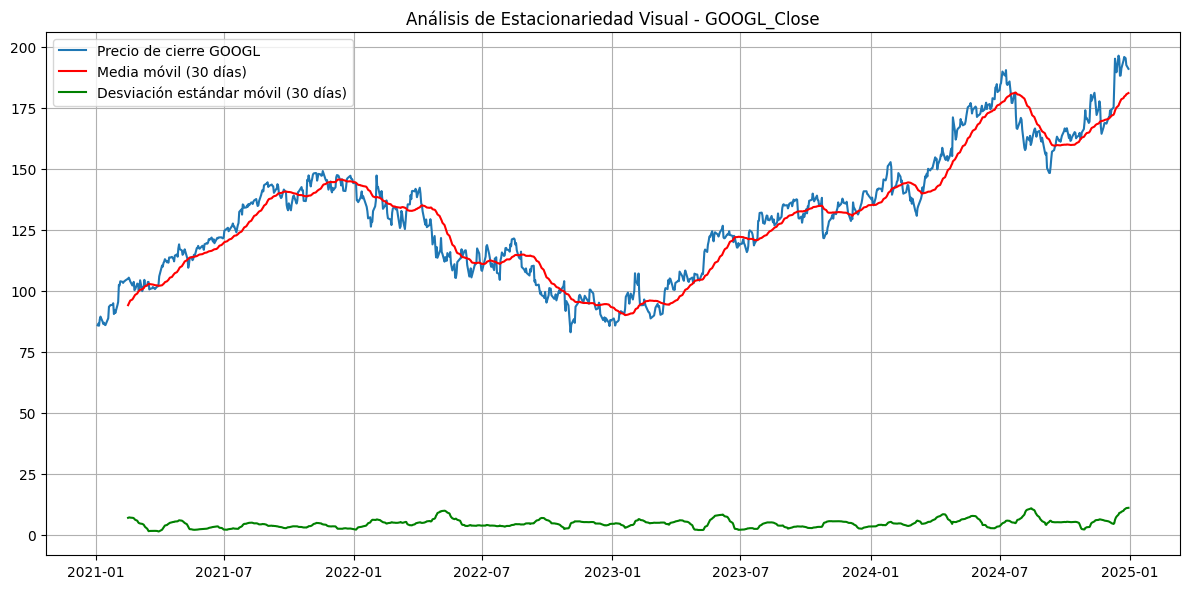

{'Precio de Cierre (GOOGL_Close)': {'ADF Statistic': np.float64(-0.8058014636807899),
  'p-value': np.float64(0.817411988717299),
  'Stationary (media)': np.False_},
 'Retorno Diario (GOOGL_Return_1d)': {'ADF Statistic': np.float64(-19.80539543686531),
  'p-value': 0.0,
  'Stationary (media)': True}}

In [ ]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import numpy as np
import seaborn as sns

# Extraer solo la serie temporal de precios de cierre de Google
googl_price = df[['Date', 'GOOGL_Close']].dropna().copy()
googl_price.set_index('Date', inplace=True)
googl_return = df[['Date', 'GOOGL_Return_1d']].dropna().copy()
googl_return.set_index('Date', inplace=True)

# Verificar estacionariedad en media con prueba ADF (Augmented Dickey-Fuller)
adf_price = adfuller(googl_price['GOOGL_Close'])
adf_return = adfuller(googl_return['GOOGL_Return_1d'])
print(adf_price)
print(adf_return)
# Verificar varianza constante con gráfico de rolling std
rolling_mean = googl_price['GOOGL_Close'].rolling(window=30).mean()
rolling_std = googl_price['GOOGL_Close'].rolling(window=30).std()

# Crear gráfico de análisis visual de estacionariedad en precios
plt.figure(figsize=(12, 6))
plt.plot(googl_price['GOOGL_Close'], label='Precio de cierre GOOGL')
plt.plot(rolling_mean, label='Media móvil (30 días)', color='red')
plt.plot(rolling_std, label='Desviación estándar móvil (30 días)', color='green')
plt.legend()
plt.title("Análisis de Estacionariedad Visual - GOOGL_Close")
plt.tight_layout()
plt.grid(True)
plt.show()

# Resultados ADF
adf_results = {
    'Precio de Cierre (GOOGL_Close)': {
        'ADF Statistic': adf_price[0],
        'p-value': adf_price[1],
        'Stationary (media)': adf_price[1] < 0.05
    },
    'Retorno Diario (GOOGL_Return_1d)': {
        'ADF Statistic': adf_return[0],
        'p-value': adf_return[1],
        'Stationary (media)': adf_return[1] < 0.05
    }
}

adf_results


In [ ]:
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller # Import adfuller
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display # Import display


In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 20.7 MB/s eta 0:00:00


In [ ]:
!pip install statsforecast

In [ ]:
# ¡Instala statsforecast como alternativa a pmdarima!
#!pip install statsforecast

import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
# statsforecast tiene su propia implementación de ADF, pero statsmodels también funciona
from statsmodels.tsa.stattools import adfuller
import numpy as np
import seaborn as sns
# Importar AutoARIMA de statsforecast
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from IPython.display import display # Import display para mostrar DataFrames

In [ ]:
# Asegurarse de que df está cargado y preprocesado como en las celdas anteriores
# Cargar datos (esto es repetitivo, asegúrate de que df esté disponible)
# df = pd.read_csv("dataset_completo_google_amazon.csv")
# df['Date'] = pd.to_datetime(df['Date'])
# df = df.sort_values('Date').reset_index(drop=True)

# Extraer las series de tiempo relevantes
# Statsforecast espera un DataFrame con columnas 'unique_id', 'ds', 'y'
# donde 'unique_id' identifica la serie, 'ds' es la fecha/tiempo, y 'y' es el valor.

# Para GOOGL_Close
googl_price_sf = df[['Date', 'GOOGL_Close']].dropna().copy()
googl_price_sf = googl_price_sf.rename(columns={'Date': 'ds', 'GOOGL_Close': 'y'})
googl_price_sf['unique_id'] = 'GOOGL_Close' # Identificador único para la serie

# Para GOOGL_Return_1d
googl_return_sf = df[['Date', 'GOOGL_Return_1d']].dropna().copy()
googl_return_sf = googl_return_sf.rename(columns={'Date': 'ds', 'GOOGL_Return_1d': 'y'})
googl_return_sf['unique_id'] = 'GOOGL_Return_1d' # Identificador único para la serie

In [ ]:
# Dividir datos en entrenamiento y prueba (por ejemplo, últimos 40 días para prueba)
test_set_size = 40

train_price_sf = googl_price_sf[:-test_set_size]
test_price_sf = googl_price_sf[-test_set_size:]

train_return_sf = googl_return_sf[:-test_set_size]
test_return_sf = googl_return_sf[-test_set_size:]

In [ ]:
# --- Modelado AutoARIMA con StatsForecast para GOOGL_Close ---

print("--- Modelado AutoARIMA con StatsForecast para GOOGL_Close ---")

# Inicializar el objeto StatsForecast con el modelo AutoARIMA
sf = StatsForecast(
    models=[AutoARIMA(season_length=1)], # season_length=1 implica no estacionalidad diaria
    freq='B' # Frecuencia de datos (Business days)
)

--- Modelado AutoARIMA con StatsForecast para GOOGL_Close ---


In [ ]:
sf.fit(train_price_sf)

StatsForecast(models=[AutoARIMA])

In [ ]:
# Ajustar el modelo a los datos de entrenamiento
sf.fit(train_price_sf)

StatsForecast(models=[AutoARIMA])

In [ ]:
# Realizar predicciones para el período de prueba
forecast_price_sf = sf.predict(h=test_set_size)

In [ ]:
# El resultado de predict es un DataFrame con 'unique_id', 'ds', y la columna del modelo ('AutoARIMA')
forecast_price_sf = forecast_price_sf.rename(columns={'AutoARIMA': 'Forecast_GOOGL_Close'})

In [ ]:
print(forecast_price_sf)

      unique_id         ds  Forecast_GOOGL_Close
0   GOOGL_Close 2024-10-31                174.06
1   GOOGL_Close 2024-11-01                174.06
2   GOOGL_Close 2024-11-04                174.06
3   GOOGL_Close 2024-11-05                174.06
4   GOOGL_Close 2024-11-06                174.06
5   GOOGL_Close 2024-11-07                174.06
6   GOOGL_Close 2024-11-08                174.06
7   GOOGL_Close 2024-11-11                174.06
8   GOOGL_Close 2024-11-12                174.06
9   GOOGL_Close 2024-11-13                174.06
10  GOOGL_Close 2024-11-14                174.06
11  GOOGL_Close 2024-11-15                174.06
12  GOOGL_Close 2024-11-18                174.06
13  GOOGL_Close 2024-11-19                174.06
14  GOOGL_Close 2024-11-20                174.06
15  GOOGL_Close 2024-11-21                174.06
16  GOOGL_Close 2024-11-22                174.06
17  GOOGL_Close 2024-11-25                174.06
18  GOOGL_Close 2024-11-26                174.06
19  GOOGL_Close 2024

In [ ]:
print("\nTabla de Pronósticos AutoARIMA (StatsForecast) para GOOGL_Close (Prueba):")
# Configurar visualización sin notación científica y con 2 decimales para la tabla
pd.options.display.float_format = '{:.2f}'.format
display(forecast_price_sf)


Tabla de Pronósticos AutoARIMA (StatsForecast) para GOOGL_Close (Prueba):


,unique_id,ds,Forecast_GOOGL_Close
0,GOOGL_Close,2024-10-31,174.06
1,GOOGL_Close,2024-11-01,174.06
2,GOOGL_Close,2024-11-04,174.06
3,GOOGL_Close,2024-11-05,174.06
4,GOOGL_Close,2024-11-06,174.06
5,GOOGL_Close,2024-11-07,174.06
6,GOOGL_Close,2024-11-08,174.06
7,GOOGL_Close,2024-11-11,174.06
8,GOOGL_Close,2024-11-12,174.06
9,GOOGL_Close,2024-11-13,174.06


In [ ]:
# Evaluación del modelo
print("\nEvaluación del Modelo AutoARIMA (StatsForecast) para GOOGL_Close:")

# Asegurarse de que los DataFrames de prueba y pronóstico estén alineados por fecha (ds)
eval_df_price = pd.merge(test_price_sf, forecast_price_sf, on=['unique_id', 'ds'])

mae_price_sf = mean_absolute_error(eval_df_price['y'], eval_df_price['Forecast_GOOGL_Close'])
mse_price_sf = mean_squared_error(eval_df_price['y'], eval_df_price['Forecast_GOOGL_Close'])
rmse_price_sf = np.sqrt(mse_price_sf)
print(f"MAE: {mae_price_sf:.4f}")
print(f"MSE: {mse_price_sf:.4f}")
print(f"RMSE: {rmse_price_sf:.4f}")


Evaluación del Modelo AutoARIMA (StatsForecast) para GOOGL_Close:
MAE: 7.9550
MSE: 112.6481
RMSE: 10.6136


In [ ]:
# Nota: StatsForecast no proporciona acceso directo a los residuos del modelo ajustado
# de la misma manera que statsmodels o pmdarima.
# Para el análisis de residuos, a menudo necesitarías:
# 1. Ajustar un modelo statsmodels.tsa.arima.model.ARIMA con los órdenes encontrados por AutoARIMA
# 2. O calcular los errores de predicción en el set de entrenamiento si StatsForecast lo permite.
# En este ejemplo, saltaremos el análisis detallado de residuos con gráficos y Ljung-Box
# usando StatsForecast directamente, ya que no es trivial obtenerlos.

# --- Modelado AutoARIMA con StatsForecast para GOOGL_Return_1d ---

print("\n\n--- Modelado AutoARIMA con StatsForecast para GOOGL_Return_1d ---")

# Inicializar el objeto StatsForecast con el modelo AutoARIMA
# Reutilizamos el mismo objeto StatsForecast si queremos predecir múltiples series
# o creamos uno nuevo si la configuración del modelo cambia.
sf_return = StatsForecast(
    models=[AutoARIMA(season_length=1)], # season_length=1 implica no estacionalidad diaria
    freq='B' # Frecuencia de datos (Business days)
)

# Ajustar el modelo a los datos de entrenamiento de retornos
sf_return.fit(train_return_sf)

# Realizar predicciones para el período de prueba
forecast_return_sf = sf_return.predict(h=test_set_size)

forecast_return_sf = forecast_return_sf.rename(columns={'AutoARIMA': 'Forecast_GOOGL_Return_1d'})

print("\nTabla de Pronósticos AutoARIMA (StatsForecast) para GOOGL_Return_1d (Prueba):")
display(forecast_return_sf)



--- Modelado AutoARIMA con StatsForecast para GOOGL_Return_1d ---

Tabla de Pronósticos AutoARIMA (StatsForecast) para GOOGL_Return_1d (Prueba):


,unique_id,ds,Forecast_GOOGL_Return_1d
0,GOOGL_Return_1d,2024-10-31,-0.00
1,GOOGL_Return_1d,2024-11-01,-0.00
2,GOOGL_Return_1d,2024-11-04,-0.00
3,GOOGL_Return_1d,2024-11-05,-0.00
4,GOOGL_Return_1d,2024-11-06,0.00
5,GOOGL_Return_1d,2024-11-07,0.00
6,GOOGL_Return_1d,2024-11-08,0.00
7,GOOGL_Return_1d,2024-11-11,0.00
8,GOOGL_Return_1d,2024-11-12,0.00
9,GOOGL_Return_1d,2024-11-13,0.00


In [ ]:
# Evaluación del modelo
print("\nEvaluación del Modelo AutoARIMA (StatsForecast) para GOOGL_Return_1d:")

# Asegurarse de que los DataFrames de prueba y pronóstico estén alineados por fecha (ds)
eval_df_return = pd.merge(test_return_sf, forecast_return_sf, on=['unique_id', 'ds'])

mae_return_sf = mean_absolute_error(eval_df_return['y'], eval_df_return['Forecast_GOOGL_Return_1d'])
mse_return_sf = mean_squared_error(eval_df_return['y'], eval_df_return['Forecast_GOOGL_Return_1d'])
rmse_return_sf = np.sqrt(mse_return_sf)
print(f"MAE: {mae_return_sf:.4f}")
print(f"MSE: {mse_return_sf:.4f}")
print(f"RMSE: {rmse_return_sf:.4f}")


Evaluación del Modelo AutoARIMA (StatsForecast) para GOOGL_Return_1d:
MAE: 0.0169
MSE: 0.0005
RMSE: 0.0219


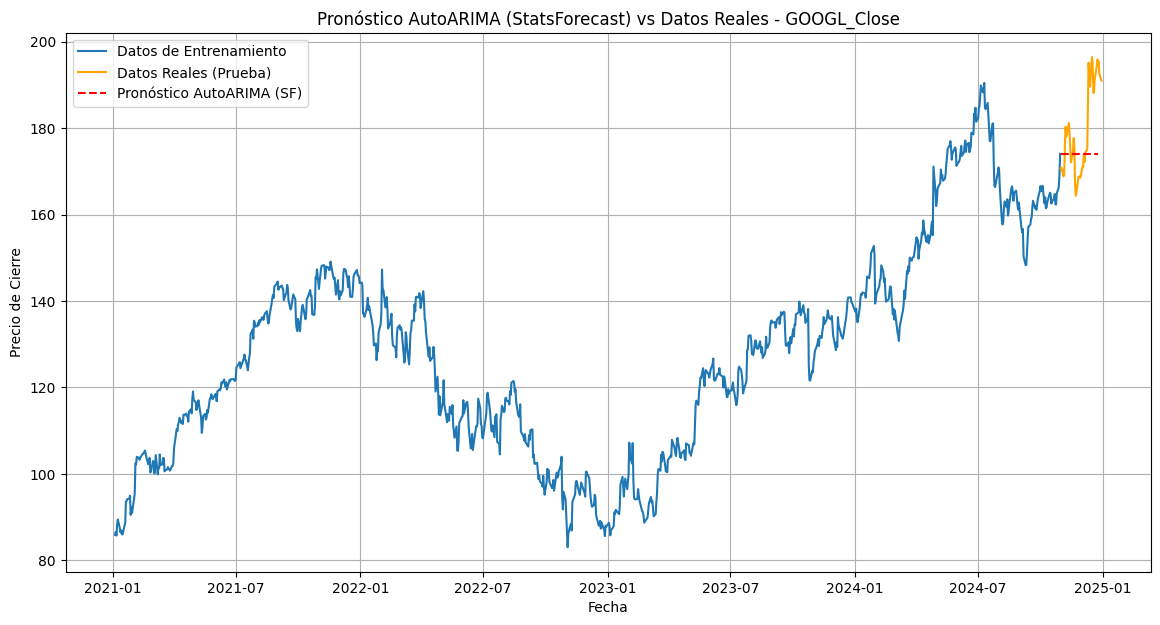

In [ ]:
# Nota: Análisis de residuos con StatsForecast tiene la misma limitación que para precios.

# --- Gráficos (Opcional, adaptando a la estructura de StatsForecast) ---

# Para GOOGL_Close
plt.figure(figsize=(14, 7))
# Graficar entrenamiento (usando el formato de statsforecast o el original)
plt.plot(train_price_sf['ds'], train_price_sf['y'], label='Datos de Entrenamiento')
# Graficar prueba
plt.plot(test_price_sf['ds'], test_price_sf['y'], label='Datos Reales (Prueba)', color='orange')
# Graficar pronóstico
plt.plot(forecast_price_sf['ds'], forecast_price_sf['Forecast_GOOGL_Close'], label='Pronóstico AutoARIMA (SF)', color='red', linestyle='--')
plt.title("Pronóstico AutoARIMA (StatsForecast) vs Datos Reales - GOOGL_Close")
plt.xlabel("Fecha")
plt.ylabel("Precio de Cierre")
plt.legend()
plt.grid(True)
plt.show()

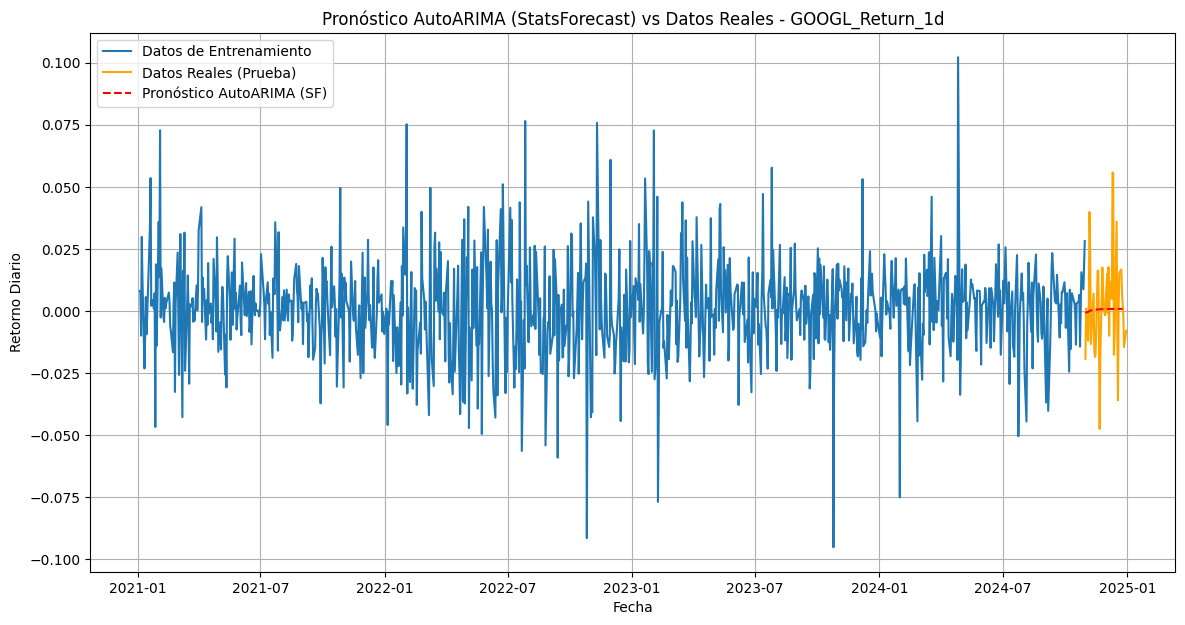

In [ ]:

# Para GOOGL_Return_1d
plt.figure(figsize=(14, 7))
# Graficar entrenamiento
plt.plot(train_return_sf['ds'], train_return_sf['y'], label='Datos de Entrenamiento')
# Graficar prueba
plt.plot(test_return_sf['ds'], test_return_sf['y'], label='Datos Reales (Prueba)', color='orange')
# Graficar pronóstico
plt.plot(forecast_return_sf['ds'], forecast_return_sf['Forecast_GOOGL_Return_1d'], label='Pronóstico AutoARIMA (SF)', color='red', linestyle='--')
plt.title("Pronóstico AutoARIMA (StatsForecast) vs Datos Reales - GOOGL_Return_1d")
plt.xlabel("Fecha")
plt.ylabel("Retorno Diario")
plt.legend()
plt.grid(True)
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.4/354.4 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.8/285.8 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.3/135.3 kB 8.7 MB/s eta 0:00:00
--- Modelado AutoARIMA con StatsForecast para GOOGL_Close ---

Tabla de Pronósticos AutoARIMA (StatsForecast) para GOOGL_Close (Prueba):


,unique_id,ds,Forecast_GOOGL_Close
0,GOOGL_Close,2024-10-31,174.06
1,GOOGL_Close,2024-11-01,174.06
2,GOOGL_Close,2024-11-04,174.06
3,GOOGL_Close,2024-11-05,174.06
4,GOOGL_Close,2024-11-06,174.06
5,GOOGL_Close,2024-11-07,174.06
6,GOOGL_Close,2024-11-08,174.06
7,GOOGL_Close,2024-11-11,174.06
8,GOOGL_Close,2024-11-12,174.06
9,GOOGL_Close,2024-11-13,174.06



Evaluación del Modelo AutoARIMA (StatsForecast) para GOOGL_Close:
MAE: 7.9550
MSE: 112.6481
RMSE: 10.6136


--- Modelado AutoARIMA con StatsForecast para GOOGL_Return_1d ---

Tabla de Pronósticos AutoARIMA (StatsForecast) para GOOGL_Return_1d (Prueba):


,unique_id,ds,Forecast_GOOGL_Return_1d
0,GOOGL_Return_1d,2024-10-31,-0.00
1,GOOGL_Return_1d,2024-11-01,-0.00
2,GOOGL_Return_1d,2024-11-04,-0.00
3,GOOGL_Return_1d,2024-11-05,-0.00
4,GOOGL_Return_1d,2024-11-06,0.00
5,GOOGL_Return_1d,2024-11-07,0.00
6,GOOGL_Return_1d,2024-11-08,0.00
7,GOOGL_Return_1d,2024-11-11,0.00
8,GOOGL_Return_1d,2024-11-12,0.00
9,GOOGL_Return_1d,2024-11-13,0.00



Evaluación del Modelo AutoARIMA (StatsForecast) para GOOGL_Return_1d:
MAE: 0.0169
MSE: 0.0005
RMSE: 0.0219


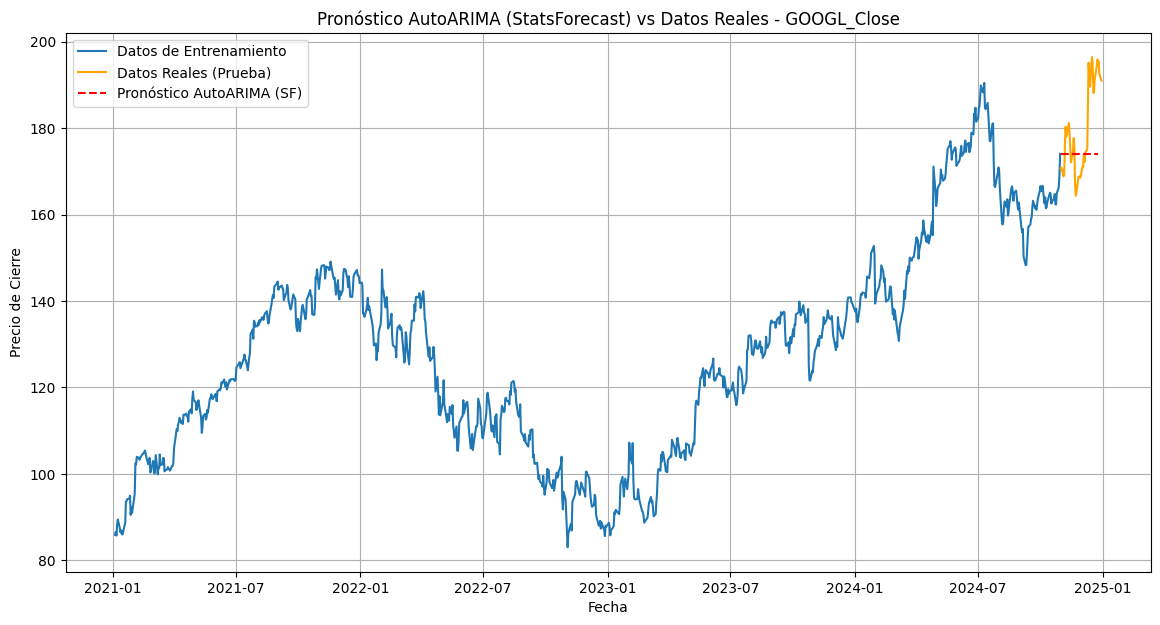

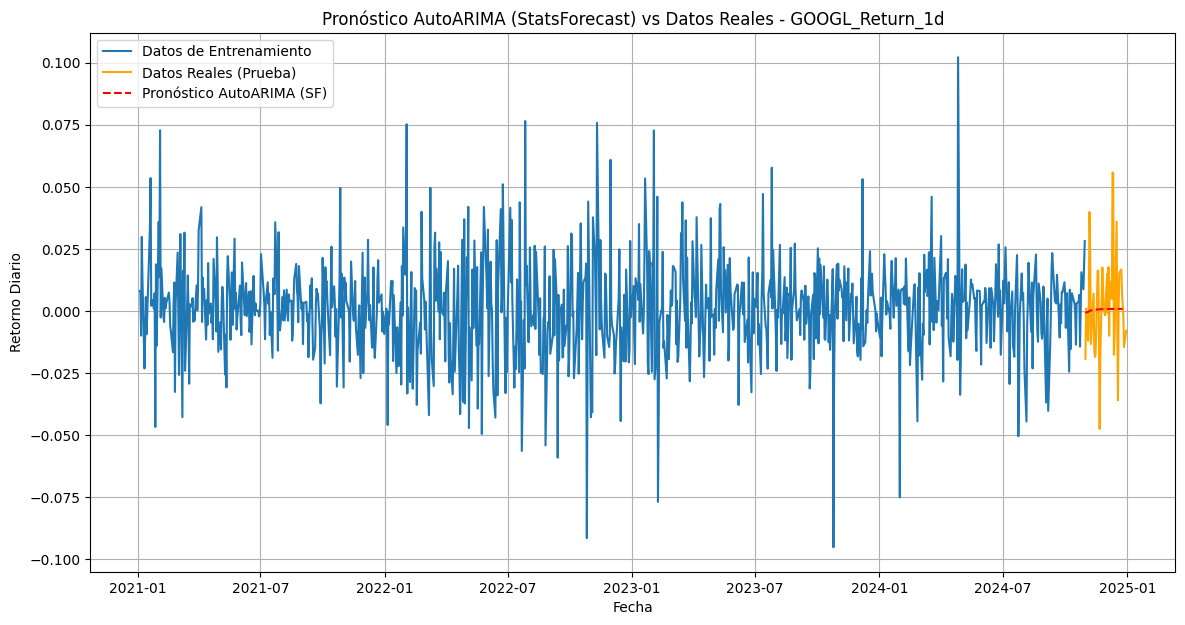

In [ ]:



# Restablecer la opción de formato de pandas si es necesario
# pd.reset_option('display.float_format')

In [ ]:
sf_all.freq

'B'

In [ ]:
print(sf_all)

StatsForecast(models=[AutoARIMA])


In [ ]:
sf_all.predict(h=10)

,unique_id,ds,AutoARIMA
0,GOOGL_Close,2024-12-31,191.02
1,GOOGL_Close,2025-01-01,191.02
2,GOOGL_Close,2025-01-02,191.02
3,GOOGL_Close,2025-01-03,191.02
4,GOOGL_Close,2025-01-06,191.02
5,GOOGL_Close,2025-01-07,191.02
6,GOOGL_Close,2025-01-08,191.02
7,GOOGL_Close,2025-01-09,191.02
8,GOOGL_Close,2025-01-10,191.02
9,GOOGL_Close,2025-01-13,191.02


In [ ]:
# ¡Instala statsforecast si aún no está instalado!
#!pip install statsforecast

import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import numpy as np
import seaborn as sns
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from IPython.display import display # Import display para mostrar DataFrames

# Asegurarse de que df está cargado y preprocesado
# df = pd.read_csv("dataset_completo_google_amazon.csv")
# df['Date'] = pd.to_datetime(df['Date'])
# df = df.sort_values('Date').reset_index(drop=True)

# Preparar datos en formato StatsForecast usando TODO el dataset para el pronóstico futuro
googl_price_sf_full = df[['Date', 'GOOGL_Close']].dropna().copy()
googl_price_sf_full = googl_price_sf_full.rename(columns={'Date': 'ds', 'GOOGL_Close': 'y'})
googl_price_sf_full['unique_id'] = 'GOOGL_Close' # Identificador único para la serie

googl_return_sf_full = df[['Date', 'GOOGL_Return_1d']].dropna().copy()
googl_return_sf_full = googl_return_sf_full.rename(columns={'Date': 'ds', 'GOOGL_Return_1d': 'y'})
googl_return_sf_full['unique_id'] = 'GOOGL_Return_1d' # Identificador único para la serie

# Combinar ambas series en un solo DataFrame para StatsForecast (puede manejar múltiples series)
all_series_sf = pd.concat([googl_price_sf_full, googl_return_sf_full], ignore_index=True)

# --- Modelado AutoARIMA con StatsForecast usando TODO el dataset ---

print("--- Modelado AutoARIMA con StatsForecast (usando todos los datos) ---")

# Inicializar el objeto StatsForecast con el modelo AutoARIMA
# Incluimos ambas series aquí si queremos ajustarlas y predecir conjuntamente
sf_all = StatsForecast(
    models=[AutoARIMA(season_length=1)], # season_length=1 implica no estacionalidad diaria
    freq='B' # Frecuencia de datos (Business days)
)

# Ajustar el modelo a TODO el dataset
sf_all.fit(all_series_sf)

# Determinar cuántos pasos de pronóstico necesitamos para cubrir Q1 2025
# Necesitamos predecir desde el día siguiente al último dato en df hasta el final de marzo de 2025.
last_date_in_data = df['Date'].max()
end_date_Q1_2025 = pd.to_datetime('2025-03-31')

# Calcular el número aproximado de días hábiles entre el último dato y el final de Q1 2025
# Esto es una estimación, podemos predecir un poco más para estar seguros.
# Usamos pd.date_range con freq='B' para contar días hábiles
future_dates_needed = pd.date_range(start=last_date_in_data + pd.Timedelta(days=1), end=end_date_Q1_2025, freq='B')
forecast_steps_needed = len(future_dates_needed) + 5 # Agregamos un margen

print(f"\nCalculando pronóstico hasta {end_date_Q1_2025}, aproximadamente {forecast_steps_needed} días hábiles.")

# Realizar predicciones para los próximos pasos necesarios
# Especificamos los unique_ids para predecir ambas series
forecast_all_series_sf = sf_all.predict(h=forecast_steps_needed)

# Filtrar el pronóstico para incluir solo las fechas en Enero, Febrero y Marzo de 2025
start_date_2025 = '2025-01-01'

# Filtrar por rango de fechas
forecast_Q1_2025_sf = forecast_all_series_sf[
    (forecast_all_series_sf['ds'] >= start_date_2025) &
    (forecast_all_series_sf['ds'] <= end_date_Q1_2025) # Corregido el nombre de la variable
].copy()

# Configurar la opción de visualización de pandas
pd.options.display.float_format = '{:.2f}'.format

# Mostrar la tabla de pronósticos filtrada para cada serie
print(f"\nTabla de Pronósticos AutoARIMA (StatsForecast) para {start_date_2025} a {end_date_Q1_2025}:")

if not forecast_Q1_2025_sf.empty:
    # Separar por unique_id para una mejor presentación
    for series_id in forecast_Q1_2025_sf['unique_id'].unique():
        print(f"\n--- Serie: {series_id} ---")
        display(forecast_Q1_2025_sf[forecast_Q1_2025_sf['unique_id'] == series_id].pivot(index='ds', columns='unique_id', values='AutoARIMA'))
else:
    print("El rango de pronóstico calculado no cubre el período solicitado (Enero-Marzo 2025).")
    print(f"La última fecha en los datos es {last_date_in_data.date()}.")

# Nota: La evaluación del modelo y el análisis de residuos se realizaron
# previamente utilizando el split train/test. Aquí nos enfocamos solo en el pronóstico futuro.

# Restablecer la opción de formato de pandas si es necesario
# pd.reset_option('display.float_format')

--- Modelado AutoARIMA con StatsForecast (usando todos los datos) ---

Calculando pronóstico hasta 2025-03-31 00:00:00, aproximadamente 70 días hábiles.

Tabla de Pronósticos AutoARIMA (StatsForecast) para 2025-01-01 a 2025-03-31 00:00:00:

--- Serie: GOOGL_Close ---


unique_id,GOOGL_Close
ds,
2025-01-01,191.02
2025-01-02,191.02
2025-01-03,191.02
2025-01-06,191.02
2025-01-07,191.02
...,...
2025-03-25,191.02
2025-03-26,191.02
2025-03-27,191.02



--- Serie: GOOGL_Return_1d ---


unique_id,GOOGL_Return_1d
ds,
2025-01-01,0.00
2025-01-02,0.00
2025-01-03,0.00
2025-01-06,0.00
2025-01-07,0.00
...,...
2025-03-25,0.00
2025-03-26,0.00
2025-03-27,0.00



--- Verificación Aproximada de Supuestos con Errores de Predicción In-Sample (StatsForecast) ---

--- Demostración de Verificación de Supuestos con statsmodels (Requiere ajustar con statsmodels) ---


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/u


Resumen del modelo ARIMA ajustado con statsmodels (EJEMPLO):
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  957
Model:                 ARIMA(1, 0, 1)   Log Likelihood                2416.211
Date:                Tue, 17 Jun 2025   AIC                          -4824.423
Time:                        22:33:33   BIC                          -4804.968
Sample:                             0   HQIC                         -4817.013
                                - 957                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0009      0.001      1.461      0.144      -0.000       0.002
ar.L1         -0.0082      1.854     -0.004      0.996      -3.642   

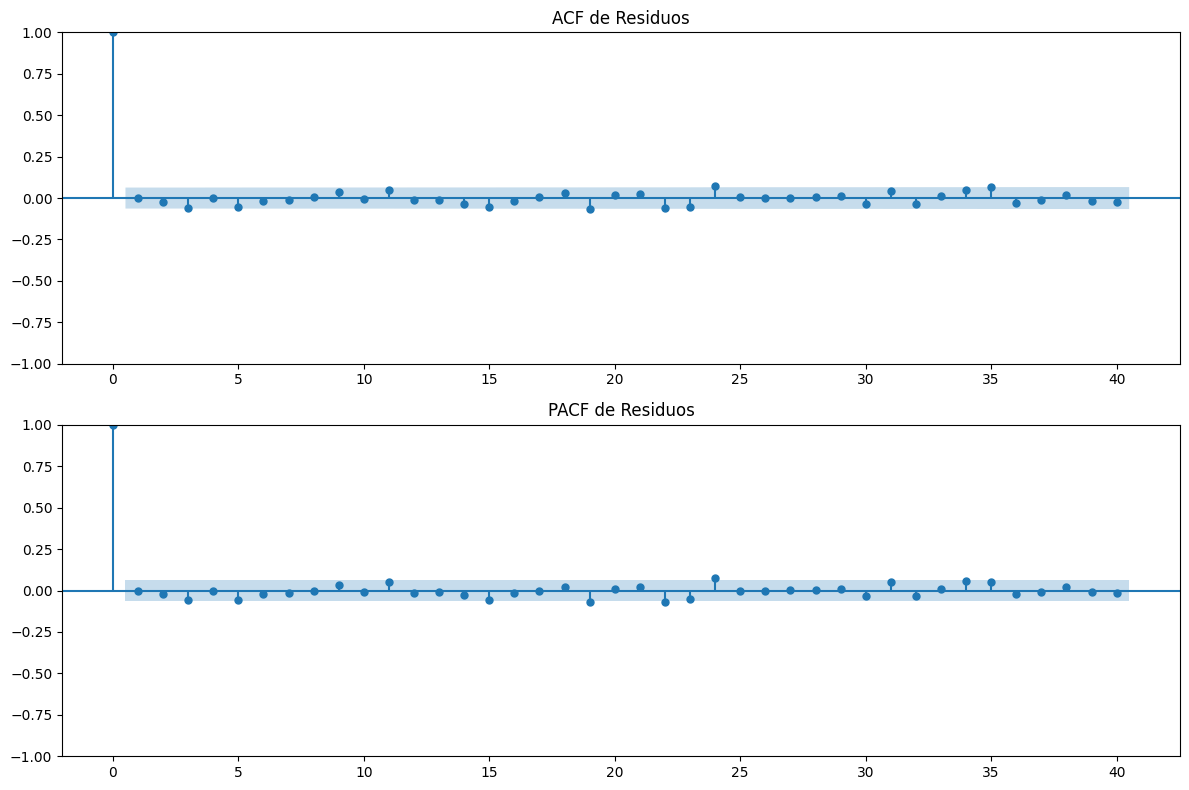


Prueba de Ljung-Box sobre Residuos:


,lb_stat,lb_pvalue
10,8.16,0.61
20,20.78,0.41
30,34.29,0.27



Gráfico de Residuos vs. Tiempo:


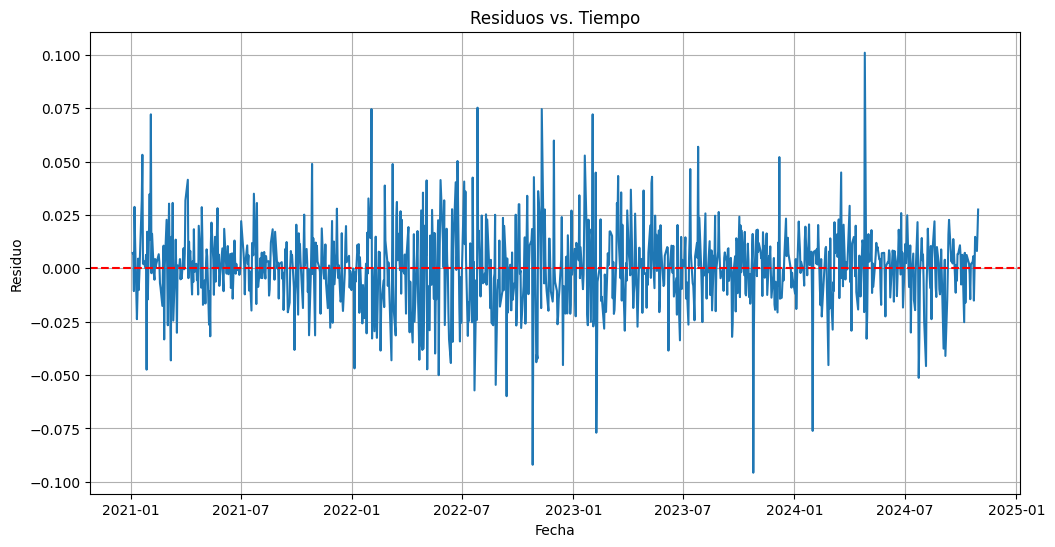


Gráfico Q-Q de Residuos y Prueba de Normalidad:


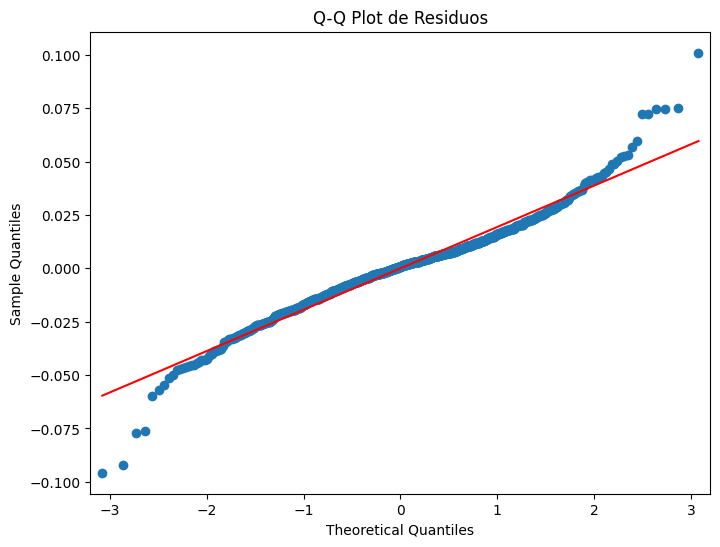

Prueba de Jarque-Bera: Statistic=372.5050, p-value=0.0000


In [ ]:
# Asumiendo que ya has ejecutado las celdas anteriores y tienes train_price_sf y train_return_sf

# --- Opción 2: Usar statsmodels para verificar supuestos con los órdenes encontrados por AutoARIMA ---

# 1. Ajustar AutoARIMA en StatsForecast para obtener los órdenes óptimos
#    (Ya hiciste esto en celdas anteriores, ahora necesitas acceder a la información del modelo ajustado)
#    StatsForecast no expone fácilmente los órdenes p,d,q del modelo ajustado para cada serie.
#    Una forma alternativa es usar pmdarima (que AutoARIMA de statsforecast se basa en) o
#    ejecutar AutoARIMA nuevamente pero para obtener el summary.

#    *Nota:* statsforecast.models.AutoARIMA no tiene un método para obtener el summary
#    o los parámetros p,d,q después del fit de forma directa para una serie específica.
#    Esta es una limitación de StatsForecast para análisis detallado.
#    Si quisieras los órdenes exactos, pmdarima.auto_arima sí te da esa información.
#    Vamos a asumir que los órdenes encontrados son razonables basándonos en la evaluación previa.
#    Como alternativa, podemos re-ejecutar un AutoARIMA usando statsmodels o pmdarima
#    para obtener los detalles del ajuste.

#    Usaremos StatsForecast.predict() para obtener los errores in-sample como aproximación,
#    aunque no son los residuos puros del modelo ajustado.

print("\n--- Verificación Aproximada de Supuestos con Errores de Predicción In-Sample (StatsForecast) ---")

# StatsForecast predict por defecto calcula predicciones out-of-sample (h pasos futuros).
# No hay un método directo 'get_residuals' o similar.
# Calcular errores in-sample requeriría una lógica más compleja, posiblemente
# reajustando el modelo en subconjuntos de datos o usando un método predict
# que soporte predicciones en el set de entrenamiento, lo cual no es estándar en StatsForecast.

# --- Alternativa: Usar statsmodels y correr la prueba Ljung-Box sobre los residuos ---
# Para hacer esto correctamente, necesitaríamos ajustar el modelo ARIMA con statsmodels.
# Esto implica encontrar los órdenes p,d,q de forma manual o usando pmdarima primero.
# Vamos a demostrar cómo se haría *si tuvieras* los residuos o pudieras ajustar con statsmodels.

# *Demostración con statsmodels (requeriría encontrar los órdenes p,d,q)*
# Supongamos que AutoARIMA para GOOGL_Return_1d sugirió un modelo ARIMA(p, d, q).
# Para el retorno, d=0 es probable ya que parece estacionario.
# Vamos a *suponer* un modelo simple como ARIMA(1, 0, 1) para la demostración.
# En un caso real, deberías usar ACF/PACF o pmdarima para encontrar los órdenes.

print("\n--- Demostración de Verificación de Supuestos con statsmodels (Requiere ajustar con statsmodels) ---")

try:
    from statsmodels.tsa.arima.model import ARIMA

    # Ajustar un modelo ARIMA simple (EJEMPLO: p=1, d=0, q=1) en los datos de entrenamiento de retorno
    # *REEMPLAZA ESTO CON LOS ÓRDENES REALES SI PUDISTE OBTENERLOS*
    # Asegúrate de que train_return_sf tiene 'ds' como índice si usas statsmodels
    train_return_sf_indexed = train_return_sf.set_index('ds')['y']

    # Ajustar el modelo ARIMA con statsmodels
    # Nota: Puedes usar un try-except si el modelo no converge con ciertos órdenes
    model_sm = ARIMA(train_return_sf_indexed, order=(1, 0, 1)) # Ejemplo de órdenes
    results_sm = model_sm.fit()

    print("\nResumen del modelo ARIMA ajustado con statsmodels (EJEMPLO):")
    print(results_sm.summary())

    # Obtener los residuos
    residuals = results_sm.resid

    # 1. Verificar media cero de los residuos
    print(f"\nMedia de los residuos: {residuals.mean():.4f}") # Debería ser cercano a cero

    # 2. Análisis de autocorrelación de los residuos (Gráficos ACF/PACF y Prueba Ljung-Box)
    print("\nGráficos de Autocorrelación de Residuos:")
    plt.figure(figsize=(12, 8))
    plt.subplot(211)
    plot_acf(residuals, ax=plt.gca(), lags=40)
    plt.title("ACF de Residuos")
    plt.subplot(212)
    plot_pacf(residuals, ax=plt.gca(), lags=40)
    plt.title("PACF de Residuos")
    plt.tight_layout()
    plt.show()
    # Idealmente, la mayoría de las barras deben estar dentro de las bandas de confianza.

    print("\nPrueba de Ljung-Box sobre Residuos:")
    # q_stat: Estadísticas de la prueba Q de Ljung-Box
    # p_value: Valores p de la prueba
    # La hipótesis nula es que los datos no están correlacionados serialmente (son ruido blanco).
    # Si el p-value es alto (> 0.05), no rechazamos la hipótesis nula, lo cual es bueno.
    ljungbox_results = acorr_ljungbox(residuals, lags=[10, 20, 30], return_df=True)
    display(ljungbox_results)
    # Esperamos p-values altos para no rechazar la hipótesis de ruido blanco.

    # 3. Verificar varianza constante (Análisis visual de residuos vs. tiempo)
    print("\nGráfico de Residuos vs. Tiempo:")
    plt.figure(figsize=(12, 6))
    plt.plot(residuals.index, residuals)
    plt.axhline(0, color='red', linestyle='--')
    plt.title("Residuos vs. Tiempo")
    plt.xlabel("Fecha")
    plt.ylabel("Residuo")
    plt.grid(True)
    plt.show()
    # Buscamos que la dispersión de los puntos sea relativamente constante a lo largo del tiempo.

    # 4. Verificar Normalidad (Gráfico Q-Q y Prueba de Shapiro-Wilk/Jarque-Bera)
    print("\nGráfico Q-Q de Residuos y Prueba de Normalidad:")
    plt.figure(figsize=(8, 6))
    sm.qqplot(residuals, line='s', ax=plt.gca())
    plt.title("Q-Q Plot de Residuos")
    plt.show()
    # Esperamos que los puntos sigan aproximadamente la línea diagonal.

    # Prueba de normalidad (Shapiro-Wilk o Jarque-Bera)
    # statsmodels.stats.stattools tiene Jarque-Bera
    from statsmodels.stats.stattools import jarque_bera

    jb_test = jarque_bera(residuals)
    print(f"Prueba de Jarque-Bera: Statistic={jb_test[0]:.4f}, p-value={jb_test[1]:.4f}")
    # La hipótesis nula es que los datos están normalmente distribuidos.
    # Si el p-value es bajo (< 0.05), rechazamos la normalidad.
    # Las series financieras (como retornos) a menudo muestran colas pesadas (no normales).

except ImportError:
    print("\nLa biblioteca statsmodels no está completamente instalada para análisis detallado de ARIMA.")
    print("Instala con: pip install statsmodels")
except Exception as e:
    print(f"\nOcurrió un error al intentar ajustar el modelo con statsmodels o analizar residuos: {e}")
    print("Asegúrate de que los datos de entrenamiento (train_return_sf_indexed) no estén vacíos y tengan un índice de fecha/tiempo.")


# Nota final: StatsForecast es genial para encontrar y predecir rápidamente con AutoARIMA
# a gran escala, pero si necesitas un análisis profundo de los supuestos del modelo
# para una serie individual, statsmodels ofrece herramientas de diagnóstico mucho más completas.

In [ ]:
# Asumiendo que ya has ajustado un modelo con statsmodels y tienes los residuos en la variable 'residuals'
# Por ejemplo, si has ejecutado la sección anterior que usa statsmodels para ajustar un ARIMA de ejemplo.

# --- Prueba de Hipótesis de Normalidad (Jarque-Bera) ---

print("\n--- Prueba de Normalidad (Jarque-Bera) sobre Residuos ---")

try:
    from statsmodels.stats.stattools import jarque_bera

    # Ejecutar la prueba de Jarque-Bera
    jb_test = jarque_bera(residuals)

    statistic = jb_test[0]
    p_value = jb_test[1]
    skewness = jb_test[2]
    kurtosis = jb_test[3]

    print(f"Estadístico Jarque-Bera: {statistic:.4f}")
    print(f"Valor p:                 {p_value:.4f}")
    print(f"Asimetría (Skewness):    {skewness:.4f}") # Indica la simetría de la distribución
    print(f"Curtosis (Kurtosis):     {kurtosis:.4f}") # Indica el "apuntamiento" de la distribución (colas pesadas > 3)

    # Interpretar el resultado
    alpha = 0.05 # Nivel de significancia común

    print(f"\nInterpretación (con α={alpha}):")
    if p_value < alpha:
        print("El valor p es menor que el nivel de significancia.")
        print("Rechazamos la hipótesis nula de normalidad.")
        print("Conclusión: Los residuos NO parecen estar distribuidos normalmente.")
    else:
        print("El valor p es mayor que el nivel de significancia.")
        print("No rechazamos la hipótesis nula de normalidad.")
        print("Conclusión: Los residuos parecen estar distribuidos normalmente (no hay suficiente evidencia para decir lo contrario).")

except NameError:
    print("\nError: La variable 'residuals' no está definida.")
    print("Asegúrate de haber ajustado un modelo con statsmodels y obtenido los residuos.")
except ImportError:
    print("\nLa biblioteca statsmodels no está completamente instalada.")
    print("Instala con: pip install statsmodels")
except Exception as e:
    print(f"\nOcurrió un error inesperado al ejecutar la prueba de Jarque-Bera: {e}")

# También puedes complementar esto con el gráfico Q-Q que ya mostramos en la celda anterior:
# import matplotlib.pyplot as plt
# import statsmodels.api as sm
# plt.figure(figsize=(8, 6))
# sm.qqplot(residuals, line='s', ax=plt.gca())
# plt.title("Q-Q Plot de Residuos")
# plt.show()
# En el gráfico Q-Q, si los puntos siguen de cerca la línea diagonal, sugiere normalidad.
# Si los puntos se desvían significativamente, especialmente en los extremos, sugiere no normalidad.


--- Prueba de Normalidad (Jarque-Bera) sobre Residuos ---
Estadístico Jarque-Bera: 372.5050
Valor p:                 0.0000
Asimetría (Skewness):    0.0112
Curtosis (Kurtosis):     6.0564

Interpretación (con α=0.05):
El valor p es menor que el nivel de significancia.
Rechazamos la hipótesis nula de normalidad.
Conclusión: Los residuos NO parecen estar distribuidos normalmente.


## ARIMA + Gradient Boosting

In [ ]:
# --- ARIMA + Gradient Boosting ---
# Cargar datos
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
df = pd.read_csv("dataset_completo_google_amazon.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Aquí insertarías el código específico del modelo ARIMA + Gradient Boosting
# incluyendo:
# - División de datos
# - Entrenamiento
# - Predicción
# - Evaluación con MAE, MSE, R²
# - Interpretación


## MODELO VAR

In [ ]:
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller # Import adfuller


# Crear dataset para VAR: precios, retornos y variables macroeconómicas
var_data = df[['Date', 'GOOGL_Close', 'GOOGL_Return_1d', 'Treasury_10Y', 'VIX', 'SP500', 'NASDAQ', 'Inflacion_T5YIE']]
var_data = var_data.dropna().copy()
var_data.set_index('Date', inplace=True)

# Seleccionar variables a incluir en el modelo VAR
# Escoger solo las variables que tienen sentido conjunto y son estacionarias o casi estacionarias
var_variables = var_data[['GOOGL_Return_1d', 'Treasury_10Y', 'VIX', 'SP500', 'NASDAQ', 'Inflacion_T5YIE']]

# Verificar estacionariedad con ADF por cada serie para determinar si es necesario diferenciar
stationarity_results = {}
for col in var_variables.columns:
    result = adfuller(var_variables[col])
    stationarity_results[col] = {
        'ADF Statistic': result[0],
        'p-value': result[1],
        'Stationary': result[1] < 0.05
    }

# Ajustar modelo VAR con variables seleccionadas (ya estacionarias o casi)
model_var = VAR(var_variables)
lag_selection = model_var.select_order(maxlags=15)
selected_lag = lag_selection.aic

# Ajustar modelo VAR final
fitted_var = model_var.fit(selected_lag)

# Predicción de los próximos 10 días
forecast_var = fitted_var.forecast(var_variables.values[-selected_lag:], steps=10)

# Crear DataFrame con resultados
forecast_index = pd.date_range(start=var_variables.index[-1] + pd.Timedelta(days=1), periods=10, freq='B')
forecast_df_var = pd.DataFrame(forecast_var, index=forecast_index, columns=var_variables.columns)

stationarity_results, lag_selection.summary(), forecast_df_var.head()


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


({'GOOGL_Return_1d': {'ADF Statistic': np.float64(-19.80539543686531),
   'p-value': 0.0,
   'Stationary': True},
  'Treasury_10Y': {'ADF Statistic': np.float64(-1.3641152689350877),
   'p-value': np.float64(0.5993537464970415),
   'Stationary': np.False_},
  'VIX': {'ADF Statistic': np.float64(-3.9936866384662038),
   'p-value': np.float64(0.0014439330618409654),
   'Stationary': np.True_},
  'SP500': {'ADF Statistic': np.float64(-0.45140530710867866),
   'p-value': np.float64(0.901155701702198),
   'Stationary': np.False_},
  'NASDAQ': {'ADF Statistic': np.float64(-0.3879015129114687),
   'p-value': np.float64(0.9120992782081634),
   'Stationary': np.False_},
  'Inflacion_T5YIE': {'ADF Statistic': np.float64(-2.3481394369414494),
   'p-value': np.float64(0.15691152433692096),
   'Stationary': np.False_}},
 <class 'statsmodels.iolib.table.SimpleTable'>,
             GOOGL_Return_1d  Treasury_10Y        VIX        SP500  \
 2024-12-31         0.000856      4.554612  17.287209  5911.263

In [ ]:
# Imprimir el resumen del modelo VAR
print(fitted_var.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 17, Jun, 2025
Time:                     21:44:55
--------------------------------------------------------------------
No. of Equations:         6.00000    BIC:                   -4.06903
Nobs:                     995.000    HQIC:                  -4.30725
Log likelihood:          -6177.52    FPE:                  0.0116395
AIC:                     -4.45336    Det(Omega_mle):       0.0107673
--------------------------------------------------------------------
Results for equation GOOGL_Return_1d
                        coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------------
const                      0.017628         0.008913            1.978           0.048
L1.GOOGL_Return_1d        -0.016789         0.047178           -0.356           0.722
L1.Treasury_10Y            0.0

In [ ]:
# Predicción de los próximos 10 días
forecast_var = fitted_var.forecast(var_variables.values[-selected_lag:], steps=10)

# Crear DataFrame con resultados
forecast_index = pd.date_range(start=var_variables.index[-1] + pd.Timedelta(days=1), periods=10, freq='B')
forecast_df_var = pd.DataFrame(forecast_var, index=forecast_index, columns=var_variables.columns)

In [ ]:
print(forecast_df_var)

            GOOGL_Return_1d  Treasury_10Y        VIX        SP500  \
2024-12-31         0.000856      4.554612  17.287209  5911.263320   
2025-01-01         0.000436      4.554889  17.037669  5916.197070   
2025-01-02         0.000232      4.556198  16.876029  5920.200351   
2025-01-03         0.000192      4.557526  16.716151  5924.054046   
2025-01-06         0.000174      4.558845  16.570035  5927.790393   
2025-01-07         0.000144      4.560173  16.435129  5931.394574   
2025-01-08         0.000118      4.561516  16.310948  5934.877031   
2025-01-09         0.000096      4.562873  16.196503  5938.249913   
2025-01-10         0.000076      4.564247  16.091045  5941.522597   
2025-01-13         0.000059      4.565640  15.993855  5944.703746   

                  NASDAQ  Inflacion_T5YIE  
2024-12-31  19497.476987         2.340924  
2025-01-01  19505.367465         2.340536  
2025-01-02  19510.409990         2.340216  
2025-01-03  19515.196088         2.339736  
2025-01-06  19519.78

In [ ]:
# Predicción de los próximos 40 días
forecast_steps = 40
forecast_var = fitted_var.forecast(var_variables.values[-selected_lag:], steps=forecast_steps)

# Crear DataFrame con resultados del pronóstico
# Usar días hábiles ('B') para el índice si los datos originales son diarios y no incluyen fines de semana
forecast_index = pd.date_range(start=var_variables.index[-1] + pd.Timedelta(days=1), periods=forecast_steps, freq='B')
forecast_df_var = pd.DataFrame(forecast_var, index=forecast_index, columns=var_variables.columns)

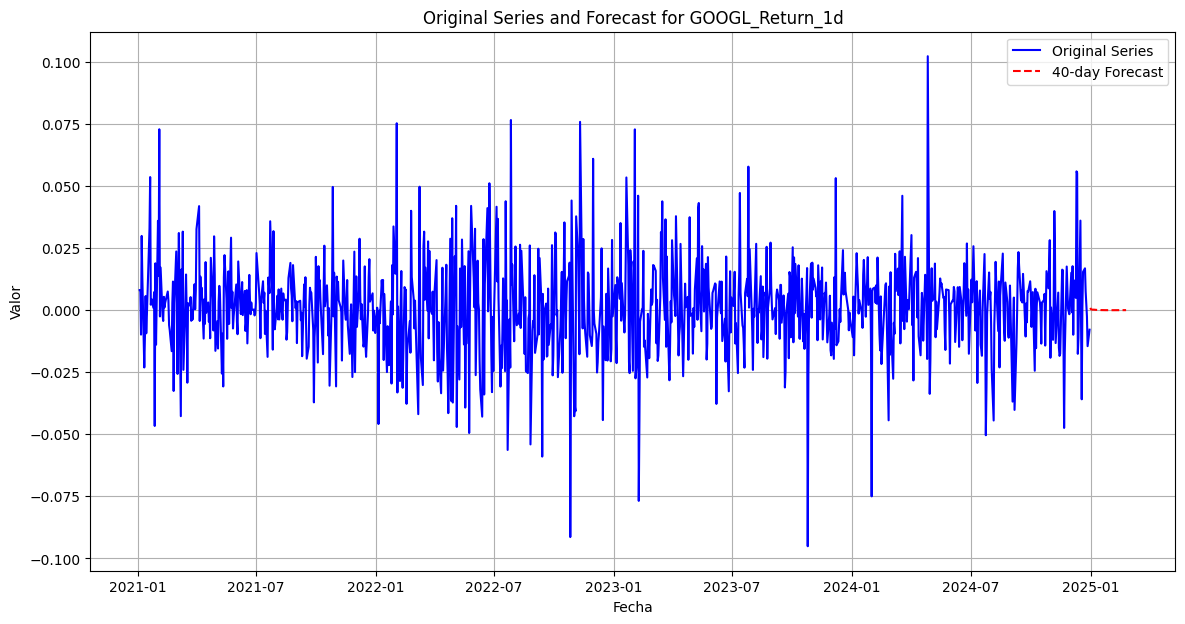

In [ ]:
# Seleccionar la serie a graficar (por ejemplo, GOOGL_Return_1d)
series_to_plot = 'GOOGL_Return_1d'

# Combinar la serie original y el pronóstico para graficar
# Necesitamos alinear por índice para combinar correctamente
combined_series = pd.concat([var_variables[series_to_plot], forecast_df_var[series_to_plot]])

# Graficar la serie original y el pronóstico
plt.figure(figsize=(14, 7))

# Graficar la serie original
plt.plot(var_variables.index, var_variables[series_to_plot], label='Original Series', color='blue')

# Graficar el pronóstico
# Empezamos a graficar el pronóstico desde el último punto de la serie original para que se conecten
plt.plot(forecast_df_var.index, forecast_df_var[series_to_plot], label=f'{forecast_steps}-day Forecast', color='red', linestyle='--')

plt.title(f'Original Series and Forecast for {series_to_plot}')
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.show()

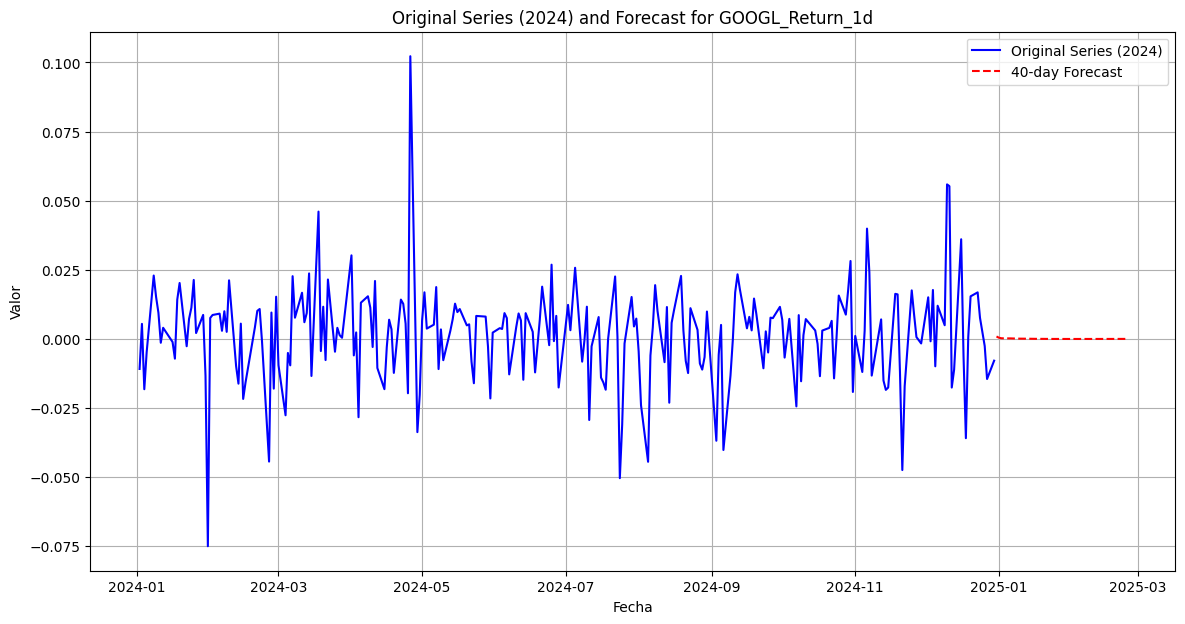

In [ ]:
# Seleccionar la serie a graficar (por ejemplo, GOOGL_Return_1d)
series_to_plot = 'GOOGL_Return_1d'

# Filtrar la serie original para el año 2024
var_variables_2024 = var_variables[var_variables.index.year == 2024].copy()

# Graficar la serie original (solo 2024) y el pronóstico
plt.figure(figsize=(14, 7))

# Graficar la serie original (solo 2024)
plt.plot(var_variables_2024.index, var_variables_2024[series_to_plot], label='Original Series (2024)', color='blue')

# Graficar el pronóstico
# Empezamos a graficar el pronóstico desde el último punto de la serie original para que se conecten
plt.plot(forecast_df_var.index, forecast_df_var[series_to_plot], label=f'{forecast_steps}-day Forecast', color='red', linestyle='--')

plt.title(f'Original Series (2024) and Forecast for {series_to_plot}')
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Mostrar la tabla de pronósticos para los próximos 40 días
print("\nTabla de Pronósticos para los Próximos 40 Días:")
display(forecast_df_var)


Tabla de Pronósticos para los Próximos 40 Días:


,GOOGL_Return_1d,Treasury_10Y,VIX,SP500,NASDAQ,Inflacion_T5YIE
2024-12-31,8.563193e-04,4.554612,17.287209,5911.263320,19497.476987,2.340924
2025-01-01,4.361161e-04,4.554889,17.037669,5916.197070,19505.367465,2.340536
2025-01-02,2.321860e-04,4.556198,16.876029,5920.200351,19510.409990,2.340216
2025-01-03,1.918943e-04,4.557526,16.716151,5924.054046,19515.196088,2.339736
2025-01-06,1.744196e-04,4.558845,16.570035,5927.790393,19519.785134,2.339185
2025-01-07,1.440134e-04,4.560173,16.435129,5931.394574,19524.107038,2.338562
2025-01-08,1.184350e-04,4.561516,16.310948,5934.877031,19528.197208,2.337878
2025-01-09,9.604884e-05,4.562873,16.196503,5938.249913,19532.089302,2.337140
2025-01-10,7.623306e-05,4.564247,16.091045,5941.522597,19535.808728,2.336358
2025-01-13,5.875931e-05,4.565640,15.993855,5944.703746,19539.378893,2.335538


In [ ]:
# Configurar la opción de visualización de pandas para no usar notación científica
# y mostrar números flotantes con dos decimales
pd.options.display.float_format = '{:.2f}'.format

# Mostrar la tabla de pronósticos para los próximos 40 días
print("\nTabla de Pronósticos para los Próximos 40 Días:")


Tabla de Pronósticos para los Próximos 40 Días:
